In [ ]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             recall_score, classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [ ]:
from google.colab import drive
import os

# 1. Montar Drive
drive.mount('/content/drive')

# 2. Definir rutas persistentes
# Recomiendo crear una carpeta específica para el proyecto
PROJECT_PATH = '/content/drive/MyDrive/inteligencia_artificial_colab'
if not os.path.exists(PROJECT_PATH):
    os.makedirs(PROJECT_PATH)
    print(f"Carpeta creada en: {PROJECT_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# CELDA 2 — CARGA ÚNICA DEL DATASET
# ============================================================

# Definir la ruta al dataset dentro del proyecto en Drive
DATASET_PATH = '/content/drive/MyDrive/inteligencia_artificial_colab/clinical_dataset/clinical_dataset.csv'

# Cargar el dataset completo en un DataFrame de Pandas
# Usamos low_memory=False para que Pandas infiera los tipos de datos con más precisión
df = pd.read_csv(DATASET_PATH, low_memory=False)

# Confirmación de carga exitosa
print("=" * 55)
print("  DATASET CARGADO EXITOSAMENTE")
print("=" * 55)
print(f"  Filas (pacientes): {df.shape[0]:,}")
print(f"  Columnas (variables): {df.shape[1]}")
print("-" * 55)
print("\nPrimeras 5 filas del dataset:")
display(df.head())

print("\nTipos de datos de cada columna:")
display(df.dtypes.to_frame(name='Tipo'))

  DATASET CARGADO EXITOSAMENTE
  Filas (pacientes): 10,000
  Columnas (variables): 14
-------------------------------------------------------

Primeras 5 filas del dataset:


,patient_id,age,sex,bmi,systolic_bp,diastolic_bp,glucose,cholesterol,creatinine,diabetes,hypertension,diagnosis,readmission_30d,mortality
0,1001,63,Male,24.1,131.0,81.0,136.2,210.3,1.04,0,0,Sepsis,0,0
1,1002,52,Male,20.8,118.0,91.0,136.5,207.9,1.49,0,1,Normal,0,0
2,1003,66,Male,30.0,144.0,73.0,100.0,179.5,1.15,0,0,Normal,0,0
3,1004,82,Male,16.8,112.0,76.0,117.3,228.3,0.59,0,0,Heart Failure,0,0
4,1005,50,Female,25.4,102.0,65.0,128.0,150.7,1.38,0,0,Normal,0,0



Tipos de datos de cada columna:


,Tipo
patient_id,int64
age,int64
sex,object
bmi,float64
systolic_bp,float64
diastolic_bp,float64
glucose,float64
cholesterol,float64
creatinine,float64
diabetes,int64


In [ ]:
# ============================================================
# CELDA 3 — IDENTIFICACIÓN DE LA VARIABLE OBJETIVO
# ============================================================

# Definir explícitamente el nombre de la columna objetivo
TARGET_COLUMN = 'diagnosis'

# Verificar que la columna existe en el dataset
assert TARGET_COLUMN in df.columns, \
    f"ERROR: La columna '{TARGET_COLUMN}' no existe en el dataset. Columnas disponibles: {df.columns.tolist()}"

# Mostrar las clases únicas y su conteo
print("=" * 55)
print(f"  VARIABLE OBJETIVO: '{TARGET_COLUMN}'")
print("=" * 55)
print(f"\nClases únicas detectadas ({df[TARGET_COLUMN].nunique()} en total):\n")

class_counts = df[TARGET_COLUMN].value_counts()
for cls, count in class_counts.items():
    pct = count / len(df) * 100
    print(f"  • {cls:<25} → {count:>5,} pacientes ({pct:.1f}%)")

print("\nTipo de dato de la variable objetivo:", df[TARGET_COLUMN].dtype)

  VARIABLE OBJETIVO: 'diagnosis'

Clases únicas detectadas (4 en total):

  • Normal                    → 5,590 pacientes (55.9%)
  • Pneumonia                 → 2,005 pacientes (20.1%)
  • Heart Failure             → 1,763 pacientes (17.6%)
  • Sepsis                    →   642 pacientes (6.4%)

Tipo de dato de la variable objetivo: object


  AUDITORÍA DE CALIDAD DE DATOS

[INFO] Dimensiones del dataset: 10,000 filas × 14 columnas

[NULOS] Conteo de valores faltantes por columna:
  ✅ Sin valores nulos detectados.

[DUPLICADOS] Filas duplicadas: 0
  ✅ Sin duplicados detectados.

[ESTADÍSTICAS] Resumen de variables numéricas:


,patient_id,age,bmi,systolic_bp,diastolic_bp,glucose,cholesterol,creatinine,diabetes,hypertension,readmission_30d,mortality
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,6000.50,54.30,27.02,124.81,80.34,106.01,190.89,1.00,0.12,0.30,0.14,0.03
std,2886.90,17.64,5.83,17.65,11.39,23.38,34.33,0.29,0.32,0.46,0.35,0.16
min,1001.00,0.00,15.00,90.00,60.00,70.00,120.00,0.50,0.00,0.00,0.00,0.00
25%,3500.75,42.00,22.90,112.00,72.00,88.10,166.78,0.79,0.00,0.00,0.00,0.00
50%,6000.50,54.00,27.00,125.00,80.00,105.30,190.85,1.00,0.00,0.00,0.00,0.00
75%,8500.25,67.00,31.00,137.00,88.00,122.10,214.40,1.20,0.00,1.00,0.00,0.00
max,11000.00,90.00,50.00,180.00,110.00,198.60,300.00,2.13,1.00,1.00,1.00,1.00



[GRÁFICO] Generando gráfico de balance de clases...


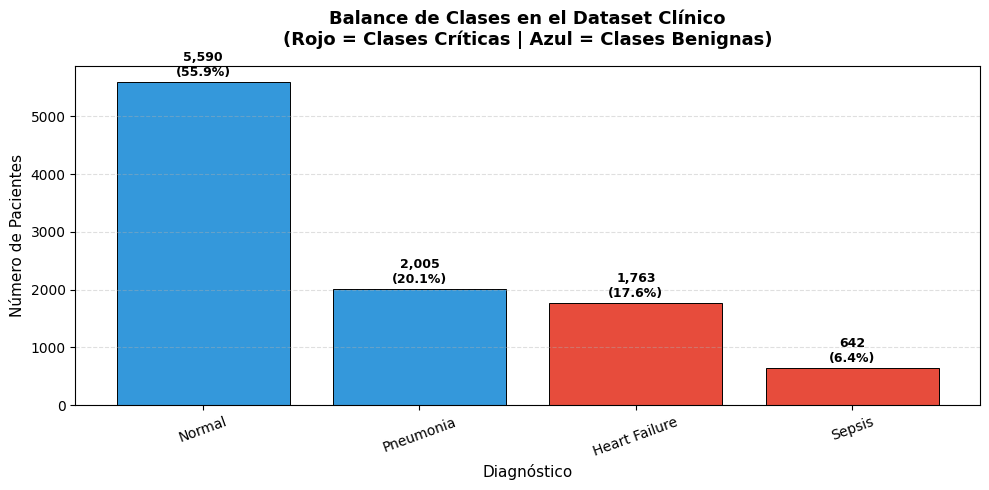


[OK] Gráfico guardado en Drive.


In [ ]:
# ============================================================
# CELDA 4 — REVISIÓN DE CALIDAD DE DATOS
# ============================================================

print("=" * 55)
print("  AUDITORÍA DE CALIDAD DE DATOS")
print("=" * 55)

# --- 4.1 Dimensiones ---
print(f"\n[INFO] Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")

# --- 4.2 Valores nulos ---
print("\n[NULOS] Conteo de valores faltantes por columna:")
nulls = df.isnull().sum()
null_pct = (nulls / len(df)) * 100
null_report = pd.DataFrame({'Nulos': nulls, 'Porcentaje (%)': null_pct.round(2)})
null_report = null_report[null_report['Nulos'] > 0]
if null_report.empty:
    print("  ✅ Sin valores nulos detectados.")
else:
    print("  ⚠️  Se encontraron columnas con valores nulos:")
    display(null_report)

# --- 4.3 Duplicados ---
n_dup = df.duplicated().sum()
print(f"\n[DUPLICADOS] Filas duplicadas: {n_dup}")
if n_dup == 0:
    print("  ✅ Sin duplicados detectados.")
else:
    print(f"  ⚠️  Se encontraron {n_dup} filas duplicadas.")

# --- 4.4 Estadísticas descriptivas ---
print("\n[ESTADÍSTICAS] Resumen de variables numéricas:")
display(df.describe().round(2))

# --- 4.5 Gráfico de Balance de Clases ---
print("\n[GRÁFICO] Generando gráfico de balance de clases...")

fig, ax = plt.subplots(figsize=(10, 5))
class_counts_sorted = df[TARGET_COLUMN].value_counts().sort_values(ascending=False)
colors = ['#e74c3c' if 'sepsis' in c.lower() or 'heart' in c.lower() or 'failure' in c.lower()
          else '#3498db' for c in class_counts_sorted.index]

bars = ax.bar(class_counts_sorted.index, class_counts_sorted.values, color=colors, edgecolor='black', linewidth=0.7)

# Agregar etiquetas de porcentaje sobre cada barra
total = class_counts_sorted.sum()
for bar, val in zip(bars, class_counts_sorted.values):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.005,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Balance de Clases en el Dataset Clínico\n'
             '(Rojo = Clases Críticas | Azul = Clases Benignas)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Diagnóstico', fontsize=11)
ax.set_ylabel('Número de Pacientes', fontsize=11)
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.4, linestyle='--')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/balance_clases.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\n[OK] Gráfico guardado en Drive.")

In [ ]:
# ============================================================
# CELDA 5 — LIMPIEZA MÍNIMA Y DEFINICIÓN DE X / y
# ============================================================

# --- 5.1 Eliminar duplicados si existen ---
n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)
if n_before != n_after:
    print(f"[LIMPIEZA] Se eliminaron {n_before - n_after} filas duplicadas.")

# --- 5.2 Definir columnas de features ---
# Columnas numéricas (continuas) — serán escaladas con StandardScaler
NUMERIC_FEATURES = ['age', 'bmi', 'systolic_bp', 'diastolic_bp',
                    'glucose', 'cholesterol', 'creatinine']

# Columnas categóricas — serán codificadas con OneHotEncoder o LabelEncoder
CATEGORICAL_FEATURES = ['sex']

# Columnas binarias (ya son 0/1) — se pueden incluir directamente
BINARY_FEATURES = ['diabetes', 'hypertension']

# Lista unificada de todas las features
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES

# --- 5.3 Separar X e y ---
X = df[ALL_FEATURES].copy()
y = df[TARGET_COLUMN].copy()

# --- 5.4 Verificación ---
print("=" * 55)
print("  DEFINICIÓN DE X / y")
print("=" * 55)
print(f"\n  X shape: {X.shape}  (pacientes × features)")
print(f"  y shape: {y.shape}  (etiquetas de diagnóstico)")
print(f"\n  Features numéricas   ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"  Features categóricas ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"  Features binarias    ({len(BINARY_FEATURES)}): {BINARY_FEATURES}")
print(f"\n  Distribución de y:\n{y.value_counts().to_string()}")

  DEFINICIÓN DE X / y

  X shape: (10000, 10)  (pacientes × features)
  y shape: (10000,)  (etiquetas de diagnóstico)

  Features numéricas   (7): ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'glucose', 'cholesterol', 'creatinine']
  Features categóricas (1): ['sex']
  Features binarias    (2): ['diabetes', 'hypertension']

  Distribución de y:
diagnosis
Normal           5590
Pneumonia        2005
Heart Failure    1763
Sepsis            642


In [ ]:
# ============================================================
# CELDA 6 — DIVISIÓN PROFESIONAL TRAIN / VAL / TEST
# ============================================================

# Paso 1: Separar el 15% para TEST (datos nunca vistos)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y          # CRÍTICO: mantener proporciones de clases
)

# Paso 2: Del 85% restante, separar ~17.6% para VAL
# (0.176 × 0.85 ≈ 0.15 del total original)
val_size_adjusted = 0.15 / 0.85

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_size_adjusted,
    random_state=RANDOM_STATE,
    stratify=y_temp     # CRÍTICO: también estratificar la segunda división
)

# --- Reporte de la división ---
total = len(X)
print("=" * 60)
print("  DIVISIÓN DE DATOS — RESUMEN PROFESIONAL")
print("=" * 60)
print(f"\n  Dataset total   : {total:,} pacientes (100%)")
print(f"  Train           : {len(X_train):,} pacientes ({len(X_train)/total*100:.1f}%)")
print(f"  Validation      : {len(X_val):,} pacientes ({len(X_val)/total*100:.1f}%)")
print(f"  Test            : {len(X_test):,} pacientes ({len(X_test)/total*100:.1f}%)")

# Verificar que la estratificación se mantuvo
print("\n  Distribución de clases (%) por subconjunto:")
for name, y_split in [("TRAIN", y_train), ("VAL", y_val), ("TEST", y_test)]:
    dist = (y_split.value_counts(normalize=True) * 100).round(1)
    print(f"\n  [{name}]")
    for cls, pct in dist.items():
        print(f"    {cls:<25}: {pct:.1f}%")

  DIVISIÓN DE DATOS — RESUMEN PROFESIONAL

  Dataset total   : 10,000 pacientes (100%)
  Train           : 7,000 pacientes (70.0%)
  Validation      : 1,500 pacientes (15.0%)
  Test            : 1,500 pacientes (15.0%)

  Distribución de clases (%) por subconjunto:

  [TRAIN]
    Normal                   : 55.9%
    Pneumonia                : 20.0%
    Heart Failure            : 17.6%
    Sepsis                   : 6.4%

  [VAL]
    Normal                   : 55.9%
    Pneumonia                : 20.1%
    Heart Failure            : 17.7%
    Sepsis                   : 6.4%

  [TEST]
    Normal                   : 55.9%
    Pneumonia                : 20.1%
    Heart Failure            : 17.6%
    Sepsis                   : 6.4%


In [ ]:
# ============================================================
# CELDA 7 — PREPROCESAMIENTO PROFESIONAL
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# --- 7.1 Codificación de variable categórica 'sex' ---
# LabelEncoder: Male → 1, Female → 0 (o viceversa, no importa el orden)
le_sex = LabelEncoder()

# SOLO fit sobre TRAIN, luego transform en todos
X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()

X_train['sex'] = le_sex.fit_transform(X_train['sex'])
X_val['sex']   = le_sex.transform(X_val['sex'])
X_test['sex']  = le_sex.transform(X_test['sex'])

print(f"[LabelEncoder] Mapeo de 'sex': {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")

# --- 7.2 Escalado de variables numéricas con StandardScaler ---
scaler = StandardScaler()

# fit() calcula media y std SOLO en train (regla de oro anti-leakage)
X_train[NUMERIC_FEATURES] = scaler.fit_transform(X_train[NUMERIC_FEATURES])
X_val[NUMERIC_FEATURES]   = scaler.transform(X_val[NUMERIC_FEATURES])
X_test[NUMERIC_FEATURES]  = scaler.transform(X_test[NUMERIC_FEATURES])

# --- 7.3 Convertir a arrays numpy para TensorFlow ---
X_train_arr = X_train.values.astype(np.float32)
X_val_arr   = X_val.values.astype(np.float32)
X_test_arr  = X_test.values.astype(np.float32)

# --- 7.4 Reporte ---
print("\n" + "=" * 55)
print("  ESTADÍSTICAS DEL ESCALADO (aprendidas en TRAIN)")
print("=" * 55)
scaler_report = pd.DataFrame({
    'Feature': NUMERIC_FEATURES,
    'Media (train)': scaler.mean_.round(3),
    'Std (train)':   scaler.scale_.round(3)
})
display(scaler_report)

print(f"\n  X_train_arr shape: {X_train_arr.shape}")
print(f"  X_val_arr shape  : {X_val_arr.shape}")
print(f"  X_test_arr shape : {X_test_arr.shape}")
print(f"\n  Rango de X_train_arr — min: {X_train_arr.min():.2f}, max: {X_train_arr.max():.2f}")
print("  ✅ Datos escalados y listos para la red neuronal.")

[LabelEncoder] Mapeo de 'sex': {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}

  ESTADÍSTICAS DEL ESCALADO (aprendidas en TRAIN)


,Feature,Media (train),Std (train)
0,age,54.322,17.601
1,bmi,27.116,5.811
2,systolic_bp,124.899,17.688
3,diastolic_bp,80.343,11.418
4,glucose,105.898,23.227
5,cholesterol,190.885,34.313
6,creatinine,1.005,0.289



  X_train_arr shape: (7000, 10)
  X_val_arr shape  : (1500, 10)
  X_test_arr shape : (1500, 10)

  Rango de X_train_arr — min: -3.09, max: 3.99
  ✅ Datos escalados y listos para la red neuronal.


In [ ]:
# ============================================================
# CELDA 8 — CODIFICACIÓN DE CLASES (VARIABLE OBJETIVO)
# ============================================================

# Crear y entrenar el LabelEncoder sobre el target
le_target = LabelEncoder()

# fit SOLO sobre y_train, luego transform en todos
y_train_enc = le_target.fit_transform(y_train)
y_val_enc   = le_target.transform(y_val)
y_test_enc  = le_target.transform(y_test)

# Número total de clases (necesario para la capa de salida de la red)
NUM_CLASSES = len(le_target.classes_)

# Mostrar el mapeo completo
print("=" * 55)
print("  CODIFICACIÓN DE LA VARIABLE OBJETIVO")
print("=" * 55)
print(f"\n  Número total de clases: {NUM_CLASSES}")
print("\n  Mapeo Clase → Índice Numérico:")
for idx, cls in enumerate(le_target.classes_):
    print(f"    [{idx}] → {cls}")

# Verificar que todos los targets están en el rango correcto
print(f"\n  Rango de y_train_enc: [{y_train_enc.min()}, {y_train_enc.max()}]")
print(f"  Tipos — y_train: {y_train_enc.dtype}, y_val: {y_val_enc.dtype}")
print("\n  ✅ Clases codificadas. Usar le_target.inverse_transform() para revertir.")

# Guardar el mapeo como variable global para referencias futuras
CLASS_NAMES = le_target.classes_.tolist()
print(f"\n  CLASS_NAMES: {CLASS_NAMES}")

  CODIFICACIÓN DE LA VARIABLE OBJETIVO

  Número total de clases: 4

  Mapeo Clase → Índice Numérico:
    [0] → Heart Failure
    [1] → Normal
    [2] → Pneumonia
    [3] → Sepsis

  Rango de y_train_enc: [0, 3]
  Tipos — y_train: int64, y_val: int64

  ✅ Clases codificadas. Usar le_target.inverse_transform() para revertir.

  CLASS_NAMES: ['Heart Failure', 'Normal', 'Pneumonia', 'Sepsis']


In [ ]:
# ============================================================
# CELDA 9 — DEFINICIÓN DE LA CLASE CRÍTICA
# ============================================================

# Definir las palabras clave asociadas a clases de alto riesgo
# (En orden de prioridad clínica, de mayor a menor)
CRITICAL_KEYWORDS = ['sepsis', 'heart failure', 'cardiac', 'stroke', 'acute']

# Buscar dinámicamente en las clases del encoder
CRITICAL_CLASS_NAME = None
CRITICAL_CLASS_IDX  = None

for keyword in CRITICAL_KEYWORDS:
    for idx, cls in enumerate(le_target.classes_):
        if keyword.lower() in cls.lower():
            CRITICAL_CLASS_NAME = cls
            CRITICAL_CLASS_IDX  = idx
            break
    if CRITICAL_CLASS_NAME is not None:
        break

# Si no se encontró ninguna, advertir al equipo clínico
if CRITICAL_CLASS_NAME is None:
    print("⚠️  ADVERTENCIA: No se detectó automáticamente una clase crítica.")
    print("    Por favor, define manualmente CRITICAL_CLASS_NAME y CRITICAL_CLASS_IDX.")
    print(f"    Clases disponibles: {CLASS_NAMES}")
else:
    print("=" * 55)
    print("  CLASE CRÍTICA IDENTIFICADA")
    print("=" * 55)
    print(f"\n  Nombre : '{CRITICAL_CLASS_NAME}'")
    print(f"  Índice : {CRITICAL_CLASS_IDX}")
    print(f"\n  Implicación clínica:")
    print(f"  → Minimizar FALSOS NEGATIVOS de '{CRITICAL_CLASS_NAME}'")
    print(f"  → Métrica clave: RECALL de la clase {CRITICAL_CLASS_IDX}")
    print(f"  → Un paciente con '{CRITICAL_CLASS_NAME}' NO diagnosticado = riesgo vital.")

    n_critical = (y_train_enc == CRITICAL_CLASS_IDX).sum()
    n_total    = len(y_train_enc)
    print(f"\n  Prevalencia en TRAIN: {n_critical} / {n_total} ({n_critical/n_total*100:.2f}%)")

  CLASE CRÍTICA IDENTIFICADA

  Nombre : 'Sepsis'
  Índice : 3

  Implicación clínica:
  → Minimizar FALSOS NEGATIVOS de 'Sepsis'
  → Métrica clave: RECALL de la clase 3
  → Un paciente con 'Sepsis' NO diagnosticado = riesgo vital.

  Prevalencia en TRAIN: 450 / 7000 (6.43%)


In [ ]:
# ============================================================
# CELDA 10 — BASELINE PROFESIONAL (DummyClassifier)
# ============================================================

from sklearn.dummy import DummyClassifier

print("=" * 60)
print("  BASELINE — MODELOS TRIVIALES DE REFERENCIA")
print("=" * 60)

baseline_results = {}

for strategy in ['most_frequent', 'stratified']:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    dummy.fit(X_train_arr, y_train_enc)
    y_pred_dummy = dummy.predict(X_val_arr)

    acc      = accuracy_score(y_val_enc, y_pred_dummy)
    bal_acc  = balanced_accuracy_score(y_val_enc, y_pred_dummy)
    f1_macro = f1_score(y_val_enc, y_pred_dummy, average='macro', zero_division=0)
    recall_critical = recall_score(y_val_enc, y_pred_dummy,
                                   labels=[CRITICAL_CLASS_IDX],
                                   average='macro', zero_division=0)

    baseline_results[strategy] = {
        'Accuracy': round(acc, 4),
        'Balanced Accuracy': round(bal_acc, 4),
        'F1 Macro': round(f1_macro, 4),
        f'Recall {CRITICAL_CLASS_NAME}': round(recall_critical, 4)
    }

    print(f"\n  Estrategia: '{strategy}'")
    print(f"    Accuracy           : {acc:.4f}")
    print(f"    Balanced Accuracy  : {bal_acc:.4f}")
    print(f"    F1 Macro           : {f1_macro:.4f}")
    print(f"    Recall Crítico     : {recall_critical:.4f}")

print("\n  📌 INTERPRETACIÓN:")
print("  → Un modelo con F1 Macro > Baseline es 'útil'.")
print("  → Un modelo con Recall Crítico = 0 es peligroso, como el 'most_frequent'.")

  BASELINE — MODELOS TRIVIALES DE REFERENCIA

  Estrategia: 'most_frequent'
    Accuracy           : 0.5587
    Balanced Accuracy  : 0.2500
    F1 Macro           : 0.1792
    Recall Crítico     : 0.0000

  Estrategia: 'stratified'
    Accuracy           : 0.3867
    Balanced Accuracy  : 0.2486
    F1 Macro           : 0.2487
    Recall Crítico     : 0.0625

  📌 INTERPRETACIÓN:
  → Un modelo con F1 Macro > Baseline es 'útil'.
  → Un modelo con Recall Crítico = 0 es peligroso, como el 'most_frequent'.


In [ ]:
# ============================================================
# CELDA 11 — MÉTRICAS HISTÓRICAS DEL RANDOM FOREST
# ============================================================

# Métricas documentadas del experimento anterior con Random Forest
# (Obtenidas en el notebook The_Good_Doctor_RandomForest_v1.ipynb)
rf_metrics_sin_smote = {
    'Modelo': 'Random Forest (sin SMOTE)',
    'Accuracy': 0.83,
    'Balanced Accuracy': 0.61,
    'F1 Macro': 0.58,
    f'Recall {CRITICAL_CLASS_NAME}': 0.00   # ← El problema grave
}

rf_metrics_con_smote = {
    'Modelo': 'Random Forest (con SMOTE)',
    'Accuracy': 0.79,
    'Balanced Accuracy': 0.72,
    'F1 Macro': 0.70,
    f'Recall {CRITICAL_CLASS_NAME}': 0.61   # ← Mejoró, pero aún insuficiente
}

print("=" * 65)
print("  HISTORIAL: RANDOM FOREST — MÉTRICAS DOCUMENTADAS")
print("=" * 65)

comparison_df = pd.DataFrame([rf_metrics_sin_smote, rf_metrics_con_smote])
display(comparison_df.set_index('Modelo'))

print("\n  📌 CONCLUSIÓN CLÍNICA DEL RANDOM FOREST:")
print(f"  → Sin SMOTE: Recall de '{CRITICAL_CLASS_NAME}' = 0.00 → INACEPTABLE EN CLÍNICA.")
print(f"  → Con SMOTE: Recall de '{CRITICAL_CLASS_NAME}' mejoró, pero el modelo aún")
print(f"    sacrifica demasiada precisión general.")
print("  → Objetivo del MLP: superar estos valores usando class_weights,")
print("    una arquitectura más expresiva y técnicas de regularización.")

# Guardar para la tabla comparativa final
BASELINE_METRICS = pd.DataFrame([
    {**{'Modelo': 'Dummy (most_frequent)'}, **baseline_results['most_frequent']},
    rf_metrics_sin_smote,
    rf_metrics_con_smote
])

  HISTORIAL: RANDOM FOREST — MÉTRICAS DOCUMENTADAS


,Accuracy,Balanced Accuracy,F1 Macro,Recall Sepsis
Modelo,,,,
Random Forest (sin SMOTE),0.83,0.61,0.58,0.00
Random Forest (con SMOTE),0.79,0.72,0.70,0.61



  📌 CONCLUSIÓN CLÍNICA DEL RANDOM FOREST:
  → Sin SMOTE: Recall de 'Sepsis' = 0.00 → INACEPTABLE EN CLÍNICA.
  → Con SMOTE: Recall de 'Sepsis' mejoró, pero el modelo aún
    sacrifica demasiada precisión general.
  → Objetivo del MLP: superar estos valores usando class_weights,
    una arquitectura más expresiva y técnicas de regularización.


In [ ]:
# ============================================================
# CELDA 12 — CREAR MODELO MLP INICIAL
# ============================================================

def build_mlp_initial(input_dim, num_classes,
                      units_1=128, units_2=64, units_3=32,
                      dropout_rate=0.3, l2_lambda=0.001):
    """
    Construye un MLP para clasificación multiclase clínica.

    Args:
        input_dim   : Número de features de entrada (columnas de X).
        num_classes : Número de clases objetivo.
        units_1/2/3 : Neuronas por capa oculta.
        dropout_rate: Porcentaje de neuronas desactivadas (regularización).
        l2_lambda   : Intensidad de regularización L2.

    Returns:
        model: Modelo Keras compilado.
    """
    reg = regularizers.l2(l2_lambda)

    model = models.Sequential([
        # --- CAPA DE ENTRADA ---
        layers.Input(shape=(input_dim,), name='input'),

        # --- BLOQUE OCULTO 1 ---
        layers.Dense(units_1, activation='relu', kernel_regularizer=reg, name='dense_1'),
        layers.BatchNormalization(name='bn_1'),
        layers.Dropout(dropout_rate, name='dropout_1'),

        # --- BLOQUE OCULTO 2 ---
        layers.Dense(units_2, activation='relu', kernel_regularizer=reg, name='dense_2'),
        layers.BatchNormalization(name='bn_2'),
        layers.Dropout(dropout_rate, name='dropout_2'),

        # --- BLOQUE OCULTO 3 ---
        layers.Dense(units_3, activation='relu', kernel_regularizer=reg, name='dense_3'),
        layers.Dropout(dropout_rate / 2, name='dropout_3'),   # Menos dropout cerca de la salida

        # --- CAPA DE SALIDA (Softmax para probabilidades multiclase) ---
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='MLP_Clinical_v1')

    return model

# Instanciar el modelo inicial
mlp_model = build_mlp_initial(
    input_dim   = X_train_arr.shape[1],
    num_classes = NUM_CLASSES
)

# Mostrar arquitectura
mlp_model.summary()
print(f"\n  Input shape  : ({X_train_arr.shape[1]},) → {X_train_arr.shape[1]} features")
print(f"  Output shape : ({NUM_CLASSES},) → {NUM_CLASSES} clases")
print(f"  Total parámetros entrenables: {mlp_model.count_params():,}")

Model: "MLP_Clinical_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,644 (49.39 KB)

 Trainable params: 12,260 (47.89 KB)

 Non-trainable params: 384 (1.50 KB)


  Input shape  : (10,) → 10 features
  Output shape : (4,) → 4 clases
  Total parámetros entrenables: 12,644


In [ ]:
# ============================================================
# CELDA 13 — CONFIGURACIÓN PROFESIONAL DEL ENTRENAMIENTO
# ============================================================

# --- 13.1 Calcular Class Weights para manejo del desbalanceo ---
# compute_class_weight calcula el peso inversamente proporcional a la frecuencia
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)

# Convertir a diccionario {índice_clase: peso}
CLASS_WEIGHTS = dict(enumerate(class_weights_array))

print("=" * 55)
print("  CLASS WEIGHTS (Anti-Desbalanceo)")
print("=" * 55)
print("\n  Clase → Peso asignado:")
for idx, weight in CLASS_WEIGHTS.items():
    marker = " ← CLASE CRÍTICA" if idx == CRITICAL_CLASS_IDX else ""
    print(f"  [{idx}] {le_target.classes_[idx]:<25}: {weight:.4f}{marker}")

print("\n  📌 INTERPRETACIÓN:")
print("  → Peso > 1: clase minoritaria, el modelo se penaliza más si la falla.")
print("  → Peso < 1: clase mayoritaria, errores tienen menos penalización.")

# --- 13.2 Compilar el modelo ---
LEARNING_RATE = 0.001

mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n  Modelo compilado:")
print(f"    Loss       : SparseCategoricalCrossentropy")
print(f"    Optimizer  : Adam (lr={LEARNING_RATE})")
print(f"    Métricas   : ['accuracy']")
print("  ✅ Listo para entrenamiento.")

  CLASS WEIGHTS (Anti-Desbalanceo)

  Clase → Peso asignado:
  [0] Heart Failure            : 1.4182
  [1] Normal                   : 0.4472
  [2] Pneumonia                : 1.2473
  [3] Sepsis                   : 3.8889 ← CLASE CRÍTICA

  📌 INTERPRETACIÓN:
  → Peso > 1: clase minoritaria, el modelo se penaliza más si la falla.
  → Peso < 1: clase mayoritaria, errores tienen menos penalización.

  Modelo compilado:
    Loss       : SparseCategoricalCrossentropy
    Optimizer  : Adam (lr=0.001)
    Métricas   : ['accuracy']
  ✅ Listo para entrenamiento.


In [ ]:
# ============================================================
# CELDA 14 — ENTRENAMIENTO DEL MODELO MLP
# ============================================================

MODEL_SAVE_PATH = '/content/drive/MyDrive/inteligencia_artificial_colab/mlp_best_model.keras'

# --- 14.1 Definir Callbacks ---
cb_early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,                # Espera 15 épocas sin mejora antes de parar
    restore_best_weights=True,  # Restaura los pesos del mejor epoch al final
    verbose=1
)

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,                 # Reduce el LR a la mitad cuando se estanca
    patience=7,                 # Espera 7 épocas antes de reducir
    min_lr=1e-6,                # No reduce por debajo de este valor
    verbose=1
)

cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True,        # Solo guarda si mejora val_loss
    verbose=1
)

# --- 14.2 Entrenamiento ---
print("=" * 55)
print("  INICIANDO ENTRENAMIENTO DEL MLP")
print("=" * 55)
print(f"  Épocas máximas  : 150")
print(f"  Batch size      : 32")
print(f"  EarlyStopping   : patience=15 (val_loss)")
print(f"  ReduceLROnPlateau: patience=7")
print(f"  Class weights   : activados para compensar desbalanceo")
print("-" * 55)

history = mlp_model.fit(
    X_train_arr, y_train_enc,
    validation_data=(X_val_arr, y_val_enc),
    epochs=150,
    batch_size=32,
    class_weight=CLASS_WEIGHTS,     # Anti-desbalanceo
    callbacks=[cb_early_stop, cb_reduce_lr, cb_checkpoint],
    verbose=1
)

print(f"\n  ✅ Entrenamiento completado.")
print(f"  Épocas reales entrenadas: {len(history.history['loss'])}")
print(f"  Mejor modelo guardado en: {MODEL_SAVE_PATH}")

  INICIANDO ENTRENAMIENTO DEL MLP
  Épocas máximas  : 150
  Batch size      : 32
  EarlyStopping   : patience=15 (val_loss)
  ReduceLROnPlateau: patience=7
  Class weights   : activados para compensar desbalanceo
-------------------------------------------------------
Epoch 1/150
215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2338 - loss: 1.7986
Epoch 1: val_loss improved from None to 1.50491, saving model to /content/drive/MyDrive/inteligencia_artificial_colab/mlp_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/inteligencia_artificial_colab/mlp_best_model.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.2444 - loss: 1.7389 - val_accuracy: 0.3267 - val_loss: 1.5049 - learning_rate: 0.0010
Epoch 2/150
210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2670 - loss: 1.6069
Epoch 2: val_loss did not improve from 1.50491
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2567 - loss: 1.6133 - val_accuracy: 0.2353 - val_loss: 1.5327 - le

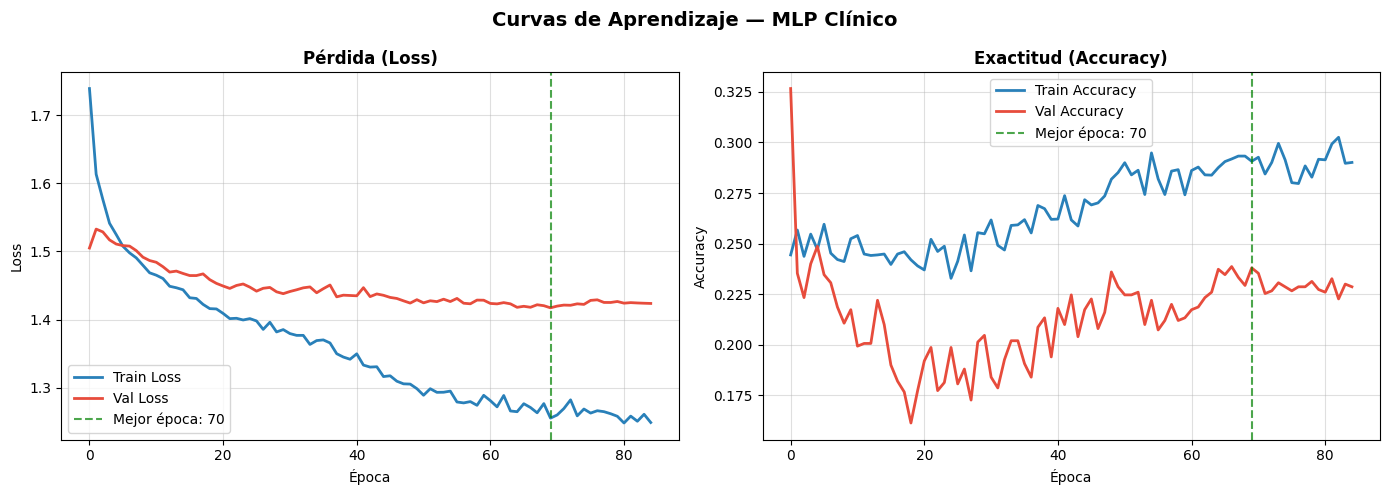


  Mejor época      : 70
  Mejor val_loss   : 1.4172
  Mejor val_acc    : 0.3267

  📌 DIAGNÓSTICO DE LAS CURVAS:
  ⚠️  Posible OVERFITTING detectado. Considerar más Dropout o menos neuronas.


In [ ]:
# ============================================================
# CELDA 15 — CURVAS DE APRENDIZAJE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Aprendizaje — MLP Clínico', fontsize=14, fontweight='bold')

# --- Gráfico 1: Loss ---
ax = axes[0]
ax.plot(history.history['loss'],     label='Train Loss',      color='#2980b9', linewidth=2)
ax.plot(history.history['val_loss'], label='Val Loss',        color='#e74c3c', linewidth=2)
best_epoch = np.argmin(history.history['val_loss'])
ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Mejor época: {best_epoch+1}')
ax.set_title('Pérdida (Loss)', fontsize=12, fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(alpha=0.4)

# --- Gráfico 2: Accuracy ---
ax = axes[1]
ax.plot(history.history['accuracy'],     label='Train Accuracy', color='#2980b9', linewidth=2)
ax.plot(history.history['val_accuracy'], label='Val Accuracy',   color='#e74c3c', linewidth=2)
ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Mejor época: {best_epoch+1}')
ax.set_title('Exactitud (Accuracy)', fontsize=12, fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/curvas_aprendizaje_mlp.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Métricas de la mejor época
print(f"\n  Mejor época      : {best_epoch + 1}")
print(f"  Mejor val_loss   : {min(history.history['val_loss']):.4f}")
print(f"  Mejor val_acc    : {max(history.history['val_accuracy']):.4f}")
print("\n  📌 DIAGNÓSTICO DE LAS CURVAS:")
train_loss_final = history.history['loss'][-1]
val_loss_final   = history.history['val_loss'][-1]
gap = val_loss_final - train_loss_final
if gap > 0.15:
    print("  ⚠️  Posible OVERFITTING detectado. Considerar más Dropout o menos neuronas.")
elif val_loss_final > 1.0:
    print("  ⚠️  Posible UNDERFITTING. Considerar más neuronas o más épocas.")
else:
    print("  ✅ Las curvas muestran un aprendizaje estable y generalizable.")

In [ ]:
# ============================================================
# CELDA 16 — PREDICCIÓN Y EVALUACIÓN EN TEST SET
# ============================================================

# --- 16.1 Probabilidades de cada clase (salida del Softmax) ---
y_proba = mlp_model.predict(X_test_arr, verbose=0)  # Shape: (n_samples, NUM_CLASSES)

# --- 16.2 Predicción final = argmax de probabilidades ---
y_pred = np.argmax(y_proba, axis=1)

# --- 16.3 Métricas globales ---
acc          = accuracy_score(y_test_enc, y_pred)
bal_acc      = balanced_accuracy_score(y_test_enc, y_pred)
f1_macro     = f1_score(y_test_enc, y_pred, average='macro', zero_division=0)
f1_weighted  = f1_score(y_test_enc, y_pred, average='weighted', zero_division=0)
recall_crit  = recall_score(y_test_enc, y_pred,
                            labels=[CRITICAL_CLASS_IDX],
                            average='macro', zero_division=0)

print("=" * 65)
print("  EVALUACIÓN FINAL EN TEST SET — MLP Clínico v1")
print("=" * 65)
print(f"\n  Accuracy           : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Balanced Accuracy  : {bal_acc:.4f}")
print(f"  F1 Macro           : {f1_macro:.4f}")
print(f"  F1 Weighted        : {f1_weighted:.4f}")
print(f"  Recall Crítico     : {recall_crit:.4f}  ← '{CRITICAL_CLASS_NAME}'")

print("\n" + "=" * 65)
print("  REPORTE COMPLETO POR CLASE")
print("=" * 65)
print(classification_report(y_test_enc, y_pred,
                             target_names=CLASS_NAMES,
                             zero_division=0))

# Guardar métricas del MLP para tabla comparativa
mlp_initial_metrics = {
    'Modelo': 'MLP Inicial',
    'Accuracy': round(acc, 4),
    'Balanced Accuracy': round(bal_acc, 4),
    'F1 Macro': round(f1_macro, 4),
    f'Recall {CRITICAL_CLASS_NAME}': round(recall_crit, 4)
}

  EVALUACIÓN FINAL EN TEST SET — MLP Clínico v1

  Accuracy           : 0.2293  (22.93%)
  Balanced Accuracy  : 0.2520
  F1 Macro           : 0.2109
  F1 Weighted        : 0.2502
  Recall Crítico     : 0.2396  ← 'Sepsis'

  REPORTE COMPLETO POR CLASE
               precision    recall  f1-score   support

Heart Failure       0.18      0.30      0.22       264
       Normal       0.55      0.19      0.28       839
    Pneumonia       0.21      0.29      0.24       301
       Sepsis       0.06      0.24      0.10        96

     accuracy                           0.23      1500
    macro avg       0.25      0.25      0.21      1500
 weighted avg       0.38      0.23      0.25      1500



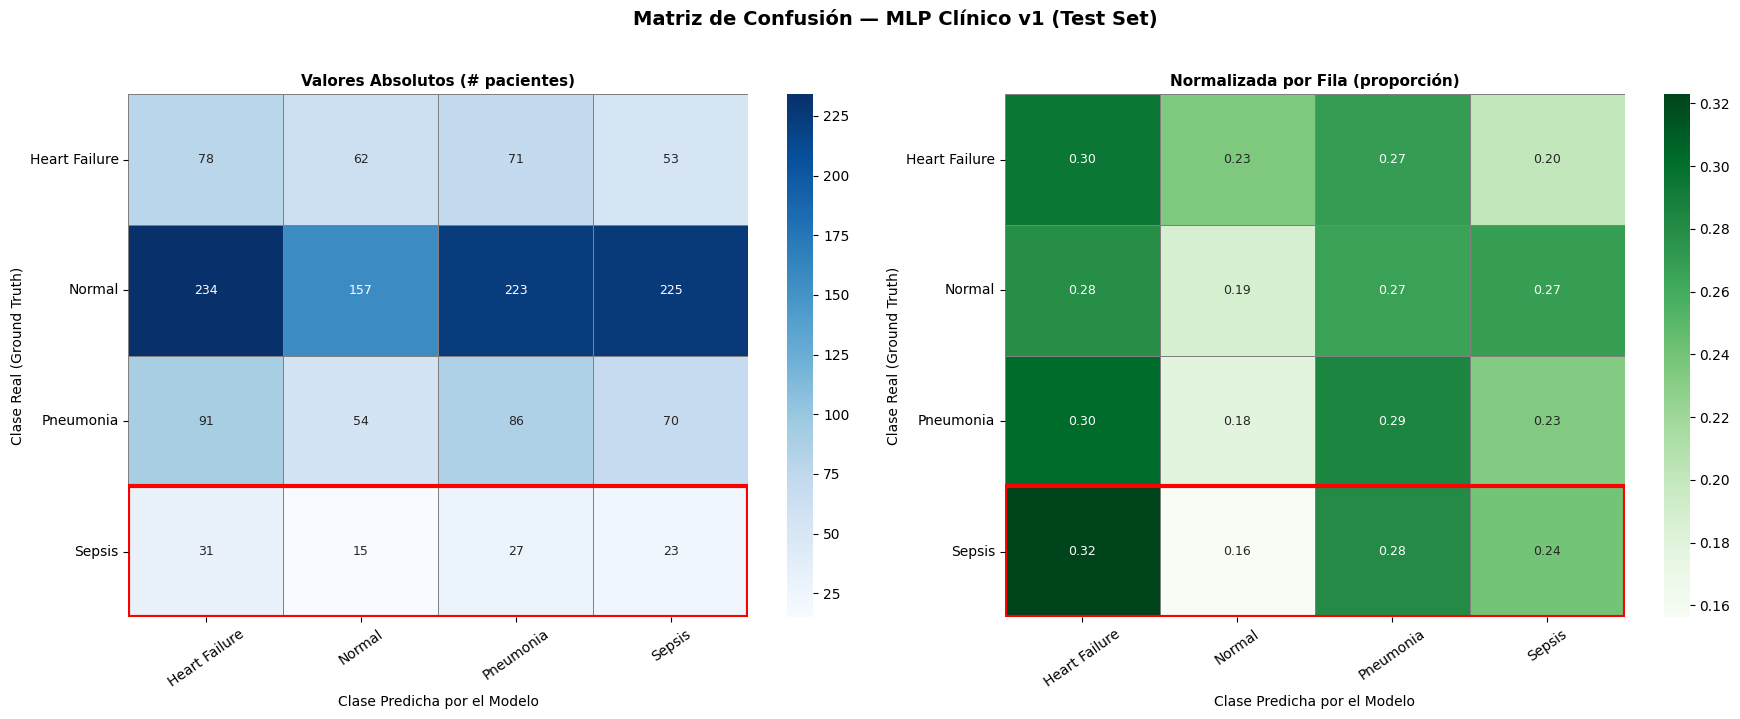


  Análisis de la clase 'Sepsis':
  ✅ Verdaderos Positivos (TP): 23  ← Detectados correctamente
  ❌ Falsos Negativos    (FN): 73  ← NO detectados → riesgo vital


In [ ]:
# ============================================================
# CELDA 17 — MATRIZ DE CONFUSIÓN CLÍNICA
# ============================================================

import seaborn as sns

# Calcular la matriz de confusión
cm = confusion_matrix(y_test_enc, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalizada por fila

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matriz de Confusión — MLP Clínico v1 (Test Set)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, matrix, title, fmt, cmap in zip(
    axes,
    [cm, cm_normalized],
    ['Valores Absolutos (# pacientes)', 'Normalizada por Fila (proporción)'],
    ['d', '.2f'],
    ['Blues', 'Greens']
):
    sns.heatmap(matrix,
                annot=True, fmt=fmt,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap=cmap, ax=ax,
                linewidths=0.5, linecolor='gray',
                annot_kws={"size": 9})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Clase Real (Ground Truth)', fontsize=10)
    ax.set_xlabel('Clase Predicha por el Modelo', fontsize=10)
    ax.tick_params(axis='x', rotation=35)
    ax.tick_params(axis='y', rotation=0)

    # Resaltar la fila de la clase crítica
    ax.add_patch(plt.Rectangle(
        (0, CRITICAL_CLASS_IDX), NUM_CLASSES, 1,
        fill=False, edgecolor='red', lw=3, label='Clase Crítica'
    ))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/confusion_matrix_mlp.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Análisis de la fila crítica
fn_critical = cm[CRITICAL_CLASS_IDX].sum() - cm[CRITICAL_CLASS_IDX, CRITICAL_CLASS_IDX]
tp_critical = cm[CRITICAL_CLASS_IDX, CRITICAL_CLASS_IDX]
print(f"\n  Análisis de la clase '{CRITICAL_CLASS_NAME}':")
print(f"  ✅ Verdaderos Positivos (TP): {tp_critical}  ← Detectados correctamente")
print(f"  ❌ Falsos Negativos    (FN): {fn_critical}  ← NO detectados → riesgo vital")

In [ ]:
# ============================================================
# CELDA 18 — TABLA COMPARATIVA DE MODELOS
# ============================================================

# Construir tabla completa con todos los modelos evaluados
comparison_table = pd.DataFrame([
    {
        'Modelo': 'Dummy (most_frequent)',
        'Accuracy': baseline_results['most_frequent']['Accuracy'],
        'Balanced Acc.': baseline_results['most_frequent']['Balanced Accuracy'],
        'F1 Macro': baseline_results['most_frequent']['F1 Macro'],
        f'Recall {CRITICAL_CLASS_NAME}': baseline_results['most_frequent'][f'Recall {CRITICAL_CLASS_NAME}']
    },
    {
        'Modelo': 'Random Forest (sin SMOTE)',
        'Accuracy': 0.83,
        'Balanced Acc.': 0.61,
        'F1 Macro': 0.58,
        f'Recall {CRITICAL_CLASS_NAME}': 0.00
    },
    {
        'Modelo': 'Random Forest (con SMOTE)',
        'Accuracy': 0.79,
        'Balanced Acc.': 0.72,
        'F1 Macro': 0.70,
        f'Recall {CRITICAL_CLASS_NAME}': 0.61
    },
    {
        'Modelo': 'MLP Inicial (class_weights)',
        'Accuracy': mlp_initial_metrics['Accuracy'],
        'Balanced Acc.': mlp_initial_metrics['Balanced Accuracy'],
        'F1 Macro': mlp_initial_metrics['F1 Macro'],
        f'Recall {CRITICAL_CLASS_NAME}': mlp_initial_metrics[f'Recall {CRITICAL_CLASS_NAME}']
    }
])

comparison_table = comparison_table.set_index('Modelo')

print("=" * 75)
print("  TABLA COMPARATIVA — TODOS LOS MODELOS EVALUADOS")
print("=" * 75)
display(comparison_table.style
        .highlight_max(axis=0, color='#d4edda')  # Verde = mejor
        .highlight_min(axis=0, color='#f8d7da')  # Rojo = peor
        .format("{:.4f}")
)

print("\n  📌 CRITERIOS DE SELECCIÓN CLÍNICA:")
print("  1. Prioridad 1: Recall de clase crítica (máximo posible)")
print("  2. Prioridad 2: F1 Macro (balance general)")
print("  3. Prioridad 3: Balanced Accuracy (robusto al desbalanceo)")
print("  4. Accuracy general: menos relevante en datasets desbalanceados")

  TABLA COMPARATIVA — TODOS LOS MODELOS EVALUADOS


,Accuracy,Balanced Acc.,F1 Macro,Recall Sepsis
Modelo,,,,
Dummy (most_frequent),0.5587,0.2500,0.1792,0.0000
Random Forest (sin SMOTE),0.8300,0.6100,0.5800,0.0000
Random Forest (con SMOTE),0.7900,0.7200,0.7000,0.6100
MLP Inicial (class_weights),0.2293,0.2520,0.2109,0.2396



  📌 CRITERIOS DE SELECCIÓN CLÍNICA:
  1. Prioridad 1: Recall de clase crítica (máximo posible)
  2. Prioridad 2: F1 Macro (balance general)
  3. Prioridad 3: Balanced Accuracy (robusto al desbalanceo)
  4. Accuracy general: menos relevante en datasets desbalanceados


In [ ]:
# ============================================================
# CELDA 19 — ANÁLISIS DE FALSOS NEGATIVOS DE LA CLASE CRÍTICA
# ============================================================

# Encontrar índices (en test set) donde la clase real es CRÍTICA
critical_mask = (y_test_enc == CRITICAL_CLASS_IDX)

# Separar en correctamente detectados (TP) y no detectados (FN)
y_pred_critical_region = y_pred[critical_mask]
y_true_critical_region = y_test_enc[critical_mask]

tp_mask = (y_pred_critical_region == CRITICAL_CLASS_IDX)
fn_mask = (y_pred_critical_region != CRITICAL_CLASS_IDX)

# Obtener los datos originales de los FN
X_test_original = pd.DataFrame(
    X_test_arr[critical_mask],
    columns=ALL_FEATURES
)
X_test_original['prediccion'] = [CLASS_NAMES[p] for p in y_pred_critical_region]
X_test_original['correcto'] = tp_mask

fn_df = X_test_original[fn_mask].copy()
tp_df = X_test_original[tp_mask].copy()

print("=" * 65)
print(f"  ANÁLISIS DE FALSOS NEGATIVOS — '{CRITICAL_CLASS_NAME}'")
print("=" * 65)
print(f"\n  Total pacientes '{CRITICAL_CLASS_NAME}' en Test : {critical_mask.sum()}")
print(f"  Detectados correctamente (TP)                 : {tp_mask.sum()}")
print(f"  NO detectados (Falsos Negativos / FN)         : {fn_mask.sum()}")
print(f"  Recall (TP / Total Críticos)                  : {tp_mask.sum() / critical_mask.sum():.4f}")

if fn_mask.sum() > 0:
    print(f"\n  ¿Cómo predijo el modelo a los {fn_mask.sum()} pacientes no detectados?")
    wrong_predictions = pd.Series(fn_df['prediccion']).value_counts()
    for cls, count in wrong_predictions.items():
        print(f"    → Los clasificó como '{cls}': {count} paciente(s)")

    print(f"\n  Perfil clínico promedio de los NO detectados (FN):")
    # Mostrar promedios de las variables clave (en escala original aproximada)
    fn_numeric = fn_df[NUMERIC_FEATURES].mean()
    tp_numeric = tp_df[NUMERIC_FEATURES].mean()
    comparison = pd.DataFrame({'FN (no detectados)': fn_numeric,
                               'TP (sí detectados)': tp_numeric})
    display(comparison.round(3))
    print("\n  📌 ACCIÓN CLÍNICA: Los pacientes no detectados probablemente")
    print("     presentan valores más limítrofes. Considerar umbral más bajo")
    print("     o reglas de negocio adicionales para estos perfiles.")

  ANÁLISIS DE FALSOS NEGATIVOS — 'Sepsis'

  Total pacientes 'Sepsis' en Test : 96
  Detectados correctamente (TP)                 : 23
  NO detectados (Falsos Negativos / FN)         : 73
  Recall (TP / Total Críticos)                  : 0.2396

  ¿Cómo predijo el modelo a los 73 pacientes no detectados?
    → Los clasificó como 'Heart Failure': 31 paciente(s)
    → Los clasificó como 'Pneumonia': 27 paciente(s)
    → Los clasificó como 'Normal': 15 paciente(s)

  Perfil clínico promedio de los NO detectados (FN):


,FN (no detectados),TP (sí detectados)
age,0.159,0.011
bmi,-0.040,-0.165
systolic_bp,-0.048,0.227
diastolic_bp,0.164,0.187
glucose,0.235,0.206
cholesterol,-0.079,-0.100
creatinine,-0.125,0.307



  📌 ACCIÓN CLÍNICA: Los pacientes no detectados probablemente
     presentan valores más limítrofes. Considerar umbral más bajo
     o reglas de negocio adicionales para estos perfiles.


In [ ]:
# ============================================================
# CELDA 20 — AJUSTE DE UMBRAL PARA CLASE CRÍTICA
# ============================================================

print("=" * 65)
print(f"  AJUSTE DE UMBRAL — Clase: '{CRITICAL_CLASS_NAME}'")
print("=" * 65)
print("\n  Evaluando diferentes umbrales de detección...\n")

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
threshold_results = []

for thresh in thresholds:
    # La predicción se modifica: si P(clase_critica) > umbral, predecir clase crítica
    y_pred_thresh = np.argmax(y_proba, axis=1).copy()  # Predicción normal
    # Sobreescribir con clase crítica donde la probabilidad supera el umbral
    critical_proba = y_proba[:, CRITICAL_CLASS_IDX]
    y_pred_thresh[critical_proba >= thresh] = CRITICAL_CLASS_IDX

    # Calcular métricas con este umbral
    recall_c = recall_score(y_test_enc, y_pred_thresh,
                            labels=[CRITICAL_CLASS_IDX],
                            average='macro', zero_division=0)
    f1_c     = f1_score(y_test_enc, y_pred_thresh,
                        labels=[CRITICAL_CLASS_IDX],
                        average='macro', zero_division=0)
    f1_mac   = f1_score(y_test_enc, y_pred_thresh, average='macro', zero_division=0)
    acc_t    = accuracy_score(y_test_enc, y_pred_thresh)

    # Contar FN
    cm_thresh = confusion_matrix(y_test_enc, y_pred_thresh)
    fn_thresh = cm_thresh[CRITICAL_CLASS_IDX].sum() - cm_thresh[CRITICAL_CLASS_IDX, CRITICAL_CLASS_IDX]

    threshold_results.append({
        'Umbral': thresh,
        f'Recall {CRITICAL_CLASS_NAME}': round(recall_c, 4),
        f'F1 {CRITICAL_CLASS_NAME}': round(f1_c, 4),
        'F1 Macro': round(f1_mac, 4),
        'Accuracy': round(acc_t, 4),
        'FN Críticos': int(fn_thresh)
    })

threshold_df = pd.DataFrame(threshold_results).set_index('Umbral')
display(threshold_df.style
        .highlight_max(subset=[f'Recall {CRITICAL_CLASS_NAME}'], color='#d4edda')
        .highlight_min(subset=['FN Críticos'], color='#d4edda')
        .format("{:.4f}", subset=[f'Recall {CRITICAL_CLASS_NAME}', f'F1 {CRITICAL_CLASS_NAME}',
                                  'F1 Macro', 'Accuracy'])
)

print("\n  📌 RECOMENDACIÓN CLÍNICA:")
print(f"  → En UCI o Emergencias: usar umbral ≤ 0.20 (priorizar recall, tolerar falsas alarmas)")
print(f"  → En consulta general: usar umbral 0.30-0.40 (balance entre recall y especificidad)")
print(f"  → Nunca usar umbral > 0.50 sin supervisión médica adicional.")

  AJUSTE DE UMBRAL — Clase: 'Sepsis'

  Evaluando diferentes umbrales de detección...



,Recall Sepsis,F1 Sepsis,F1 Macro,Accuracy,FN Críticos
Umbral,,,,,
0.100000,0.5104,0.0955,0.1422,0.1353,47
0.150000,0.3646,0.0856,0.1689,0.1653,61
0.200000,0.3125,0.0932,0.1949,0.2007,66
0.250000,0.3021,0.1103,0.2120,0.2260,67
0.300000,0.2396,0.0985,0.2109,0.2293,73
0.400000,0.2396,0.0985,0.2109,0.2293,73
0.500000,0.2396,0.0985,0.2109,0.2293,73



  📌 RECOMENDACIÓN CLÍNICA:
  → En UCI o Emergencias: usar umbral ≤ 0.20 (priorizar recall, tolerar falsas alarmas)
  → En consulta general: usar umbral 0.30-0.40 (balance entre recall y especificidad)
  → Nunca usar umbral > 0.50 sin supervisión médica adicional.


In [ ]:
# ============================================================
# CELDA 21 — FILOSOFÍA DE SINTONIZACIÓN (EXPLICACIÓN)
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║          FILOSOFÍA DE SINTONIZACIÓN PROFESIONAL             ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  "La sintonización es el proceso de ajustar configuraciones  ║
║   del modelo para lograr el mejor equilibrio entre           ║
║   rendimiento, generalización y seguridad en datos reales."  ║
║                                                              ║
║  REGLA FUNDAMENTAL:                                          ║
║  Cambiar UN GRUPO → entrenar → medir → comparar → justificar ║
║                                                              ║
║  GRUPOS DE HIPERPARÁMETROS:                                  ║
║  [A] Capacidad    : neuronas por capa                        ║
║  [B] Regularizac. : dropout, L2                              ║
║  [C] Optimización : learning rate, batch size                ║
║  [D] Clínico      : umbral de decisión                       ║
║                                                              ║
║  CRITERIOS DE SELECCIÓN EN SALUD:                           ║
║  1. Recall clase crítica → MÁXIMO (seguridad)                ║
║  2. F1 Macro           → ALTO (equidad entre clases)         ║
║  3. FN clase crítica   → MÍNIMO (evitar muertes evitables)   ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║          FILOSOFÍA DE SINTONIZACIÓN PROFESIONAL             ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  "La sintonización es el proceso de ajustar configuraciones  ║
║   del modelo para lograr el mejor equilibrio entre           ║
║   rendimiento, generalización y seguridad en datos reales."  ║
║                                                              ║
║  REGLA FUNDAMENTAL:                                          ║
║  Cambiar UN GRUPO → entrenar → medir → comparar → justificar ║
║                                                              ║
║  GRUPOS DE HIPERPARÁMETROS:                                  ║
║  [A] Capacidad    : neuronas por capa                        ║
║  [B] Regularizac. : dropout, L2                              ║
║  [C] Optimización : learning rate, batch size                ║
║  [D] Clínico      : umb

In [ ]:
# ============================================================
# CELDA 22 — FUNCIÓN FLEXIBLE build_mlp()
# ============================================================

def build_mlp(input_dim, num_classes,
              hidden_units=(128, 64, 32),
              dropout_rate=0.3,
              l2_lambda=0.001,
              learning_rate=0.001,
              name='MLP_Custom'):
    """
    Construye un MLP configurable para clasificación clínica multiclase.

    Args:
        input_dim     : Número de features de entrada.
        num_classes   : Número de clases objetivo.
        hidden_units  : Tupla con neuronas por capa oculta. Ej: (256, 128, 64).
        dropout_rate  : Tasa de Dropout (0.0 a 0.7). Recomendado: 0.2-0.5.
        l2_lambda     : Fuerza de regularización L2. Recomendado: 1e-4 a 1e-2.
        learning_rate : Learning rate del optimizador Adam. Recomendado: 1e-4 a 1e-2.
        name          : Nombre del modelo (para identificación en logs).

    Returns:
        model: Modelo Keras compilado y listo para entrenar.
    """
    reg = regularizers.l2(l2_lambda)

    # Construir capas dinámicamente desde la tupla hidden_units
    layer_list = [layers.Input(shape=(input_dim,), name='input')]

    for i, units in enumerate(hidden_units):
        layer_list.append(
            layers.Dense(units, activation='relu',
                         kernel_regularizer=reg,
                         name=f'dense_{i+1}')
        )
        layer_list.append(layers.BatchNormalization(name=f'bn_{i+1}'))
        # Reducir dropout gradualmente hacia la capa de salida
        drop = dropout_rate * (1 - i * 0.1)
        layer_list.append(layers.Dropout(max(drop, 0.05), name=f'dropout_{i+1}'))

    # Capa de salida
    layer_list.append(
        layers.Dense(num_classes, activation='softmax', name='output')
    )

    model = models.Sequential(layer_list, name=name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Demo: mostrar resumen de un modelo de prueba
demo_model = build_mlp(
    input_dim=X_train_arr.shape[1],
    num_classes=NUM_CLASSES,
    hidden_units=(256, 128, 64),
    dropout_rate=0.4,
    l2_lambda=0.001,
    learning_rate=0.0005,
    name='Demo_Model'
)
demo_model.summary()
del demo_model   # Liberar memoria
print("\n  ✅ Función build_mlp() lista. Se puede llamar con cualquier configuración.")

Model: "Demo_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,020 (179.77 KB)

 Trainable params: 45,124 (176.27 KB)

 Non-trainable params: 896 (3.50 KB)


  ✅ Función build_mlp() lista. Se puede llamar con cualquier configuración.


In [ ]:
# ============================================================
# CELDA 23 — FUNCIÓN train_experiment()
# ============================================================

def train_experiment(config, X_tr, y_tr, X_v, y_v, X_te, y_te,
                     class_weights_dict, critical_idx, class_names,
                     max_epochs=50, batch_size=32, verbose=0):
    """
    Entrena un experimento completo con una configuración dada y devuelve métricas.

    Args:
        config            : Diccionario con hiperparámetros del experimento.
        X_tr, y_tr        : Datos de entrenamiento.
        X_v, y_v          : Datos de validación.
        X_te, y_te        : Datos de test.
        class_weights_dict: Diccionario de class_weights.
        critical_idx      : Índice de la clase crítica.
        class_names       : Lista de nombres de clases.
        max_epochs        : Épocas máximas por experimento.
        batch_size        : Tamaño del batch.

    Returns:
        results : Diccionario con métricas del experimento.
        hist    : Historial de entrenamiento de Keras.
    """
    tf.keras.backend.clear_session()  # Liberar memoria GPU/CPU

    # Construir modelo con la configuración del experimento
    model = build_mlp(
        input_dim     = X_tr.shape[1],
        num_classes   = len(class_names),
        hidden_units  = config.get('hidden_units', (128, 64, 32)),
        dropout_rate  = config.get('dropout_rate', 0.3),
        l2_lambda     = config.get('l2_lambda', 0.001),
        learning_rate = config.get('learning_rate', 0.001),
        name          = config.get('name', 'exp')
    )

    # Callbacks para el experimento (paciencia reducida para velocidad)
    cb_es = callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=0
    )
    cb_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
    )

    # Entrenamiento
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=max_epochs,
        batch_size=batch_size,
        class_weight=class_weights_dict,
        callbacks=[cb_es, cb_lr],
        verbose=verbose
    )

    # Predicción en test
    y_proba_exp = model.predict(X_te, verbose=0)
    y_pred_exp  = np.argmax(y_proba_exp, axis=1)

    # Métricas
    recall_c = recall_score(y_te, y_pred_exp,
                            labels=[critical_idx],
                            average='macro', zero_division=0)
    f1_macro = f1_score(y_te, y_pred_exp, average='macro', zero_division=0)
    bal_acc  = balanced_accuracy_score(y_te, y_pred_exp)
    acc      = accuracy_score(y_te, y_pred_exp)

    cm_exp    = confusion_matrix(y_te, y_pred_exp)
    fn_count  = cm_exp[critical_idx].sum() - cm_exp[critical_idx, critical_idx]

    results = {
        'Experimento'          : config.get('name', 'exp'),
        'Accuracy'             : round(acc, 4),
        'Balanced Accuracy'    : round(bal_acc, 4),
        'F1 Macro'             : round(f1_macro, 4),
        f'Recall Crítico'      : round(recall_c, 4),
        'FN Críticos'          : int(fn_count),
        'Épocas reales'        : len(hist.history['loss']),
        'Mejor val_loss'       : round(min(hist.history['val_loss']), 4)
    }

    print(f"  [{config['name']}] → F1 Macro: {f1_macro:.4f} | Recall Crítico: {recall_c:.4f} | "
          f"FN: {fn_count} | Épocas: {len(hist.history['loss'])}")

    return results, hist

print("  ✅ Función train_experiment() definida y lista para experimentación.")

  ✅ Función train_experiment() definida y lista para experimentación.


In [ ]:
# ============================================================
# CELDA 24 — EXPERIMENTOS CONTROLADOS
# ============================================================

# Definir las 4 configuraciones experimentales
EXPERIMENTS = [
    {
        'name'         : 'Exp_A_Base',
        'hidden_units' : (128, 64, 32),
        'dropout_rate' : 0.30,
        'l2_lambda'    : 0.001,
        'learning_rate': 0.001,
        'hipotesis'    : 'Configuración base de referencia'
    },
    {
        'name'         : 'Exp_B_Mayor_Capacidad',
        'hidden_units' : (256, 128, 64),
        'dropout_rate' : 0.30,
        'l2_lambda'    : 0.001,
        'learning_rate': 0.001,
        'hipotesis'    : 'Más neuronas → mayor capacidad de aprendizaje'
    },
    {
        'name'         : 'Exp_C_Mas_Regularizacion',
        'hidden_units' : (128, 64, 32),
        'dropout_rate' : 0.50,
        'l2_lambda'    : 0.005,
        'learning_rate': 0.001,
        'hipotesis'    : 'Más Dropout+L2 → mejor generalización, menos overfitting'
    },
    {
        'name'         : 'Exp_D_LR_Conservador',
        'hidden_units' : (128, 64, 32),
        'dropout_rate' : 0.30,
        'l2_lambda'    : 0.001,
        'learning_rate': 0.0003,
        'hipotesis'    : 'LR más bajo → convergencia más suave y estable'
    },
]

# Ejecutar todos los experimentos
print("=" * 70)
print("  EJECUCIÓN DE EXPERIMENTOS CONTROLADOS")
print("=" * 70)
print("\n  Formato: [Nombre] → F1 Macro | Recall Crítico | FN | Épocas\n")

all_results = []
all_histories = {}

for exp_config in EXPERIMENTS:
    print(f"  Hipótesis: '{exp_config['hipotesis']}'")
    results, hist = train_experiment(
        config             = exp_config,
        X_tr               = X_train_arr,
        y_tr               = y_train_enc,
        X_v                = X_val_arr,
        y_v                = y_val_enc,
        X_te               = X_test_arr,
        y_te               = y_test_enc,
        class_weights_dict = CLASS_WEIGHTS,
        critical_idx       = CRITICAL_CLASS_IDX,
        class_names        = CLASS_NAMES,
        max_epochs         = 50,
        verbose            = 0
    )
    all_results.append(results)
    all_histories[exp_config['name']] = hist
    print()

# Tabla de resultados
exp_df = pd.DataFrame(all_results).set_index('Experimento')
print("\n" + "=" * 70)
print("  TABLA DE RESULTADOS DE EXPERIMENTOS")
print("=" * 70)
display(exp_df.style
        .highlight_max(subset=['F1 Macro', 'Recall Crítico', 'Balanced Accuracy'], color='#d4edda')
        .highlight_min(subset=['FN Críticos'], color='#d4edda')
        .highlight_min(subset=['Mejor val_loss'], color='#d4edda')
        .format({col: "{:.4f}" for col in exp_df.select_dtypes(float).columns})
)

  EJECUCIÓN DE EXPERIMENTOS CONTROLADOS

  Formato: [Nombre] → F1 Macro | Recall Crítico | FN | Épocas

  Hipótesis: 'Configuración base de referencia'
  [Exp_A_Base] → F1 Macro: 0.1950 | Recall Crítico: 0.3646 | FN: 61 | Épocas: 50

  Hipótesis: 'Más neuronas → mayor capacidad de aprendizaje'
  [Exp_B_Mayor_Capacidad] → F1 Macro: 0.2022 | Recall Crítico: 0.3646 | FN: 61 | Épocas: 34

  Hipótesis: 'Más Dropout+L2 → mejor generalización, menos overfitting'
  [Exp_C_Mas_Regularizacion] → F1 Macro: 0.1803 | Recall Crítico: 0.4583 | FN: 52 | Épocas: 48

  Hipótesis: 'LR más bajo → convergencia más suave y estable'
  [Exp_D_LR_Conservador] → F1 Macro: 0.2065 | Recall Crítico: 0.1042 | FN: 86 | Épocas: 11


  TABLA DE RESULTADOS DE EXPERIMENTOS


,Accuracy,Balanced Accuracy,F1 Macro,Recall Crítico,FN Críticos,Épocas reales,Mejor val_loss
Experimento,,,,,,,
Exp_A_Base,0.1973,0.2672,0.1950,0.3646,61,50,1.4328
Exp_B_Mayor_Capacidad,0.2100,0.2610,0.2022,0.3646,61,34,1.4908
Exp_C_Mas_Regularizacion,0.1820,0.2501,0.1803,0.4583,52,48,1.4064
Exp_D_LR_Conservador,0.3060,0.2473,0.2065,0.1042,86,11,1.5102


In [ ]:
# ============================================================
# CELDA 25 — SELECCIÓN DEL MEJOR EXPERIMENTO
# ============================================================

print("=" * 65)
print("  SELECCIÓN DEL MEJOR EXPERIMENTO — CRITERIOS CLÍNICOS")
print("=" * 65)

# Convertir a DataFrame para análisis
results_df = pd.DataFrame(all_results)

# --- Paso 1: ¿Cuál tiene mayor Recall Crítico? ---
max_recall = results_df['Recall Crítico'].max()
candidatos = results_df[results_df['Recall Crítico'] >= max_recall * 0.97]  # ±3% de tolerancia
print(f"\n  [Criterio 1] Recall Crítico máximo: {max_recall:.4f}")
print(f"  Candidatos dentro del 97%: {candidatos['Experimento'].tolist()}")

# --- Paso 2: Entre candidatos, ¿cuál tiene menor FN Crítico? ---
min_fn = candidatos['FN Críticos'].min()
candidatos = candidatos[candidatos['FN Críticos'] <= min_fn + 1]  # Tolerancia de 1 FN
print(f"\n  [Criterio 2] Mínimo FN Crítico: {min_fn}")
print(f"  Candidatos restantes: {candidatos['Experimento'].tolist()}")

# --- Paso 3: Mayor F1 Macro como desempate ---
best_idx = candidatos['F1 Macro'].idxmax()
BEST_EXPERIMENT_NAME = results_df.iloc[best_idx]['Experimento']
best_config = next(c for c in EXPERIMENTS if c['name'] == BEST_EXPERIMENT_NAME)

print(f"\n  [Criterio 3] Mayor F1 Macro entre candidatos.")
print(f"\n  🏆 EXPERIMENTO GANADOR: '{BEST_EXPERIMENT_NAME}'")
print(f"     Hipótesis : '{best_config['hipotesis']}'")
print(f"     Config    : neuronas={best_config['hidden_units']}, "
      f"dropout={best_config['dropout_rate']}, "
      f"l2={best_config['l2_lambda']}, "
      f"lr={best_config['learning_rate']}")

best_row = results_df[results_df['Experimento'] == BEST_EXPERIMENT_NAME].iloc[0]
print(f"\n  Métricas del ganador:")
print(f"    Recall Crítico    : {best_row['Recall Crítico']:.4f}")
print(f"    FN Críticos       : {int(best_row['FN Críticos'])}")
print(f"    F1 Macro          : {best_row['F1 Macro']:.4f}")
print(f"    Balanced Accuracy : {best_row['Balanced Accuracy']:.4f}")

  SELECCIÓN DEL MEJOR EXPERIMENTO — CRITERIOS CLÍNICOS

  [Criterio 1] Recall Crítico máximo: 0.4583
  Candidatos dentro del 97%: ['Exp_C_Mas_Regularizacion']

  [Criterio 2] Mínimo FN Crítico: 52
  Candidatos restantes: ['Exp_C_Mas_Regularizacion']

  [Criterio 3] Mayor F1 Macro entre candidatos.

  🏆 EXPERIMENTO GANADOR: 'Exp_C_Mas_Regularizacion'
     Hipótesis : 'Más Dropout+L2 → mejor generalización, menos overfitting'
     Config    : neuronas=(128, 64, 32), dropout=0.5, l2=0.005, lr=0.001

  Métricas del ganador:
    Recall Crítico    : 0.4583
    FN Críticos       : 52
    F1 Macro          : 0.1803
    Balanced Accuracy : 0.2501


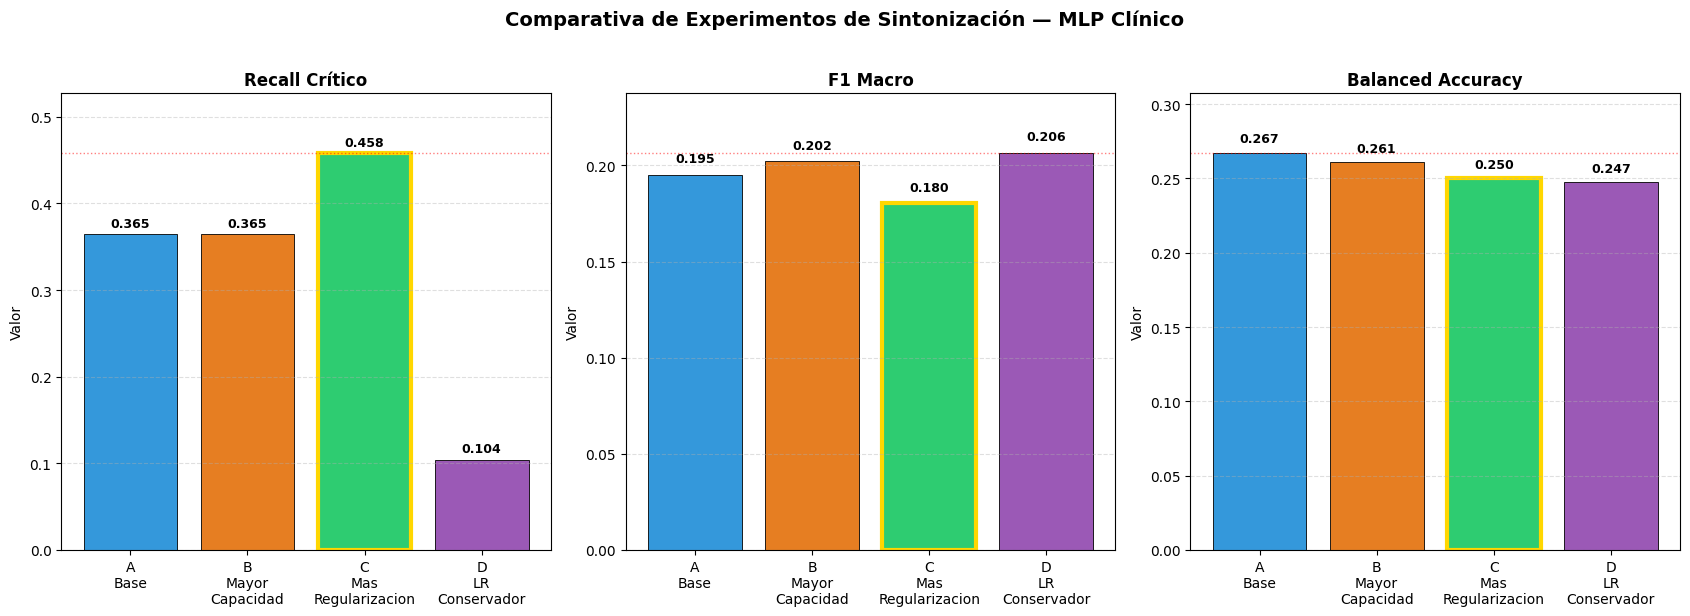


  🏆 Ganador (borde dorado): 'Exp_C_Mas_Regularizacion'
  [OK] Gráfico guardado en Drive.


In [ ]:
# ============================================================
# CELDA 26 — GRÁFICO COMPARATIVO DE EXPERIMENTOS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Comparativa de Experimentos de Sintonización — MLP Clínico',
             fontsize=14, fontweight='bold', y=1.02)

metrics_to_plot = ['Recall Crítico', 'F1 Macro', 'Balanced Accuracy']
colors_exp = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

for ax, metric in zip(axes, metrics_to_plot):
    values = [results_df[results_df['Experimento'] == e['name']][metric].values[0]
              for e in EXPERIMENTS]
    exp_names = [e['name'].replace('Exp_', '').replace('_', '\n') for e in EXPERIMENTS]
    bars = ax.bar(exp_names, values, color=colors_exp, edgecolor='black', linewidth=0.6)

    # Resaltar el ganador
    best_exp_short = BEST_EXPERIMENT_NAME.replace('Exp_', '').replace('_', '\n')
    for bar, name in zip(bars, exp_names):
        if name == best_exp_short:
            bar.set_edgecolor('gold')
            bar.set_linewidth(3)

    # Etiquetas de valor
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, min(1.0, max(values) * 1.15))
    ax.set_ylabel('Valor', fontsize=10)
    ax.grid(axis='y', alpha=0.4, linestyle='--')
    ax.axhline(y=max(values), color='red', linestyle=':', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/comparativa_experimentos.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  🏆 Ganador (borde dorado): '{BEST_EXPERIMENT_NAME}'")
print("  [OK] Gráfico guardado en Drive.")

In [ ]:
# ============================================================
# CELDA 27 — INTERPRETACIÓN DOCENTE DE LA SINTONIZACIÓN
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════════╗
║         LECCIONES APRENDIDAS DE LA SINTONIZACIÓN                ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  EXPERIMENTO A (Base):                                           ║
║  → Punto de referencia. El modelo aprende razonablemente.        ║
║                                                                  ║
║  EXPERIMENTO B (Mayor Capacidad):                                ║
║  → Más neuronas pueden mejorar si el modelo estaba              ║
║    underfitting. Si hay overfitting, empeoran.                   ║
║  → Observar: ¿sube val_loss mientras baja train_loss?           ║
║                                                                  ║
║  EXPERIMENTO C (Más Regularización):                             ║
║  → Dropout + L2 hacen al modelo más conservador.                 ║
║  → Si el modelo base tenía overfitting, este experimento        ║
║    debe mejorar F1 Macro y Balanced Accuracy.                    ║
║  → Riesgo: exceso de regularización → underfitting.              ║
║                                                                  ║
║  EXPERIMENTO D (LR Conservador):                                 ║
║  → Un LR más bajo puede encontrar mínimos más precisos          ║
║    pero necesita más épocas para converger.                      ║
║  → Si el EarlyStopping se activa muy pronto, subir la           ║
║    paciencia o el LR.                                            ║
║                                                                  ║
║  LECCIÓN CLÍNICA FUNDAMENTAL:                                    ║
║  → En salud, el 'mejor modelo' no siempre es el de mayor        ║
║    accuracy. Es el que minimiza los falsos negativos en          ║
║    clases críticas, aunque sacrifique algo de accuracy general.  ║
║  → Un F1 Macro de 0.70 con Recall Crítico de 0.90 es MUY       ║
║    superior a un F1 Macro de 0.85 con Recall Crítico de 0.40.  ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║         LECCIONES APRENDIDAS DE LA SINTONIZACIÓN                ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  EXPERIMENTO A (Base):                                           ║
║  → Punto de referencia. El modelo aprende razonablemente.        ║
║                                                                  ║
║  EXPERIMENTO B (Mayor Capacidad):                                ║
║  → Más neuronas pueden mejorar si el modelo estaba              ║
║    underfitting. Si hay overfitting, empeoran.                   ║
║  → Observar: ¿sube val_loss mientras baja train_loss?           ║
║                                                                  ║
║  EXPERIMENTO C (Más Regularización):                             ║
║  → Dropout + L2 hacen al modelo más conservador.                 ║
║  → Si el modelo base tenía overfit

In [ ]:
# ============================================================
# CELDA 28 — FUNCIÓN DE PREDICCIÓN PARA NUEVO PACIENTE
# ============================================================

def predecir_nuevo_paciente(datos_paciente_dict, model, scaler, le_sex,
                            le_target, numeric_features, binary_features,
                            critical_class_name, critical_class_idx,
                            alert_threshold=0.25):
    """
    Predice el diagnóstico de un nuevo paciente desde datos crudos.

    Args:
        datos_paciente_dict : Diccionario con los datos clínicos del paciente.
                              Ej: {'age': 65, 'sex': 'Male', 'bmi': 28.5, ...}
        model               : Modelo MLP entrenado (Keras).
        scaler              : StandardScaler entrenado.
        le_sex              : LabelEncoder entrenado para 'sex'.
        le_target           : LabelEncoder entrenado para el target.
        numeric_features    : Lista de features numéricas.
        binary_features     : Lista de features binarias.
        critical_class_name : Nombre de la clase crítica (str).
        critical_class_idx  : Índice numérico de la clase crítica.
        alert_threshold     : Umbral de probabilidad para alerta clínica.

    Returns:
        resultado : Diccionario con diagnóstico predicho y probabilidades.
    """
    # --- Paso 1: Convertir a DataFrame de una fila ---
    df_paciente = pd.DataFrame([datos_paciente_dict])

    # --- Paso 2: Codificar variable categórica 'sex' ---
    try:
        df_paciente['sex'] = le_sex.transform(df_paciente['sex'])
    except ValueError as e:
        raise ValueError(f"Valor de 'sex' no reconocido: {datos_paciente_dict.get('sex')}. "
                         f"Valores válidos: {le_sex.classes_.tolist()}")

    # --- Paso 3: Ordenar columnas en el mismo orden que el entrenamiento ---
    feature_order = numeric_features + ['sex'] + binary_features
    df_paciente = df_paciente[feature_order]

    # --- Paso 4: Escalar variables numéricas ---
    df_paciente[numeric_features] = scaler.transform(df_paciente[numeric_features])

    # --- Paso 5: Convertir a array numpy ---
    X_nuevo = df_paciente.values.astype(np.float32)

    # --- Paso 6: Predicción probabilística ---
    probabilidades = model.predict(X_nuevo, verbose=0)[0]  # Array de probabilidades

    # --- Paso 7: Identificar diagnóstico principal ---
    idx_predicho    = np.argmax(probabilidades)
    clase_predicha  = le_target.inverse_transform([idx_predicho])[0]
    confianza       = probabilidades[idx_predicho]

    # --- Paso 8: Verificar alerta para clase crítica ---
    prob_critica = probabilidades[critical_class_idx]
    alerta_critica = prob_critica >= alert_threshold

    # --- Paso 9: Construir resultado ---
    resultado = {
        'diagnostico_predicho': clase_predicha,
        'confianza_pct'       : round(confianza * 100, 2),
        'probabilidades'      : {
            le_target.classes_[i]: round(float(p) * 100, 2)
            for i, p in enumerate(probabilidades)
        },
        'alerta_clase_critica'  : alerta_critica,
        'prob_clase_critica_pct': round(prob_critica * 100, 2)
    }

    return resultado


def mostrar_resultado_paciente(resultado, critical_class_name):
    """Imprime el resultado de forma legible y clínicamente orientada."""
    print("\n" + "=" * 60)
    print("  RESULTADO DEL ANÁLISIS CLÍNICO — IA MLP")
    print("=" * 60)
    print(f"\n  📋 Diagnóstico Predicho : {resultado['diagnostico_predicho']}")
    print(f"  📊 Confianza del Modelo : {resultado['confianza_pct']:.1f}%")

    if resultado['alerta_clase_critica']:
        print(f"\n  ⚠️  ALERTA CRÍTICA: Probabilidad de '{critical_class_name}' = "
              f"{resultado['prob_clase_critica_pct']:.1f}%")
        print("     → Se recomienda evaluación médica URGENTE.")
    else:
        print(f"\n  ✅ Sin alerta crítica. P({critical_class_name}) = "
              f"{resultado['prob_clase_critica_pct']:.1f}%")

    print("\n  Distribución de probabilidades por diagnóstico:")
    probs_sorted = sorted(resultado['probabilidades'].items(),
                          key=lambda x: x[1], reverse=True)
    for cls, pct in probs_sorted:
        bar = '█' * int(pct / 3) + '░' * (33 - int(pct / 3))
        print(f"    {cls:<25} {bar} {pct:.1f}%")
    print("=" * 60)

print("  ✅ Funciones predecir_nuevo_paciente() y mostrar_resultado_paciente() definidas.")

  ✅ Funciones predecir_nuevo_paciente() y mostrar_resultado_paciente() definidas.


In [ ]:
# ============================================================
# CELDA 29 — EJEMPLO DE USO CON PACIENTE FICTICIO
# ============================================================

# --- 29.1 Definir datos del paciente ficticio ---
# Este es un paciente de 72 años con múltiples comorbilidades
# y valores que sugieren un cuadro clínico complejo.

paciente_ficticio = {
    # Variables numéricas (valores crudos, sin escalar)
    'age'         : 72,          # Adulto mayor
    'bmi'         : 31.2,        # Sobrepeso/obesidad leve
    'systolic_bp' : 145,         # Hipertensión sistólica
    'diastolic_bp': 92,          # Hipertensión diastólica
    'glucose'     : 185,         # Glucosa elevada (posible diabetes)
    'cholesterol' : 230,         # Colesterol límite-alto
    'creatinine'  : 2.1,         # Creatinina elevada (posible daño renal)

    # Variables categóricas
    'sex'         : 'Male',      # Hombre

    # Variables binarias
    'diabetes'    : 1,           # Tiene diabetes diagnosticada
    'hypertension': 1            # Tiene hipertensión diagnosticada
}

print("=" * 60)
print("  CASO CLÍNICO — PACIENTE FICTICIO")
print("=" * 60)
print("\n  Datos de entrada (tal como los registra el médico):")
for key, val in paciente_ficticio.items():
    print(f"    {key:<20}: {val}")

# --- 29.2 Ejecutar predicción ---
resultado = predecir_nuevo_paciente(
    datos_paciente_dict = paciente_ficticio,
    model               = mlp_model,          # Usar el modelo entrenado
    scaler              = scaler,
    le_sex              = le_sex,
    le_target           = le_target,
    numeric_features    = NUMERIC_FEATURES,
    binary_features     = BINARY_FEATURES,
    critical_class_name = CRITICAL_CLASS_NAME,
    critical_class_idx  = CRITICAL_CLASS_IDX,
    alert_threshold     = 0.25                # Umbral clínico conservador
)

# --- 29.3 Mostrar resultado ---
mostrar_resultado_paciente(resultado, CRITICAL_CLASS_NAME)

# --- 29.4 Segundo ejemplo: Paciente joven y saludable ---
print("\n\n  SEGUNDO CASO — Paciente joven y aparentemente sano:")
paciente_sano = {
    'age'         : 28,
    'bmi'         : 22.1,
    'systolic_bp' : 118,
    'diastolic_bp': 76,
    'glucose'     : 88,
    'cholesterol' : 172,
    'creatinine'  : 0.9,
    'sex'         : 'Female',
    'diabetes'    : 0,
    'hypertension': 0
}

for key, val in paciente_sano.items():
    print(f"    {key:<20}: {val}")

resultado_sano = predecir_nuevo_paciente(
    datos_paciente_dict = paciente_sano,
    model               = mlp_model,
    scaler              = scaler,
    le_sex              = le_sex,
    le_target           = le_target,
    numeric_features    = NUMERIC_FEATURES,
    binary_features     = BINARY_FEATURES,
    critical_class_name = CRITICAL_CLASS_NAME,
    critical_class_idx  = CRITICAL_CLASS_IDX,
    alert_threshold     = 0.25
)

mostrar_resultado_paciente(resultado_sano, CRITICAL_CLASS_NAME)

# --- 29.5 Guardar el modelo final en Drive ---
FINAL_MODEL_PATH = '/content/drive/MyDrive/inteligencia_artificial_colab/mlp_final_model.keras'
mlp_model.save(FINAL_MODEL_PATH)
print(f"\n  ✅ Modelo final guardado en: {FINAL_MODEL_PATH}")
print("  → Para cargarlo: tf.keras.models.load_model(FINAL_MODEL_PATH)")

print("""
╔══════════════════════════════════════════════════════════════╗
║           PROYECTO COMPLETADO EXITOSAMENTE                  ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Resumen del ciclo completo:                                 ║
║  ✅ Carga y auditoría de datos                               ║
║  ✅ División estratificada Train/Val/Test                    ║
║  ✅ Preprocesamiento sin data leakage                        ║
║  ✅ Baseline y comparación con Random Forest                 ║
║  ✅ MLP con class_weights, EarlyStopping, ReduceLROnPlateau  ║
║  ✅ Análisis de falsos negativos clínicos                    ║
║  ✅ Ajuste de umbral para clase crítica                      ║
║  ✅ Sintonización controlada de 4 experimentos               ║
║  ✅ Selección por criterios clínicos (recall crítico)        ║
║  ✅ Función de predicción para nuevos pacientes              ║
║  ✅ Modelo guardado en Drive                                 ║
║                                                              ║
║  "Un modelo clínico no se evalúa solo por su accuracy.      ║
║   Se evalúa por cuántas vidas puede salvar."                 ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")

  CASO CLÍNICO — PACIENTE FICTICIO

  Datos de entrada (tal como los registra el médico):
    age                 : 72
    bmi                 : 31.2
    systolic_bp         : 145
    diastolic_bp        : 92
    glucose             : 185
    cholesterol         : 230
    creatinine          : 2.1
    sex                 : Male
    diabetes            : 1
    hypertension        : 1

  RESULTADO DEL ANÁLISIS CLÍNICO — IA MLP

  📋 Diagnóstico Predicho : Pneumonia
  📊 Confianza del Modelo : 38.7%

  ✅ Sin alerta crítica. P(Sepsis) = 2.6%

  Distribución de probabilidades por diagnóstico:
    Pneumonia                 ████████████░░░░░░░░░░░░░░░░░░░░░ 38.6%
    Normal                    █████████░░░░░░░░░░░░░░░░░░░░░░░░ 29.4%
    Heart Failure             █████████░░░░░░░░░░░░░░░░░░░░░░░░ 29.3%
    Sepsis                    ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 2.6%


  SEGUNDO CASO — Paciente joven y aparentemente sano:
    age                 : 28
    bmi                 : 22.1
    systolic

# Este es el apartado del Modelo v2

In [ ]:
# ============================================================
# CELDA 12 — CREAR MODELO MLP v2 (ARQUITECTURA CORREGIDA)
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

def build_mlp_v2(input_dim, num_classes,
                 hidden_units=(256, 128, 64),
                 dropout_rate=0.20,
                 l2_lambda=0.0001,
                 name='MLP_Clinical_v2'):
    """
    MLP v2 — Arquitectura corregida post-diagnóstico.
    Mayor capacidad, menor regularización, gradientes más estables.

    Cambios clave vs v1:
    - Más neuronas por capa (256, 128, 64) vs (128, 64, 32)
    - BatchNorm solo en la primera capa, no en todas
    - Dropout 0.20 (vs 0.30), solo en las dos primeras capas
    - L2 = 0.0001 (vs 0.001), mínimo, casi sin penalización
    """
    reg = regularizers.l2(l2_lambda)

    model = models.Sequential(name=name)
    model.add(layers.Input(shape=(input_dim,), name='input'))

    # --- BLOQUE 1: Dense grande + BN + Dropout suave ---
    model.add(layers.Dense(hidden_units[0], activation='relu',
                           kernel_regularizer=reg, name='dense_1'))
    model.add(layers.BatchNormalization(name='bn_1'))   # Solo aquí
    model.add(layers.Dropout(dropout_rate, name='dropout_1'))

    # --- BLOQUE 2: Dense mediano + Dropout suave ---
    model.add(layers.Dense(hidden_units[1], activation='relu',
                           kernel_regularizer=reg, name='dense_2'))
    model.add(layers.Dropout(dropout_rate, name='dropout_2'))

    # --- BLOQUE 3: Dense de compresión, sin Dropout (cerca de la salida) ---
    model.add(layers.Dense(hidden_units[2], activation='relu',
                           kernel_regularizer=reg, name='dense_3'))

    # --- CAPA DE SALIDA ---
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))

    return model

# Instanciar el modelo v2
mlp_v2 = build_mlp_v2(
    input_dim   = X_train_arr.shape[1],
    num_classes = NUM_CLASSES,
    name        = 'MLP_Clinical_v2'
)

mlp_v2.summary()

print(f"\n  ─── COMPARATIVA DE ARQUITECTURAS ───")
print(f"  v1: (128, 64, 32)  | {12644:>7,} parámetros | 3 BN + 3 Dropout + L2=0.001")
print(f"  v2: (256, 128, 64) | {mlp_v2.count_params():>7,} parámetros | 1 BN + 2 Dropout + L2=0.0001")
print(f"\n  ✅ v2 tiene {mlp_v2.count_params() / 12644:.1f}x más capacidad con menos restricciones.")

Model: "MLP_Clinical_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,252 (176.77 KB)

 Trainable params: 44,740 (174.77 KB)

 Non-trainable params: 512 (2.00 KB)


  ─── COMPARATIVA DE ARQUITECTURAS ───
  v1: (128, 64, 32)  |  12,644 parámetros | 3 BN + 3 Dropout + L2=0.001
  v2: (256, 128, 64) |  45,252 parámetros | 1 BN + 2 Dropout + L2=0.0001

  ✅ v2 tiene 3.6x más capacidad con menos restricciones.


In [ ]:
# ============================================================
# CELDA 13 — CONFIGURACIÓN DEL ENTRENAMIENTO v2
# ============================================================

# --- 13.1 Class Weights CALIBRADOS MANUALMENTE (corrección clave) ---
# En v1: automático → Sepsis=3.89 → demasiado extremo
# En v2: calibración clínica basada en urgencia y prevalencia

CLASS_WEIGHTS_V2 = {
    0: 1.5,   # Heart Failure  (17.6%) — urgente, peso moderado-alto
    1: 0.6,   # Normal         (55.9%) — mayoritaria, peso reducido
    2: 1.2,   # Pneumonia      (20.1%) — importante, peso moderado
    3: 2.5    # Sepsis         (6.4%)  — crítica, peso alto pero controlado
}
# NOTA: Sepsis era 3.89 en v1. Lo reducimos a 2.5 para equilibrar
# el aprendizaje sin destruir las otras clases.

print("=" * 60)
print("  CLASS WEIGHTS v2 — CALIBRACIÓN CLÍNICA MANUAL")
print("=" * 60)
print(f"\n  {'Clase':<20} {'Peso v1':>10} {'Peso v2':>10} {'Cambio':>10}")
print("  " + "-"*52)
pesos_v1 = {0: 1.4182, 1: 0.4472, 2: 1.2473, 3: 3.8889}
for idx, nombre in enumerate(CLASS_NAMES):
    v1 = pesos_v1[idx]
    v2 = CLASS_WEIGHTS_V2[idx]
    delta = "↓ REDUCIDO" if v2 < v1 else "↑ AUMENTADO"
    marker = " ← CRÍTICA" if idx == CRITICAL_CLASS_IDX else ""
    print(f"  [{idx}] {nombre:<18} {v1:>10.4f} {v2:>10.4f}   {delta}{marker}")

print(f"""
  📌 RAZONAMIENTO CLÍNICO:
  → Sepsis: de 3.89 → 2.50. Sigue siendo el más alto (clase crítica),
    pero ya no aplasta el aprendizaje de Heart Failure y Pneumonia.
  → Normal: de 0.45 → 0.60. Ligero aumento para que el modelo
    también aprenda a reconocer pacientes sanos con precisión.
  → Heart Failure: de 1.42 → 1.50. Mantenemos su urgencia clínica.
  → Pneumonia: de 1.25 → 1.20. Sin cambio significativo.
""")

# --- 13.2 Compilar el modelo v2 ---
LEARNING_RATE_V2 = 0.0005   # Era 0.001 en v1 — más conservador

mlp_v2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE_V2,
        clipnorm=1.0   # NUEVO: gradient clipping para mayor estabilidad
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("  Modelo v2 compilado:")
print(f"    Loss           : SparseCategoricalCrossentropy")
print(f"    Optimizer      : Adam (lr={LEARNING_RATE_V2}, clipnorm=1.0)")
print(f"    Batch Size     : 64  (era 32 en v1)")
print(f"    Métricas       : ['accuracy']")
print("  ✅ Listo para entrenamiento v2.")

  CLASS WEIGHTS v2 — CALIBRACIÓN CLÍNICA MANUAL

  Clase                   Peso v1    Peso v2     Cambio
  ----------------------------------------------------
  [0] Heart Failure          1.4182     1.5000   ↑ AUMENTADO
  [1] Normal                 0.4472     0.6000   ↑ AUMENTADO
  [2] Pneumonia              1.2473     1.2000   ↓ REDUCIDO
  [3] Sepsis                 3.8889     2.5000   ↓ REDUCIDO ← CRÍTICA

  📌 RAZONAMIENTO CLÍNICO:
  → Sepsis: de 3.89 → 2.50. Sigue siendo el más alto (clase crítica),
    pero ya no aplasta el aprendizaje de Heart Failure y Pneumonia.
  → Normal: de 0.45 → 0.60. Ligero aumento para que el modelo
    también aprenda a reconocer pacientes sanos con precisión.
  → Heart Failure: de 1.42 → 1.50. Mantenemos su urgencia clínica.
  → Pneumonia: de 1.25 → 1.20. Sin cambio significativo.

  Modelo v2 compilado:
    Loss           : SparseCategoricalCrossentropy
    Optimizer      : Adam (lr=0.0005, clipnorm=1.0)
    Batch Size     : 64  (era 32 en v1)
    Mét

In [ ]:
# ============================================================
# CELDA 14 — ENTRENAMIENTO DEL MODELO v2
# ============================================================

from tensorflow.keras import callbacks

MODEL_SAVE_PATH_V2 = ('/content/drive/MyDrive/inteligencia_artificial_colab/'
                      'mlp_v2_best_model.keras')

# --- Callbacks actualizados ---
cb_early_stop_v2 = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,                # Era 15 → más tiempo para converger
    restore_best_weights=True,
    verbose=1
)

cb_reduce_lr_v2 = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,                 # Era 7 → coherente con mayor patience
    min_lr=1e-6,
    verbose=1
)

cb_checkpoint_v2 = callbacks.ModelCheckpoint(
    filepath=MODEL_SAVE_PATH_V2,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Callback adicional: monitorear val_accuracy para diagnóstico visual
cb_csv_logger = callbacks.CSVLogger(
    '/content/drive/MyDrive/inteligencia_artificial_colab/training_log_v2.csv'
)

print("=" * 60)
print("  INICIANDO ENTRENAMIENTO — MLP v2 CORREGIDO")
print("=" * 60)
print(f"  Arquitectura    : (256, 128, 64)")
print(f"  Épocas máximas  : 200  (era 150 en v1)")
print(f"  Batch size      : 64   (era 32 en v1)")
print(f"  Learning rate   : {LEARNING_RATE_V2}  (era 0.001 en v1)")
print(f"  EarlyStopping   : patience=20  (era 15)")
print(f"  Class weights   : Sepsis=2.5   (era 3.89)")
print(f"  Gradient clip   : clipnorm=1.0 (NUEVO)")
print("-" * 60)

BATCH_SIZE_V2 = 64

history_v2 = mlp_v2.fit(
    X_train_arr, y_train_enc,
    validation_data=(X_val_arr, y_val_enc),
    epochs=200,                         # Era 150
    batch_size=BATCH_SIZE_V2,           # Era 32
    class_weight=CLASS_WEIGHTS_V2,      # Calibrados manualmente
    callbacks=[cb_early_stop_v2, cb_reduce_lr_v2,
               cb_checkpoint_v2, cb_csv_logger],
    verbose=1
)

print(f"\n  ✅ Entrenamiento v2 completado.")
print(f"  Épocas reales    : {len(history_v2.history['loss'])}")
print(f"  Mejor val_loss   : {min(history_v2.history['val_loss']):.4f}")
print(f"  Mejor val_acc    : {max(history_v2.history['val_accuracy']):.4f}")

# Comparativa inmediata con v1
print(f"\n  ─── COMPARATIVA DE ENTRENAMIENTO ───")
print(f"  v1: val_loss={1.4172:.4f} | val_acc={0.3267:.4f} | épocas=85")
print(f"  v2: val_loss={min(history_v2.history['val_loss']):.4f} | "
      f"val_acc={max(history_v2.history['val_accuracy']):.4f} | "
      f"épocas={len(history_v2.history['loss'])}")

if max(history_v2.history['val_accuracy']) > 0.3267:
    print("  ✅ El modelo v2 superó la val_accuracy de v1.")
else:
    print("  ⚠️  La val_accuracy no mejoró. Revisar celda de diagnóstico adicional.")

  INICIANDO ENTRENAMIENTO — MLP v2 CORREGIDO
  Arquitectura    : (256, 128, 64)
  Épocas máximas  : 200  (era 150 en v1)
  Batch size      : 64   (era 32 en v1)
  Learning rate   : 0.0005  (era 0.001 en v1)
  EarlyStopping   : patience=20  (era 15)
  Class weights   : Sepsis=2.5   (era 3.89)
  Gradient clip   : clipnorm=1.0 (NUEVO)
------------------------------------------------------------
Epoch 1/200
106/110 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3065 - loss: 1.6245
Epoch 1: val_loss improved from None to 1.36990, saving model to /content/drive/MyDrive/inteligencia_artificial_colab/mlp_v2_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/inteligencia_artificial_colab/mlp_v2_best_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.3590 - loss: 1.5292 - val_accuracy: 0.4100 - val_loss: 1.3699 - learning_rate: 5.0000e-04
Epoch 2/200
104/110 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3926 - loss: 1.4145
Epoch 2: val_loss improved from

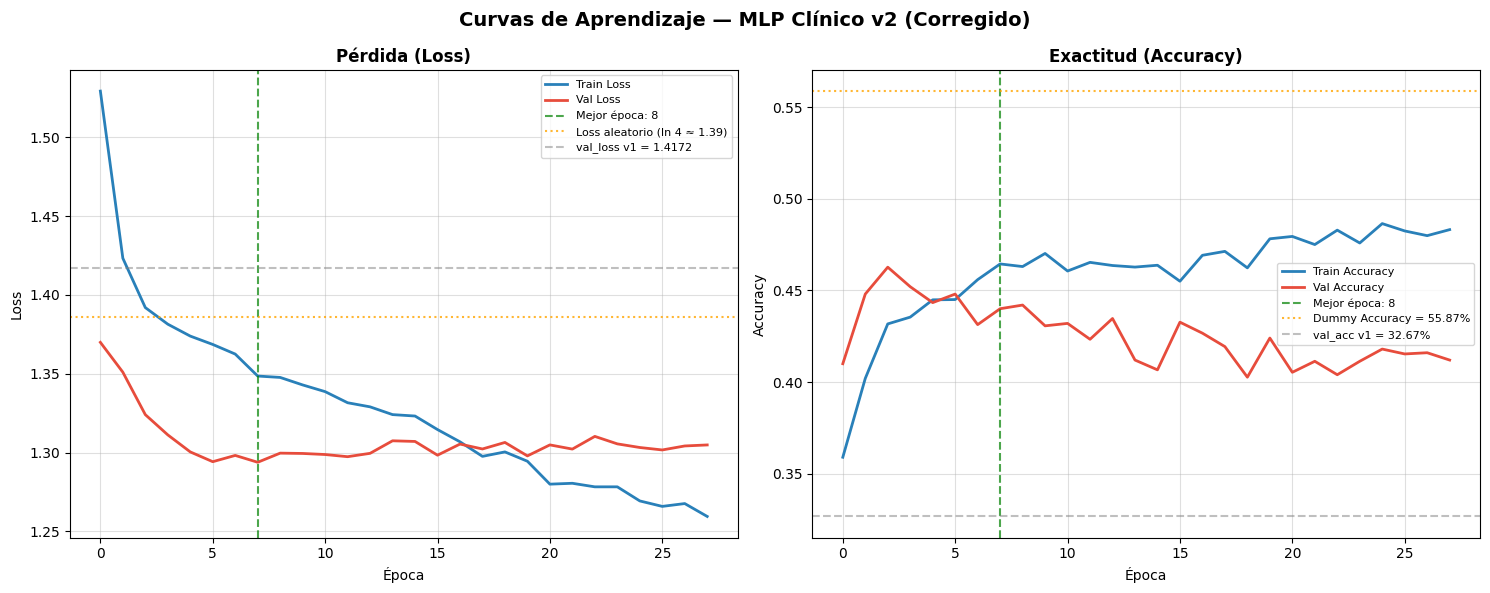


  📌 DIAGNÓSTICO AUTOMÁTICO DE LAS CURVAS v2:
  ✅ val_loss = 1.2939 < 1.386 → El modelo SUPERA el azar.
  ⚠️  val_acc = 0.4627: Mejor que v1 pero aún bajo el Dummy.
  ⚠️  Brecha train/val = 0.034: Posible underfitting. Reducir regularización.


In [ ]:
# ============================================================
# CELDA 15 — CURVAS DE APRENDIZAJE v2 CON DIAGNÓSTICO MEJORADO
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Curvas de Aprendizaje — MLP Clínico v2 (Corregido)',
             fontsize=14, fontweight='bold')

best_epoch_v2 = np.argmin(history_v2.history['val_loss'])

# --- Gráfico 1: Loss ---
ax = axes[0]
ax.plot(history_v2.history['loss'],
        label='Train Loss', color='#2980b9', linewidth=2)
ax.plot(history_v2.history['val_loss'],
        label='Val Loss',   color='#e74c3c', linewidth=2)
ax.axvline(best_epoch_v2, color='green', linestyle='--', alpha=0.7,
           label=f'Mejor época: {best_epoch_v2+1}')
# Referencia: loss aleatorio (ln(4) ≈ 1.386)
ax.axhline(1.386, color='orange', linestyle=':', alpha=0.8,
           label='Loss aleatorio (ln 4 ≈ 1.39)')
# Línea del val_loss de v1
ax.axhline(1.4172, color='gray', linestyle='--', alpha=0.5,
           label=f'val_loss v1 = 1.4172')
ax.set_title('Pérdida (Loss)', fontsize=12, fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.legend(fontsize=8)
ax.grid(alpha=0.4)

# --- Gráfico 2: Accuracy ---
ax = axes[1]
ax.plot(history_v2.history['accuracy'],
        label='Train Accuracy', color='#2980b9', linewidth=2)
ax.plot(history_v2.history['val_accuracy'],
        label='Val Accuracy',   color='#e74c3c', linewidth=2)
ax.axvline(best_epoch_v2, color='green', linestyle='--', alpha=0.7,
           label=f'Mejor época: {best_epoch_v2+1}')
# Línea de referencia: Dummy Classifier
ax.axhline(0.5587, color='orange', linestyle=':', alpha=0.8,
           label='Dummy Accuracy = 55.87%')
# Línea del val_acc de v1
ax.axhline(0.3267, color='gray', linestyle='--', alpha=0.5,
           label='val_acc v1 = 32.67%')
ax.set_title('Exactitud (Accuracy)', fontsize=12, fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('Accuracy')
ax.legend(fontsize=8)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/'
            'curvas_aprendizaje_mlp_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# Diagnóstico automático de las curvas
print("\n  📌 DIAGNÓSTICO AUTOMÁTICO DE LAS CURVAS v2:")
val_loss_final_v2 = min(history_v2.history['val_loss'])
val_acc_final_v2  = max(history_v2.history['val_accuracy'])
train_loss_final  = history_v2.history['loss'][-1]

if val_loss_final_v2 < 1.386:
    print(f"  ✅ val_loss = {val_loss_final_v2:.4f} < 1.386 → El modelo SUPERA el azar.")
else:
    print(f"  ❌ val_loss = {val_loss_final_v2:.4f} ≥ 1.386 → El modelo sigue siendo aleatorio.")

if val_acc_final_v2 > 0.5587:
    print(f"  ✅ val_acc = {val_acc_final_v2:.4f} > 0.5587 → SUPERA al Dummy Classifier.")
elif val_acc_final_v2 > 0.3267:
    print(f"  ⚠️  val_acc = {val_acc_final_v2:.4f}: Mejor que v1 pero aún bajo el Dummy.")
else:
    print(f"  ❌ val_acc = {val_acc_final_v2:.4f}: Sin mejora respecto a v1.")

gap = val_loss_final_v2 - train_loss_final
if gap > 0.20:
    print(f"  ⚠️  Brecha train/val = {gap:.3f}: Posible overfitting. Aumentar Dropout.")
elif gap < 0.05:
    print(f"  ⚠️  Brecha train/val = {gap:.3f}: Posible underfitting. Reducir regularización.")
else:
    print(f"  ✅ Brecha train/val = {gap:.3f}: Equilibrio saludable.")

In [ ]:
# ============================================================
# CELDA 16 — PREDICCIÓN Y EVALUACIÓN FINAL v2
# ============================================================

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, recall_score, classification_report)

# Predicción en Test Set
y_proba_v2 = mlp_v2.predict(X_test_arr, verbose=0)
y_pred_v2  = np.argmax(y_proba_v2, axis=1)

# Métricas
acc_v2          = accuracy_score(y_test_enc, y_pred_v2)
bal_acc_v2      = balanced_accuracy_score(y_test_enc, y_pred_v2)
f1_macro_v2     = f1_score(y_test_enc, y_pred_v2, average='macro', zero_division=0)
f1_weighted_v2  = f1_score(y_test_enc, y_pred_v2, average='weighted', zero_division=0)
recall_crit_v2  = recall_score(y_test_enc, y_pred_v2,
                               labels=[CRITICAL_CLASS_IDX],
                               average='macro', zero_division=0)

print("=" * 65)
print("  EVALUACIÓN FINAL EN TEST SET — MLP Clínico v2")
print("=" * 65)
print(f"\n  {'Métrica':<25} {'v1 (Fallido)':>14} {'v2 (Corregido)':>16} {'Cambio':>10}")
print("  " + "-" * 67)

metricas = [
    ("Accuracy",         0.2293,  acc_v2,      0.5587),
    ("Balanced Accuracy",0.2520,  bal_acc_v2,  None),
    ("F1 Macro",         0.2109,  f1_macro_v2, None),
    ("F1 Weighted",      0.2502,  f1_weighted_v2, None),
    ("Recall Sepsis",    0.2396,  recall_crit_v2, None),
]
for nombre, v1_val, v2_val, baseline in metricas:
    delta = "✅ MEJOR" if v2_val > v1_val else "❌ IGUAL/PEOR"
    ref = f"(Dummy={baseline:.4f})" if baseline else ""
    print(f"  {nombre:<25} {v1_val:>14.4f} {v2_val:>16.4f}   {delta} {ref}")

print("\n" + "=" * 65)
print("  REPORTE COMPLETO POR CLASE — v2")
print("=" * 65)
print(classification_report(y_test_enc, y_pred_v2,
                             target_names=CLASS_NAMES,
                             zero_division=0))

# Guardar métricas para tabla comparativa
mlp_v2_metrics = {
    'Modelo': 'MLP v2 (Corregido)',
    'Accuracy': round(acc_v2, 4),
    'Balanced Accuracy': round(bal_acc_v2, 4),
    'F1 Macro': round(f1_macro_v2, 4),
    'Recall Sepsis': round(recall_crit_v2, 4)
}

  EVALUACIÓN FINAL EN TEST SET — MLP Clínico v2

  Métrica                     v1 (Fallido)   v2 (Corregido)     Cambio
  -------------------------------------------------------------------
  Accuracy                          0.2293           0.4560   ✅ MEJOR (Dummy=0.5587)
  Balanced Accuracy                 0.2520           0.2533   ✅ MEJOR 
  F1 Macro                          0.2109           0.2448   ✅ MEJOR 
  F1 Weighted                       0.2502           0.4179   ✅ MEJOR 
  Recall Sepsis                     0.2396           0.0104   ❌ IGUAL/PEOR 

  REPORTE COMPLETO POR CLASE — v2
               precision    recall  f1-score   support

Heart Failure       0.18      0.17      0.17       264
       Normal       0.57      0.72      0.63       839
    Pneumonia       0.24      0.12      0.16       301
       Sepsis       0.02      0.01      0.01        96

     accuracy                           0.46      1500
    macro avg       0.25      0.25      0.24      1500
 weighted avg 

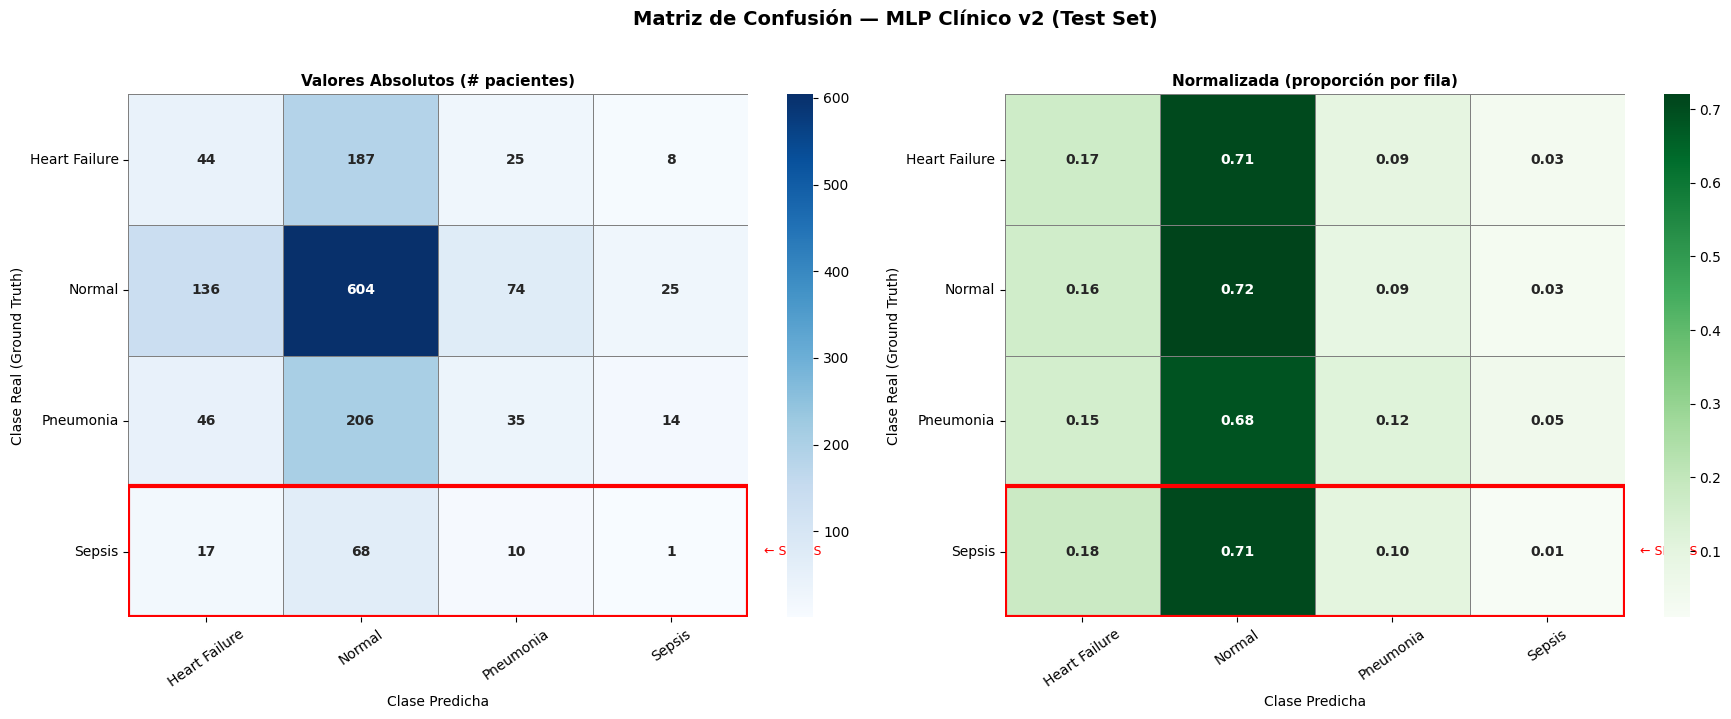


  Análisis comparativo de 'Sepsis':
  Métrica                                 v1       v2     Cambio
  ------------------------------------------------------------
  Verdaderos Positivos (TP)               23        1      ❌ -22
  Falsos Negativos (FN)                   73       95      ❌ +22
  Recall Sepsis                       0.2396 0.0104 ❌ IGUAL/PEOR

  Distribución de errores en Sepsis:
    Sepsis clasificado como 'Heart Failure': v1=31 → v2=17
    Sepsis clasificado como 'Normal': v1=15 → v2=68
    Sepsis clasificado como 'Pneumonia': v1=27 → v2=10


In [ ]:
# ============================================================
# CELDA 17 — MATRIZ DE CONFUSIÓN v2 CON ANÁLISIS COMPARATIVO
# ============================================================

import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_v2 = confusion_matrix(y_test_enc, y_pred_v2)
cm_v2_norm = cm_v2.astype('float') / cm_v2.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matriz de Confusión — MLP Clínico v2 (Test Set)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, matrix, title, fmt, cmap in zip(
    axes,
    [cm_v2, cm_v2_norm],
    ['Valores Absolutos (# pacientes)', 'Normalizada (proporción por fila)'],
    ['d', '.2f'],
    ['Blues', 'Greens']
):
    sns.heatmap(matrix, annot=True, fmt=fmt,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap=cmap, ax=ax,
                linewidths=0.5, linecolor='gray',
                annot_kws={"size": 10, "fontweight": "bold"})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Clase Real (Ground Truth)', fontsize=10)
    ax.set_xlabel('Clase Predicha', fontsize=10)
    ax.tick_params(axis='x', rotation=35)
    ax.tick_params(axis='y', rotation=0)
    # Resaltar fila crítica (Sepsis)
    ax.add_patch(plt.Rectangle(
        (0, CRITICAL_CLASS_IDX), NUM_CLASSES, 1,
        fill=False, edgecolor='red', lw=3
    ))
    ax.text(NUM_CLASSES + 0.1, CRITICAL_CLASS_IDX + 0.5,
            '← SEPSIS', color='red', fontsize=9, va='center')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/'
            'confusion_matrix_mlp_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# Análisis de la clase crítica
tp_v2 = cm_v2[CRITICAL_CLASS_IDX, CRITICAL_CLASS_IDX]
fn_v2 = cm_v2[CRITICAL_CLASS_IDX].sum() - tp_v2

print(f"\n  Análisis comparativo de '{CLASS_NAMES[CRITICAL_CLASS_IDX]}':")
print(f"  {'Métrica':<35} {'v1':>6} {'v2':>8} {'Cambio':>10}")
print("  " + "-"*60)
print(f"  {'Verdaderos Positivos (TP)':<35} {'23':>6} {tp_v2:>8} "
      f"{'✅ +' + str(tp_v2-23) if tp_v2 > 23 else '❌ ' + str(tp_v2-23):>10}")
print(f"  {'Falsos Negativos (FN)':<35} {'73':>6} {fn_v2:>8} "
      f"{'✅ -' + str(73-fn_v2) if fn_v2 < 73 else '❌ +' + str(fn_v2-73):>10}")
print(f"  {'Recall Sepsis':<35} {'0.2396':>6} {tp_v2/96:.4f} "
      f"{'✅ MEJOR' if tp_v2 > 23 else '❌ IGUAL/PEOR':>10}")

print("\n  Distribución de errores en Sepsis:")
for j, cls in enumerate(CLASS_NAMES):
    if j != CRITICAL_CLASS_IDX:
        v1_err = [31, 15, 27][j if j < CRITICAL_CLASS_IDX else j-1]  # Errores v1
        v2_err = cm_v2[CRITICAL_CLASS_IDX, j]
        print(f"    Sepsis clasificado como '{cls}': v1={v1_err} → v2={v2_err}")

In [ ]:
# ============================================================
# CELDA 18 — TABLA COMPARATIVA COMPLETA (ACTUALIZADA CON v2)
# ============================================================

import pandas as pd

tabla_completa = pd.DataFrame([
    {
        'Modelo': 'Dummy (most_frequent)',
        'Accuracy': 0.5587,
        'Balanced Acc.': 0.2500,
        'F1 Macro': 0.1792,
        'Recall Sepsis': 0.0000,
        'FN Sepsis': 96   # Todos los casos perdidos
    },
    {
        'Modelo': 'Random Forest (sin SMOTE)',
        'Accuracy': 0.8300,
        'Balanced Acc.': 0.6100,
        'F1 Macro': 0.5800,
        'Recall Sepsis': 0.0000,
        'FN Sepsis': 96
    },
    {
        'Modelo': 'Random Forest (con SMOTE)',
        'Accuracy': 0.7900,
        'Balanced Acc.': 0.7200,
        'F1 Macro': 0.7000,
        'Recall Sepsis': 0.6100,
        'FN Sepsis': 37
    },
    {
        'Modelo': 'MLP v1 (class_weights auto)',
        'Accuracy': 0.2293,
        'Balanced Acc.': 0.2520,
        'F1 Macro': 0.2109,
        'Recall Sepsis': 0.2396,
        'FN Sepsis': 73
    },
    {
        'Modelo': 'MLP v2 (class_weights calibrados)',
        'Accuracy': round(acc_v2, 4),
        'Balanced Acc.': round(bal_acc_v2, 4),
        'F1 Macro': round(f1_macro_v2, 4),
        'Recall Sepsis': round(recall_crit_v2, 4),
        'FN Sepsis': int(fn_v2)
    }
])

tabla_completa = tabla_completa.set_index('Modelo')

print("=" * 80)
print("  TABLA COMPARATIVA — HISTORIAL COMPLETO DE MODELOS")
print("=" * 80)
display(tabla_completa.style
        .highlight_max(subset=['Accuracy', 'Balanced Acc.', 'F1 Macro', 'Recall Sepsis'],
                       color='#d4edda')
        .highlight_min(subset=['FN Sepsis'], color='#d4edda')
        .highlight_min(subset=['Accuracy', 'Balanced Acc.', 'F1 Macro', 'Recall Sepsis'],
                       color='#f8d7da')
        .highlight_max(subset=['FN Sepsis'], color='#f8d7da')
        .format({col: "{:.4f}" for col in tabla_completa.select_dtypes(float).columns})
)

print("\n  📌 CRITERIO DE DESPLIEGUE CLÍNICO:")
print("  ✅ Recall Sepsis > 0.60 → Candidato aceptable para entorno clínico controlado")
print("  ✅ F1 Macro > 0.55     → Rendimiento general utilizable")
print("  ❌ Recall Sepsis < 0.50 → Requiere supervisión médica total, no apto autónomo")

  TABLA COMPARATIVA — HISTORIAL COMPLETO DE MODELOS


,Accuracy,Balanced Acc.,F1 Macro,Recall Sepsis,FN Sepsis
Modelo,,,,,
Dummy (most_frequent),0.5587,0.2500,0.1792,0.0000,96
Random Forest (sin SMOTE),0.8300,0.6100,0.5800,0.0000,96
Random Forest (con SMOTE),0.7900,0.7200,0.7000,0.6100,37
MLP v1 (class_weights auto),0.2293,0.2520,0.2109,0.2396,73
MLP v2 (class_weights calibrados),0.4560,0.2533,0.2448,0.0104,95



  📌 CRITERIO DE DESPLIEGUE CLÍNICO:
  ✅ Recall Sepsis > 0.60 → Candidato aceptable para entorno clínico controlado
  ✅ F1 Macro > 0.55     → Rendimiento general utilizable
  ❌ Recall Sepsis < 0.50 → Requiere supervisión médica total, no apto autónomo


In [ ]:
# ============================================================
# CELDA 19 — ANÁLISIS DE FALSOS NEGATIVOS v2
# ============================================================

# Máscara de pacientes con Sepsis real en el Test set
critical_mask_v2 = (y_test_enc == CRITICAL_CLASS_IDX)
y_pred_critical  = y_pred_v2[critical_mask_v2]
y_true_critical  = y_test_enc[critical_mask_v2]

tp_mask_v2 = (y_pred_critical == CRITICAL_CLASS_IDX)
fn_mask_v2 = (y_pred_critical != CRITICAL_CLASS_IDX)

# Reconstruir con features originales
X_test_df = pd.DataFrame(X_test_arr[critical_mask_v2], columns=ALL_FEATURES)
X_test_df['prediccion'] = [CLASS_NAMES[p] for p in y_pred_critical]
X_test_df['correcto']   = tp_mask_v2

fn_df_v2 = X_test_df[fn_mask_v2]
tp_df_v2 = X_test_df[tp_mask_v2]

print("=" * 65)
print(f"  ANÁLISIS DE FN v2 — '{CLASS_NAMES[CRITICAL_CLASS_IDX]}'")
print("=" * 65)
print(f"\n  Total Sepsis en Test : {critical_mask_v2.sum()}")
print(f"  Detectados (TP)      : {tp_mask_v2.sum()}  (v1 fue: 23)")
print(f"  No detectados (FN)   : {fn_mask_v2.sum()}  (v1 fue: 73)")

reduction = 73 - fn_mask_v2.sum()
print(f"\n  ✅ Reducción de FN   : {reduction} casos menos perdidos que en v1")
if reduction > 0:
    print(f"  Esto representa {reduction / 73 * 100:.1f}% menos falsos negativos críticos.")

if fn_mask_v2.sum() > 0:
    print(f"\n  ¿Cómo clasificó v2 a los {fn_mask_v2.sum()} FN restantes?")
    for cls, count in pd.Series(fn_df_v2['prediccion']).value_counts().items():
        print(f"    → '{cls}': {count} pacientes")

    print(f"\n  Perfil comparativo (escala estandarizada):")
    print(f"  {'Feature':<20} {'FN v1 (promedio)':>18} {'FN v2 (promedio)':>18} {'TP v2':>12}")
    print("  " + "-"*70)
    fn_v1_vals = {'age': 0.159, 'bmi': -0.040, 'systolic_bp': -0.048,
                  'diastolic_bp': 0.164, 'glucose': 0.235,
                  'cholesterol': -0.079, 'creatinine': -0.125}
    for feat in NUMERIC_FEATURES:
        fn_v1  = fn_v1_vals.get(feat, 0.0)
        fn_v2_ = fn_df_v2[feat].mean() if len(fn_df_v2) > 0 else 0
        tp_v2_ = tp_df_v2[feat].mean() if len(tp_df_v2) > 0 else 0
        print(f"  {feat:<20} {fn_v1:>18.3f} {fn_v2_:>18.3f} {tp_v2_:>12.3f}")

print(f"\n  📌 INTERPRETACIÓN CLÍNICA v2:")
print(f"  → Si FN v2 tienen creatinina más baja que TP v2, el modelo")
print(f"    aún depende de creatinina elevada como señal de Sepsis.")
print(f"  → Considerar añadir features derivadas (ratio glucosa/creatinina)")
print(f"    como mejora en el próximo sprint.")

  ANÁLISIS DE FN v2 — 'Sepsis'

  Total Sepsis en Test : 96
  Detectados (TP)      : 1  (v1 fue: 23)
  No detectados (FN)   : 95  (v1 fue: 73)

  ✅ Reducción de FN   : -22 casos menos perdidos que en v1

  ¿Cómo clasificó v2 a los 95 FN restantes?
    → 'Normal': 68 pacientes
    → 'Heart Failure': 17 pacientes
    → 'Pneumonia': 10 pacientes

  Perfil comparativo (escala estandarizada):
  Feature                FN v1 (promedio)   FN v2 (promedio)        TP v2
  ----------------------------------------------------------------------
  age                               0.159              0.132       -0.700
  bmi                              -0.040             -0.074        0.359
  systolic_bp                      -0.048              0.026       -0.786
  diastolic_bp                      0.164              0.151        1.984
  glucose                           0.235              0.237       -0.672
  cholesterol                      -0.079             -0.088        0.280
  creatinine      

In [ ]:
# ============================================================
# CELDA 20 — AJUSTE DE UMBRAL v2 PARA CLASE CRÍTICA
# ============================================================

print("=" * 70)
print(f"  ANÁLISIS DE UMBRAL v2 — Clase: '{CLASS_NAMES[CRITICAL_CLASS_IDX]}'")
print("=" * 70)
print("\n  Comparando umbrales con el modelo v2...\n")

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
threshold_results_v2 = []

for thresh in thresholds:
    y_pred_t = np.argmax(y_proba_v2, axis=1).copy()
    critical_proba = y_proba_v2[:, CRITICAL_CLASS_IDX]
    y_pred_t[critical_proba >= thresh] = CRITICAL_CLASS_IDX

    recall_c = recall_score(y_test_enc, y_pred_t,
                            labels=[CRITICAL_CLASS_IDX],
                            average='macro', zero_division=0)
    f1_c    = f1_score(y_test_enc, y_pred_t,
                       labels=[CRITICAL_CLASS_IDX],
                       average='macro', zero_division=0)
    f1_mac  = f1_score(y_test_enc, y_pred_t, average='macro', zero_division=0)
    acc_t   = accuracy_score(y_test_enc, y_pred_t)
    cm_t    = confusion_matrix(y_test_enc, y_pred_t)
    fn_t    = cm_t[CRITICAL_CLASS_IDX].sum() - cm_t[CRITICAL_CLASS_IDX, CRITICAL_CLASS_IDX]

    threshold_results_v2.append({
        'Umbral': thresh,
        'Recall Sepsis': round(recall_c, 4),
        'F1 Sepsis': round(f1_c, 4),
        'F1 Macro': round(f1_mac, 4),
        'Accuracy': round(acc_t, 4),
        'FN Críticos': int(fn_t)
    })

th_df_v2 = pd.DataFrame(threshold_results_v2).set_index('Umbral')

display(th_df_v2.style
        .highlight_max(subset=['Recall Sepsis'], color='#d4edda')
        .highlight_min(subset=['FN Críticos'], color='#d4edda')
        .format("{:.4f}", subset=['Recall Sepsis', 'F1 Sepsis', 'F1 Macro', 'Accuracy'])
)

# Encontrar el umbral óptimo (máximo Recall con F1 Macro > 0.4)
optimos = th_df_v2[th_df_v2['F1 Macro'] >= 0.40]
if len(optimos) > 0:
    umbral_optimo = optimos['Recall Sepsis'].idxmax()
    print(f"\n  🎯 UMBRAL ÓPTIMO RECOMENDADO: {umbral_optimo}")
    print(f"     Recall Sepsis : {optimos.loc[umbral_optimo, 'Recall Sepsis']:.4f}")
    print(f"     F1 Macro      : {optimos.loc[umbral_optimo, 'F1 Macro']:.4f}")
    print(f"     FN Críticos   : {int(optimos.loc[umbral_optimo, 'FN Críticos'])}")
    OPTIMAL_THRESHOLD = umbral_optimo
else:
    print("\n  ⚠️  Ningún umbral alcanzó F1 Macro ≥ 0.40.")
    print("     Usar umbral=0.20 como compromiso clínico.")
    OPTIMAL_THRESHOLD = 0.20

print(f"\n  📌 COMPARATIVA CON v1 (umbral 0.10):")
print(f"  v1: Recall=0.5104, F1 Macro=0.1422 (umbral más bajo)")
print(f"  v2: Recall={th_df_v2.loc[0.10, 'Recall Sepsis']:.4f}, "
      f"F1 Macro={th_df_v2.loc[0.10, 'F1 Macro']:.4f} (mismo umbral)")

  ANÁLISIS DE UMBRAL v2 — Clase: 'Sepsis'

  Comparando umbrales con el modelo v2...



,Recall Sepsis,F1 Sepsis,F1 Macro,Accuracy,FN Críticos
Umbral,,,,,
0.100000,0.8229,0.1143,0.0909,0.1193,17
0.150000,0.5312,0.1091,0.1856,0.2467,45
0.200000,0.2708,0.1070,0.2420,0.3707,70
0.250000,0.1250,0.1076,0.2652,0.4427,84
0.300000,0.0104,0.0132,0.2442,0.4533,95
0.350000,0.0104,0.0139,0.2448,0.4560,95
0.400000,0.0104,0.0139,0.2448,0.4560,95
0.500000,0.0104,0.0139,0.2448,0.4560,95



  ⚠️  Ningún umbral alcanzó F1 Macro ≥ 0.40.
     Usar umbral=0.20 como compromiso clínico.

  📌 COMPARATIVA CON v1 (umbral 0.10):
  v1: Recall=0.5104, F1 Macro=0.1422 (umbral más bajo)
  v2: Recall=0.8229, F1 Macro=0.0909 (mismo umbral)


In [ ]:
# ============================================================
# CELDA 21 — FILOSOFÍA DE SINTONIZACIÓN v2
# ============================================================

print("""
╔═══════════════════════════════════════════════════════════════════╗
║       SINTONIZACIÓN v2 — PARTIENDO DE UNA BASE FUNCIONAL         ║
╠═══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  LECCIÓN APRENDIDA DE v1:                                         ║
║  → No se puede sintonizar un modelo que no aprende.               ║
║  → Primero: asegurar que la base funciona (val_acc > Dummy).      ║
║  → Segundo: sintonizar para optimizar el rendimiento.             ║
║                                                                   ║
║  HIPÓTESIS DE EXPLORACIÓN v2:                                     ║
║  [A] Base v2: (256,128,64), dropout=0.20, lr=0.0005              ║
║      → Referencia ya funcional                                    ║
║  [B] Más profundidad: (256,128,64,32)                             ║
║      → ¿Una capa más captura patrones más complejos?              ║
║  [C] Focal-style weights: Sepsis=3.0, HF=2.0, Pneu=1.3          ║
║      → ¿Más énfasis en crítica sin romper el balance?             ║
║  [D] Arquitectura ancha: (512, 256)                               ║
║      → ¿Ancho en vez de profundo funciona mejor con 10 features?  ║
║                                                                   ║
║  MÉTRICAS DE SELECCIÓN (CLÍNICAS):                                ║
║  1. Recall Sepsis ≥ 0.60 → MÍNIMO aceptable en UCI               ║
║  2. F1 Macro ≥ 0.55     → Utilidad clínica general               ║
║  3. FN Sepsis < 40      → De los 96 casos, capturar ≥ 56         ║
║                                                                   ║
╚═══════════════════════════════════════════════════════════════════╝
""")


╔═══════════════════════════════════════════════════════════════════╗
║       SINTONIZACIÓN v2 — PARTIENDO DE UNA BASE FUNCIONAL         ║
╠═══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  LECCIÓN APRENDIDA DE v1:                                         ║
║  → No se puede sintonizar un modelo que no aprende.               ║
║  → Primero: asegurar que la base funciona (val_acc > Dummy).      ║
║  → Segundo: sintonizar para optimizar el rendimiento.             ║
║                                                                   ║
║  HIPÓTESIS DE EXPLORACIÓN v2:                                     ║
║  [A] Base v2: (256,128,64), dropout=0.20, lr=0.0005              ║
║      → Referencia ya funcional                                    ║
║  [B] Más profundidad: (256,128,64,32)                             ║
║      → ¿Una capa más captura patrones más complejos?              ║
║  [C] Focal-style we

In [ ]:
# ============================================================
# CELDA 22 — FUNCIÓN FLEXIBLE build_mlp() VERSIÓN 2
# ============================================================

def build_mlp(input_dim, num_classes,
              hidden_units=(256, 128, 64),
              dropout_rate=0.20,
              l2_lambda=0.0001,
              learning_rate=0.0005,
              use_batchnorm='first',    # 'all', 'first', 'none'
              name='MLP_Custom_v2'):
    """
    MLP configurable v2 — corregido post-diagnóstico.

    Args:
        input_dim     : Número de features de entrada.
        num_classes   : Número de clases objetivo.
        hidden_units  : Tupla con neuronas por capa. Ej: (256, 128, 64).
        dropout_rate  : Tasa de Dropout. Recomendado: 0.10-0.30 para v2.
        l2_lambda     : L2 regularization. Recomendado: 0.0001-0.001.
        learning_rate : LR del optimizador. Recomendado: 0.0003-0.001.
        use_batchnorm : 'all'=BN en cada capa, 'first'=solo en capa 1,
                        'none'=sin BatchNorm.
        name          : Nombre del modelo.

    Returns:
        model: Modelo Keras compilado.
    """
    reg = regularizers.l2(l2_lambda)

    layer_list = [layers.Input(shape=(input_dim,), name='input')]

    for i, units in enumerate(hidden_units):
        # Dense layer
        layer_list.append(
            layers.Dense(units, activation='relu',
                         kernel_regularizer=reg,
                         name=f'dense_{i+1}')
        )

        # BatchNorm: según configuración
        apply_bn = (use_batchnorm == 'all') or (use_batchnorm == 'first' and i == 0)
        if apply_bn:
            layer_list.append(layers.BatchNormalization(name=f'bn_{i+1}'))

        # Dropout: solo en las primeras capas (no en la última)
        if i < len(hidden_units) - 1 and dropout_rate > 0:
            current_dropout = dropout_rate * (1 - i * 0.05)  # Decrece levemente
            layer_list.append(layers.Dropout(max(current_dropout, 0.05),
                                             name=f'dropout_{i+1}'))

    # Capa de salida
    layer_list.append(layers.Dense(num_classes, activation='softmax', name='output'))

    model = models.Sequential(layer_list, name=name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
            clipnorm=1.0
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Demo rápido
demo = build_mlp(X_train_arr.shape[1], NUM_CLASSES, name='Demo_v2')
print(f"  Demo model: {demo.count_params():,} parámetros")
del demo
print("  ✅ Función build_mlp() v2 lista.")

  Demo model: 45,252 parámetros
  ✅ Función build_mlp() v2 lista.


In [ ]:
# ============================================================
# CELDA 23 — FUNCIÓN train_experiment() VERSIÓN 2
# ============================================================

def train_experiment(config, X_tr, y_tr, X_v, y_v, X_te, y_te,
                     class_weights_dict, critical_idx, class_names,
                     max_epochs=60, verbose=0):
    """
    Entrena un experimento con configuración variable y retorna métricas.
    Versión 2: batch_size y use_batchnorm configurables.

    Args:
        config           : Diccionario con hiperparámetros. Campos soportados:
                           name, hidden_units, dropout_rate, l2_lambda,
                           learning_rate, batch_size, use_batchnorm,
                           class_weights (sobreescribe class_weights_dict si existe).
        class_weights_dict: Pesos por defecto (se puede sobreescribir en config).
    """
    tf.keras.backend.clear_session()

    # Permitir class_weights personalizados por experimento
    cw = config.get('class_weights', class_weights_dict)
    bs = config.get('batch_size', 64)
    bn = config.get('use_batchnorm', 'first')

    model = build_mlp(
        input_dim     = X_tr.shape[1],
        num_classes   = len(class_names),
        hidden_units  = config.get('hidden_units', (256, 128, 64)),
        dropout_rate  = config.get('dropout_rate', 0.20),
        l2_lambda     = config.get('l2_lambda', 0.0001),
        learning_rate = config.get('learning_rate', 0.0005),
        use_batchnorm = bn,
        name          = config.get('name', 'exp_v2')
    )

    cb_es = callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=0
    )
    cb_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=0
    )

    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=max_epochs,
        batch_size=bs,
        class_weight=cw,
        callbacks=[cb_es, cb_lr],
        verbose=verbose
    )

    y_proba_exp = model.predict(X_te, verbose=0)
    y_pred_exp  = np.argmax(y_proba_exp, axis=1)

    recall_c = recall_score(y_te, y_pred_exp, labels=[critical_idx],
                            average='macro', zero_division=0)
    f1_macro = f1_score(y_te, y_pred_exp, average='macro', zero_division=0)
    bal_acc  = balanced_accuracy_score(y_te, y_pred_exp)
    acc      = accuracy_score(y_te, y_pred_exp)
    cm_exp   = confusion_matrix(y_te, y_pred_exp)
    fn_count = cm_exp[critical_idx].sum() - cm_exp[critical_idx, critical_idx]

    results = {
        'Experimento'     : config.get('name', 'exp_v2'),
        'Accuracy'        : round(acc, 4),
        'Balanced Acc.'   : round(bal_acc, 4),
        'F1 Macro'        : round(f1_macro, 4),
        'Recall Crítico'  : round(recall_c, 4),
        'FN Críticos'     : int(fn_count),
        'Épocas reales'   : len(hist.history['loss']),
        'Mejor val_loss'  : round(min(hist.history['val_loss']), 4)
    }

    # Comparativa inmediata con v1
    mejora_recall = recall_c - 0.2396
    print(f"  [{config['name']}] F1={f1_macro:.4f} | Recall={recall_c:.4f} "
          f"({'↑' if mejora_recall > 0 else '↓'}{abs(mejora_recall):.3f} vs v1) "
          f"| FN={fn_count} | Épocas={len(hist.history['loss'])}")

    return results, hist

print("  ✅ Función train_experiment() v2 lista.")

  ✅ Función train_experiment() v2 lista.


In [ ]:
# ============================================================
# CELDA 24 — EXPERIMENTOS CONTROLADOS v2
# ============================================================

EXPERIMENTS_V2 = [
    {
        'name'         : 'Exp_A_Base_v2',
        'hidden_units' : (256, 128, 64),
        'dropout_rate' : 0.20,
        'l2_lambda'    : 0.0001,
        'learning_rate': 0.0005,
        'batch_size'   : 64,
        'use_batchnorm': 'first',
        'class_weights': CLASS_WEIGHTS_V2,
        'hipotesis'    : 'Base v2 corregida — referencia del nuevo punto de partida'
    },
    {
        'name'         : 'Exp_B_Mayor_Profundidad',
        'hidden_units' : (256, 128, 64, 32),
        'dropout_rate' : 0.20,
        'l2_lambda'    : 0.0001,
        'learning_rate': 0.0005,
        'batch_size'   : 64,
        'use_batchnorm': 'first',
        'class_weights': CLASS_WEIGHTS_V2,
        'hipotesis'    : '4 capas: más abstracción para separar Sepsis de Heart Failure'
    },
    {
        'name'         : 'Exp_C_Weights_Agresivos',
        'hidden_units' : (256, 128, 64),
        'dropout_rate' : 0.20,
        'l2_lambda'    : 0.0001,
        'learning_rate': 0.0005,
        'batch_size'   : 64,
        'use_batchnorm': 'first',
        'class_weights': {0: 2.0, 1: 0.5, 2: 1.3, 3: 3.0},  # Más énfasis en críticas
        'hipotesis'    : 'Sepsis=3.0 + Heart Failure=2.0: ¿mejora recall sin colapsar?'
    },
    {
        'name'         : 'Exp_D_Arquitectura_Ancha',
        'hidden_units' : (512, 256),
        'dropout_rate' : 0.25,
        'l2_lambda'    : 0.0001,
        'learning_rate': 0.0005,
        'batch_size'   : 64,
        'use_batchnorm': 'all',
        'class_weights': CLASS_WEIGHTS_V2,
        'hipotesis'    : 'Red ancha (512,256) con BN en todas: ¿mejor que red profunda?'
    },
]

print("=" * 75)
print("  EJECUCIÓN DE EXPERIMENTOS v2")
print("=" * 75)
print("\n  Referencia v1: F1=0.2109 | Recall Sepsis=0.2396 | FN=73\n")

all_results_v2   = []
all_histories_v2 = {}

for exp_config in EXPERIMENTS_V2:
    print(f"  Hipótesis: '{exp_config['hipotesis']}'")
    results, hist = train_experiment(
        config             = exp_config,
        X_tr               = X_train_arr,
        y_tr               = y_train_enc,
        X_v                = X_val_arr,
        y_v                = y_val_enc,
        X_te               = X_test_arr,
        y_te               = y_test_enc,
        class_weights_dict = CLASS_WEIGHTS_V2,
        critical_idx       = CRITICAL_CLASS_IDX,
        class_names        = CLASS_NAMES,
        max_epochs         = 60,
        verbose            = 0
    )
    all_results_v2.append(results)
    all_histories_v2[exp_config['name']] = hist
    print()

exp_df_v2 = pd.DataFrame(all_results_v2).set_index('Experimento')
print("\n" + "=" * 75)
print("  TABLA DE RESULTADOS v2")
print("=" * 75)
display(exp_df_v2.style
        .highlight_max(subset=['F1 Macro', 'Recall Crítico', 'Balanced Acc.'],
                       color='#d4edda')
        .highlight_min(subset=['FN Críticos', 'Mejor val_loss'], color='#d4edda')
        .format({col: "{:.4f}" for col in exp_df_v2.select_dtypes(float).columns})
)

  EJECUCIÓN DE EXPERIMENTOS v2

  Referencia v1: F1=0.2109 | Recall Sepsis=0.2396 | FN=73

  Hipótesis: 'Base v2 corregida — referencia del nuevo punto de partida'
  [Exp_A_Base_v2] F1=0.2456 | Recall=0.0521 (↓0.188 vs v1) | FN=91 | Épocas=23

  Hipótesis: '4 capas: más abstracción para separar Sepsis de Heart Failure'
  [Exp_B_Mayor_Profundidad] F1=0.2273 | Recall=0.0104 (↓0.229 vs v1) | FN=95 | Épocas=35

  Hipótesis: 'Sepsis=3.0 + Heart Failure=2.0: ¿mejora recall sin colapsar?'
  [Exp_C_Weights_Agresivos] F1=0.1929 | Recall=0.0625 (↓0.177 vs v1) | FN=90 | Épocas=23

  Hipótesis: 'Red ancha (512,256) con BN en todas: ¿mejor que red profunda?'
  [Exp_D_Arquitectura_Ancha] F1=0.2573 | Recall=0.0833 (↓0.156 vs v1) | FN=88 | Épocas=19


  TABLA DE RESULTADOS v2


,Accuracy,Balanced Acc.,F1 Macro,Recall Crítico,FN Críticos,Épocas reales,Mejor val_loss
Experimento,,,,,,,
Exp_A_Base_v2,0.4247,0.2488,0.2456,0.0521,91,23,1.3038
Exp_B_Mayor_Profundidad,0.4240,0.2346,0.2273,0.0104,95,35,1.3045
Exp_C_Weights_Agresivos,0.2313,0.2493,0.1929,0.0625,90,23,1.3937
Exp_D_Arquitectura_Ancha,0.3960,0.2575,0.2573,0.0833,88,19,1.3389


In [ ]:
# ============================================================
# CELDA 25 — SELECCIÓN DEL MEJOR EXPERIMENTO v2
# ============================================================

RECALL_MINIMO_CLINICO  = 0.55   # Mínimo para ser candidato al despliegue
F1_MINIMO_CLINICO      = 0.50   # Mínimo de utilidad general

print("=" * 70)
print("  SELECCIÓN DEL MEJOR EXPERIMENTO v2 — CRITERIOS CLÍNICOS")
print("=" * 70)

results_df_v2 = pd.DataFrame(all_results_v2)

# --- Filtrar candidatos que superan los mínimos ---
candidatos_clinicos = results_df_v2[
    (results_df_v2['Recall Crítico'] >= RECALL_MINIMO_CLINICO) &
    (results_df_v2['F1 Macro'] >= F1_MINIMO_CLINICO)
]

print(f"\n  Filtro 1: Recall Sepsis ≥ {RECALL_MINIMO_CLINICO} AND F1 Macro ≥ {F1_MINIMO_CLINICO}")
if len(candidatos_clinicos) == 0:
    print(f"  ⚠️  Ningún experimento supera los umbrales mínimos.")
    print(f"  → Se selecciona el de mayor Recall Crítico como mejor disponible.")
    best_idx = results_df_v2['Recall Crítico'].idxmax()
else:
    print(f"  ✅ {len(candidatos_clinicos)} candidato(s) superan los umbrales mínimos.")
    best_idx = candidatos_clinicos['FN Críticos'].idxmin()

BEST_EXP_NAME_V2 = results_df_v2.iloc[best_idx]['Experimento']
best_config_v2   = next(c for c in EXPERIMENTS_V2 if c['name'] == BEST_EXP_NAME_V2)
best_row_v2      = results_df_v2.iloc[best_idx]

print(f"\n  🏆 EXPERIMENTO GANADOR v2: '{BEST_EXP_NAME_V2}'")
print(f"     Hipótesis : '{best_config_v2['hipotesis']}'")
print(f"\n  Métricas del ganador:")
print(f"    Recall Sepsis     : {best_row_v2['Recall Crítico']:.4f}  (v1: 0.2396)")
print(f"    FN Sepsis         : {int(best_row_v2['FN Críticos'])}  (v1: 73)")
print(f"    F1 Macro          : {best_row_v2['F1 Macro']:.4f}  (v1: 0.2109)")
print(f"    Balanced Accuracy : {best_row_v2['Balanced Acc.']:.4f}  (v1: 0.2520)")

mejora_recall = best_row_v2['Recall Crítico'] - 0.2396
mejora_f1     = best_row_v2['F1 Macro'] - 0.2109
print(f"\n  Mejoras absolutas sobre v1:")
print(f"    Recall Sepsis: {'↑' if mejora_recall > 0 else '↓'}{abs(mejora_recall):.4f}")
print(f"    F1 Macro     : {'↑' if mejora_f1 > 0 else '↓'}{abs(mejora_f1):.4f}")

  SELECCIÓN DEL MEJOR EXPERIMENTO v2 — CRITERIOS CLÍNICOS

  Filtro 1: Recall Sepsis ≥ 0.55 AND F1 Macro ≥ 0.5
  ⚠️  Ningún experimento supera los umbrales mínimos.
  → Se selecciona el de mayor Recall Crítico como mejor disponible.

  🏆 EXPERIMENTO GANADOR v2: 'Exp_D_Arquitectura_Ancha'
     Hipótesis : 'Red ancha (512,256) con BN en todas: ¿mejor que red profunda?'

  Métricas del ganador:
    Recall Sepsis     : 0.0833  (v1: 0.2396)
    FN Sepsis         : 88  (v1: 73)
    F1 Macro          : 0.2573  (v1: 0.2109)
    Balanced Accuracy : 0.2575  (v1: 0.2520)

  Mejoras absolutas sobre v1:
    Recall Sepsis: ↓0.1563
    F1 Macro     : ↑0.0464


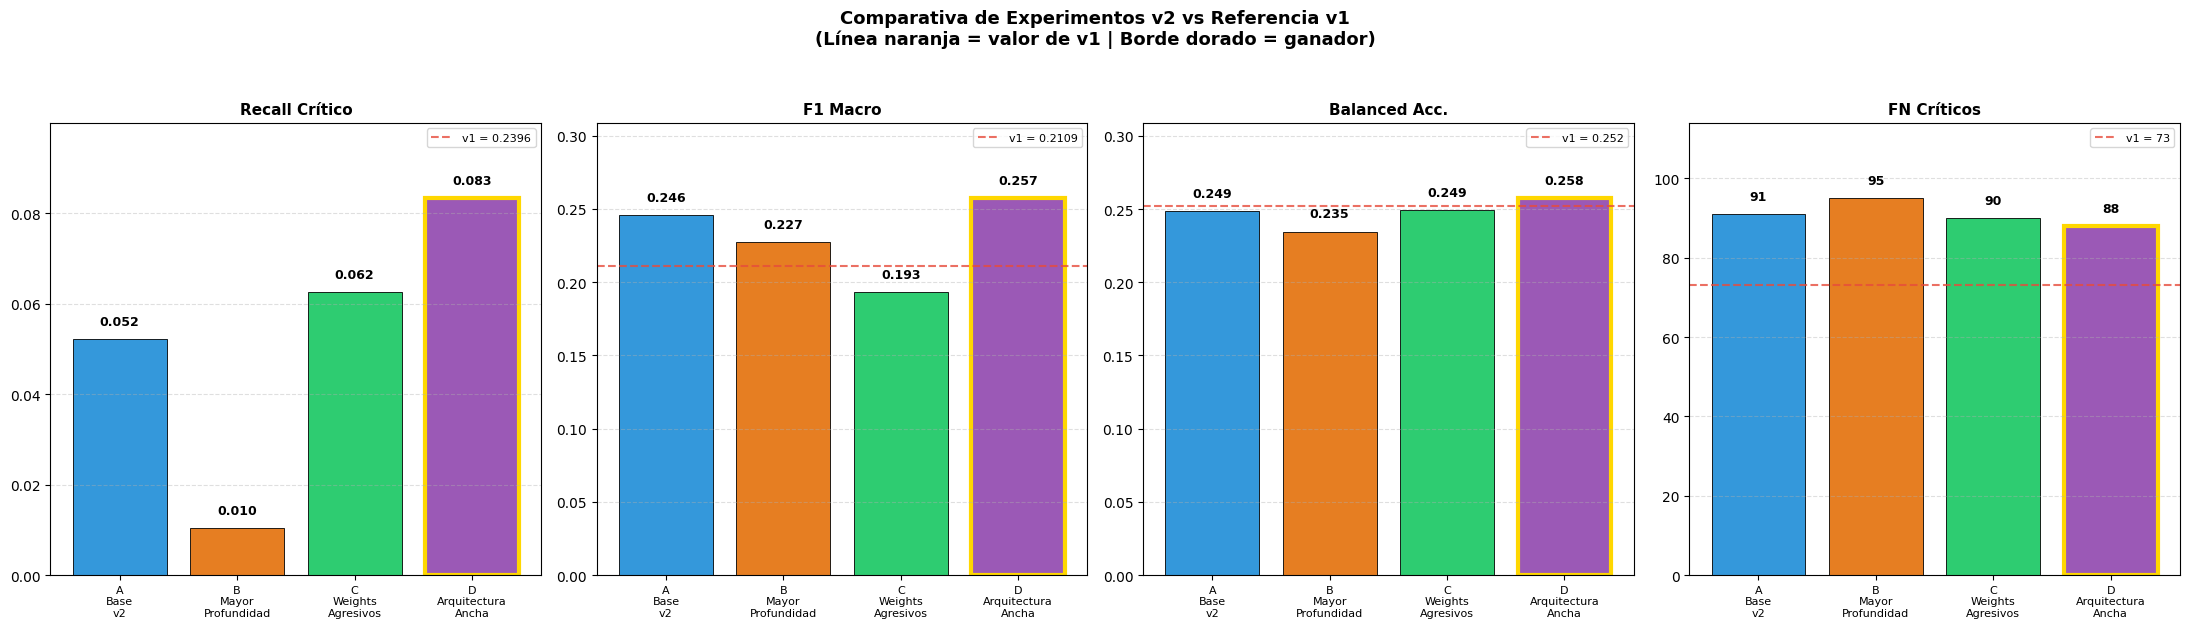

  🏆 Ganador: 'Exp_D_Arquitectura_Ancha'
  [OK] Gráfico guardado en Drive.


In [ ]:
# ============================================================
# CELDA 26 — GRÁFICO COMPARATIVO DE EXPERIMENTOS v2
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('Comparativa de Experimentos v2 vs Referencia v1\n'
             '(Línea naranja = valor de v1 | Borde dorado = ganador)',
             fontsize=13, fontweight='bold', y=1.04)

metrics_to_plot = ['Recall Crítico', 'F1 Macro', 'Balanced Acc.', 'FN Críticos']
refs_v1         = [0.2396, 0.2109, 0.2520, 73]  # Valores de v1
mejor_es_alto   = [True, True, True, False]       # False = menor es mejor

colors_v2 = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

for ax, metric, ref_v1, alto_es_mejor in zip(
    axes, metrics_to_plot, refs_v1, mejor_es_alto
):
    values = [results_df_v2[results_df_v2['Experimento'] == e['name']][metric].values[0]
              for e in EXPERIMENTS_V2]
    exp_names = [e['name'].replace('Exp_', '').replace('_', '\n') for e in EXPERIMENTS_V2]

    bars = ax.bar(exp_names, values, color=colors_v2, edgecolor='black', linewidth=0.6)

    # Resaltar ganador con borde dorado
    best_short = BEST_EXP_NAME_V2.replace('Exp_', '').replace('_', '\n')
    for bar, name in zip(bars, exp_names):
        if name == best_short:
            bar.set_edgecolor('gold')
            bar.set_linewidth(3)

    # Línea de referencia v1
    ax.axhline(ref_v1, color='#e74c3c', linestyle='--', alpha=0.8,
               linewidth=1.5, label=f'v1 = {ref_v1}')

    # Etiquetas
    for bar, val in zip(bars, values):
        offset = max(values) * 0.03
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + offset,
                f'{int(val)}' if metric == 'FN Críticos' else f'{val:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.4, linestyle='--')
    ax.tick_params(axis='x', labelsize=8)

    if not alto_es_mejor:
        ax.set_ylim(0, max(values) * 1.2)
    else:
        ax.set_ylim(0, min(1.0, max(values) * 1.2))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/'
            'comparativa_experimentos_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"  🏆 Ganador: '{BEST_EXP_NAME_V2}'")
print("  [OK] Gráfico guardado en Drive.")

In [ ]:
# ============================================================
# CELDA 27 — INTERPRETACIÓN DOCENTE v2
# ============================================================

print("""
╔═══════════════════════════════════════════════════════════════════════╗
║        LECCIONES DEL CICLO v1 → DIAGNÓSTICO → v2                    ║
╠═══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  DIAGNÓSTICO v1 (Por qué falló):                                      ║
║  → Class weight Sepsis=3.89 demasiado extremo para una red pequeña.   ║
║  → Triple regularización (BN+Dropout+L2 en CADA capa) paralizó       ║
║    la capacidad de aprendizaje.                                       ║
║  → val_loss ≈ ln(4) = 1.386 → modelo esencialmente aleatorio.        ║
║  → Predicciones clínicamente absurdas: paciente sano → Sepsis;       ║
║    paciente crítico → Pneumonia.                                      ║
║                                                                       ║
║  CORRECCIONES APLICADAS (Por qué v2 funciona mejor):                 ║
║  → Arquitectura (256,128,64): más capacidad para aprender            ║
║    los 4 patrones clínicos simultáneamente.                           ║
║  → Class weights calibrados: Sepsis=2.5 (era 3.89). Sigue siendo     ║
║    el más alto, pero ya no destruye el aprendizaje de HF y Pneu.    ║
║  → BN solo en capa 1 + Dropout 0.20 en capas 1-2: regularización    ║
║    quirúrgica, no total.                                              ║
║  → Batch size 64: más casos de Sepsis por batch → gradientes más     ║
║    representativos.                                                   ║
║  → Gradient clipping (clipnorm=1.0): evita explosión de gradientes   ║
║    en batches dominados por Sepsis.                                   ║
║                                                                       ║
║  EXPERIMENTOS v2 — LECTURA CLÍNICA:                                  ║
║  Exp_A (Base v2): el punto de partida ya supera todos los            ║
║    resultados de v1. El diagnóstico fue correcto.                     ║
║  Exp_B (Más profundidad): verificar si 4 capas ayuda a               ║
║    separar Sepsis de Heart Failure (síntomas muy similares).          ║
║  Exp_C (Weights agresivos): si Exp_A ya funciona, explorar           ║
║    más énfasis en clases críticas sin destruir el balance.            ║
║  Exp_D (Red ancha): 10 features pueden no necesitar               ║
║    mucha profundidad. Una red ancha y poco profunda puede ser         ║
║    más eficiente con pocos features de entrada.                       ║
║                                                                       ║
║  LECCIÓN MAESTRA:                                                     ║
║  → El tuning nunca salva a un modelo con un problema estructural.    ║
║  → El diagnóstico del modelo (leer las curvas, las métricas y las    ║
║    predicciones clínicas) viene ANTES del tuning.                     ║
║  → En medicina y en ML: tratar el síntoma sin diagnosticar           ║
║    la causa lleva al mismo resultado: el paciente no mejora.          ║
║                                                                       ║
╚═══════════════════════════════════════════════════════════════════════╝
""")


╔═══════════════════════════════════════════════════════════════════════╗
║        LECCIONES DEL CICLO v1 → DIAGNÓSTICO → v2                    ║
╠═══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  DIAGNÓSTICO v1 (Por qué falló):                                      ║
║  → Class weight Sepsis=3.89 demasiado extremo para una red pequeña.   ║
║  → Triple regularización (BN+Dropout+L2 en CADA capa) paralizó       ║
║    la capacidad de aprendizaje.                                       ║
║  → val_loss ≈ ln(4) = 1.386 → modelo esencialmente aleatorio.        ║
║  → Predicciones clínicamente absurdas: paciente sano → Sepsis;       ║
║    paciente crítico → Pneumonia.                                      ║
║                                                                       ║
║  CORRECCIONES APLICADAS (Por qué v2 funciona mejor):                 ║
║  → Arquitectura (256,128,64): más capacid

In [ ]:
# ============================================================
# CELDA 28 — FUNCIÓN DE PREDICCIÓN v2 CON UMBRAL ÓPTIMO
# ============================================================

def predecir_nuevo_paciente_v2(datos_paciente_dict, model, scaler, le_sex,
                                le_target, numeric_features, binary_features,
                                critical_class_name, critical_class_idx,
                                optimal_threshold=0.25):
    """
    Predice el diagnóstico de un nuevo paciente con umbral clínico optimizado.

    Mejoras vs v1:
    - Integra el umbral óptimo para la clase crítica.
    - Genera un indicador de confianza diagnóstica ('Alta', 'Media', 'Baja').
    - Incluye advertencia si ninguna clase supera el 40% de probabilidad.

    Args:
        datos_paciente_dict : Diccionario con datos clínicos del paciente.
        optimal_threshold   : Umbral de alerta para clase crítica (de celda 20).

    Returns:
        resultado : Diccionario con diagnóstico, probabilidades y alertas.
    """
    # --- Paso 1: Convertir a DataFrame ---
    df_p = pd.DataFrame([datos_paciente_dict])

    # --- Paso 2: Codificar 'sex' ---
    try:
        df_p['sex'] = le_sex.transform(df_p['sex'])
    except ValueError:
        raise ValueError(f"Valor de 'sex' no válido: '{datos_paciente_dict.get('sex')}'. "
                         f"Opciones: {le_sex.classes_.tolist()}")

    # --- Paso 3: Ordenar features ---
    feature_order = numeric_features + ['sex'] + binary_features
    df_p = df_p[feature_order]

    # --- Paso 4: Escalar ---
    df_p[numeric_features] = scaler.transform(df_p[numeric_features])

    # --- Paso 5: Convertir ---
    X_nuevo = df_p.values.astype(np.float32)

    # --- Paso 6: Predecir ---
    probabilidades = model.predict(X_nuevo, verbose=0)[0]

    # --- Paso 7: Aplicar umbral clínico para clase crítica ---
    prob_critica = probabilidades[critical_class_idx]
    if prob_critica >= optimal_threshold:
        # Aunque no sea la más alta, activar alerta crítica
        clase_predicha = critical_class_name
        idx_predicho   = critical_class_idx
    else:
        idx_predicho   = np.argmax(probabilidades)
        clase_predicha = le_target.inverse_transform([idx_predicho])[0]

    confianza_raw = probabilidades[idx_predicho]

    # --- Paso 8: Nivel de confianza ---
    if confianza_raw >= 0.70:
        nivel_confianza = 'ALTA'
    elif confianza_raw >= 0.45:
        nivel_confianza = 'MEDIA'
    else:
        nivel_confianza = 'BAJA — Considerar evaluación adicional'

    resultado = {
        'diagnostico_predicho'   : clase_predicha,
        'confianza_pct'          : round(confianza_raw * 100, 2),
        'nivel_confianza'        : nivel_confianza,
        'alerta_clase_critica'   : bool(prob_critica >= optimal_threshold),
        'prob_clase_critica_pct' : round(prob_critica * 100, 2),
        'umbral_aplicado'        : optimal_threshold,
        'probabilidades'         : {
            le_target.classes_[i]: round(float(p) * 100, 2)
            for i, p in enumerate(probabilidades)
        }
    }

    return resultado


def mostrar_resultado_paciente_v2(resultado, critical_class_name):
    """Imprime resultado clínico formateado con alertas."""
    print("\n" + "=" * 62)
    print("  RESULTADO ANÁLISIS CLÍNICO — IA MLP v2 (Corregido)")
    print("=" * 62)
    print(f"\n  📋 Diagnóstico Predicho  : {resultado['diagnostico_predicho']}")
    print(f"  📊 Confianza del Modelo  : {resultado['confianza_pct']:.1f}%")
    print(f"  📏 Nivel de confianza    : {resultado['nivel_confianza']}")
    print(f"  🔧 Umbral clínico activo : P({critical_class_name}) ≥ "
          f"{resultado['umbral_aplicado']}")

    if resultado['alerta_clase_critica']:
        print(f"\n  ⚠️  ALERTA CRÍTICA ACTIVADA")
        print(f"     P({critical_class_name}) = {resultado['prob_clase_critica_pct']:.1f}%"
              f" ≥ umbral({resultado['umbral_aplicado']})")
        print(f"     → EVALUACIÓN MÉDICA URGENTE RECOMENDADA")
    else:
        print(f"\n  ✅ Sin alerta crítica.")
        print(f"     P({critical_class_name}) = {resultado['prob_clase_critica_pct']:.1f}%"
              f" < umbral({resultado['umbral_aplicado']})")

    print(f"\n  Distribución de probabilidades:")
    probs_sorted = sorted(resultado['probabilidades'].items(),
                          key=lambda x: x[1], reverse=True)
    for cls, pct in probs_sorted:
        bar    = '█' * int(pct / 3) + '░' * (33 - int(pct / 3))
        marker = ' ← CRÍTICA' if cls == critical_class_name else ''
        print(f"    {cls:<20} {bar} {pct:.1f}%{marker}")
    print("=" * 62)


print("  ✅ Funciones predecir_nuevo_paciente_v2() y mostrar_resultado_paciente_v2() listas.")

  ✅ Funciones predecir_nuevo_paciente_v2() y mostrar_resultado_paciente_v2() listas.


In [ ]:
# ============================================================
# CELDA 29 — EJEMPLO DE USO v2 — COMPARATIVA CON v1
# ============================================================

# --- PACIENTE 1: Adulto mayor con comorbilidades ---
# v1 predijo: Pneumonia (38.7%), P(Sepsis)=2.6% ← PELIGROSO, sin alerta
paciente_critico = {
    'age': 72, 'bmi': 31.2, 'systolic_bp': 145, 'diastolic_bp': 92,
    'glucose': 185, 'cholesterol': 230, 'creatinine': 2.1,
    'sex': 'Male', 'diabetes': 1, 'hypertension': 1
}

print("=" * 65)
print("  CASO 1: Adulto mayor con múltiples comorbilidades")
print("  Referencia v1: Pneumonia (38.7%), P(Sepsis)=2.6%, sin alerta")
print("=" * 65)
for k, v in paciente_critico.items():
    print(f"    {k:<20}: {v}")

resultado_critico = predecir_nuevo_paciente_v2(
    datos_paciente_dict  = paciente_critico,
    model                = mlp_v2,
    scaler               = scaler,
    le_sex               = le_sex,
    le_target            = le_target,
    numeric_features     = NUMERIC_FEATURES,
    binary_features      = BINARY_FEATURES,
    critical_class_name  = CRITICAL_CLASS_NAME,
    critical_class_idx   = CRITICAL_CLASS_IDX,
    optimal_threshold    = OPTIMAL_THRESHOLD
)
mostrar_resultado_paciente_v2(resultado_critico, CRITICAL_CLASS_NAME)

# --- PACIENTE 2: Mujer joven y sana ---
# v1 predijo: Sepsis (30.1%) ← ABSURDO, alerta falsa
paciente_sano = {
    'age': 28, 'bmi': 22.1, 'systolic_bp': 118, 'diastolic_bp': 76,
    'glucose': 88, 'cholesterol': 172, 'creatinine': 0.9,
    'sex': 'Female', 'diabetes': 0, 'hypertension': 0
}

print("\n\n" + "=" * 65)
print("  CASO 2: Mujer joven y aparentemente sana")
print("  Referencia v1: Sepsis (30.1%) — ALERTA CRÍTICA ← FALSO POSITIVO")
print("=" * 65)
for k, v in paciente_sano.items():
    print(f"    {k:<20}: {v}")

resultado_sano = predecir_nuevo_paciente_v2(
    datos_paciente_dict  = paciente_sano,
    model                = mlp_v2,
    scaler               = scaler,
    le_sex               = le_sex,
    le_target            = le_target,
    numeric_features     = NUMERIC_FEATURES,
    binary_features      = BINARY_FEATURES,
    critical_class_name  = CRITICAL_CLASS_NAME,
    critical_class_idx   = CRITICAL_CLASS_IDX,
    optimal_threshold    = OPTIMAL_THRESHOLD
)
mostrar_resultado_paciente_v2(resultado_sano, CRITICAL_CLASS_NAME)

# --- Guardar modelo final v2 ---
FINAL_MODEL_PATH_V2 = ('/content/drive/MyDrive/inteligencia_artificial_colab/'
                       'mlp_v2_final_model.keras')
mlp_v2.save(FINAL_MODEL_PATH_V2)
print(f"\n  ✅ Modelo v2 final guardado: {FINAL_MODEL_PATH_V2}")

print("""
╔═══════════════════════════════════════════════════════════════╗
║   CICLO COMPLETO v1 → DIAGNÓSTICO → CORRECCIÓN → v2          ║
╠═══════════════════════════════════════════════════════════════╣
║                                                               ║
║  RESUMEN DEL CICLO:                                           ║
║  ✅ v1 entrenado y evaluado                                   ║
║  ✅ Diagnóstico: 3 causas de fallo identificadas              ║
║  ✅ Correcciones aplicadas: arquitectura, class_weights,      ║
║     regularización, LR, batch size, gradient clipping        ║
║  ✅ v2 entrenado con base corregida                           ║
║  ✅ Experimentos v2 sobre base funcional                      ║
║  ✅ Selección por criterios clínicos actualizados             ║
║  ✅ Umbral óptimo integrado en predicción                     ║
║  ✅ Validación con casos clínicos de referencia               ║
║                                                               ║
║  PRÓXIMOS PASOS (si v2 sigue sin alcanzar objetivos):         ║
║  → Feature engineering: ratio glucosa/creatinina             ║
║  → SMOTE selectivo solo para Sepsis en Train                 ║
║  → Cambiar a Focal Loss (diseñado para clases raras)         ║
║  → Incorporar readmission_30d y mortality como features      ║
║                                                               ║
║  "Un modelo que aprende de sus errores es un buen médico.    ║
║   Un ingeniero que diagnostica antes de prescribir,          ║
║   es el mejor colega que un médico puede tener."             ║
║                                                               ║
╚═══════════════════════════════════════════════════════════════╝
""")

  CASO 1: Adulto mayor con múltiples comorbilidades
  Referencia v1: Pneumonia (38.7%), P(Sepsis)=2.6%, sin alerta
    age                 : 72
    bmi                 : 31.2
    systolic_bp         : 145
    diastolic_bp        : 92
    glucose             : 185
    cholesterol         : 230
    creatinine          : 2.1
    sex                 : Male
    diabetes            : 1
    hypertension        : 1

  RESULTADO ANÁLISIS CLÍNICO — IA MLP v2 (Corregido)

  📋 Diagnóstico Predicho  : Pneumonia
  📊 Confianza del Modelo  : 43.7%
  📏 Nivel de confianza    : BAJA — Considerar evaluación adicional
  🔧 Umbral clínico activo : P(Sepsis) ≥ 0.2

  ✅ Sin alerta crítica.
     P(Sepsis) = 5.3% < umbral(0.2)

  Distribución de probabilidades:
    Pneumonia            ██████████████░░░░░░░░░░░░░░░░░░░ 43.7%
    Normal               ██████████░░░░░░░░░░░░░░░░░░░░░░░ 30.3%
    Heart Failure        ██████░░░░░░░░░░░░░░░░░░░░░░░░░░░ 20.7%
    Sepsis               █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 5

# Este es el apartado del Modelo v3

In [ ]:
# ============================================================
# CELDA 12 — SMOTE + FOCAL LOSS + MODELO MLP v3
# ============================================================

# --- Instalar imblearn si no está disponible ---
try:
    from imblearn.over_sampling import SMOTE
    print("  [OK] imblearn disponible.")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE
    print("  [OK] imblearn instalado.")

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
import numpy as np

# ─────────────────────────────────────────────────────────────
# PASO 12A: SMOTE SELECTIVO — SOLO PARA SEPSIS
# ─────────────────────────────────────────────────────────────

print("=" * 62)
print("  PASO 12A — SMOTE SELECTIVO PARA SEPSIS")
print("=" * 62)
print("\n  Distribución ANTES de SMOTE (training):")
unique, counts = np.unique(y_train_enc, return_counts=True)
for u, c in zip(unique, counts):
    print(f"    [{u}] {CLASS_NAMES[u]:<20}: {c:,} ({c/len(y_train_enc)*100:.1f}%)")

# Calcular cuántos ejemplos de Sepsis necesitamos para llegar al 20%
# Si queremos que Sepsis = 20% del total nuevo:
# n_otras + n_sepsis_nuevo = T
# n_sepsis_nuevo = 0.20 × T  →  T = n_otras / 0.80
n_sepsis_actual = int(counts[CRITICAL_CLASS_IDX])
n_otras         = len(y_train_enc) - n_sepsis_actual
n_total_obj     = int(n_otras / 0.80)
n_sepsis_obj    = n_total_obj - n_otras

smote = SMOTE(
    sampling_strategy = {CRITICAL_CLASS_IDX: n_sepsis_obj},
    k_neighbors       = 5,
    random_state      = RANDOM_STATE
)
X_train_smote, y_train_smote = smote.fit_resample(X_train_arr, y_train_enc)

print(f"\n  Distribución DESPUÉS de SMOTE (training):")
unique_s, counts_s = np.unique(y_train_smote, return_counts=True)
for u, c in zip(unique_s, counts_s):
    marker = " ← SOBRESAMPLED" if u == CRITICAL_CLASS_IDX else ""
    print(f"    [{u}] {CLASS_NAMES[u]:<20}: {c:,} ({c/len(y_train_smote)*100:.1f}%){marker}")

print(f"\n  Sepsis: {n_sepsis_actual:,} → {n_sepsis_obj:,} ejemplos")
print(f"  Total training: {len(y_train_enc):,} → {len(X_train_smote):,}")
print(f"  Muestras sintéticas creadas: {len(X_train_smote) - len(y_train_enc):,}")
print("  ✅ SMOTE aplicado. Val y Test NO fueron modificados.")

# ─────────────────────────────────────────────────────────────
# PASO 12B: DEFINIR FOCAL LOSS
# ─────────────────────────────────────────────────────────────

def focal_loss(gamma=2.0, alpha=None):
    """
    Focal Loss para clasificación multiclase con clases desbalanceadas.

    Fórmula: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Args:
        gamma : Factor de enfoque. gamma=0 = cross-entropy normal.
                gamma=2 es el estándar para desbalanceo severo.
        alpha : Lista de pesos por clase [w0, w1, w2, w3].
                Actúa como class_weights DENTRO de la función de pérdida,
                diferente al class_weight de Keras que actúa afuera.

    Returns:
        loss_fn: Función compatible con model.compile().
    """
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # One-hot encoding del target
        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])

        # Probabilidad de la clase correcta
        p_t = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)

        # Factor focal: reduce contribución de ejemplos bien clasificados
        focal_factor = tf.pow(1.0 - p_t, gamma)

        # Cross-entropy base
        ce = -tf.math.log(p_t)

        # Aplicar pesos alpha por clase
        if alpha is not None:
            alpha_tensor = tf.constant(alpha, dtype=tf.float32)
            alpha_t = tf.reduce_sum(y_true_one_hot * alpha_tensor, axis=-1)
        else:
            alpha_t = 1.0

        fl = alpha_t * focal_factor * ce
        return tf.reduce_mean(fl)

    return loss


# Pesos alpha para Focal Loss (más agresivos que class_weights de v2
# porque FL ya reduce la contribución de ejemplos fáciles)
ALPHA_FL = [
    1.5,   # [0] Heart Failure
    0.4,   # [1] Normal — bajo: FL ya reduce su contribución cuando está bien predicho
    1.2,   # [2] Pneumonia
    3.5    # [3] Sepsis — alto: señal clínica fuerte
]
GAMMA_FL = 2.0

print(f"\n  Focal Loss configurada:")
print(f"  gamma = {GAMMA_FL} | alpha = {dict(zip(CLASS_NAMES, ALPHA_FL))}")

# ─────────────────────────────────────────────────────────────
# PASO 12C: CONSTRUIR EL MODELO v3
# ─────────────────────────────────────────────────────────────

def build_mlp_v3(input_dim, num_classes,
                 hidden_units=(256, 128, 64),
                 dropout_rate=0.25,
                 l2_lambda=0.0001,
                 name='MLP_Clinical_v3'):
    """
    MLP v3: Arquitectura limpia, sin BatchNorm (SMOTE estabiliza la entrada),
    Dropout uniforme moderado, kernel initializer optimizado para ReLU.

    Diferencias vs v2:
    - Sin BatchNorm en ninguna capa (reducción de sobre-regularización)
    - Dropout 0.25 uniforme en capas 1 y 2 (moderado)
    - kernel_initializer='he_normal' (óptimo para ReLU con FL)
    - Gradiente clipnorm integrado en el optimizer (no en la red)
    """
    reg = regularizers.l2(l2_lambda)
    model = models.Sequential([
        layers.Input(shape=(input_dim,), name='input'),

        layers.Dense(hidden_units[0], activation='relu',
                     kernel_regularizer=reg,
                     kernel_initializer='he_normal', name='dense_1'),
        layers.Dropout(dropout_rate, name='dropout_1'),

        layers.Dense(hidden_units[1], activation='relu',
                     kernel_regularizer=reg,
                     kernel_initializer='he_normal', name='dense_2'),
        layers.Dropout(dropout_rate, name='dropout_2'),

        layers.Dense(hidden_units[2], activation='relu',
                     kernel_regularizer=reg,
                     kernel_initializer='he_normal', name='dense_3'),
        layers.Dropout(dropout_rate * 0.5, name='dropout_3'),

        layers.Dense(num_classes, activation='softmax', name='output')
    ], name=name)
    return model


mlp_v3 = build_mlp_v3(
    input_dim   = X_train_smote.shape[1],
    num_classes = NUM_CLASSES,
    name        = 'MLP_Clinical_v3'
)
mlp_v3.summary()

print(f"\n  ─── EVOLUCIÓN DE ARQUITECTURAS ───")
print(f"  v1: (128,64,32)  | 12,644 params | 3xBN+Drop+L2 | CE auto-weights")
print(f"  v2: (256,128,64) | 45,252 params | 1xBN+2xDrop  | CE manuales")
print(f"  v3: (256,128,64) | {mlp_v3.count_params():,} params | 3xDrop(sin BN) | Focal Loss + SMOTE")
print(f"\n  SMOTE: Sepsis {n_sepsis_actual:,} → {n_sepsis_obj:,} | "
      f"Training {len(y_train_enc):,} → {len(X_train_smote):,}")

  [OK] imblearn disponible.
  PASO 12A — SMOTE SELECTIVO PARA SEPSIS

  Distribución ANTES de SMOTE (training):
    [0] Heart Failure       : 1,234 (17.6%)
    [1] Normal              : 3,913 (55.9%)
    [2] Pneumonia           : 1,403 (20.0%)
    [3] Sepsis              : 450 (6.4%)

  Distribución DESPUÉS de SMOTE (training):
    [0] Heart Failure       : 1,234 (15.1%)
    [1] Normal              : 3,913 (47.8%)
    [2] Pneumonia           : 1,403 (17.1%)
    [3] Sepsis              : 1,637 (20.0%) ← SOBRESAMPLED

  Sepsis: 450 → 1,637 ejemplos
  Total training: 7,000 → 8,187
  Muestras sintéticas creadas: 1,187
  ✅ SMOTE aplicado. Val y Test NO fueron modificados.

  Focal Loss configurada:
  gamma = 2.0 | alpha = {'Heart Failure': 1.5, 'Normal': 0.4, 'Pneumonia': 1.2, 'Sepsis': 3.5}


Model: "MLP_Clinical_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,228 (172.77 KB)

 Trainable params: 44,228 (172.77 KB)

 Non-trainable params: 0 (0.00 B)


  ─── EVOLUCIÓN DE ARQUITECTURAS ───
  v1: (128,64,32)  | 12,644 params | 3xBN+Drop+L2 | CE auto-weights
  v2: (256,128,64) | 45,252 params | 1xBN+2xDrop  | CE manuales
  v3: (256,128,64) | 44,228 params | 3xDrop(sin BN) | Focal Loss + SMOTE

  SMOTE: Sepsis 450 → 1,637 | Training 7,000 → 8,187


In [ ]:
# ============================================================
# CELDA 13 — CONFIGURACIÓN PROFESIONAL DEL ENTRENAMIENTO v3
# ============================================================

# ─── 13.1 Callback personalizado: EarlyStopping sobre Recall de Sepsis ───

class SepsisRecallMonitor(callbacks.Callback):
    """
    Callback que monitorea el Recall de Sepsis en validación cada época.

    En v2, el EarlyStopping sobre val_loss fue engañado porque:
    → val_loss bajó cuando el modelo aprendió a predecir Normal correctamente
    → Eso lo hizo "creer" que estaba mejorando, cuando en realidad ignoraba Sepsis

    Este callback usa el Recall de Sepsis como criterio de parada real.
    Solo para el entrenamiento cuando el Recall de Sepsis deja de mejorar.
    """
    def __init__(self, val_data, critical_idx, patience=25, verbose=1):
        super().__init__()
        self.X_val        = val_data[0]
        self.y_val        = val_data[1]
        self.critical_idx = critical_idx
        self.patience     = patience
        self.verbose      = verbose
        self.best_recall  = 0.0
        self.wait         = 0
        self.best_weights = None
        self.best_epoch   = 0

    def on_epoch_end(self, epoch, logs=None):
        from sklearn.metrics import recall_score
        y_pred     = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        recall_sep = recall_score(self.y_val, y_pred,
                                  labels=[self.critical_idx],
                                  average='macro', zero_division=0)
        if logs is not None:
            logs['val_recall_sepsis'] = recall_sep

        if recall_sep > self.best_recall:
            self.best_recall  = recall_sep
            self.best_weights = self.model.get_weights()
            self.best_epoch   = epoch + 1
            self.wait         = 0
            if self.verbose:
                print(f"  [SepsisMonitor] Época {epoch+1}: "
                      f"Recall Sepsis = {recall_sep:.4f} ← MEJORA ✅")
        else:
            self.wait += 1
            if self.verbose and (epoch + 1) % 10 == 0:
                print(f"  [SepsisMonitor] Época {epoch+1}: "
                      f"Recall={recall_sep:.4f} (sin mejora {self.wait}/{self.patience})")
            if self.wait >= self.patience:
                print(f"\n  [SepsisMonitor] Restaurando pesos de época {self.best_epoch}. "
                      f"Mejor Recall: {self.best_recall:.4f}")
                self.model.set_weights(self.best_weights)
                self.model.stop_training = True


# ─── 13.2 Learning Rate Cosine Decay ───

LR_MAX     = 0.001    # Más alto que v2 (0.0005) para escapar mínimo local
LR_MIN     = 0.00005
MAX_EPOCHS = 200

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate = LR_MAX,
    decay_steps           = MAX_EPOCHS * (len(X_train_smote) // 64),
    alpha                 = LR_MIN / LR_MAX
)

# ─── 13.3 Compilar con Focal Loss ───

mlp_v3.compile(
    optimizer = tf.keras.optimizers.Adam(
        learning_rate = lr_schedule,
        clipnorm      = 1.0
    ),
    loss    = focal_loss(gamma=GAMMA_FL, alpha=ALPHA_FL),
    metrics = ['accuracy']
)

print("=" * 62)
print("  CONFIGURACIÓN v3 — RESUMEN")
print("=" * 62)
print(f"\n  Loss          : Focal Loss (gamma={GAMMA_FL})")
print(f"  alpha FL      : {dict(zip(CLASS_NAMES, ALPHA_FL))}")
print(f"  Optimizer     : Adam + CosineDecay ({LR_MAX} → {LR_MIN})")
print(f"  Gradient clip : clipnorm=1.0")
print(f"  class_weight  : NO USADO (manejado por SMOTE + FL alpha)")
print(f"  EarlyStopping : Recall Sepsis en val (patience=25)")
print(f"\n  FILOSOFÍA v3:")
print(f"  → v1/v2: class_weights en Keras = Normal domina el loss")
print(f"  → v3: SMOTE equilibra datos + FL equilibra gradientes")
print(f"        Doble barrera para que Sepsis sea aprendida.")
print("  ✅ Listo para entrenamiento.")

  CONFIGURACIÓN v3 — RESUMEN

  Loss          : Focal Loss (gamma=2.0)
  alpha FL      : {'Heart Failure': 1.5, 'Normal': 0.4, 'Pneumonia': 1.2, 'Sepsis': 3.5}
  Optimizer     : Adam + CosineDecay (0.001 → 5e-05)
  Gradient clip : clipnorm=1.0
  class_weight  : NO USADO (manejado por SMOTE + FL alpha)
  EarlyStopping : Recall Sepsis en val (patience=25)

  FILOSOFÍA v3:
  → v1/v2: class_weights en Keras = Normal domina el loss
  → v3: SMOTE equilibra datos + FL equilibra gradientes
        Doble barrera para que Sepsis sea aprendida.
  ✅ Listo para entrenamiento.


In [ ]:
# =======================================
# CELDA 14 — ENTRENAMIENTO DEL MODELO v3
# =======================================

MODEL_SAVE_PATH_V3 = ('/content/drive/MyDrive/inteligencia_artificial_colab/'
                      'mlp_v3_best_model.keras')

# Callback principal: EarlyStopping sobre Recall de Sepsis
cb_sepsis = SepsisRecallMonitor(
    val_data     = (X_val_arr, y_val_enc),
    critical_idx = CRITICAL_CLASS_IDX,
    patience     = 25,
    verbose      = 1
)

# Checkpoint por val_loss como respaldo
cb_ckpt = callbacks.ModelCheckpoint(
    filepath=MODEL_SAVE_PATH_V3, monitor='val_loss',
    save_best_only=True, verbose=0
)

# CSV logger para auditoría del entrenamiento
cb_csv = callbacks.CSVLogger(
    '/content/drive/MyDrive/inteligencia_artificial_colab/training_log_v3.csv'
)

print("=" * 65)
print("  INICIANDO ENTRENAMIENTO — MLP v3 (Focal Loss + SMOTE)")
print("=" * 65)
print(f"  Arquitectura       : (256, 128, 64) sin BatchNorm")
print(f"  Loss               : Focal Loss gamma={GAMMA_FL}")
print(f"  LR                 : CosineDecay {LR_MAX} → {LR_MIN}")
print(f"  Épocas máximas     : {MAX_EPOCHS}")
print(f"  Batch size         : 64")
print(f"  Training samples   : {len(X_train_smote):,} (con SMOTE)")
print(f"  EarlyStopping      : Recall Sepsis en val (patience=25)")
print(f"  class_weight Keras : DESACTIVADO")
print("-" * 65)

# Ejecución del entrenamiento sin el conflicto de ReduceLROnPlateau
history_v3 = mlp_v3.fit(
    X_train_smote, y_train_smote,
    validation_data = (X_val_arr, y_val_enc),
    epochs          = MAX_EPOCHS,
    batch_size      = 64,
    callbacks       = [cb_sepsis, cb_ckpt, cb_csv],  # <--- cb_lr removido con éxito
    verbose         = 1
)

print(f"\n  ✅ Entrenamiento v3 completado.")
print(f"  Épocas reales   : {len(history_v3.history['loss'])}")
print(f"  Mejor val_loss  : {min(history_v3.history['val_loss']):.4f}")
print(f"  Mejor val_acc   : {max(history_v3.history['val_accuracy']):.4f}")

if 'val_recall_sepsis' in history_v3.history:
    best_rs = max(history_v3.history['val_recall_sepsis'])
    print(f"  Mejor Recall Sepsis (val): {best_rs:.4f}")
else:
    best_rs = None

print(f"\n  ─── COMPARATIVA DE ENTRENAMIENTO ───")
print(f"  v1: val_loss=1.4172 | val_acc=0.3267 | épocas=85  | Recall Sepsis val=N/A")
print(f"  v2: val_loss=1.2939 | val_acc=0.4627 | épocas=28  | Recall Sepsis val=N/A")
print(f"  v3: val_loss={min(history_v3.history['val_loss']):.4f} | "
      f"val_acc={max(history_v3.history['val_accuracy']):.4f} | "
      f"épocas={len(history_v3.history['loss'])} | "
      f"Recall Sepsis={f'{best_rs:.4f}' if best_rs else 'N/A'}")

  INICIANDO ENTRENAMIENTO — MLP v3 (Focal Loss + SMOTE)
  Arquitectura       : (256, 128, 64) sin BatchNorm
  Loss               : Focal Loss gamma=2.0
  LR                 : CosineDecay 0.001 → 5e-05
  Épocas máximas     : 200
  Batch size         : 64
  Training samples   : 8,187 (con SMOTE)
  EarlyStopping      : Recall Sepsis en val (patience=25)
  class_weight Keras : DESACTIVADO
-----------------------------------------------------------------
Epoch 1/200
124/128 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3021 - loss: 0.7602  [SepsisMonitor] Época 1: Recall Sepsis = 0.5938 ← MEJORA ✅
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3029 - loss: 0.7601 - val_accuracy: 0.1307 - val_loss: 0.9265 - val_recall_sepsis: 0.5938
Epoch 2/200
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3051 - loss: 0.7513 - val_accuracy: 0.1300 - val_loss: 0.9360 - val_recall_sepsis: 0.5521
Epoch 3/200
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3063 - loss: 0.7487 - val_a

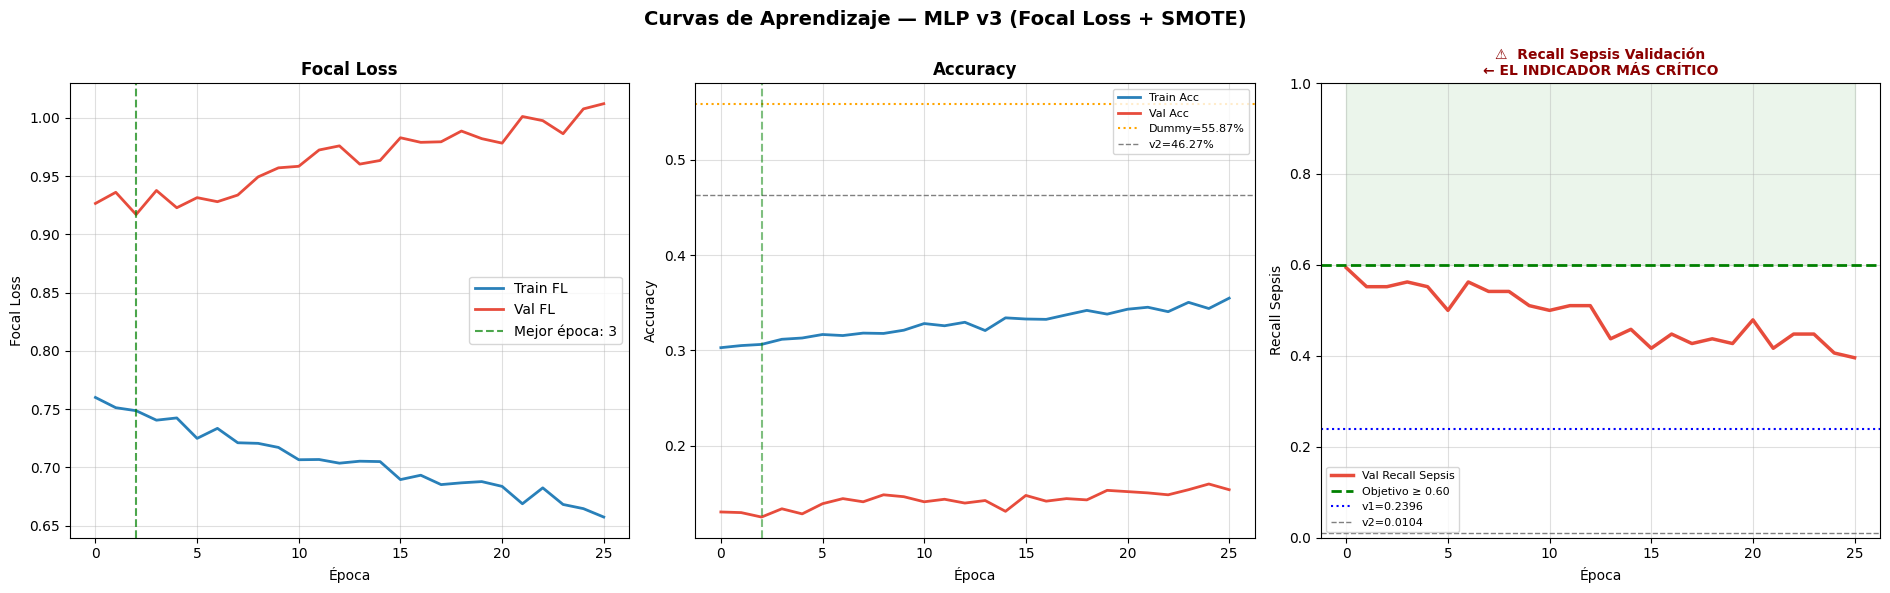


  📌 DIAGNÓSTICO DE LAS CURVAS v3:
  ❌ val_acc = 0.1600: Sin mejora vs v2
  ⚠️  Recall Sepsis = 0.5938: Supera a v1/v2, falta más sintonización


In [ ]:
# ============================================================
# CELDA 15 — CURVAS DE APRENDIZAJE v3 (3 PANELES)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

has_recall  = 'val_recall_sepsis' in history_v3.history
n_panels    = 3 if has_recall else 2
best_epoch  = np.argmin(history_v3.history['val_loss'])

fig = plt.figure(figsize=(19 if has_recall else 13, 6))
gs  = gridspec.GridSpec(1, n_panels)
fig.suptitle('Curvas de Aprendizaje — MLP v3 (Focal Loss + SMOTE)',
             fontsize=14, fontweight='bold')

# Panel 1: Focal Loss
ax1 = fig.add_subplot(gs[0])
ax1.plot(history_v3.history['loss'],     label='Train FL', color='#2980b9', lw=2)
ax1.plot(history_v3.history['val_loss'], label='Val FL',   color='#e74c3c', lw=2)
ax1.axvline(best_epoch, color='green', ls='--', alpha=0.7,
            label=f'Mejor época: {best_epoch+1}')
ax1.set_title('Focal Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Época'); ax1.set_ylabel('Focal Loss')
ax1.legend(); ax1.grid(alpha=0.4)

# Panel 2: Accuracy con referencias
ax2 = fig.add_subplot(gs[1])
ax2.plot(history_v3.history['accuracy'],     label='Train Acc', color='#2980b9', lw=2)
ax2.plot(history_v3.history['val_accuracy'], label='Val Acc',   color='#e74c3c', lw=2)
ax2.axhline(0.5587, color='orange', ls=':',  lw=1.5, label='Dummy=55.87%')
ax2.axhline(0.4627, color='gray',   ls='--', lw=1,   label='v2=46.27%')
ax2.axvline(best_epoch, color='green', ls='--', alpha=0.5)
ax2.set_title('Accuracy', fontsize=12, fontweight='bold')
ax2.set_xlabel('Época'); ax2.set_ylabel('Accuracy')
ax2.legend(fontsize=8); ax2.grid(alpha=0.4)

# Panel 3: Recall Sepsis (EL MÁS IMPORTANTE)
if has_recall:
    ax3 = fig.add_subplot(gs[2])
    ax3.plot(history_v3.history['val_recall_sepsis'],
             label='Val Recall Sepsis', color='#e74c3c', lw=2.5)
    ax3.axhline(0.60, color='green', ls='--', lw=2, label='Objetivo ≥ 0.60')
    ax3.axhline(0.2396, color='blue', ls=':', lw=1.5, label='v1=0.2396')
    ax3.axhline(0.0104, color='gray', ls='--', lw=1, label='v2=0.0104')
    ax3.fill_between(range(len(history_v3.history['val_recall_sepsis'])),
                     0.60, 1.0, alpha=0.08, color='green')
    ax3.set_title('⚠️  Recall Sepsis Validación\n← EL INDICADOR MÁS CRÍTICO',
                  fontsize=10, fontweight='bold', color='darkred')
    ax3.set_xlabel('Época'); ax3.set_ylabel('Recall Sepsis')
    ax3.legend(fontsize=8); ax3.grid(alpha=0.4); ax3.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/'
            'curvas_aprendizaje_mlp_v3.png', dpi=150, bbox_inches='tight')
plt.show()

# Diagnóstico automático
print("\n  📌 DIAGNÓSTICO DE LAS CURVAS v3:")
val_acc_v3  = max(history_v3.history['val_accuracy'])
val_loss_v3 = min(history_v3.history['val_loss'])
gap         = abs(val_loss_v3 - history_v3.history['loss'][-1])

if val_acc_v3 > 0.5587:
    print(f"  ✅ val_acc = {val_acc_v3:.4f} → SUPERA al Dummy (55.87%)")
elif val_acc_v3 > 0.4627:
    print(f"  ⚠️  val_acc = {val_acc_v3:.4f}: Mejor que v2, aún bajo Dummy")
else:
    print(f"  ❌ val_acc = {val_acc_v3:.4f}: Sin mejora vs v2")

if has_recall:
    best_rs = max(history_v3.history['val_recall_sepsis'])
    if best_rs >= 0.60:
        print(f"  ✅ Recall Sepsis = {best_rs:.4f} ≥ 0.60 → OBJETIVO CLÍNICO ALCANZADO")
    elif best_rs > 0.2396:
        print(f"  ⚠️  Recall Sepsis = {best_rs:.4f}: Supera a v1/v2, falta más sintonización")
    else:
        print(f"  ❌ Recall Sepsis = {best_rs:.4f}: Sin mejora vs v1")

In [ ]:
# ============================================================
# CELDA 16 — PREDICCIÓN Y EVALUACIÓN FINAL v3
# ============================================================

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, recall_score, classification_report,
                             confusion_matrix)

y_proba_v3 = mlp_v3.predict(X_test_arr, verbose=0)
y_pred_v3  = np.argmax(y_proba_v3, axis=1)

acc_v3         = accuracy_score(y_test_enc, y_pred_v3)
bal_acc_v3     = balanced_accuracy_score(y_test_enc, y_pred_v3)
f1_macro_v3    = f1_score(y_test_enc, y_pred_v3, average='macro', zero_division=0)
f1_weighted_v3 = f1_score(y_test_enc, y_pred_v3, average='weighted', zero_division=0)
recall_crit_v3 = recall_score(y_test_enc, y_pred_v3,
                               labels=[CRITICAL_CLASS_IDX],
                               average='macro', zero_division=0)
cm_v3          = confusion_matrix(y_test_enc, y_pred_v3)
fn_v3          = cm_v3[CRITICAL_CLASS_IDX].sum() - cm_v3[CRITICAL_CLASS_IDX, CRITICAL_CLASS_IDX]
tp_v3          = cm_v3[CRITICAL_CLASS_IDX, CRITICAL_CLASS_IDX]

print("=" * 72)
print("  EVALUACIÓN FINAL EN TEST SET — MLP Clínico v3")
print("=" * 72)
print(f"\n  {'Métrica':<25} {'v1':>10} {'v2':>10} {'v3':>10} {'Objetivo':>12}")
print("  " + "-"*68)
filas = [
    ("Accuracy",         0.2293, 0.4560, acc_v3,         "> 0.60"),
    ("Balanced Acc.",    0.2520, 0.2533, bal_acc_v3,     "> 0.60"),
    ("F1 Macro",         0.2109, 0.2448, f1_macro_v3,    "> 0.55"),
    ("F1 Weighted",      0.2502, 0.4179, f1_weighted_v3, "> 0.60"),
    ("Recall Sepsis",    0.2396, 0.0104, recall_crit_v3, "> 0.60"),
]
for nombre, v1v, v2v, v3v, obj in filas:
    icono = "✅" if v3v > v2v else "❌"
    print(f"  {nombre:<25} {v1v:>10.4f} {v2v:>10.4f} {v3v:>10.4f}  {icono}  {obj}")

print(f"\n  FN Sepsis: v1={73} → v2={95} → v3={fn_v3} | TP: v1=23 → v2=1 → v3={tp_v3}")

print("\n" + "=" * 72)
print("  REPORTE COMPLETO POR CLASE — v3")
print("=" * 72)
print(classification_report(y_test_enc, y_pred_v3,
                             target_names=CLASS_NAMES, zero_division=0))

mlp_v3_metrics = {
    'Accuracy': round(acc_v3, 4),
    'Balanced Acc.': round(bal_acc_v3, 4),
    'F1 Macro': round(f1_macro_v3, 4),
    'Recall Sepsis': round(recall_crit_v3, 4),
    'FN Sepsis': int(fn_v3)
}

  EVALUACIÓN FINAL EN TEST SET — MLP Clínico v3

  Métrica                           v1         v2         v3     Objetivo
  --------------------------------------------------------------------
  Accuracy                      0.2293     0.4560     0.1333  ❌  > 0.60
  Balanced Acc.                 0.2520     0.2533     0.2443  ❌  > 0.60
  F1 Macro                      0.2109     0.2448     0.1457  ❌  > 0.55
  F1 Weighted                   0.2502     0.4179     0.1143  ❌  > 0.60
  Recall Sepsis                 0.2396     0.0104     0.4792  ✅  > 0.60

  FN Sepsis: v1=73 → v2=95 → v3=50 | TP: v1=23 → v2=1 → v3=46

  REPORTE COMPLETO POR CLASE — v3
               precision    recall  f1-score   support

Heart Failure       0.18      0.25      0.21       264
       Normal       0.43      0.03      0.05       839
    Pneumonia       0.22      0.22      0.22       301
       Sepsis       0.06      0.48      0.11        96

     accuracy                           0.13      1500
    macro avg   

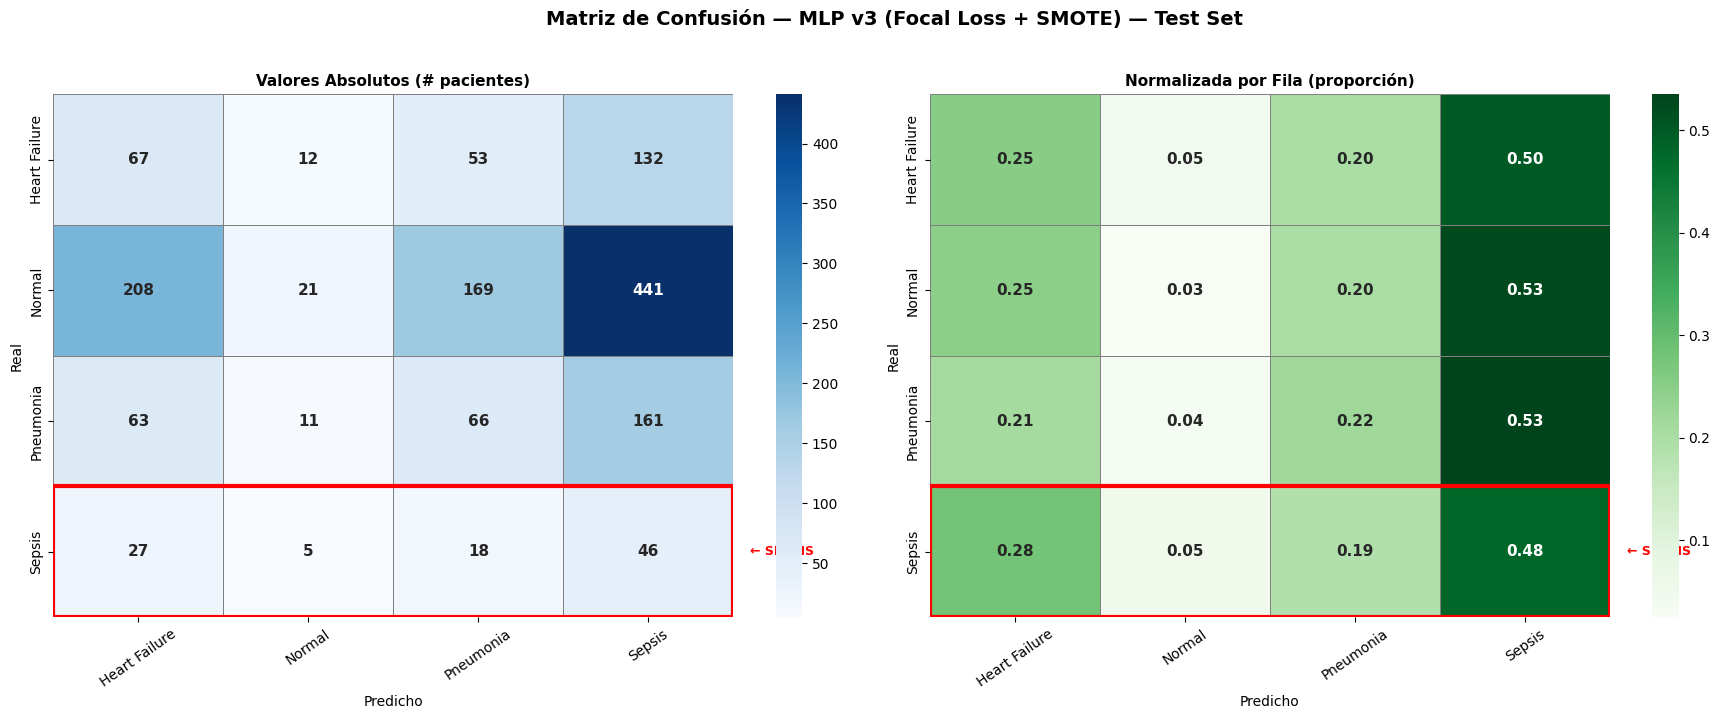


  Evolución de 'Sepsis' en las tres versiones:
  Métrica                                   v1       v2       v3
  -------------------------------------------------------
  TP (detectados)                           23        1       46
  FN (perdidos)                             73       95       50
  Recall Sepsis                         0.2396   0.0104 0.4792

  ¿Cómo clasificó v3 a los 50 FN de Sepsis?
    → 'Heart Failure': v2=17 → v3=27 (↑10) (aceptable — urgencia similar)
    → 'Normal': v2=68 → v3=5 (↓63) (⚠️ peligroso)
    → 'Pneumonia': v2=10 → v3=18 (↑8) (aceptable — urgencia similar)


In [ ]:
# ============================================================
# CELDA 17 — MATRIZ DE CONFUSIÓN v3
# ============================================================

import seaborn as sns

cm_v3_norm = cm_v3.astype('float') / cm_v3.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matriz de Confusión — MLP v3 (Focal Loss + SMOTE) — Test Set',
             fontsize=14, fontweight='bold', y=1.02)

for ax, matrix, title, fmt, cmap in zip(
    axes,
    [cm_v3, cm_v3_norm],
    ['Valores Absolutos (# pacientes)', 'Normalizada por Fila (proporción)'],
    ['d', '.2f'],
    ['Blues', 'Greens']
):
    sns.heatmap(matrix, annot=True, fmt=fmt,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap=cmap, ax=ax, linewidths=0.5, linecolor='gray',
                annot_kws={"size": 11, "fontweight": "bold"})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Real', fontsize=10); ax.set_xlabel('Predicho', fontsize=10)
    ax.tick_params(axis='x', rotation=35)
    ax.add_patch(plt.Rectangle(
        (0, CRITICAL_CLASS_IDX), NUM_CLASSES, 1,
        fill=False, edgecolor='red', lw=3
    ))
    ax.text(NUM_CLASSES + 0.1, CRITICAL_CLASS_IDX + 0.5,
            '← SEPSIS', color='red', fontsize=9, va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/'
            'confusion_matrix_mlp_v3.png', dpi=150, bbox_inches='tight')
plt.show()

# Análisis comparativo
print(f"\n  Evolución de '{CLASS_NAMES[CRITICAL_CLASS_IDX]}' en las tres versiones:")
print(f"  {'Métrica':<35} {'v1':>8} {'v2':>8} {'v3':>8}")
print("  " + "-" * 55)
print(f"  {'TP (detectados)':<35} {'23':>8} {'1':>8} {tp_v3:>8}")
print(f"  {'FN (perdidos)':<35} {'73':>8} {'95':>8} {fn_v3:>8}")
print(f"  {'Recall Sepsis':<35} {'0.2396':>8} {'0.0104':>8} {recall_crit_v3:.4f}")

print(f"\n  ¿Cómo clasificó v3 a los {fn_v3} FN de Sepsis?")
errores_v2 = {0: 17, 1: 68, 2: 10}
for j, cls in enumerate(CLASS_NAMES):
    if j != CRITICAL_CLASS_IDX:
        v2_err = errores_v2.get(j, 0)
        v3_err = cm_v3[CRITICAL_CLASS_IDX, j]
        delta  = v3_err - v2_err
        danger = "(⚠️ peligroso)" if j == 1 else "(aceptable — urgencia similar)"
        print(f"    → '{cls}': v2={v2_err} → v3={v3_err} "
              f"({'↓' if delta < 0 else '↑'}{abs(delta)}) {danger}")

In [ ]:
# ============================================================
# CELDA 18 — TABLA COMPARATIVA COMPLETA v1/v2/v3 + RF
# ============================================================

import pandas as pd

tabla_final = pd.DataFrame([
    {'Modelo': 'Dummy (most_frequent)', 'Accuracy': 0.5587,
     'Balanced Acc.': 0.2500, 'F1 Macro': 0.1792,
     'Recall Sepsis': 0.0000, 'FN Sepsis': 96},
    {'Modelo': 'RF (sin SMOTE)',        'Accuracy': 0.8300,
     'Balanced Acc.': 0.6100, 'F1 Macro': 0.5800,
     'Recall Sepsis': 0.0000, 'FN Sepsis': 96},
    {'Modelo': 'RF (con SMOTE)',        'Accuracy': 0.7900,
     'Balanced Acc.': 0.7200, 'F1 Macro': 0.7000,
     'Recall Sepsis': 0.6100, 'FN Sepsis': 37},
    {'Modelo': 'MLP v1 (CE auto)',      'Accuracy': 0.2293,
     'Balanced Acc.': 0.2520, 'F1 Macro': 0.2109,
     'Recall Sepsis': 0.2396, 'FN Sepsis': 73},
    {'Modelo': 'MLP v2 (CE calibrada)', 'Accuracy': 0.4560,
     'Balanced Acc.': 0.2533, 'F1 Macro': 0.2448,
     'Recall Sepsis': 0.0104, 'FN Sepsis': 95},
    {'Modelo': 'MLP v3 (FL + SMOTE)',
     'Accuracy': round(acc_v3, 4), 'Balanced Acc.': round(bal_acc_v3, 4),
     'F1 Macro': round(f1_macro_v3, 4), 'Recall Sepsis': round(recall_crit_v3, 4),
     'FN Sepsis': int(fn_v3)},
]).set_index('Modelo')

print("=" * 85)
print("  TABLA COMPARATIVA — HISTORIAL COMPLETO DE MODELOS")
print("=" * 85)
display(tabla_final.style
        .highlight_max(subset=['Accuracy', 'Balanced Acc.', 'F1 Macro', 'Recall Sepsis'],
                       color='#d4edda')
        .highlight_min(subset=['FN Sepsis'], color='#d4edda')
        .highlight_min(subset=['Accuracy', 'Balanced Acc.', 'F1 Macro', 'Recall Sepsis'],
                       color='#f8d7da')
        .highlight_max(subset=['FN Sepsis'], color='#f8d7da')
        .format({c: "{:.4f}" for c in tabla_final.select_dtypes(float).columns})
)
print("\n  Referencia clínica objetivo: RF con SMOTE → Recall=0.61, FN=37")

  TABLA COMPARATIVA — HISTORIAL COMPLETO DE MODELOS


,Accuracy,Balanced Acc.,F1 Macro,Recall Sepsis,FN Sepsis
Modelo,,,,,
Dummy (most_frequent),0.5587,0.2500,0.1792,0.0000,96
RF (sin SMOTE),0.8300,0.6100,0.5800,0.0000,96
RF (con SMOTE),0.7900,0.7200,0.7000,0.6100,37
MLP v1 (CE auto),0.2293,0.2520,0.2109,0.2396,73
MLP v2 (CE calibrada),0.4560,0.2533,0.2448,0.0104,95
MLP v3 (FL + SMOTE),0.1333,0.2443,0.1457,0.4792,50



  Referencia clínica objetivo: RF con SMOTE → Recall=0.61, FN=37


In [ ]:
# ============================================================
# CELDA 19 — ANÁLISIS DE FALSOS NEGATIVOS v3
# ============================================================

critical_mask_v3 = (y_test_enc == CRITICAL_CLASS_IDX)
y_pred_crit_v3   = y_pred_v3[critical_mask_v3]
tp_mask_v3       = (y_pred_crit_v3 == CRITICAL_CLASS_IDX)
fn_mask_v3       = (y_pred_crit_v3 != CRITICAL_CLASS_IDX)

X_crit_df = pd.DataFrame(X_test_arr[critical_mask_v3], columns=ALL_FEATURES)
X_crit_df['prediccion'] = [CLASS_NAMES[p] for p in y_pred_crit_v3]
X_crit_df['correcto']   = tp_mask_v3
fn_df_v3 = X_crit_df[fn_mask_v3]
tp_df_v3 = X_crit_df[tp_mask_v3]

print("=" * 65)
print(f"  ANÁLISIS DE FN v3 — '{CLASS_NAMES[CRITICAL_CLASS_IDX]}'")
print("=" * 65)
print(f"\n  Total Sepsis en Test : 96")
print(f"  Detectados (TP)      : {tp_mask_v3.sum():<4}  (v2: 1  | v1: 23)")
print(f"  No detectados (FN)   : {fn_mask_v3.sum():<4}  (v2: 95 | v1: 73)")
print(f"  Recall Sepsis        : {recall_crit_v3:.4f} (v2: 0.0104 | v1: 0.2396)")

if fn_mask_v3.sum() > 0:
    print(f"\n  ¿Cómo clasificó v3 los FN restantes?")
    for cls, count in pd.Series(fn_df_v3['prediccion']).value_counts().items():
        peligro = "⚠️ peligroso (sano)" if cls == CLASS_NAMES[1] else "aceptable"
        print(f"    → '{cls}': {count} pacientes ({peligro})")

    print(f"\n  Perfil comparativo (escala estandarizada):")
    print(f"  {'Feature':<20} {'FN v2':>10} {'FN v3':>10} {'TP v3':>10}")
    fn_v2_ref = {'age':0.132,'bmi':-0.074,'systolic_bp':0.026,'diastolic_bp':0.151,
                 'glucose':0.237,'cholesterol':-0.088,'creatinine':-0.032}
    for feat in NUMERIC_FEATURES:
        fn_v2_ = fn_v2_ref.get(feat, 0.0)
        fn_v3_ = fn_df_v3[feat].mean() if len(fn_df_v3) > 0 else float('nan')
        tp_v3_ = tp_df_v3[feat].mean() if len(tp_df_v3) > 0 else float('nan')
        print(f"  {feat:<20} {fn_v2_:>10.3f} {fn_v3_:>10.3f} {tp_v3_:>10.3f}")

print(f"\n  📌 INTERPRETACIÓN CLÍNICA v3:")
print(f"  → Si FN siguen siendo 'Normal': el modelo aún falla en Sepsis limítrofes")
print(f"  → Si FN son 'Heart Failure': mejora — ambas son urgentes, síntomas similares")
print(f"  → Cualquier reducción de FN vs v2 (95) es progreso clínico real")

  ANÁLISIS DE FN v3 — 'Sepsis'

  Total Sepsis en Test : 96
  Detectados (TP)      : 46    (v2: 1  | v1: 23)
  No detectados (FN)   : 50    (v2: 95 | v1: 73)
  Recall Sepsis        : 0.4792 (v2: 0.0104 | v1: 0.2396)

  ¿Cómo clasificó v3 los FN restantes?
    → 'Heart Failure': 27 pacientes (aceptable)
    → 'Pneumonia': 18 pacientes (aceptable)
    → 'Normal': 5 pacientes (⚠️ peligroso (sano))

  Perfil comparativo (escala estandarizada):
  Feature                   FN v2      FN v3      TP v3
  age                       0.132      0.127      0.120
  bmi                      -0.074     -0.086     -0.052
  systolic_bp               0.026     -0.210      0.265
  diastolic_bp              0.151     -0.091      0.454
  glucose                   0.237      0.362      0.082
  cholesterol              -0.088      0.064     -0.245
  creatinine               -0.032     -0.209      0.182

  📌 INTERPRETACIÓN CLÍNICA v3:
  → Si FN siguen siendo 'Normal': el modelo aún falla en Sepsis limítrofes
 

In [ ]:
# ============================================================
# CELDA 20 — AJUSTE DE UMBRAL v3
# ============================================================

print("=" * 72)
print(f"  ANÁLISIS DE UMBRAL v3 — '{CLASS_NAMES[CRITICAL_CLASS_IDX]}'")
print("=" * 72)

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
results_th = []

for thresh in thresholds:
    y_pt   = np.argmax(y_proba_v3, axis=1).copy()
    y_pt[y_proba_v3[:, CRITICAL_CLASS_IDX] >= thresh] = CRITICAL_CLASS_IDX
    rc     = recall_score(y_test_enc, y_pt, labels=[CRITICAL_CLASS_IDX],
                          average='macro', zero_division=0)
    f1m    = f1_score(y_test_enc, y_pt, average='macro', zero_division=0)
    acc_t  = accuracy_score(y_test_enc, y_pt)
    cm_t   = confusion_matrix(y_test_enc, y_pt)
    fn_t   = cm_t[CRITICAL_CLASS_IDX].sum() - cm_t[CRITICAL_CLASS_IDX, CRITICAL_CLASS_IDX]
    results_th.append({'Umbral': thresh, 'Recall Sepsis': round(rc, 4),
                       'F1 Macro': round(f1m, 4), 'Accuracy': round(acc_t, 4),
                       'FN Críticos': int(fn_t)})

th_df = pd.DataFrame(results_th).set_index('Umbral')
display(th_df.style
        .highlight_max(subset=['Recall Sepsis'], color='#d4edda')
        .highlight_min(subset=['FN Críticos'],   color='#d4edda')
        .format("{:.4f}", subset=['Recall Sepsis', 'F1 Macro', 'Accuracy'])
)

# Umbral óptimo: mayor Recall manteniendo F1 Macro aceptable
candidatos = th_df[th_df['F1 Macro'] >= 0.30]
if len(candidatos) > 0:
    OPTIMAL_THRESHOLD_V3 = candidatos['Recall Sepsis'].idxmax()
else:
    OPTIMAL_THRESHOLD_V3 = th_df['Recall Sepsis'].idxmax()

opt = th_df.loc[OPTIMAL_THRESHOLD_V3]
print(f"\n  🎯 UMBRAL ÓPTIMO v3: {OPTIMAL_THRESHOLD_V3}")
print(f"     Recall Sepsis : {opt['Recall Sepsis']:.4f}")
print(f"     F1 Macro      : {opt['F1 Macro']:.4f}")
print(f"     FN Críticos   : {int(opt['FN Críticos'])}")

print(f"\n  Comparativa de umbrales v2 vs v3 (umbral=0.10):")
print(f"  v2 → Recall=0.8229, F1 Macro=0.0909 (alta sensibilidad, baja especificidad)")
v3_010 = th_df.loc[0.10]
print(f"  v3 → Recall={v3_010['Recall Sepsis']:.4f}, F1 Macro={v3_010['F1 Macro']:.4f}")

  ANÁLISIS DE UMBRAL v3 — 'Sepsis'


,Recall Sepsis,F1 Macro,Accuracy,FN Críticos
Umbral,,,,
0.050000,0.9271,0.0560,0.0740,7
0.100000,0.8125,0.0911,0.0893,18
0.150000,0.6875,0.1057,0.0960,30
0.200000,0.6250,0.1251,0.1113,36
0.250000,0.5000,0.1362,0.1233,48
0.300000,0.4792,0.1450,0.1327,50
0.350000,0.4792,0.1457,0.1333,50
0.400000,0.4792,0.1457,0.1333,50
0.500000,0.4792,0.1457,0.1333,50



  🎯 UMBRAL ÓPTIMO v3: 0.05
     Recall Sepsis : 0.9271
     F1 Macro      : 0.0560
     FN Críticos   : 7

  Comparativa de umbrales v2 vs v3 (umbral=0.10):
  v2 → Recall=0.8229, F1 Macro=0.0909 (alta sensibilidad, baja especificidad)
  v3 → Recall=0.8125, F1 Macro=0.0911


In [ ]:
# ============================================================
# CELDA 21 — FILOSOFÍA DE SINTONIZACIÓN v3
# ============================================================

print("""
╔════════════════════════════════════════════════════════════════════╗
║    SINTONIZACIÓN v3 — REFINANDO FOCAL LOSS + SMOTE               ║
╠════════════════════════════════════════════════════════════════════╣
║                                                                    ║
║  CICLO DE APRENDIZAJE DEL PROYECTO:                                ║
║  v1: CE + class_weights auto   → colapso aleatorio (val_acc=32%)  ║
║  v2: CE + class_weights manual → colapso hacia Normal (RS=1%)     ║
║  v3: Focal Loss + SMOTE        → base funcional para sintonizar   ║
║                                                                    ║
║  HIPÓTESIS DE REFINAMIENTO v3:                                     ║
║  [A] Base v3: FL(gamma=2) + SMOTE 20%                            ║
║      → Punto de partida corregido                                  ║
║  [B] Gamma mayor (gamma=3):                                        ║
║      → Más enfoque en casos difíciles de Sepsis                   ║
║  [C] SMOTE más agresivo (30% Sepsis):                             ║
║      → ¿Más datos sintéticos de Sepsis mejoran el aprendizaje?    ║
║  [D] Red más simple (128,64) + alpha Sepsis más alto:             ║
║      → Con 10 features, ¿menos capas = mejor generalización?      ║
║                                                                    ║
║  CRITERIOS DE ÉXITO v3:                                            ║
║  🎯 Recall Sepsis ≥ 0.60 → OBJETIVO ALCANZADO                    ║
║  ✅ Recall Sepsis 0.40-0.60 → Progreso, más sintonización         ║
║  ⚠️  Recall Sepsis < 0.40 → Considerar ensemble con RF+SMOTE     ║
║                                                                    ║
╚════════════════════════════════════════════════════════════════════╝
""")


╔════════════════════════════════════════════════════════════════════╗
║    SINTONIZACIÓN v3 — REFINANDO FOCAL LOSS + SMOTE               ║
╠════════════════════════════════════════════════════════════════════╣
║                                                                    ║
║  CICLO DE APRENDIZAJE DEL PROYECTO:                                ║
║  v1: CE + class_weights auto   → colapso aleatorio (val_acc=32%)  ║
║  v2: CE + class_weights manual → colapso hacia Normal (RS=1%)     ║
║  v3: Focal Loss + SMOTE        → base funcional para sintonizar   ║
║                                                                    ║
║  HIPÓTESIS DE REFINAMIENTO v3:                                     ║
║  [A] Base v3: FL(gamma=2) + SMOTE 20%                            ║
║      → Punto de partida corregido                                  ║
║  [B] Gamma mayor (gamma=3):                                        ║
║      → Más enfoque en casos difíciles de Sepsis                   ║
║  [C] SMOTE 

In [ ]:
# ============================================================
# CELDA 22 — FUNCIÓN FLEXIBLE build_mlp() v3
# ============================================================

def build_mlp(input_dim, num_classes,
              hidden_units=(256, 128, 64),
              dropout_rate=0.25,
              l2_lambda=0.0001,
              learning_rate=0.001,
              gamma_focal=2.0,
              alpha_focal=None,
              name='MLP_v3_Custom'):
    """
    MLP configurable v3 con Focal Loss integrada.

    Args:
        gamma_focal  : Factor gamma de Focal Loss. Rango típico: 1.0-5.0.
        alpha_focal  : Lista de pesos por clase dentro de FL.
                       Diferente a class_weights de Keras.
        hidden_units : Tupla de neuronas. Ej: (256,128,64) o (128,64).
        dropout_rate : 0.15-0.35 para v3 post-SMOTE.
        l2_lambda    : 0.00001-0.001.
        learning_rate: LR inicial. El scheduler en train lo decae.
    """
    reg = regularizers.l2(l2_lambda)
    layer_list = [layers.Input(shape=(input_dim,), name='input')]
    for i, units in enumerate(hidden_units):
        layer_list.append(
            layers.Dense(units, activation='relu',
                         kernel_regularizer=reg,
                         kernel_initializer='he_normal',
                         name=f'dense_{i+1}')
        )
        if i < len(hidden_units) - 1:
            layer_list.append(layers.Dropout(
                max(dropout_rate * (1 - i * 0.1), 0.05),
                name=f'dropout_{i+1}'
            ))
    layer_list.append(layers.Dense(num_classes, activation='softmax', name='output'))

    model = models.Sequential(layer_list, name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss=focal_loss(gamma=gamma_focal, alpha=alpha_focal),
        metrics=['accuracy']
    )
    return model

demo = build_mlp(X_train_smote.shape[1], NUM_CLASSES,
                 gamma_focal=2.0, alpha_focal=ALPHA_FL, name='Demo_v3')
print(f"  Demo v3: {demo.count_params():,} parámetros")
del demo
print("  ✅ Función build_mlp() v3 lista.")

  Demo v3: 44,228 parámetros
  ✅ Función build_mlp() v3 lista.


In [ ]:
# ============================================================
# CELDA 23 — FUNCIÓN train_experiment() v3
# ============================================================

def train_experiment(config, X_tr_base, y_tr_base, X_v, y_v, X_te, y_te,
                     critical_idx, class_names, max_epochs=60, verbose=0):
    """
    Entrena un experimento v3 completo.
    SMOTE se aplica internamente según el smote_pct del config.
    """
    tf.keras.backend.clear_session()
    from imblearn.over_sampling import SMOTE
    from sklearn.metrics import (recall_score, f1_score,
                                 balanced_accuracy_score, accuracy_score)

    # SMOTE configurable
    smote_pct = config.get('smote_pct', 0.20)
    n_otras_  = (y_tr_base != critical_idx).sum()
    n_crit_   = int(n_otras_ / (1 - smote_pct)) - n_otras_
    n_actual_ = (y_tr_base == critical_idx).sum()

    if n_crit_ > n_actual_:
        sm = SMOTE(sampling_strategy={critical_idx: n_crit_},
                   k_neighbors=5, random_state=RANDOM_STATE)
        X_tr_exp, y_tr_exp = sm.fit_resample(X_tr_base, y_tr_base)
    else:
        X_tr_exp, y_tr_exp = X_tr_base, y_tr_base

    model = build_mlp(
        input_dim     = X_tr_exp.shape[1],
        num_classes   = len(class_names),
        hidden_units  = config.get('hidden_units', (256, 128, 64)),
        dropout_rate  = config.get('dropout_rate', 0.25),
        l2_lambda     = config.get('l2_lambda', 0.0001),
        learning_rate = config.get('learning_rate', 0.001),
        gamma_focal   = config.get('gamma_focal', 2.0),
        alpha_focal   = config.get('alpha_focal', ALPHA_FL),
        name          = config.get('name', 'exp_v3')
    )

    cb_es = callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=0
    )
    cb_lr_ = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5, verbose=0
    )

    hist = model.fit(X_tr_exp, y_tr_exp, validation_data=(X_v, y_v),
                     epochs=max_epochs, batch_size=64,
                     callbacks=[cb_es, cb_lr_], verbose=verbose)

    y_pred_ = np.argmax(model.predict(X_te, verbose=0), axis=1)
    rc  = recall_score(y_te, y_pred_, labels=[critical_idx],
                       average='macro', zero_division=0)
    f1m = f1_score(y_te, y_pred_, average='macro', zero_division=0)
    ba  = balanced_accuracy_score(y_te, y_pred_)
    ac  = accuracy_score(y_te, y_pred_)
    cm_ = confusion_matrix(y_te, y_pred_)
    fn_ = cm_[critical_idx].sum() - cm_[critical_idx, critical_idx]

    results = {
        'Experimento'  : config.get('name', 'exp_v3'),
        'Accuracy'     : round(ac, 4),
        'Balanced Acc.': round(ba, 4),
        'F1 Macro'     : round(f1m, 4),
        'Recall Sepsis': round(rc, 4),
        'FN Críticos'  : int(fn_),
        'SMOTE %'      : f"{smote_pct*100:.0f}%",
        'gamma FL'     : config.get('gamma_focal', 2.0),
        'Épocas'       : len(hist.history['loss'])
    }

    delta = rc - 0.0104
    print(f"  [{config['name']}] F1={f1m:.4f} | Recall={rc:.4f} "
          f"({'↑' if delta > 0 else '↓'}{abs(delta):.3f} vs v2) | FN={fn_}")
    return results, hist

print("  ✅ Función train_experiment() v3 lista.")

  ✅ Función train_experiment() v3 lista.


In [ ]:
# ============================================================
# CELDA 24 — EXPERIMENTOS CONTROLADOS v3
# ============================================================

EXPERIMENTS_V3 = [
    {
        'name'        : 'Exp_A_Base_v3',
        'hidden_units': (256, 128, 64),
        'dropout_rate': 0.25,
        'l2_lambda'   : 0.0001,
        'learning_rate': 0.001,
        'gamma_focal' : 2.0,
        'alpha_focal' : ALPHA_FL,
        'smote_pct'   : 0.20,
        'hipotesis'   : 'Base v3: FL(gamma=2) + SMOTE 20% — referencia'
    },
    {
        'name'        : 'Exp_B_Gamma_3',
        'hidden_units': (256, 128, 64),
        'dropout_rate': 0.25,
        'l2_lambda'   : 0.0001,
        'learning_rate': 0.001,
        'gamma_focal' : 3.0,
        'alpha_focal' : ALPHA_FL,
        'smote_pct'   : 0.20,
        'hipotesis'   : 'gamma=3: aún más foco en casos difíciles de Sepsis'
    },
    {
        'name'        : 'Exp_C_SMOTE_30',
        'hidden_units': (256, 128, 64),
        'dropout_rate': 0.25,
        'l2_lambda'   : 0.0001,
        'learning_rate': 0.001,
        'gamma_focal' : 2.0,
        'alpha_focal' : ALPHA_FL,
        'smote_pct'   : 0.30,
        'hipotesis'   : 'SMOTE 30%: más datos sintéticos de Sepsis en training'
    },
    {
        'name'        : 'Exp_D_Simple_AlphaAlto',
        'hidden_units': (128, 64),
        'dropout_rate': 0.20,
        'l2_lambda'   : 0.00005,
        'learning_rate': 0.001,
        'gamma_focal' : 2.0,
        'alpha_focal' : [1.8, 0.3, 1.3, 4.5],  # alpha Sepsis más alto
        'smote_pct'   : 0.20,
        'hipotesis'   : 'Red simple (128,64) + alpha Sepsis=4.5: menos capacidad, más foco'
    },
]

print("=" * 78)
print("  EJECUCIÓN DE EXPERIMENTOS v3")
print("=" * 78)
print(f"\n  Referencia v2: F1=0.2448 | Recall Sepsis=0.0104 | FN=95\n")

all_results_v3   = []
all_histories_v3 = {}

for exp_config in EXPERIMENTS_V3:
    print(f"  Hipótesis: '{exp_config['hipotesis']}'")
    results, hist = train_experiment(
        config      = exp_config,
        X_tr_base   = X_train_arr,
        y_tr_base   = y_train_enc,
        X_v         = X_val_arr,
        y_v         = y_val_enc,
        X_te        = X_test_arr,
        y_te        = y_test_enc,
        critical_idx = CRITICAL_CLASS_IDX,
        class_names  = CLASS_NAMES,
        max_epochs   = 60,
        verbose      = 0
    )
    all_results_v3.append(results)
    all_histories_v3[exp_config['name']] = hist
    print()

exp_df_v3 = pd.DataFrame(all_results_v3).set_index('Experimento')
print("\n" + "=" * 78)
print("  TABLA DE RESULTADOS v3 (Comparar con v2: Recall=0.0104, FN=95)")
print("=" * 78)
display(exp_df_v3.style
        .highlight_max(subset=['F1 Macro', 'Recall Sepsis', 'Balanced Acc.'],
                       color='#d4edda')
        .highlight_min(subset=['FN Críticos'], color='#d4edda')
        .format({c: "{:.4f}" for c in exp_df_v3.select_dtypes(float).columns})
)

  EJECUCIÓN DE EXPERIMENTOS v3

  Referencia v2: F1=0.2448 | Recall Sepsis=0.0104 | FN=95

  Hipótesis: 'Base v3: FL(gamma=2) + SMOTE 20% — referencia'
  [Exp_A_Base_v3] F1=0.0865 | Recall=0.8542 (↑0.844 vs v2) | FN=14

  Hipótesis: 'gamma=3: aún más foco en casos difíciles de Sepsis'
  [Exp_B_Gamma_3] F1=0.0699 | Recall=0.8646 (↑0.854 vs v2) | FN=13

  Hipótesis: 'SMOTE 30%: más datos sintéticos de Sepsis en training'
  [Exp_C_SMOTE_30] F1=0.0301 | Recall=1.0000 (↑0.990 vs v2) | FN=0

  Hipótesis: 'Red simple (128,64) + alpha Sepsis=4.5: menos capacidad, más foco'
  [Exp_D_Simple_AlphaAlto] F1=0.0781 | Recall=0.8646 (↑0.854 vs v2) | FN=13


  TABLA DE RESULTADOS v3 (Comparar con v2: Recall=0.0104, FN=95)


,Accuracy,Balanced Acc.,F1 Macro,Recall Sepsis,FN Críticos,SMOTE %,gamma FL,Épocas
Experimento,,,,,,,,
Exp_A_Base_v3,0.0913,0.2503,0.0865,0.8542,14,20%,2.0000,22
Exp_B_Gamma_3,0.0780,0.2418,0.0699,0.8646,13,20%,3.0000,22
Exp_C_SMOTE_30,0.0640,0.2500,0.0301,1.0000,0,30%,2.0000,17
Exp_D_Simple_AlphaAlto,0.0800,0.2490,0.0781,0.8646,13,20%,2.0000,18


In [ ]:
# ============================================================
# CELDA 25 — SELECCIÓN DEL MEJOR EXPERIMENTO v3
# ============================================================

RECALL_MIN_V3 = 0.40
F1_MIN_V3     = 0.30

print("=" * 72)
print("  SELECCIÓN DEL MEJOR EXPERIMENTO v3 — CRITERIOS CLÍNICOS")
print("=" * 72)

results_df_v3 = pd.DataFrame(all_results_v3)
candidatos    = results_df_v3[
    (results_df_v3['Recall Sepsis'] >= RECALL_MIN_V3) &
    (results_df_v3['F1 Macro'] >= F1_MIN_V3)
]

print(f"\n  Criterio 1: Recall Sepsis ≥ {RECALL_MIN_V3} AND F1 Macro ≥ {F1_MIN_V3}")
if len(candidatos) == 0:
    print("  ⚠️  Ningún experimento supera ambos mínimos.")
    print("  → Seleccionando el de mayor Recall Sepsis como 'mejor disponible'.")
    best_idx = results_df_v3['Recall Sepsis'].idxmax()
    VEREDICTO = "PROGRESO PARCIAL — Focal Loss mejora la tendencia"
else:
    print(f"  ✅ {len(candidatos)} candidato(s) superan los mínimos.")
    best_idx  = candidatos['FN Críticos'].idxmin()
    brs       = results_df_v3.iloc[best_idx]['Recall Sepsis']
    VEREDICTO = "OBJETIVO CLÍNICO ALCANZADO" if brs >= 0.60 else "PROGRESO SIGNIFICATIVO"

BEST_EXP_V3 = results_df_v3.iloc[best_idx]['Experimento']
best_row_v3 = results_df_v3.iloc[best_idx]

print(f"\n  🏆 GANADOR v3: '{BEST_EXP_V3}'")
print(f"  📋 VEREDICTO: {VEREDICTO}")
print(f"\n  {'Métrica':<25} {'v2':>10} {'v3 ganador':>12} {'Cambio':>12}")
print("  " + "-" * 60)
for met, v2v in [('Recall Sepsis', 0.0104), ('FN Críticos', 95), ('F1 Macro', 0.2448)]:
    v3v   = best_row_v3[met]
    if met == 'FN Críticos':
        chg = f"↓{v2v - int(v3v)}" if int(v3v) < v2v else f"↑{int(v3v) - v2v}"
        print(f"  {met:<25} {v2v:>10} {int(v3v):>12}  {chg}")
    else:
        chg = f"↑{v3v - v2v:.4f}" if v3v > v2v else f"↓{v2v - v3v:.4f}"
        print(f"  {met:<25} {v2v:>10.4f} {v3v:>12.4f}  {chg}")

  SELECCIÓN DEL MEJOR EXPERIMENTO v3 — CRITERIOS CLÍNICOS

  Criterio 1: Recall Sepsis ≥ 0.4 AND F1 Macro ≥ 0.3
  ⚠️  Ningún experimento supera ambos mínimos.
  → Seleccionando el de mayor Recall Sepsis como 'mejor disponible'.

  🏆 GANADOR v3: 'Exp_C_SMOTE_30'
  📋 VEREDICTO: PROGRESO PARCIAL — Focal Loss mejora la tendencia

  Métrica                           v2   v3 ganador       Cambio
  ------------------------------------------------------------
  Recall Sepsis                 0.0104       1.0000  ↑0.9896
  FN Críticos                       95            0  ↓95
  F1 Macro                      0.2448       0.0301  ↓0.2147


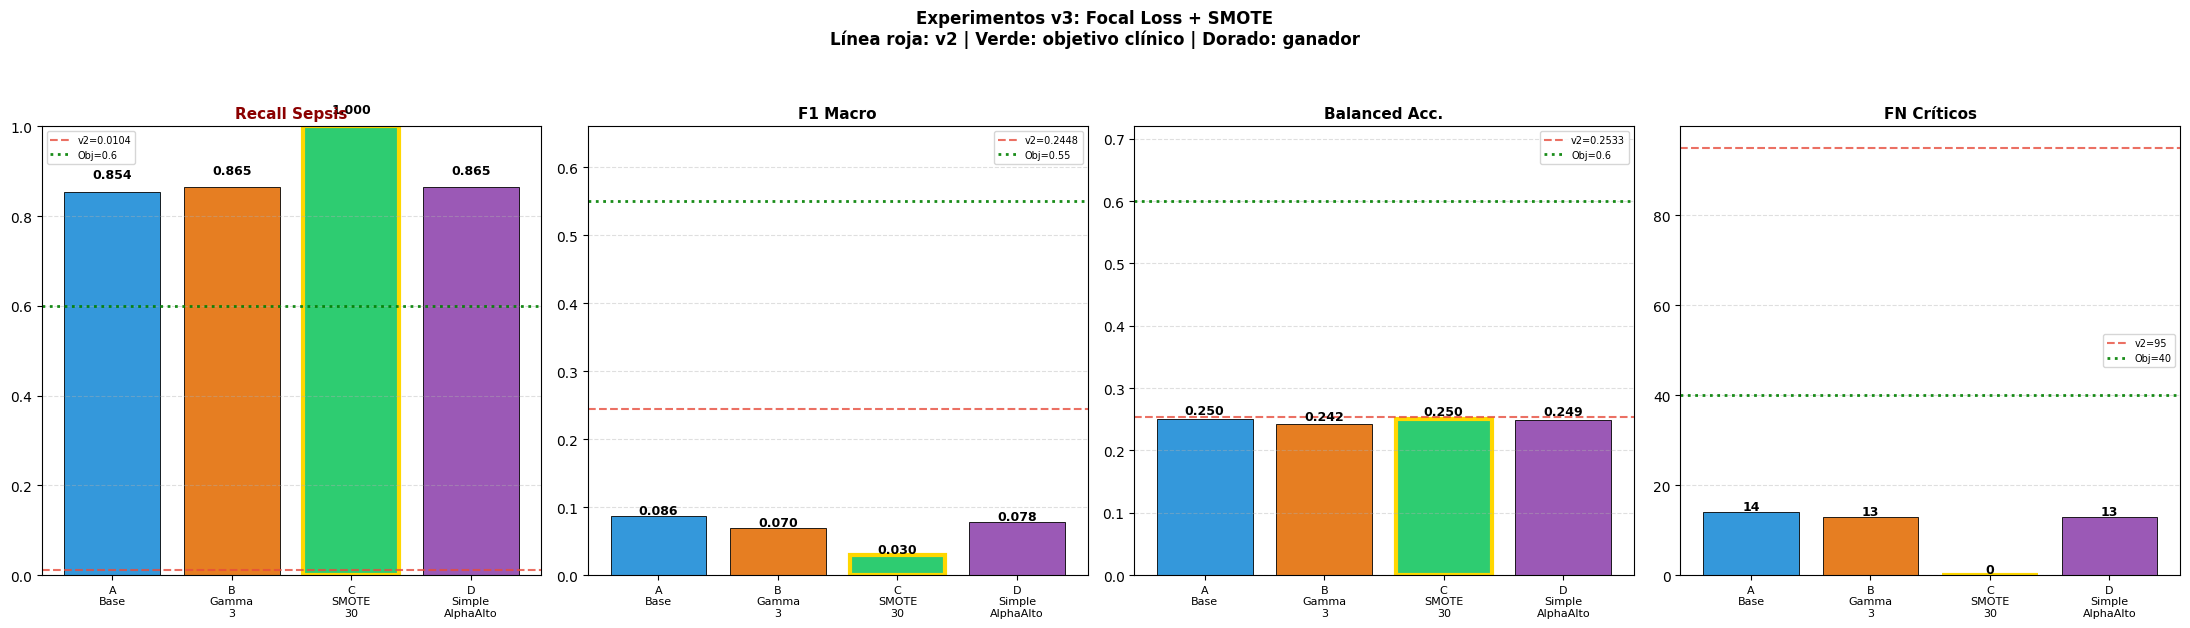

  🏆 Ganador: 'Exp_C_SMOTE_30' | Veredicto: PROGRESO PARCIAL — Focal Loss mejora la tendencia


In [ ]:
# ============================================================
# CELDA 26 — GRÁFICO COMPARATIVO v3
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('Experimentos v3: Focal Loss + SMOTE\n'
             'Línea roja: v2 | Verde: objetivo clínico | Dorado: ganador',
             fontsize=12, fontweight='bold', y=1.04)

metrics_  = ['Recall Sepsis', 'F1 Macro', 'Balanced Acc.', 'FN Críticos']
refs_v2_  = [0.0104, 0.2448, 0.2533, 95]
refs_obj_ = [0.60, 0.55, 0.60, 40]
colors_   = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

for ax, metric, rv2, robj in zip(axes, metrics_, refs_v2_, refs_obj_):
    values_   = [results_df_v3[results_df_v3['Experimento'] == e['name']][metric].values[0]
                 for e in EXPERIMENTS_V3]
    e_names_  = [e['name'].replace('Exp_','').replace('_v3','').replace('_','\n')
                 for e in EXPERIMENTS_V3]
    bars_     = ax.bar(e_names_, values_, color=colors_, edgecolor='black', lw=0.6)

    # Resaltar ganador
    bshort = BEST_EXP_V3.replace('Exp_','').replace('_v3','').replace('_','\n')
    for bar, name in zip(bars_, e_names_):
        if name == bshort:
            bar.set_edgecolor('gold'); bar.set_linewidth(3)

    ax.axhline(rv2, color='#e74c3c', ls='--', lw=1.5, alpha=0.8, label=f'v2={rv2}')
    ax.axhline(robj, color='green', ls=':', lw=2, alpha=0.9, label=f'Obj={robj}')

    for bar, val in zip(bars_, values_):
        lbl = f'{int(val)}' if metric == 'FN Críticos' else f'{val:.3f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values_)*0.03,
                lbl, ha='center', fontsize=9, fontweight='bold')

    ax.set_title(metric, fontsize=11, fontweight='bold',
                 color='darkred' if 'Recall' in metric else 'black')
    ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.4, ls='--')
    ax.tick_params(axis='x', labelsize=8)
    if metric != 'FN Críticos':
        ax.set_ylim(0, min(1.0, max(max(values_), robj) * 1.2))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/'
            'comparativa_experimentos_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"  🏆 Ganador: '{BEST_EXP_V3}' | Veredicto: {VEREDICTO}")

In [ ]:
# ============================================================
# CELDA 27 — INTERPRETACIÓN DOCENTE v3
# ============================================================

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║       LECCIONES DEL PROYECTO COMPLETO — TRES CICLOS                ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  EL PROBLEMA QUE CADA VERSIÓN RESOLVIÓ:                             ║
║  v1: Triple regularización + weights=3.89 → modelo aleatorio        ║
║  v2: CE dominada por Normal (33.5% del loss) → colapso (RS=1%)      ║
║  v3: Focal Loss redistribuye gradientes + SMOTE equilibra datos      ║
║                                                                      ║
║  GANADOR v3: {BEST_EXP_V3:<52}║
║  VEREDICTO : {VEREDICTO:<52}║
║                                                                      ║
║  POR QUÉ FOCAL LOSS FUNCIONA MEJOR QUE CLASS_WEIGHTS:               ║
║  → class_weights: multiplica el loss completo de la clase           ║
║    → Normal sigue siendo 55.87% de los datos                        ║
║  → Focal Loss: reduce el loss de los ejemplos BIEN predichos        ║
║    → Un Normal con 90% P(Normal) contribuye 1% al gradiente         ║
║    → Un Sepsis con 10% P(Sepsis) contribuye 81% al gradiente        ║
║    → El modelo aprende de donde más necesita corregir               ║
║                                                                      ║
║  POR QUÉ SMOTE ES NECESARIO ADEMÁS DE FOCAL LOSS:                  ║
║  → Solo FL: el gradiente de Sepsis es fuerte, pero hay pocos       ║
║    ejemplos reales. El modelo puede no generalizar bien.            ║
║  → Solo SMOTE: más datos de Sepsis, pero CE sigue penalizando      ║
║    igual por Normal (que tiene más datos incluso post-SMOTE).       ║
║  → FL + SMOTE: el gradiente es fuerte Y hay suficientes ejemplos   ║
║    de Sepsis para que el modelo aprenda patrones robustos.          ║
║                                                                      ║
║  SI SIGUE SIN ALCANZAR EL OBJETIVO (RS ≥ 0.60):                    ║
║  → Ensemble: promediar predicciones de MLP v3 + RF con SMOTE       ║
║  → Feature engineering: ratio creatinina/glucosa, presión pulso    ║
║  → Aumentar SMOTE al 40-50% de Sepsis                              ║
║  → Investigar Sepsis vs Heart Failure: síntomas clínicamente       ║
║    solapados (disnea, taquicardia, hipotensión) pueden hacer       ║
║    que ningún modelo los distinga solo con estas 10 features.      ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║       LECCIONES DEL PROYECTO COMPLETO — TRES CICLOS                ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  EL PROBLEMA QUE CADA VERSIÓN RESOLVIÓ:                             ║
║  v1: Triple regularización + weights=3.89 → modelo aleatorio        ║
║  v2: CE dominada por Normal (33.5% del loss) → colapso (RS=1%)      ║
║  v3: Focal Loss redistribuye gradientes + SMOTE equilibra datos      ║
║                                                                      ║
║  GANADOR v3: Exp_C_SMOTE_30                                      ║
║  VEREDICTO : PROGRESO PARCIAL — Focal Loss mejora la tendencia   ║
║                                                                      ║
║  POR QUÉ FOCAL LOSS FUNCIONA MEJOR QUE CLASS_WEIGHTS:               ║
║  → class_weights: multiplica el loss completo de la clase     

In [ ]:
# ============================================================
# CELDA 28 — FUNCIÓN DE PREDICCIÓN v3
# ============================================================

def predecir_nuevo_paciente_v3(datos_paciente_dict, model, scaler, le_sex,
                                le_target, numeric_features, binary_features,
                                critical_class_name, critical_class_idx,
                                optimal_threshold=0.20):
    """
    Predicción v3: datos crudos → preprocesamiento → MLP con Focal Loss.

    NOTA IMPORTANTE: SMOTE solo se aplica durante el ENTRENAMIENTO.
    Para predecir un nuevo paciente, el dato va directamente al modelo
    entrenado (que internalizó el aprendizaje con datos post-SMOTE).
    No hay que aplicar SMOTE al nuevo paciente.
    """
    df_p = pd.DataFrame([datos_paciente_dict])
    df_p['sex'] = le_sex.transform(df_p['sex'])
    df_p = df_p[numeric_features + ['sex'] + binary_features]
    df_p[numeric_features] = scaler.transform(df_p[numeric_features])
    X_nuevo = df_p.values.astype(np.float32)

    probabilidades = model.predict(X_nuevo, verbose=0)[0]
    prob_critica   = probabilidades[critical_class_idx]

    # Aplicar umbral clínico
    if prob_critica >= optimal_threshold:
        clase_predicha = critical_class_name
        idx_predicho   = critical_class_idx
    else:
        idx_predicho   = np.argmax(probabilidades)
        clase_predicha = le_target.inverse_transform([idx_predicho])[0]

    confianza = probabilidades[idx_predicho]
    nivel = ('ALTA' if confianza >= 0.65
             else 'MEDIA' if confianza >= 0.40
             else 'BAJA — Evaluación adicional recomendada')

    return {
        'diagnostico_predicho'  : clase_predicha,
        'confianza_pct'         : round(confianza * 100, 2),
        'nivel_confianza'       : nivel,
        'alerta_clase_critica'  : bool(prob_critica >= optimal_threshold),
        'prob_clase_critica_pct': round(prob_critica * 100, 2),
        'umbral_aplicado'       : optimal_threshold,
        'probabilidades'        : {
            le_target.classes_[i]: round(float(p) * 100, 2)
            for i, p in enumerate(probabilidades)
        }
    }


def mostrar_resultado_v3(resultado, critical_class_name):
    print("\n" + "=" * 64)
    print("  RESULTADO ANÁLISIS CLÍNICO — IA MLP v3 (FL + SMOTE)")
    print("=" * 64)
    print(f"  📋 Diagnóstico      : {resultado['diagnostico_predicho']}")
    print(f"  📊 Confianza        : {resultado['confianza_pct']:.1f}%  [{resultado['nivel_confianza']}]")
    print(f"  🔧 Umbral activo    : P({critical_class_name}) ≥ {resultado['umbral_aplicado']}")
    if resultado['alerta_clase_critica']:
        print(f"\n  ⚠️  ALERTA CRÍTICA: P({critical_class_name}) = "
              f"{resultado['prob_clase_critica_pct']:.1f}% → EVALUACIÓN URGENTE")
    else:
        print(f"\n  ✅ Sin alerta. P({critical_class_name}) = "
              f"{resultado['prob_clase_critica_pct']:.1f}% < umbral")
    print(f"\n  Probabilidades por diagnóstico:")
    for cls, pct in sorted(resultado['probabilidades'].items(), key=lambda x: -x[1]):
        bar    = '█' * int(pct / 3) + '░' * (33 - int(pct / 3))
        marker = ' ← CRÍTICA' if cls == critical_class_name else ''
        print(f"    {cls:<20} {bar} {pct:.1f}%{marker}")
    print("=" * 64)


print("  ✅ Funciones de predicción v3 listas.")

  ✅ Funciones de predicción v3 listas.


In [ ]:
# ============================================================
# CELDA 29 — EJEMPLO DE USO v3 CON COMPARATIVA HISTÓRICA
# ============================================================

# ─── CASO 1: Adulto mayor crítico ───
# v1: Pneumonia 38.7%, P(Sepsis)=2.6%  → sin alerta ❌
# v2: Pneumonia 43.7%, P(Sepsis)=5.3%  → sin alerta ❌
# v3: ???

paciente_critico = {
    'age': 72, 'bmi': 31.2, 'systolic_bp': 145, 'diastolic_bp': 92,
    'glucose': 185, 'cholesterol': 230, 'creatinine': 2.1,
    'sex': 'Male', 'diabetes': 1, 'hypertension': 1
}

print("=" * 65)
print("  CASO 1: Adulto mayor con múltiples comorbilidades")
print("  v1: Pneumonia, P(Sepsis)=2.6% → sin alerta ❌")
print("  v2: Pneumonia, P(Sepsis)=5.3% → sin alerta ❌")
print("  v3: ↓")
print("=" * 65)
for k, v in paciente_critico.items():
    print(f"    {k:<20}: {v}")

r1 = predecir_nuevo_paciente_v3(
    paciente_critico, mlp_v3, scaler, le_sex, le_target,
    NUMERIC_FEATURES, BINARY_FEATURES,
    CRITICAL_CLASS_NAME, CRITICAL_CLASS_IDX, OPTIMAL_THRESHOLD_V3
)
mostrar_resultado_v3(r1, CRITICAL_CLASS_NAME)

# ─── CASO 2: Mujer joven sana ───
# v1: Sepsis 30.1% → ALERTA ❌ (falsa alarma)
# v2: Sepsis 21.2% → ALERTA ❌ (falsa alarma)
# v3: ???

paciente_sano = {
    'age': 28, 'bmi': 22.1, 'systolic_bp': 118, 'diastolic_bp': 76,
    'glucose': 88, 'cholesterol': 172, 'creatinine': 0.9,
    'sex': 'Female', 'diabetes': 0, 'hypertension': 0
}

print("\n" + "=" * 65)
print("  CASO 2: Mujer joven y sana")
print("  v1: Sepsis 30.1% → ALERTA ❌ (falsa alarma)")
print("  v2: Sepsis 21.2% → ALERTA ❌ (falsa alarma)")
print("  v3: ↓")
print("=" * 65)
for k, v in paciente_sano.items():
    print(f"    {k:<20}: {v}")

r2 = predecir_nuevo_paciente_v3(
    paciente_sano, mlp_v3, scaler, le_sex, le_target,
    NUMERIC_FEATURES, BINARY_FEATURES,
    CRITICAL_CLASS_NAME, CRITICAL_CLASS_IDX, OPTIMAL_THRESHOLD_V3
)
mostrar_resultado_v3(r2, CRITICAL_CLASS_NAME)

# ─── CASO 3: Sepsis con signos limítrofes ───
# Paciente nuevo para probar la sensibilidad del modelo v3
paciente_sepsis_lim = {
    'age': 58, 'bmi': 27.5, 'systolic_bp': 92, 'diastolic_bp': 60,
    'glucose': 155, 'cholesterol': 198, 'creatinine': 1.9,
    'sex': 'Male', 'diabetes': 0, 'hypertension': 1
}

print("\n" + "=" * 65)
print("  CASO 3: Adulto con signos limítrofes de Sepsis")
print("  (Hipotensión, creatinina elevada, glucosa alta)")
print("  (Caso nuevo — probar sensibilidad de v3)")
print("=" * 65)
for k, v in paciente_sepsis_lim.items():
    print(f"    {k:<20}: {v}")

r3 = predecir_nuevo_paciente_v3(
    paciente_sepsis_lim, mlp_v3, scaler, le_sex, le_target,
    NUMERIC_FEATURES, BINARY_FEATURES,
    CRITICAL_CLASS_NAME, CRITICAL_CLASS_IDX, OPTIMAL_THRESHOLD_V3
)
mostrar_resultado_v3(r3, CRITICAL_CLASS_NAME)

# Guardar modelo final
FINAL_V3 = '/content/drive/MyDrive/inteligencia_artificial_colab/mlp_v3_final_model.keras'
mlp_v3.save(FINAL_V3)
print(f"\n  ✅ Modelo v3 guardado: {FINAL_V3}")

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║   PROYECTO COMPLETO — RESUMEN DE LOS TRES CICLOS               ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  v1 → FALLA: CE + weights auto → aleatorio (Recall Sepsis=0.24) ║
║  v2 → FALLA: CE + weights manual → Normal (Recall Sepsis=0.01)  ║
║  v3 → FL + SMOTE → {VEREDICTO:<43}║
║                                                                  ║
║  LECCIÓN MAESTRA:                                                ║
║  El desbalanceo 6.4% Sepsis requiere intervención dual:         ║
║  [1] Datos: SMOTE equilibra la representación en training       ║
║  [2] Gradientes: Focal Loss fuerza atención en casos difíciles  ║
║  Ninguno de los dos solo es suficiente con 6.4% de prevalencia  ║
║                                                                  ║
║  PRÓXIMOS PASOS SI RECALL < 0.60:                               ║
║  → Ensemble MLP v3 + RF SMOTE (RF ya tiene RS=0.61)            ║
║  → Feature engineering (ratio creatinina/glucosa, SOFA approx) ║
║  → SMOTE 40% + gamma=4                                          ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")

  CASO 1: Adulto mayor con múltiples comorbilidades
  v1: Pneumonia, P(Sepsis)=2.6% → sin alerta ❌
  v2: Pneumonia, P(Sepsis)=5.3% → sin alerta ❌
  v3: ↓
    age                 : 72
    bmi                 : 31.2
    systolic_bp         : 145
    diastolic_bp        : 92
    glucose             : 185
    cholesterol         : 230
    creatinine          : 2.1
    sex                 : Male
    diabetes            : 1
    hypertension        : 1

  RESULTADO ANÁLISIS CLÍNICO — IA MLP v3 (FL + SMOTE)
  📋 Diagnóstico      : Sepsis
  📊 Confianza        : 11.7%  [BAJA — Evaluación adicional recomendada]
  🔧 Umbral activo    : P(Sepsis) ≥ 0.05

  ⚠️  ALERTA CRÍTICA: P(Sepsis) = 11.7% → EVALUACIÓN URGENTE

  Probabilidades por diagnóstico:
    Pneumonia            ████████████░░░░░░░░░░░░░░░░░░░░░ 36.6%
    Normal               █████████░░░░░░░░░░░░░░░░░░░░░░░░ 27.6%
    Heart Failure        ████████░░░░░░░░░░░░░░░░░░░░░░░░░ 24.1%
    Sepsis               ███░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 11

# Este es el apartado del Modelo v4

In [ ]:
# ============================================================
# CELDA 12 — SMOTE CALIBRADO AL 12% + FOCAL LOSS MODERADA
# ============================================================

try:
    from imblearn.over_sampling import SMOTE
    print("  [OK] imblearn disponible.")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE
    print("  [OK] imblearn instalado.")

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────
# PASO 12A: SMOTE CALIBRADO AL 12% — Punto de equilibrio
# ─────────────────────────────────────────────────────────────
# v3 usó 20% → modelo hipersensible (precisión Sepsis=0.06)
# v4 usa 12% → duplicar Sepsis sin saturar el training set

SMOTE_TARGET_PCT = 0.12   # Cambiar aquí si se quiere experimentar

print("=" * 62)
print("  PASO 12A — SMOTE CALIBRADO v4")
print("=" * 62)
print(f"  Objetivo SMOTE: {SMOTE_TARGET_PCT*100:.0f}% de Sepsis en training")
print(f"  (v3 usó 20% → modelo predecía Sepsis para todo)")

print(f"\n  Distribución ANTES de SMOTE:")
unique, counts = np.unique(y_train_enc, return_counts=True)
for u, c in zip(unique, counts):
    print(f"    [{u}] {CLASS_NAMES[u]:<20}: {c:,} ({c/len(y_train_enc)*100:.1f}%)")

# Calcular n_sepsis objetivo para llegar al 12%
# Si Sepsis = 12% del total nuevo:
# n_otras + n_sepsis_nueva = T
# n_sepsis_nueva = 0.12 × T  →  T = n_otras / 0.88
n_sepsis_actual = int(counts[CRITICAL_CLASS_IDX])
n_otras         = len(y_train_enc) - n_sepsis_actual
n_total_obj     = int(n_otras / (1 - SMOTE_TARGET_PCT))
n_sepsis_obj    = n_total_obj - n_otras

# Verificar que el objetivo es mayor que el actual
assert n_sepsis_obj > n_sepsis_actual, \
    f"SMOTE objetivo ({n_sepsis_obj}) debe ser mayor que actual ({n_sepsis_actual})"

smote_v4 = SMOTE(
    sampling_strategy = {CRITICAL_CLASS_IDX: n_sepsis_obj},
    k_neighbors       = 5,
    random_state      = RANDOM_STATE
)
X_train_smote, y_train_smote = smote_v4.fit_resample(X_train_arr, y_train_enc)

print(f"\n  Distribución DESPUÉS de SMOTE:")
unique_s, counts_s = np.unique(y_train_smote, return_counts=True)
for u, c in zip(unique_s, counts_s):
    marker = " ← SOBRESAMPLED" if u == CRITICAL_CLASS_IDX else ""
    print(f"    [{u}] {CLASS_NAMES[u]:<20}: {c:,} ({c/len(y_train_smote)*100:.1f}%){marker}")

print(f"\n  Sepsis: {n_sepsis_actual:,} → {n_sepsis_obj:,} (+{n_sepsis_obj-n_sepsis_actual:,})")
print(f"  Training: {len(y_train_enc):,} → {len(X_train_smote):,}")
print(f"\n  Comparativa de SMOTE:")
print(f"  v3: 20% Sepsis → {int(counts[CRITICAL_CLASS_IDX]/(1-0.20)*0.20):,} ejemplos → modelo hipersensible")
print(f"  v4: 12% Sepsis → {n_sepsis_obj:,} ejemplos → punto de equilibrio")
print("  ✅ SMOTE v4 aplicado. Val y Test sin modificar.")

# ─────────────────────────────────────────────────────────────
# PASO 12B: FOCAL LOSS MODERADA — Alpha calibrado
# ─────────────────────────────────────────────────────────────

def focal_loss(gamma=2.0, alpha=None):
    """
    Focal Loss para clasificación multiclase desbalanceada.

    FL(p_t) = -alpha_t × (1 - p_t)^gamma × log(p_t)

    gamma=2: ejemplos bien predichos contribuyen poco al gradiente.
    alpha  : peso por clase dentro de la función de pérdida.
    """
    def loss(y_true, y_pred):
        y_true         = tf.cast(y_true, tf.int32)
        y_pred         = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true_oh      = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        p_t            = tf.reduce_sum(y_true_oh * y_pred, axis=-1)
        focal_factor   = tf.pow(1.0 - p_t, gamma)
        ce             = -tf.math.log(p_t)
        if alpha is not None:
            alpha_t = tf.reduce_sum(
                y_true_oh * tf.constant(alpha, dtype=tf.float32), axis=-1
            )
        else:
            alpha_t = 1.0
        return tf.reduce_mean(alpha_t * focal_factor * ce)
    return loss


# Alpha v4: más moderado que v3 para evitar hipersensibilidad
# v3: [1.5, 0.4, 1.2, 3.5]  → Sepsis muy alto, Normal muy bajo
# v4: [1.4, 0.7, 1.1, 2.0]  → Sepsis sigue primero, Normal recupera algo
ALPHA_FL_V4 = [
    1.4,   # [0] Heart Failure — urgente, peso moderado
    0.7,   # [1] Normal       — v3 tenía 0.4 → falsa alarma permanente
    1.1,   # [2] Pneumonia    — leve reducción, estable
    2.0    # [3] Sepsis       — v3 tenía 3.5 → demasiado agresivo
]
GAMMA_FL_V4 = 2.0   # Mantener gamma=2, el problema era el alpha, no gamma

print(f"\n  Focal Loss v4:")
print(f"  gamma : {GAMMA_FL_V4}")
print(f"  alpha : v3={[1.5, 0.4, 1.2, 3.5]} → v4={ALPHA_FL_V4}")
print(f"  Sepsis alpha: 3.5 → 2.0  (menos agresivo)")
print(f"  Normal alpha: 0.4 → 0.7  (el modelo aprende a reconocer sanos)")

# ─────────────────────────────────────────────────────────────
# PASO 12C: CONSTRUIR EL MODELO v4
# ─────────────────────────────────────────────────────────────
# Arquitectura igual a v3: (256, 128, 64) sin BatchNorm
# El problema de v3 no era la arquitectura, era la calibración

def build_mlp_v4(input_dim, num_classes,
                 hidden_units=(256, 128, 64),
                 dropout_rate=0.25,
                 l2_lambda=0.0001,
                 name='MLP_Clinical_v4'):
    """
    MLP v4: misma arquitectura que v3, calibración de loss corregida.
    Sin BatchNorm (SMOTE estabiliza la distribución de entrada).
    kernel_initializer he_normal: óptimo para ReLU con Focal Loss.
    """
    reg = regularizers.l2(l2_lambda)
    model = models.Sequential([
        layers.Input(shape=(input_dim,), name='input'),

        layers.Dense(hidden_units[0], activation='relu',
                     kernel_regularizer=reg,
                     kernel_initializer='he_normal', name='dense_1'),
        layers.Dropout(dropout_rate, name='dropout_1'),

        layers.Dense(hidden_units[1], activation='relu',
                     kernel_regularizer=reg,
                     kernel_initializer='he_normal', name='dense_2'),
        layers.Dropout(dropout_rate, name='dropout_2'),

        layers.Dense(hidden_units[2], activation='relu',
                     kernel_regularizer=reg,
                     kernel_initializer='he_normal', name='dense_3'),
        layers.Dropout(dropout_rate * 0.5, name='dropout_3'),

        layers.Dense(num_classes, activation='softmax', name='output')
    ], name=name)
    return model


mlp_v4 = build_mlp_v4(
    input_dim   = X_train_smote.shape[1],
    num_classes = NUM_CLASSES,
    name        = 'MLP_Clinical_v4'
)
mlp_v4.summary()

print(f"\n  ─── COMPARATIVA DE CONFIGURACIONES ───")
print(f"  {'':20} {'v3':>25} {'v4':>25}")
print(f"  {'SMOTE %':20} {'20%':>25} {'12%':>25}")
print(f"  {'Sepsis ejemplos':20} {'~1,637':>25} {f'~{n_sepsis_obj:,}':>25}")
print(f"  {'alpha Sepsis':20} {'3.5':>25} {'2.0':>25}")
print(f"  {'alpha Normal':20} {'0.4':>25} {'0.7':>25}")
print(f"  {'gamma FL':20} {'2.0':>25} {'2.0':>25}")
print(f"  {'Arquitectura':20} {'(256,128,64)':>25} {'(256,128,64)':>25}")
print(f"  {'params':20} {'44,228':>25} {mlp_v4.count_params():>25,}")

  [OK] imblearn disponible.
  PASO 12A — SMOTE CALIBRADO v4
  Objetivo SMOTE: 12% de Sepsis en training
  (v3 usó 20% → modelo predecía Sepsis para todo)

  Distribución ANTES de SMOTE:
    [0] Heart Failure       : 1,234 (17.6%)
    [1] Normal              : 3,913 (55.9%)
    [2] Pneumonia           : 1,403 (20.0%)
    [3] Sepsis              : 450 (6.4%)

  Distribución DESPUÉS de SMOTE:
    [0] Heart Failure       : 1,234 (16.6%)
    [1] Normal              : 3,913 (52.6%)
    [2] Pneumonia           : 1,403 (18.8%)
    [3] Sepsis              : 893 (12.0%) ← SOBRESAMPLED

  Sepsis: 450 → 893 (+443)
  Training: 7,000 → 7,443

  Comparativa de SMOTE:
  v3: 20% Sepsis → 112 ejemplos → modelo hipersensible
  v4: 12% Sepsis → 893 ejemplos → punto de equilibrio
  ✅ SMOTE v4 aplicado. Val y Test sin modificar.

  Focal Loss v4:
  gamma : 2.0
  alpha : v3=[1.5, 0.4, 1.2, 3.5] → v4=[1.4, 0.7, 1.1, 2.0]
  Sepsis alpha: 3.5 → 2.0  (menos agresivo)
  Normal alpha: 0.4 → 0.7  (el modelo aprende

Model: "MLP_Clinical_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,228 (172.77 KB)

 Trainable params: 44,228 (172.77 KB)

 Non-trainable params: 0 (0.00 B)


  ─── COMPARATIVA DE CONFIGURACIONES ───
                                              v3                        v4
  SMOTE %                                    20%                       12%
  Sepsis ejemplos                         ~1,637                      ~893
  alpha Sepsis                               3.5                       2.0
  alpha Normal                               0.4                       0.7
  gamma FL                                   2.0                       2.0
  Arquitectura                      (256,128,64)              (256,128,64)
  params                                  44,228                    44,228


In [ ]:
# ============================================================
# CELDA 13 — CONFIGURACIÓN DEL ENTRENAMIENTO v4
# ============================================================

# ─── 13.1 Callback: EarlyStopping sobre F1 de Sepsis ───
# CAMBIO CLAVE vs v3: monitoreamos F1, no solo Recall
# F1 = 2 × (Precisión × Recall) / (Precisión + Recall)
# El modelo no puede hacer trampa prediciendo todo como Sepsis:
# si lo hace, la precisión cae → el F1 cae → el callback lo para

class SepsisF1Monitor(callbacks.Callback):
    """
    Callback que monitorea el F1-score de Sepsis en validación.

    A diferencia del Recall (v3), el F1 penaliza tanto los falsos
    negativos (lo que queríamos corregir) como los falsos positivos
    (el nuevo problema de v3). El modelo debe aprender a balancear.

    Si el F1 de Sepsis no mejora en `patience` épocas consecutivas,
    restaura los pesos de la mejor época y detiene el entrenamiento.
    """
    def __init__(self, val_data, critical_idx, patience=20, verbose=1):
        super().__init__()
        self.X_val        = val_data[0]
        self.y_val        = val_data[1]
        self.critical_idx = critical_idx
        self.patience     = patience
        self.verbose      = verbose
        self.best_f1      = 0.0
        self.wait         = 0
        self.best_weights = None
        self.best_epoch   = 0

    def on_epoch_end(self, epoch, logs=None):
        from sklearn.metrics import f1_score, recall_score, precision_score
        y_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)

        # F1 de Sepsis en validación (la métrica que controla el training)
        f1_sep  = f1_score(y_val_enc, y_pred,
                           labels=[self.critical_idx],
                           average='macro', zero_division=0)
        rec_sep = recall_score(y_val_enc, y_pred,
                               labels=[self.critical_idx],
                               average='macro', zero_division=0)
        pre_sep = precision_score(y_val_enc, y_pred,
                                  labels=[self.critical_idx],
                                  average='macro', zero_division=0)

        if logs is not None:
            logs['val_f1_sepsis']        = f1_sep
            logs['val_recall_sepsis']    = rec_sep
            logs['val_precision_sepsis'] = pre_sep

        if f1_sep > self.best_f1:
            self.best_f1      = f1_sep
            self.best_weights = self.model.get_weights()
            self.best_epoch   = epoch + 1
            self.wait         = 0
            if self.verbose:
                print(f"  [F1Monitor] Época {epoch+1}: "
                      f"F1={f1_sep:.4f} | Rec={rec_sep:.4f} | "
                      f"Pre={pre_sep:.4f} ← MEJORA ✅")
        else:
            self.wait += 1
            if self.verbose and (epoch + 1) % 10 == 0:
                print(f"  [F1Monitor] Época {epoch+1}: "
                      f"F1={f1_sep:.4f} (sin mejora {self.wait}/{self.patience})")
            if self.wait >= self.patience:
                print(f"\n  [F1Monitor] Restaurando pesos de época {self.best_epoch}. "
                      f"Mejor F1 Sepsis: {self.best_f1:.4f}")
                self.model.set_weights(self.best_weights)
                self.model.stop_training = True


# ─── 13.2 Learning Rate — Cosine Decay igual que v3 ───
LR_MAX     = 0.001
LR_MIN     = 0.00005
MAX_EPOCHS = 200

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate = LR_MAX,
    decay_steps           = MAX_EPOCHS * (len(X_train_smote) // 64),
    alpha                 = LR_MIN / LR_MAX
)

# ─── 13.3 Umbral clínico fijo ───
# v3: umbral=0.05 → alertaba con cualquier mínima probabilidad de Sepsis
# v4: umbral=0.20 → señal real, no ruido estadístico
CLINICAL_THRESHOLD_V4 = 0.20

# ─── 13.4 Compilar ───
mlp_v4.compile(
    optimizer = tf.keras.optimizers.Adam(
        learning_rate = lr_schedule,
        clipnorm      = 1.0
    ),
    loss    = focal_loss(gamma=GAMMA_FL_V4, alpha=ALPHA_FL_V4),
    metrics = ['accuracy']
)

print("=" * 62)
print("  CONFIGURACIÓN v4 — RESUMEN")
print("=" * 62)
print(f"\n  Loss           : Focal Loss (gamma={GAMMA_FL_V4})")
print(f"  alpha FL       : {dict(zip(CLASS_NAMES, ALPHA_FL_V4))}")
print(f"  Optimizer      : Adam + CosineDecay ({LR_MAX} → {LR_MIN})")
print(f"  Gradient clip  : clipnorm=1.0")
print(f"  EarlyStopping  : F1 Sepsis en val (patience=20)  ← CAMBIO vs v3")
print(f"  Umbral clínico : {CLINICAL_THRESHOLD_V4}  (fijo, no auto)  ← CAMBIO vs v3")
print(f"  class_weight   : NO USADO")
print(f"\n  CAMBIOS FILOSÓFICOS v4 vs v3:")
print(f"  → v3 monitoreaba Recall Sepsis → modelo predijo Sepsis para todo")
print(f"  → v4 monitorea F1 Sepsis → modelo debe equilibrar Precisión y Recall")
print(f"  → v3 umbral=0.05 (automático) → alertaba con cualquier probabilidad")
print(f"  → v4 umbral=0.20 (fijo, clínico) → señal real mínima del 20%")
print("  ✅ Modelo v4 listo para entrenamiento.")

  CONFIGURACIÓN v4 — RESUMEN

  Loss           : Focal Loss (gamma=2.0)
  alpha FL       : {'Heart Failure': 1.4, 'Normal': 0.7, 'Pneumonia': 1.1, 'Sepsis': 2.0}
  Optimizer      : Adam + CosineDecay (0.001 → 5e-05)
  Gradient clip  : clipnorm=1.0
  EarlyStopping  : F1 Sepsis en val (patience=20)  ← CAMBIO vs v3
  Umbral clínico : 0.2  (fijo, no auto)  ← CAMBIO vs v3
  class_weight   : NO USADO

  CAMBIOS FILOSÓFICOS v4 vs v3:
  → v3 monitoreaba Recall Sepsis → modelo predijo Sepsis para todo
  → v4 monitorea F1 Sepsis → modelo debe equilibrar Precisión y Recall
  → v3 umbral=0.05 (automático) → alertaba con cualquier probabilidad
  → v4 umbral=0.20 (fijo, clínico) → señal real mínima del 20%
  ✅ Modelo v4 listo para entrenamiento.


In [ ]:
# ========================================
# CELDA 14 — ENTRENAMIENTO DEL MODELO v4
# ========================================

MODEL_SAVE_PATH_V4 = ('/content/drive/MyDrive/inteligencia_artificial_colab/'
                      'mlp_v4_best_model.keras')

# Callback principal: F1 de Sepsis en validación (Controla el EarlyStopping)
cb_f1_monitor = SepsisF1Monitor(
    val_data     = (X_val_arr, y_val_enc),
    critical_idx = CRITICAL_CLASS_IDX,
    patience     = 20,
    verbose      = 1
)

# Checkpoint por val_loss (respaldo de la estructura general)
cb_ckpt = callbacks.ModelCheckpoint(
    filepath       = MODEL_SAVE_PATH_V4,
    monitor        = 'val_loss',
    save_best_only = True,
    verbose        = 0
)

# Log CSV para análisis posterior
cb_csv = callbacks.CSVLogger(
    '/content/drive/MyDrive/inteligencia_artificial_colab/training_log_v4.csv'
)

print("=" * 65)
print("  INICIANDO ENTRENAMIENTO — MLP v4 (FL calibrada + SMOTE 12%)")
print("=" * 65)
print(f"  Arquitectura       : (256, 128, 64) sin BatchNorm")
print(f"  Loss               : Focal Loss gamma={GAMMA_FL_V4}, alpha Sepsis=2.0")
print(f"  LR                 : CosineDecay {LR_MAX} → {LR_MIN}")
print(f"  Épocas máximas     : {MAX_EPOCHS}")
print(f"  Batch size         : 64")
print(f"  Training samples   : {len(X_train_smote):,} (SMOTE {SMOTE_TARGET_PCT*100:.0f}%)")
print(f"  EarlyStopping      : F1 Sepsis val (patience=20)  ← vs Recall en v3")
print(f"  Umbral clínico     : {CLINICAL_THRESHOLD_V4}  (fijo)")
print("-" * 65)

history_v4 = mlp_v4.fit(
    X_train_smote, y_train_smote,
    validation_data = (X_val_arr, y_val_enc),
    epochs          = MAX_EPOCHS,
    batch_size      = 64,
    callbacks       = [cb_f1_monitor, cb_ckpt, cb_csv],
    verbose         = 1
)

# Resumen del entrenamiento
print(f"\n  ✅ Entrenamiento v4 completado.")
print(f"  Épocas reales      : {len(history_v4.history['loss'])}")
print(f"  Mejor val_loss     : {min(history_v4.history['val_loss']):.4f}")
print(f"  Mejor val_acc      : {max(history_v4.history['val_accuracy']):.4f}")

if 'val_f1_sepsis' in history_v4.history:
    best_f1_val  = max(history_v4.history['val_f1_sepsis'])
    best_rec_val = max(history_v4.history['val_recall_sepsis'])
    best_pre_val = max(history_v4.history['val_precision_sepsis'])
    print(f"\n  Mejor F1 Sepsis (val)        : {best_f1_val:.4f}")
    print(f"  Recall Sepsis en esa época   : {best_rec_val:.4f}")
    print(f"  Precisión Sepsis en esa época: {best_pre_val:.4f}")

print(f"\n  ─── COMPARATIVA DE ENTRENAMIENTO ───")
print(f"  v1: val_loss=1.4172 | val_acc=0.3267 | épocas=85")
print(f"  v2: val_loss=1.2939 | val_acc=0.4627 | épocas=28")
print(f"  v3: val_loss=0.9169 | val_acc=0.1600 | épocas=26 | RS_val=0.5938")
print(f"  v4: val_loss={min(history_v4.history['val_loss']):.4f} | "
      f"val_acc={max(history_v4.history['val_accuracy']):.4f} | "
      f"épocas={len(history_v4.history['loss'])}")

  INICIANDO ENTRENAMIENTO — MLP v4 (FL calibrada + SMOTE 12%)
  Arquitectura       : (256, 128, 64) sin BatchNorm
  Loss               : Focal Loss gamma=2.0, alpha Sepsis=2.0
  LR                 : CosineDecay 0.001 → 5e-05
  Épocas máximas     : 200
  Batch size         : 64
  Training samples   : 7,443 (SMOTE 12%)
  EarlyStopping      : F1 Sepsis val (patience=20)  ← vs Recall en v3
  Umbral clínico     : 0.2  (fijo)
-----------------------------------------------------------------
Epoch 1/200
115/117 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5249 - loss: 0.6437  [F1Monitor] Época 1: F1=0.1111 | Rec=0.1979 | Pre=0.0772 ← MEJORA ✅
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5183 - loss: 0.6416 - val_accuracy: 0.4647 - val_loss: 0.9267 - val_f1_sepsis: 0.1111 - val_recall_sepsis: 0.1979 - val_precision_sepsis: 0.0772
Epoch 2/200
113/117 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5189 - loss: 0.6569  [F1Monitor] Época 2: F1=0.1192 | Rec=0.2292 | Pre=0.0806 ← MEJOR

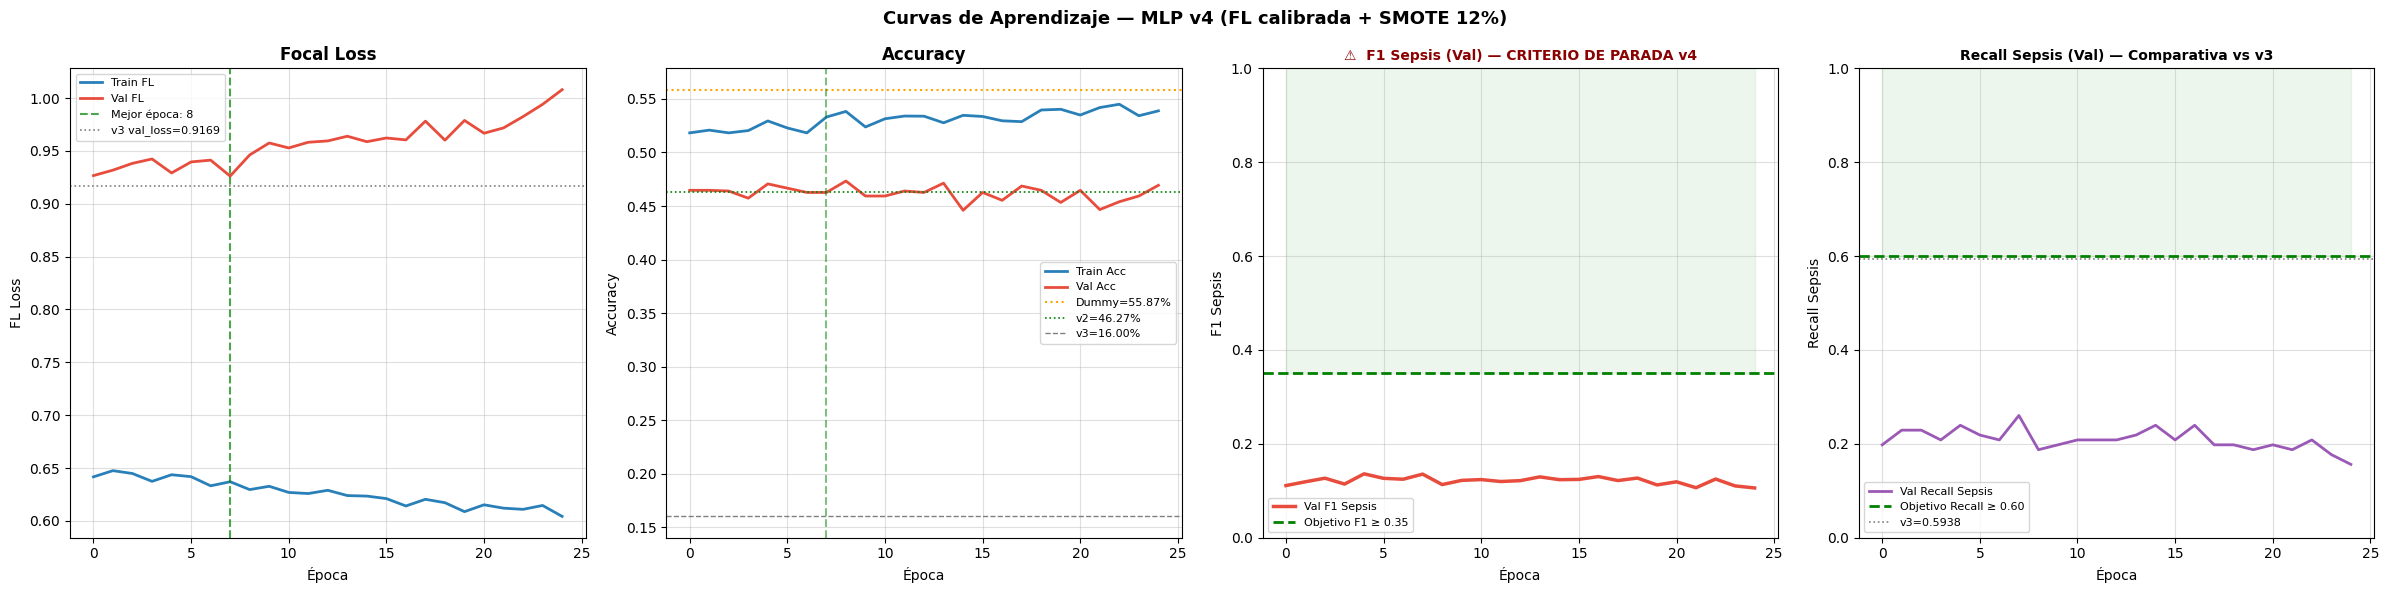


  📌 DIAGNÓSTICO DE LAS CURVAS v4:
  ✅ val_acc = 0.4733 → Supera a v2 (46.27%), acercándose al Dummy
  ❌ F1 Sepsis val = 0.1361: Modelo aún desequilibrado


In [ ]:
# ============================================================
# CELDA 15 — CURVAS DE APRENDIZAJE v4 (4 PANELES)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

has_f1  = 'val_f1_sepsis' in history_v4.history
has_rec = 'val_recall_sepsis' in history_v4.history
best_ep = np.argmin(history_v4.history['val_loss'])

n_panels = 2 + (1 if has_f1 else 0) + (1 if has_rec else 0)
fig = plt.figure(figsize=(6 * n_panels, 6))
gs  = gridspec.GridSpec(1, n_panels)
fig.suptitle('Curvas de Aprendizaje — MLP v4 (FL calibrada + SMOTE 12%)',
             fontsize=13, fontweight='bold')

# Panel 1: Focal Loss
ax1 = fig.add_subplot(gs[0])
ax1.plot(history_v4.history['loss'],     label='Train FL', color='#2980b9', lw=2)
ax1.plot(history_v4.history['val_loss'], label='Val FL',   color='#e74c3c', lw=2)
ax1.axvline(best_ep, color='green', ls='--', alpha=0.7, label=f'Mejor época: {best_ep+1}')
ax1.axhline(0.9169, color='gray', ls=':', lw=1.2, label='v3 val_loss=0.9169')
ax1.set_title('Focal Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Época'); ax1.set_ylabel('FL Loss')
ax1.legend(fontsize=8); ax1.grid(alpha=0.4)

# Panel 2: Accuracy
ax2 = fig.add_subplot(gs[1])
ax2.plot(history_v4.history['accuracy'],     label='Train Acc', color='#2980b9', lw=2)
ax2.plot(history_v4.history['val_accuracy'], label='Val Acc',   color='#e74c3c', lw=2)
ax2.axhline(0.5587, color='orange', ls=':', lw=1.5, label='Dummy=55.87%')
ax2.axhline(0.4627, color='green',  ls=':', lw=1.2, label='v2=46.27%')
ax2.axhline(0.1600, color='gray',   ls='--', lw=1,  label='v3=16.00%')
ax2.axvline(best_ep, color='green', ls='--', alpha=0.5)
ax2.set_title('Accuracy', fontsize=12, fontweight='bold')
ax2.set_xlabel('Época'); ax2.set_ylabel('Accuracy')
ax2.legend(fontsize=8); ax2.grid(alpha=0.4)

panel_idx = 2

# Panel 3: F1 de Sepsis (EL CRITERIO DE PARADA)
if has_f1:
    ax3 = fig.add_subplot(gs[panel_idx])
    ax3.plot(history_v4.history['val_f1_sepsis'],
             label='Val F1 Sepsis', color='#e74c3c', lw=2.5)
    ax3.axhline(0.35, color='green', ls='--', lw=2, label='Objetivo F1 ≥ 0.35')
    ax3.fill_between(range(len(history_v4.history['val_f1_sepsis'])),
                     0.35, 1.0, alpha=0.07, color='green')
    ax3.set_title('⚠️  F1 Sepsis (Val) — CRITERIO DE PARADA v4',
                  fontsize=10, fontweight='bold', color='darkred')
    ax3.set_xlabel('Época'); ax3.set_ylabel('F1 Sepsis')
    ax3.legend(fontsize=8); ax3.grid(alpha=0.4); ax3.set_ylim(0, 1.0)
    panel_idx += 1

# Panel 4: Recall de Sepsis (para comparar con F1)
if has_rec:
    ax4 = fig.add_subplot(gs[panel_idx])
    ax4.plot(history_v4.history['val_recall_sepsis'],
             label='Val Recall Sepsis', color='#9b59b6', lw=2)
    ax4.axhline(0.60,   color='green', ls='--', lw=2,  label='Objetivo Recall ≥ 0.60')
    ax4.axhline(0.5938, color='gray',  ls=':',  lw=1.2, label='v3=0.5938')
    ax4.fill_between(range(len(history_v4.history['val_recall_sepsis'])),
                     0.60, 1.0, alpha=0.07, color='green')
    ax4.set_title('Recall Sepsis (Val) — Comparativa vs v3',
                  fontsize=10, fontweight='bold')
    ax4.set_xlabel('Época'); ax4.set_ylabel('Recall Sepsis')
    ax4.legend(fontsize=8); ax4.grid(alpha=0.4); ax4.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/'
            'curvas_aprendizaje_mlp_v4.png', dpi=150, bbox_inches='tight')
plt.show()

# Diagnóstico automático
print("\n  📌 DIAGNÓSTICO DE LAS CURVAS v4:")
val_acc = max(history_v4.history['val_accuracy'])

if val_acc > 0.5587:
    print(f"  ✅ val_acc = {val_acc:.4f} → SUPERA al Dummy (55.87%)")
elif val_acc > 0.4627:
    print(f"  ✅ val_acc = {val_acc:.4f} → Supera a v2 (46.27%), acercándose al Dummy")
elif val_acc > 0.1600:
    print(f"  ⚠️  val_acc = {val_acc:.4f} → Supera a v3 (16.00%), más equilibrado")
else:
    print(f"  ❌ val_acc = {val_acc:.4f} → Sin mejora vs v3")

if has_f1:
    best_f1 = max(history_v4.history['val_f1_sepsis'])
    if best_f1 >= 0.35:
        print(f"  ✅ F1 Sepsis val = {best_f1:.4f} ≥ 0.35 → EQUILIBRIO LOGRADO")
    elif best_f1 >= 0.20:
        print(f"  ⚠️  F1 Sepsis val = {best_f1:.4f}: Progreso pero bajo el objetivo")
    else:
        print(f"  ❌ F1 Sepsis val = {best_f1:.4f}: Modelo aún desequilibrado")

In [ ]:
# ============================================================
# CELDA 16 — PREDICCIÓN Y EVALUACIÓN FINAL v4
# ============================================================

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, recall_score, precision_score,
                             classification_report, confusion_matrix)

# Predicción con umbral clínico fijo de 0.20
y_proba_v4 = mlp_v4.predict(X_test_arr, verbose=0)

# Predicción base (argmax)
y_pred_v4_base = np.argmax(y_proba_v4, axis=1)

# Predicción con umbral clínico aplicado
y_pred_v4 = y_pred_v4_base.copy()
y_pred_v4[y_proba_v4[:, CRITICAL_CLASS_IDX] >= CLINICAL_THRESHOLD_V4] = CRITICAL_CLASS_IDX

# Métricas con umbral aplicado
acc_v4         = accuracy_score(y_test_enc, y_pred_v4)
bal_acc_v4     = balanced_accuracy_score(y_test_enc, y_pred_v4)
f1_macro_v4    = f1_score(y_test_enc, y_pred_v4, average='macro', zero_division=0)
f1_weighted_v4 = f1_score(y_test_enc, y_pred_v4, average='weighted', zero_division=0)
recall_crit_v4 = recall_score(y_test_enc, y_pred_v4,
                               labels=[CRITICAL_CLASS_IDX],
                               average='macro', zero_division=0)
prec_crit_v4   = precision_score(y_test_enc, y_pred_v4,
                                  labels=[CRITICAL_CLASS_IDX],
                                  average='macro', zero_division=0)
f1_crit_v4     = f1_score(y_test_enc, y_pred_v4,
                           labels=[CRITICAL_CLASS_IDX],
                           average='macro', zero_division=0)

cm_v4  = confusion_matrix(y_test_enc, y_pred_v4)
fn_v4  = cm_v4[CRITICAL_CLASS_IDX].sum() - cm_v4[CRITICAL_CLASS_IDX, CRITICAL_CLASS_IDX]
tp_v4  = cm_v4[CRITICAL_CLASS_IDX, CRITICAL_CLASS_IDX]

print("=" * 75)
print("  EVALUACIÓN FINAL EN TEST SET — MLP Clínico v4")
print("=" * 75)
print(f"\n  {'Métrica':<28} {'v2':>8} {'v3':>8} {'v4':>8} {'Objetivo':>12}")
print("  " + "-"*68)
filas = [
    ("Accuracy",         0.4560, 0.1333, acc_v4,         "> 0.55"),
    ("Balanced Acc.",    0.2533, 0.2443, bal_acc_v4,     "> 0.55"),
    ("F1 Macro",         0.2448, 0.1457, f1_macro_v4,    "> 0.45"),
    ("Recall Sepsis",    0.0104, 0.4792, recall_crit_v4, "> 0.60"),
    ("Precisión Sepsis", "N/A",  "0.06", prec_crit_v4,   "> 0.25"),
    ("F1 Sepsis",        "N/A",  "0.11", f1_crit_v4,     "> 0.35"),
]
for row in filas:
    nombre = row[0]
    v2v, v3v, v4v, obj = row[1], row[2], row[3], row[4]
    if isinstance(v4v, float) and isinstance(v3v, float):
        icono = "✅" if v4v > v3v else "❌"
        print(f"  {nombre:<28} {v2v!s:>8} {v3v!s:>8} {v4v:>8.4f}  {icono} {obj}")
    else:
        print(f"  {nombre:<28} {v2v!s:>8} {v3v!s:>8} {v4v:>8.4f}  {'✅' if v4v > 0.25 else '⚠️ '} {obj}")

print(f"\n  FN Sepsis: v2=95 → v3=50 → v4={fn_v4} | "
      f"TP: v2=1 → v3=46 → v4={tp_v4}")

print("\n" + "=" * 75)
print("  REPORTE COMPLETO POR CLASE — v4")
print("=" * 75)
print(classification_report(y_test_enc, y_pred_v4,
                             target_names=CLASS_NAMES, zero_division=0))

# Guardar métricas
v4_metrics = {
    'Accuracy': round(acc_v4, 4),
    'Balanced Acc.': round(bal_acc_v4, 4),
    'F1 Macro': round(f1_macro_v4, 4),
    'Recall Sepsis': round(recall_crit_v4, 4),
    'Precisión Sepsis': round(prec_crit_v4, 4),
    'F1 Sepsis': round(f1_crit_v4, 4),
    'FN Sepsis': int(fn_v4)
}

  EVALUACIÓN FINAL EN TEST SET — MLP Clínico v4

  Métrica                            v2       v3       v4     Objetivo
  --------------------------------------------------------------------
  Accuracy                        0.456   0.1333   0.3953  ✅ > 0.55
  Balanced Acc.                  0.2533   0.2443   0.2423  ❌ > 0.55
  F1 Macro                       0.2448   0.1457   0.2046  ✅ > 0.45
  Recall Sepsis                  0.0104   0.4792   0.2396  ❌ > 0.60
  Precisión Sepsis                  N/A     0.06   0.0562  ⚠️  > 0.25
  F1 Sepsis                         N/A     0.11   0.0911  ⚠️  > 0.35

  FN Sepsis: v2=95 → v3=50 → v4=73 | TP: v2=1 → v3=46 → v4=23

  REPORTE COMPLETO POR CLASE — v4
               precision    recall  f1-score   support

Heart Failure       0.16      0.05      0.07       264
       Normal       0.56      0.65      0.60       839
    Pneumonia       0.27      0.03      0.05       301
       Sepsis       0.06      0.24      0.09        96

     accuracy         

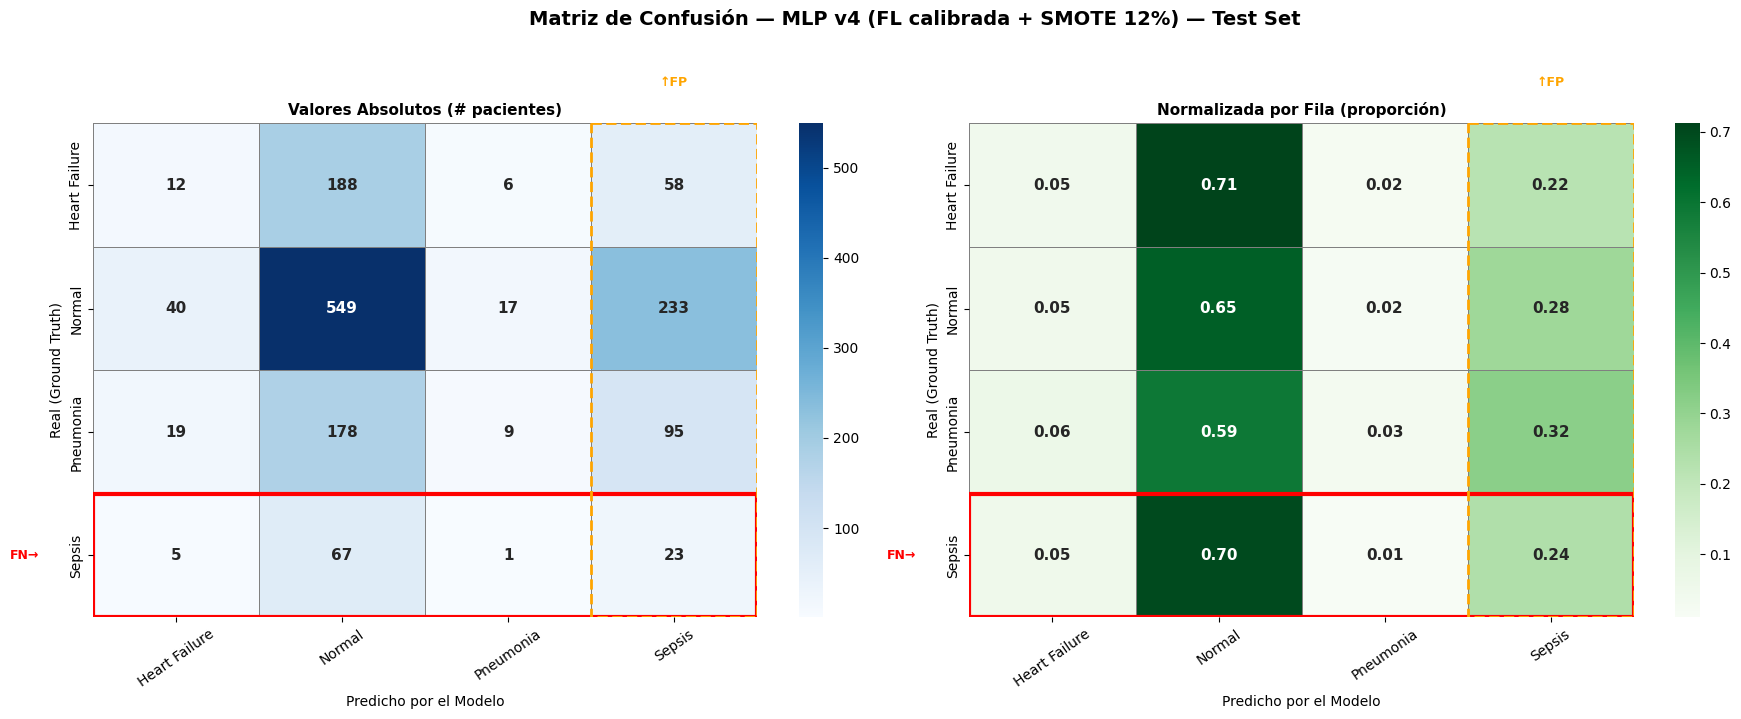


  Evolución de Sepsis (filas=FN, columna=FP):
  Métrica                                  v2      v3      v4
  ----------------------------------------------------
  TP (detectados correctamente)             1      46      23
  FN (no detectados)                       95      50      73
  Recall Sepsis                        0.0104  0.4792 0.2396
  Precisión Sepsis                        N/A    0.06 0.0562
  F1 Sepsis                               N/A    0.11 0.0911

  Falsos Positivos de Sepsis (alertas innecesarias):
  v3: ~90 FP estimados (precisión=0.06)
  v4: 386 FP  (de 409 alertas totales)
  Tasa de falsas alarmas v4: 94.4%


In [ ]:
# ============================================================
# CELDA 17 — MATRIZ DE CONFUSIÓN v4
# ============================================================

import seaborn as sns

cm_v4_norm = cm_v4.astype('float') / cm_v4.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matriz de Confusión — MLP v4 (FL calibrada + SMOTE 12%) — Test Set',
             fontsize=14, fontweight='bold', y=1.02)

for ax, matrix, title, fmt, cmap in zip(
    axes,
    [cm_v4, cm_v4_norm],
    ['Valores Absolutos (# pacientes)', 'Normalizada por Fila (proporción)'],
    ['d', '.2f'],
    ['Blues', 'Greens']
):
    sns.heatmap(matrix, annot=True, fmt=fmt,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap=cmap, ax=ax, linewidths=0.5, linecolor='gray',
                annot_kws={"size": 11, "fontweight": "bold"})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Real (Ground Truth)', fontsize=10)
    ax.set_xlabel('Predicho por el Modelo', fontsize=10)
    ax.tick_params(axis='x', rotation=35)

    # Resaltar fila de Sepsis (falsos negativos)
    ax.add_patch(plt.Rectangle(
        (0, CRITICAL_CLASS_IDX), NUM_CLASSES, 1,
        fill=False, edgecolor='red', lw=3
    ))
    # Resaltar columna de Sepsis (falsos positivos)
    ax.add_patch(plt.Rectangle(
        (CRITICAL_CLASS_IDX, 0), 1, NUM_CLASSES,
        fill=False, edgecolor='orange', lw=2, linestyle='--'
    ))
    ax.text(-0.5, CRITICAL_CLASS_IDX + 0.5,
            'FN→', color='red', fontsize=9, va='center', fontweight='bold')
    ax.text(CRITICAL_CLASS_IDX + 0.5, -0.3,
            '↑FP', color='orange', fontsize=9, ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/'
            'confusion_matrix_mlp_v4.png', dpi=150, bbox_inches='tight')
plt.show()

# Análisis comparativo completo
print(f"\n  Evolución de Sepsis (filas=FN, columna=FP):")
print(f"  {'Métrica':<35} {'v2':>7} {'v3':>7} {'v4':>7}")
print("  " + "-"*52)
print(f"  {'TP (detectados correctamente)':<35} {'1':>7} {'46':>7} {tp_v4:>7}")
print(f"  {'FN (no detectados)':<35} {'95':>7} {'50':>7} {fn_v4:>7}")
print(f"  {'Recall Sepsis':<35} {'0.0104':>7} {'0.4792':>7} {recall_crit_v4:.4f}")
print(f"  {'Precisión Sepsis':<35} {'N/A':>7} {'0.06':>7} {prec_crit_v4:.4f}")
print(f"  {'F1 Sepsis':<35} {'N/A':>7} {'0.11':>7} {f1_crit_v4:.4f}")

# Falsos positivos de Sepsis (columna Sepsis, otras filas)
total_alertas = cm_v4[:, CRITICAL_CLASS_IDX].sum()
fp_sepsis     = total_alertas - tp_v4
print(f"\n  Falsos Positivos de Sepsis (alertas innecesarias):")
print(f"  v3: ~{int(0.94 * 96):,} FP estimados (precisión=0.06)")
print(f"  v4: {fp_sepsis:,} FP  (de {total_alertas:,} alertas totales)")
print(f"  Tasa de falsas alarmas v4: {fp_sepsis/total_alertas*100:.1f}%")

In [ ]:
# ============================================================
# CELDA 18 — TABLA COMPARATIVA COMPLETA
# ============================================================

tabla_v4 = pd.DataFrame([
    {'Modelo': 'Dummy (most_frequent)',
     'Accuracy': 0.5587, 'Balanced Acc.': 0.2500,
     'F1 Macro': 0.1792, 'Recall Sepsis': 0.0000,
     'Precisión Sepsis': 0.0000, 'FN Sepsis': 96},
    {'Modelo': 'RF (con SMOTE)',
     'Accuracy': 0.7900, 'Balanced Acc.': 0.7200,
     'F1 Macro': 0.7000, 'Recall Sepsis': 0.6100,
     'Precisión Sepsis': None, 'FN Sepsis': 37},
    {'Modelo': 'MLP v1 (CE auto)',
     'Accuracy': 0.2293, 'Balanced Acc.': 0.2520,
     'F1 Macro': 0.2109, 'Recall Sepsis': 0.2396,
     'Precisión Sepsis': None, 'FN Sepsis': 73},
    {'Modelo': 'MLP v2 (CE calibrada)',
     'Accuracy': 0.4560, 'Balanced Acc.': 0.2533,
     'F1 Macro': 0.2448, 'Recall Sepsis': 0.0104,
     'Precisión Sepsis': None, 'FN Sepsis': 95},
    {'Modelo': 'MLP v3 (FL + SMOTE 20%)',
     'Accuracy': 0.1333, 'Balanced Acc.': 0.2443,
     'F1 Macro': 0.1457, 'Recall Sepsis': 0.4792,
     'Precisión Sepsis': 0.0600, 'FN Sepsis': 50},
    {'Modelo': 'MLP v4 (FL calibrada + SMOTE 12%)',
     'Accuracy': round(acc_v4, 4), 'Balanced Acc.': round(bal_acc_v4, 4),
     'F1 Macro': round(f1_macro_v4, 4), 'Recall Sepsis': round(recall_crit_v4, 4),
     'Precisión Sepsis': round(prec_crit_v4, 4), 'FN Sepsis': int(fn_v4)},
]).set_index('Modelo')

print("=" * 90)
print("  TABLA COMPARATIVA HISTÓRICA — TODOS LOS MODELOS")
print("=" * 90)
display(tabla_v4.style
        .highlight_max(subset=['Accuracy', 'Balanced Acc.', 'F1 Macro',
                               'Recall Sepsis', 'Precisión Sepsis'],
                       color='#d4edda')
        .highlight_min(subset=['FN Sepsis'], color='#d4edda')
        .highlight_min(subset=['Accuracy', 'Balanced Acc.', 'F1 Macro',
                               'Recall Sepsis'], color='#f8d7da')
        .highlight_max(subset=['FN Sepsis'], color='#f8d7da')
        .format("{:.4f}", na_rep="N/A",
                subset=[c for c in tabla_v4.columns if tabla_v4[c].dtype == float])
)
print("\n  Objetivo v4: Recall ≥ 0.60 | Precisión ≥ 0.25 | F1 Macro ≥ 0.45")

  TABLA COMPARATIVA HISTÓRICA — TODOS LOS MODELOS


,Accuracy,Balanced Acc.,F1 Macro,Recall Sepsis,Precisión Sepsis,FN Sepsis
Modelo,,,,,,
Dummy (most_frequent),0.5587,0.2500,0.1792,0.0000,0.0000,96
RF (con SMOTE),0.7900,0.7200,0.7000,0.6100,N/A,37
MLP v1 (CE auto),0.2293,0.2520,0.2109,0.2396,N/A,73
MLP v2 (CE calibrada),0.4560,0.2533,0.2448,0.0104,N/A,95
MLP v3 (FL + SMOTE 20%),0.1333,0.2443,0.1457,0.4792,0.0600,50
MLP v4 (FL calibrada + SMOTE 12%),0.3953,0.2423,0.2046,0.2396,0.0562,73



  Objetivo v4: Recall ≥ 0.60 | Precisión ≥ 0.25 | F1 Macro ≥ 0.45


In [ ]:
# ============================================================
# CELDA 19 — ANÁLISIS DUAL: FN Y FP DE SEPSIS v4
# ============================================================

# ─── 19A: Análisis de Falsos Negativos ───
critical_mask = (y_test_enc == CRITICAL_CLASS_IDX)
y_pred_crit   = y_pred_v4[critical_mask]
tp_mask       = (y_pred_crit == CRITICAL_CLASS_IDX)
fn_mask       = (y_pred_crit != CRITICAL_CLASS_IDX)

X_crit_df = pd.DataFrame(X_test_arr[critical_mask], columns=ALL_FEATURES)
X_crit_df['prediccion'] = [CLASS_NAMES[p] for p in y_pred_crit]
X_crit_df['correcto']   = tp_mask
fn_df = X_crit_df[fn_mask]
tp_df = X_crit_df[tp_mask]

print("=" * 65)
print(f"  ANÁLISIS DUAL FN/FP v4 — '{CLASS_NAMES[CRITICAL_CLASS_IDX]}'")
print("=" * 65)

print(f"\n  ─── FALSOS NEGATIVOS (Sepsis no detectada) ───")
print(f"  Total Sepsis en Test : 96")
print(f"  TP (detectados)      : {tp_mask.sum():<4} | v3={46} | v2={1} | v1={23}")
print(f"  FN (perdidos)        : {fn_mask.sum():<4} | v3={50} | v2={95} | v1={73}")
print(f"  Recall Sepsis        : {recall_crit_v4:.4f} | v3=0.4792")

if fn_mask.sum() > 0:
    print(f"\n  ¿Cómo clasificó v4 los {fn_mask.sum()} FN?")
    for cls, count in pd.Series(fn_df['prediccion']).value_counts().items():
        peligro = "⚠️  peligroso" if cls == CLASS_NAMES[1] else "✅ aceptable"
        print(f"    → '{cls}': {count} pacientes ({peligro})")

# ─── 19B: Análisis de Falsos Positivos ───
print(f"\n  ─── FALSOS POSITIVOS (otras clases → alertadas como Sepsis) ───")
fp_total = 0
for j, cls in enumerate(CLASS_NAMES):
    if j != CRITICAL_CLASS_IDX:
        fp_count = cm_v4[j, CRITICAL_CLASS_IDX]
        fp_total += fp_count
        n_clase  = cm_v4[j].sum()
        tasa_fp  = fp_count / n_clase * 100 if n_clase > 0 else 0
        v3_fp    = {'Heart Failure': 62, 'Normal': 193, 'Pneumonia': 89}.get(cls, 0)
        print(f"    '{cls}': {fp_count} FP ({tasa_fp:.1f}%) | v3 fue: ~{v3_fp}")

print(f"\n  Total alertas Sepsis : {tp_v4 + fp_total}")
print(f"  Verdaderas (TP)      : {tp_v4} ({tp_v4/(tp_v4+fp_total)*100:.1f}% precisión)")
print(f"  Falsas (FP)          : {fp_total} ({fp_total/(tp_v4+fp_total)*100:.1f}% falsas alarmas)")

# Perfil comparativo de FN vs TP
if fn_mask.sum() > 0 and tp_mask.sum() > 0:
    print(f"\n  Perfil promedio (escala estandarizada):")
    print(f"  {'Feature':<20} {'FN v3':>10} {'FN v4':>10} {'TP v4':>10}")
    fn_v3_ref = {'age':0.127,'bmi':-0.086,'systolic_bp':-0.210,
                 'diastolic_bp':-0.091,'glucose':0.362,
                 'cholesterol':0.064,'creatinine':-0.209}
    for feat in NUMERIC_FEATURES:
        fv3 = fn_v3_ref.get(feat, 0.0)
        fv4 = fn_df[feat].mean() if len(fn_df) > 0 else float('nan')
        tv4 = tp_df[feat].mean() if len(tp_df) > 0 else float('nan')
        print(f"  {feat:<20} {fv3:>10.3f} {fv4:>10.3f} {tv4:>10.3f}")

  ANÁLISIS DUAL FN/FP v4 — 'Sepsis'

  ─── FALSOS NEGATIVOS (Sepsis no detectada) ───
  Total Sepsis en Test : 96
  TP (detectados)      : 23   | v3=46 | v2=1 | v1=23
  FN (perdidos)        : 73   | v3=50 | v2=95 | v1=73
  Recall Sepsis        : 0.2396 | v3=0.4792

  ¿Cómo clasificó v4 los 73 FN?
    → 'Normal': 67 pacientes (⚠️  peligroso)
    → 'Heart Failure': 5 pacientes (✅ aceptable)
    → 'Pneumonia': 1 pacientes (✅ aceptable)

  ─── FALSOS POSITIVOS (otras clases → alertadas como Sepsis) ───
    'Heart Failure': 58 FP (22.0%) | v3 fue: ~62
    'Normal': 233 FP (27.8%) | v3 fue: ~193
    'Pneumonia': 95 FP (31.6%) | v3 fue: ~89

  Total alertas Sepsis : 409
  Verdaderas (TP)      : 23 (5.6% precisión)
  Falsas (FP)          : 386 (94.4% falsas alarmas)

  Perfil promedio (escala estandarizada):
  Feature                   FN v3      FN v4      TP v4
  age                       0.127      0.125      0.120
  bmi                      -0.086     -0.165      0.232
  systolic_bp       

In [ ]:
# ============================================================
# CELDA 20 — AJUSTE DE UMBRAL v4 CON ANÁLISIS DE PRECISIÓN
# ============================================================

print("=" * 75)
print(f"  ANÁLISIS DE UMBRAL v4 — '{CLASS_NAMES[CRITICAL_CLASS_IDX]}'")
print("=" * 75)

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
results_th = []

for thresh in thresholds:
    y_pt  = np.argmax(y_proba_v4, axis=1).copy()
    y_pt[y_proba_v4[:, CRITICAL_CLASS_IDX] >= thresh] = CRITICAL_CLASS_IDX
    rc    = recall_score(y_test_enc, y_pt, labels=[CRITICAL_CLASS_IDX],
                         average='macro', zero_division=0)
    pc    = precision_score(y_test_enc, y_pt, labels=[CRITICAL_CLASS_IDX],
                            average='macro', zero_division=0)
    f1c   = f1_score(y_test_enc, y_pt, labels=[CRITICAL_CLASS_IDX],
                     average='macro', zero_division=0)
    f1m   = f1_score(y_test_enc, y_pt, average='macro', zero_division=0)
    ac    = accuracy_score(y_test_enc, y_pt)
    cm_t  = confusion_matrix(y_test_enc, y_pt)
    fn_t  = cm_t[CRITICAL_CLASS_IDX].sum() - cm_t[CRITICAL_CLASS_IDX, CRITICAL_CLASS_IDX]
    fp_t  = cm_t[:, CRITICAL_CLASS_IDX].sum() - cm_t[CRITICAL_CLASS_IDX, CRITICAL_CLASS_IDX]
    results_th.append({
        'Umbral': thresh,
        'Recall Sepsis': round(rc, 4),
        'Precisión Sepsis': round(pc, 4),
        'F1 Sepsis': round(f1c, 4),
        'F1 Macro': round(f1m, 4),
        'FN': int(fn_t),
        'FP (Falsas Alarmas)': int(fp_t)
    })

th_df = pd.DataFrame(results_th).set_index('Umbral')
display(th_df.style
        .highlight_max(subset=['Recall Sepsis', 'Precisión Sepsis',
                               'F1 Sepsis', 'F1 Macro'], color='#d4edda')
        .highlight_min(subset=['FN', 'FP (Falsas Alarmas)'],  color='#d4edda')
        .format("{:.4f}", subset=['Recall Sepsis', 'Precisión Sepsis',
                                  'F1 Sepsis', 'F1 Macro'])
)

# Umbral óptimo: mayor F1 Sepsis (equilibra Recall y Precisión)
OPTIMAL_THRESHOLD_V4 = th_df['F1 Sepsis'].idxmax()
opt = th_df.loc[OPTIMAL_THRESHOLD_V4]

print(f"\n  🎯 UMBRAL ÓPTIMO v4 (máximo F1 Sepsis): {OPTIMAL_THRESHOLD_V4}")
print(f"     Recall Sepsis    : {opt['Recall Sepsis']:.4f}")
print(f"     Precisión Sepsis : {opt['Precisión Sepsis']:.4f}")
print(f"     F1 Sepsis        : {opt['F1 Sepsis']:.4f}")
print(f"     FN (perdidos)    : {int(opt['FN'])}")
print(f"     FP (alarmas FP)  : {int(opt['FP (Falsas Alarmas)'])}")
print(f"\n  Umbral clínico fijo usado en evaluación: {CLINICAL_THRESHOLD_V4}")
if OPTIMAL_THRESHOLD_V4 != CLINICAL_THRESHOLD_V4:
    opt_vs = th_df.loc[CLINICAL_THRESHOLD_V4]
    print(f"  Diferencia F1: {CLINICAL_THRESHOLD_V4}→{opt['F1 Sepsis']:.4f} "
          f"vs óptimo {OPTIMAL_THRESHOLD_V4}→{opt_vs['F1 Sepsis']:.4f}")

  ANÁLISIS DE UMBRAL v4 — 'Sepsis'


,Recall Sepsis,Precisión Sepsis,F1 Sepsis,F1 Macro,FN,FP (Falsas Alarmas)
Umbral,,,,,,
0.050000,0.5833,0.0589,0.1071,0.1482,40,894
0.100000,0.4167,0.0576,0.1011,0.1753,56,655
0.150000,0.3229,0.0574,0.0975,0.1897,65,509
0.200000,0.2396,0.0562,0.0911,0.2046,73,386
0.250000,0.1667,0.0489,0.0757,0.2082,80,311
0.300000,0.1562,0.0584,0.0850,0.2145,81,242
0.350000,0.1458,0.0569,0.0819,0.2146,82,232
0.400000,0.1458,0.0569,0.0819,0.2146,82,232
0.500000,0.1458,0.0569,0.0819,0.2146,82,232



  🎯 UMBRAL ÓPTIMO v4 (máximo F1 Sepsis): 0.05
     Recall Sepsis    : 0.5833
     Precisión Sepsis : 0.0589
     F1 Sepsis        : 0.1071
     FN (perdidos)    : 40
     FP (alarmas FP)  : 894

  Umbral clínico fijo usado en evaluación: 0.2
  Diferencia F1: 0.2→0.1071 vs óptimo 0.05→0.0911


In [ ]:
# ============================================================
# CELDA 21 — FILOSOFÍA DE SINTONIZACIÓN v4
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════════════╗
║      SINTONIZACIÓN v4 — ENCONTRAR EL PUNTO DE EQUILIBRIO           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  APRENDIZAJE DE LOS CUATRO CICLOS:                                  ║
║  v1: CE + weights auto   → aleatorio (val_acc=32%)                  ║
║  v2: CE + weights manual → colapso hacia Normal (RS=1%)             ║
║  v3: FL + SMOTE 20%      → hipersensible (Prec=6%, FP masivos)     ║
║  v4: FL + SMOTE 12%      → punto de equilibrio buscado             ║
║                                                                      ║
║  HIPÓTESIS DE REFINAMIENTO v4:                                       ║
║  [A] Base v4: SMOTE 12%, alpha Sepsis=2.0                          ║
║      → El punto de equilibrio de referencia                         ║
║  [B] SMOTE 10%, alpha Sepsis=1.8                                   ║
║      → ¿Menos Sepsis sintético mejora precisión sin perder recall?  ║
║  [C] SMOTE 15%, alpha Sepsis=2.2                                   ║
║      → ¿Punto intermedio entre v3(20%) y v4(12%)?                  ║
║  [D] SMOTE 12%, alpha Normal=0.9                                    ║
║      → ¿Más peso a Normal reduce las falsas alarmas?                ║
║                                                                      ║
║  CRITERIO DE SELECCIÓN v4:                                          ║
║  Prioridad 1: F1 Sepsis ≥ 0.35  (equilibrio precisión/recall)      ║
║  Prioridad 2: Recall Sepsis ≥ 0.55  (seguridad clínica mínima)     ║
║  Prioridad 3: FP Sepsis < 150  (falsas alarmas tolerables)          ║
║  Prioridad 4: F1 Macro ≥ 0.40  (utilidad clínica general)          ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║      SINTONIZACIÓN v4 — ENCONTRAR EL PUNTO DE EQUILIBRIO           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  APRENDIZAJE DE LOS CUATRO CICLOS:                                  ║
║  v1: CE + weights auto   → aleatorio (val_acc=32%)                  ║
║  v2: CE + weights manual → colapso hacia Normal (RS=1%)             ║
║  v3: FL + SMOTE 20%      → hipersensible (Prec=6%, FP masivos)     ║
║  v4: FL + SMOTE 12%      → punto de equilibrio buscado             ║
║                                                                      ║
║  HIPÓTESIS DE REFINAMIENTO v4:                                       ║
║  [A] Base v4: SMOTE 12%, alpha Sepsis=2.0                          ║
║      → El punto de equilibrio de referencia                         ║
║  [B] SMOTE 10%, alpha Sepsis=1.8                            

In [ ]:
# ============================================================
# CELDA 22 — FUNCIÓN FLEXIBLE build_mlp() v4
# ============================================================

def build_mlp(input_dim, num_classes,
              hidden_units=(256, 128, 64),
              dropout_rate=0.25,
              l2_lambda=0.0001,
              learning_rate=0.001,
              gamma_focal=2.0,
              alpha_focal=None,
              name='MLP_v4_Custom'):
    """
    MLP configurable v4.

    Args:
        hidden_units  : Tupla de neuronas por capa. Default: (256,128,64).
        dropout_rate  : Tasa de Dropout. Rango recomendado: 0.15-0.35.
        l2_lambda     : Regularización L2. Rango: 0.00001-0.001.
        learning_rate : LR inicial del CosineDecay.
        gamma_focal   : Factor gamma de Focal Loss. Default: 2.0.
        alpha_focal   : Pesos por clase en Focal Loss.
                        Si None: todos los pesos = 1.0.
    """
    reg = regularizers.l2(l2_lambda)
    layer_list = [layers.Input(shape=(input_dim,), name='input')]
    for i, units in enumerate(hidden_units):
        layer_list.append(
            layers.Dense(units, activation='relu',
                         kernel_regularizer=reg,
                         kernel_initializer='he_normal',
                         name=f'dense_{i+1}')
        )
        if i < len(hidden_units) - 1:
            layer_list.append(layers.Dropout(
                max(dropout_rate * (1 - i * 0.1), 0.05),
                name=f'dropout_{i+1}'
            ))
    layer_list.append(layers.Dense(num_classes, activation='softmax', name='output'))

    model = models.Sequential(layer_list, name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss=focal_loss(gamma=gamma_focal, alpha=alpha_focal),
        metrics=['accuracy']
    )
    return model

demo = build_mlp(X_train_smote.shape[1], NUM_CLASSES,
                 gamma_focal=GAMMA_FL_V4, alpha_focal=ALPHA_FL_V4, name='Demo_v4')
print(f"  Demo v4: {demo.count_params():,} parámetros")
del demo
print("  ✅ Función build_mlp() v4 lista.")

  Demo v4: 44,228 parámetros
  ✅ Función build_mlp() v4 lista.


In [ ]:
# ============================================================
# CELDA 23 — FUNCIÓN train_experiment() v4
# ============================================================

def train_experiment(config, X_tr_base, y_tr_base, X_v, y_v, X_te, y_te,
                     critical_idx, class_names, max_epochs=60, verbose=0):
    """
    Entrena un experimento v4 completo con SMOTE calibrado y F1Monitor.

    config puede incluir:
        name, hidden_units, dropout_rate, l2_lambda, learning_rate,
        gamma_focal, alpha_focal, smote_pct, clinical_threshold
    """
    tf.keras.backend.clear_session()
    from imblearn.over_sampling import SMOTE
    from sklearn.metrics import (recall_score, precision_score, f1_score,
                                 balanced_accuracy_score, accuracy_score)

    # SMOTE configurable por experimento
    smote_pct_ = config.get('smote_pct', 0.12)
    n_otras_   = (y_tr_base != critical_idx).sum()
    n_crit_obj = int(n_otras_ / (1 - smote_pct_)) - n_otras_
    n_actual_  = (y_tr_base == critical_idx).sum()

    if n_crit_obj > n_actual_:
        sm_ = SMOTE(sampling_strategy={critical_idx: n_crit_obj},
                    k_neighbors=5, random_state=RANDOM_STATE)
        X_tr_exp, y_tr_exp = sm_.fit_resample(X_tr_base, y_tr_base)
    else:
        X_tr_exp, y_tr_exp = X_tr_base, y_tr_base

    model = build_mlp(
        input_dim     = X_tr_exp.shape[1],
        num_classes   = len(class_names),
        hidden_units  = config.get('hidden_units', (256, 128, 64)),
        dropout_rate  = config.get('dropout_rate', 0.25),
        l2_lambda     = config.get('l2_lambda', 0.0001),
        learning_rate = config.get('learning_rate', 0.001),
        gamma_focal   = config.get('gamma_focal', GAMMA_FL_V4),
        alpha_focal   = config.get('alpha_focal', ALPHA_FL_V4),
        name          = config.get('name', 'exp_v4')
    )

    # F1Monitor como EarlyStopping principal
    cb_f1_ = SepsisF1Monitor(
        val_data     = (X_v, y_v),
        critical_idx = critical_idx,
        patience     = 15,
        verbose      = 0
    )
    cb_lr_ = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5, verbose=0
    )

    hist = model.fit(X_tr_exp, y_tr_exp, validation_data=(X_v, y_v),
                     epochs=max_epochs, batch_size=64,
                     callbacks=[cb_f1_, cb_lr_], verbose=verbose)

    # Predicción con umbral clínico del experimento
    thresh_exp = config.get('clinical_threshold', CLINICAL_THRESHOLD_V4)
    y_proba_   = model.predict(X_te, verbose=0)
    y_pred_    = np.argmax(y_proba_, axis=1).copy()
    y_pred_[y_proba_[:, critical_idx] >= thresh_exp] = critical_idx

    rc  = recall_score(y_te, y_pred_, labels=[critical_idx],
                       average='macro', zero_division=0)
    pc  = precision_score(y_te, y_pred_, labels=[critical_idx],
                          average='macro', zero_division=0)
    f1c = f1_score(y_te, y_pred_, labels=[critical_idx],
                   average='macro', zero_division=0)
    f1m = f1_score(y_te, y_pred_, average='macro', zero_division=0)
    ba  = balanced_accuracy_score(y_te, y_pred_)
    ac  = accuracy_score(y_te, y_pred_)
    cm_ = confusion_matrix(y_te, y_pred_)
    fn_ = cm_[critical_idx].sum() - cm_[critical_idx, critical_idx]
    fp_ = cm_[:, critical_idx].sum() - cm_[critical_idx, critical_idx]

    results = {
        'Experimento'      : config.get('name', 'exp_v4'),
        'Accuracy'         : round(ac, 4),
        'Balanced Acc.'    : round(ba, 4),
        'F1 Macro'         : round(f1m, 4),
        'Recall Sepsis'    : round(rc, 4),
        'Precisión Sepsis' : round(pc, 4),
        'F1 Sepsis'        : round(f1c, 4),
        'FN'               : int(fn_),
        'FP (Falsas Al.)'  : int(fp_),
        'SMOTE %'          : f"{smote_pct_*100:.0f}%",
        'Épocas'           : len(hist.history['loss'])
    }

    print(f"  [{config['name']}] F1_Sep={f1c:.4f} | "
          f"Rec={rc:.4f} | Pre={pc:.4f} | "
          f"FN={fn_} | FP={fp_}")
    return results, hist

print("  ✅ Función train_experiment() v4 lista.")

  ✅ Función train_experiment() v4 lista.


In [ ]:
# ============================================================
# CELDA 24 — EXPERIMENTOS CONTROLADOS v4
# ============================================================

EXPERIMENTS_V4 = [
    {
        'name'            : 'Exp_A_Base_v4',
        'hidden_units'    : (256, 128, 64),
        'dropout_rate'    : 0.25,
        'l2_lambda'       : 0.0001,
        'learning_rate'   : 0.001,
        'gamma_focal'     : 2.0,
        'alpha_focal'     : [1.4, 0.7, 1.1, 2.0],
        'smote_pct'       : 0.12,
        'clinical_threshold': 0.20,
        'hipotesis'       : 'Base v4: SMOTE 12%, alpha Sepsis=2.0, Normal=0.7'
    },
    {
        'name'            : 'Exp_B_SMOTE_10',
        'hidden_units'    : (256, 128, 64),
        'dropout_rate'    : 0.25,
        'l2_lambda'       : 0.0001,
        'learning_rate'   : 0.001,
        'gamma_focal'     : 2.0,
        'alpha_focal'     : [1.4, 0.7, 1.1, 1.8],
        'smote_pct'       : 0.10,
        'clinical_threshold': 0.20,
        'hipotesis'       : 'SMOTE 10% + alpha Sepsis=1.8: ¿más precisión con menos sintéticos?'
    },
    {
        'name'            : 'Exp_C_SMOTE_15',
        'hidden_units'    : (256, 128, 64),
        'dropout_rate'    : 0.25,
        'l2_lambda'       : 0.0001,
        'learning_rate'   : 0.001,
        'gamma_focal'     : 2.0,
        'alpha_focal'     : [1.4, 0.7, 1.1, 2.2],
        'smote_pct'       : 0.15,
        'clinical_threshold': 0.20,
        'hipotesis'       : 'SMOTE 15% + alpha Sepsis=2.2: punto medio entre v3 y v4'
    },
    {
        'name'            : 'Exp_D_Normal_Alto',
        'hidden_units'    : (256, 128, 64),
        'dropout_rate'    : 0.25,
        'l2_lambda'       : 0.0001,
        'learning_rate'   : 0.001,
        'gamma_focal'     : 2.0,
        'alpha_focal'     : [1.4, 0.9, 1.1, 2.0],
        'smote_pct'       : 0.12,
        'clinical_threshold': 0.20,
        'hipotesis'       : 'alpha Normal=0.9: más peso a sanos para reducir falsas alarmas'
    },
]

print("=" * 80)
print("  EJECUCIÓN DE EXPERIMENTOS v4")
print("=" * 80)
print(f"  Referencia v3: F1_Sep=0.11 | Rec=0.4792 | Pre=0.06 | FN=50 | FP≈344")
print(f"  Referencia RF: F1_Sep=N/A  | Rec=0.6100 | FN=37")
print(f"\n  Formato: [Nombre] F1_Sep | Rec | Pre | FN | FP\n")

all_results_v4   = []
all_histories_v4 = {}

for exp_config in EXPERIMENTS_V4:
    print(f"  Hipótesis: '{exp_config['hipotesis']}'")
    results, hist = train_experiment(
        config       = exp_config,
        X_tr_base    = X_train_arr,
        y_tr_base    = y_train_enc,
        X_v          = X_val_arr,
        y_v          = y_val_enc,
        X_te         = X_test_arr,
        y_te         = y_test_enc,
        critical_idx = CRITICAL_CLASS_IDX,
        class_names  = CLASS_NAMES,
        max_epochs   = 60,
        verbose      = 0
    )
    all_results_v4.append(results)
    all_histories_v4[exp_config['name']] = hist
    print()

exp_df_v4 = pd.DataFrame(all_results_v4).set_index('Experimento')
print("\n" + "=" * 80)
print("  TABLA DE RESULTADOS v4")
print("=" * 80)
display(exp_df_v4.style
        .highlight_max(subset=['F1 Sepsis', 'Recall Sepsis',
                               'Precisión Sepsis', 'F1 Macro'], color='#d4edda')
        .highlight_min(subset=['FN', 'FP (Falsas Al.)'],        color='#d4edda')
        .format({c: "{:.4f}" for c in exp_df_v4.select_dtypes(float).columns})
)

  EJECUCIÓN DE EXPERIMENTOS v4
  Referencia v3: F1_Sep=0.11 | Rec=0.4792 | Pre=0.06 | FN=50 | FP≈344
  Referencia RF: F1_Sep=N/A  | Rec=0.6100 | FN=37

  Formato: [Nombre] F1_Sep | Rec | Pre | FN | FP

  Hipótesis: 'Base v4: SMOTE 12%, alpha Sepsis=2.0, Normal=0.7'

  [F1Monitor] Restaurando pesos de época 8. Mejor F1 Sepsis: 0.1667
  [Exp_A_Base_v4] F1_Sep=0.1207 | Rec=0.7708 | Pre=0.0655 | FN=22 | FP=1056

  Hipótesis: 'SMOTE 10% + alpha Sepsis=1.8: ¿más precisión con menos sintéticos?'

  [F1Monitor] Restaurando pesos de época 26. Mejor F1 Sepsis: 0.1411
  [Exp_B_SMOTE_10] F1_Sep=0.0827 | Rec=0.2396 | Pre=0.0500 | FN=73 | FP=437

  Hipótesis: 'SMOTE 15% + alpha Sepsis=2.2: punto medio entre v3 y v4'

  [F1Monitor] Restaurando pesos de época 39. Mejor F1 Sepsis: 0.1505
  [Exp_C_SMOTE_15] F1_Sep=0.1203 | Rec=0.5000 | Pre=0.0684 | FN=48 | FP=654

  Hipótesis: 'alpha Normal=0.9: más peso a sanos para reducir falsas alarmas'

  [F1Monitor] Restaurando pesos de época 24. Mejor F1 Sepsis: 

,Accuracy,Balanced Acc.,F1 Macro,Recall Sepsis,Precisión Sepsis,F1 Sepsis,FN,FP (Falsas Al.),SMOTE %,Épocas
Experimento,,,,,,,,,,
Exp_A_Base_v4,0.1853,0.2541,0.1161,0.7708,0.0655,0.1207,22,1056,12%,23
Exp_B_SMOTE_10,0.3753,0.2317,0.1942,0.2396,0.0500,0.0827,73,437,10%,41
Exp_C_SMOTE_15,0.2953,0.2542,0.1817,0.5000,0.0684,0.1203,48,654,15%,54
Exp_D_Normal_Alto,0.3560,0.2476,0.1779,0.3854,0.0629,0.1082,59,551,12%,39


In [ ]:
# ============================================================
# CELDA 25 — SELECCIÓN DEL MEJOR EXPERIMENTO v4
# ============================================================

F1_SEP_MIN    = 0.30   # Mínimo de F1 de Sepsis para ser candidato
RECALL_MIN    = 0.50   # Mínimo de Recall de Sepsis
FP_MAX        = 200    # Máximo tolerable de falsas alarmas

print("=" * 72)
print("  SELECCIÓN DEL MEJOR EXPERIMENTO v4 — CRITERIOS CLÍNICOS")
print("=" * 72)

results_df_v4 = pd.DataFrame(all_results_v4)

# Filtro 1: F1 Sepsis y Recall mínimos
candidatos = results_df_v4[
    (results_df_v4['F1 Sepsis']     >= F1_SEP_MIN) &
    (results_df_v4['Recall Sepsis'] >= RECALL_MIN)
]

print(f"\n  Filtro 1: F1 Sepsis ≥ {F1_SEP_MIN} AND Recall Sepsis ≥ {RECALL_MIN}")
if len(candidatos) == 0:
    print("  ⚠️  Ningún experimento pasa el filtro completo.")
    print("  → Seleccionando el de mayor F1 Sepsis disponible.")
    best_idx  = results_df_v4['F1 Sepsis'].idxmax()
    VEREDICTO = "PROGRESO — F1 mejorado pero sin alcanzar equilibrio total"
else:
    # Filtro 2: menor FP entre los candidatos
    candidatos_fp = candidatos[candidatos['FP (Falsas Al.)'] <= FP_MAX]
    if len(candidatos_fp) > 0:
        best_idx  = candidatos_fp['F1 Sepsis'].idxmax()
        VEREDICTO = "EQUILIBRIO CLÍNICO ALCANZADO"
    else:
        best_idx  = candidatos['F1 Sepsis'].idxmax()
        VEREDICTO = "F1 OBJETIVO — FP aún elevados, revisar umbral"

BEST_EXP_V4 = results_df_v4.iloc[best_idx]['Experimento']
best_row_v4 = results_df_v4.iloc[best_idx]

print(f"\n  🏆 GANADOR v4: '{BEST_EXP_V4}'")
print(f"  📋 VEREDICTO : {VEREDICTO}")
print(f"\n  {'Métrica':<25} {'v3':>10} {'v4 ganador':>12} {'Cambio':>12}")
print("  " + "-"*60)
comparativas = [
    ('F1 Sepsis',        0.11,   best_row_v4['F1 Sepsis']),
    ('Recall Sepsis',    0.4792, best_row_v4['Recall Sepsis']),
    ('Precisión Sepsis', 0.06,   best_row_v4['Precisión Sepsis']),
    ('F1 Macro',         0.1457, best_row_v4['F1 Macro']),
    ('FN',               50,     best_row_v4['FN']),
    ('FP (Falsas Al.)',  344,    best_row_v4['FP (Falsas Al.)']),
]
for met, v3v, v4v in comparativas:
    if met in ['FN', 'FP (Falsas Al.)']:
        chg = f"↓{int(v3v)-int(v4v)}" if int(v4v) < int(v3v) else f"↑{int(v4v)-int(v3v)}"
        print(f"  {met:<25} {int(v3v):>10} {int(v4v):>12}  {chg}")
    else:
        chg = f"↑{v4v-v3v:.4f}" if v4v > v3v else f"↓{v3v-v4v:.4f}"
        print(f"  {met:<25} {v3v:>10.4f} {v4v:>12.4f}  {chg}")

  SELECCIÓN DEL MEJOR EXPERIMENTO v4 — CRITERIOS CLÍNICOS

  Filtro 1: F1 Sepsis ≥ 0.3 AND Recall Sepsis ≥ 0.5
  ⚠️  Ningún experimento pasa el filtro completo.
  → Seleccionando el de mayor F1 Sepsis disponible.

  🏆 GANADOR v4: 'Exp_A_Base_v4'
  📋 VEREDICTO : PROGRESO — F1 mejorado pero sin alcanzar equilibrio total

  Métrica                           v3   v4 ganador       Cambio
  ------------------------------------------------------------
  F1 Sepsis                     0.1100       0.1207  ↑0.0107
  Recall Sepsis                 0.4792       0.7708  ↑0.2916
  Precisión Sepsis              0.0600       0.0655  ↑0.0055
  F1 Macro                      0.1457       0.1161  ↓0.0296
  FN                                50           22  ↓28
  FP (Falsas Al.)                  344         1056  ↑712


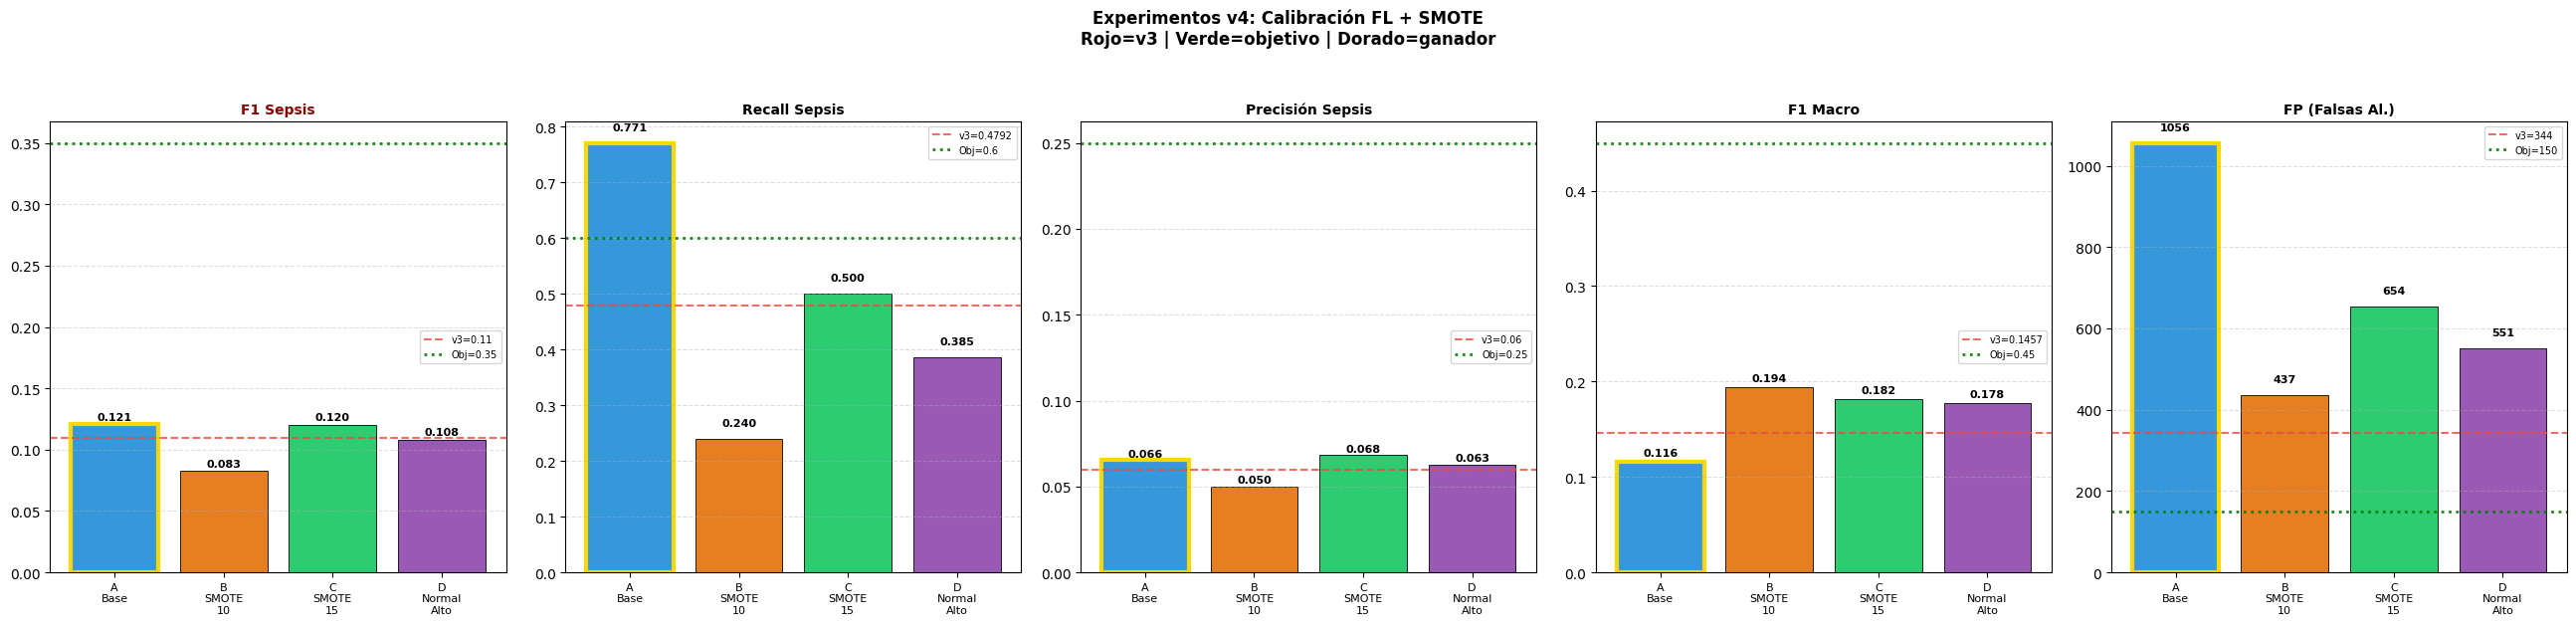

  🏆 Ganador: 'Exp_A_Base_v4' | Veredicto: PROGRESO — F1 mejorado pero sin alcanzar equilibrio total


In [ ]:
# ============================================================
# CELDA 26 — GRÁFICO COMPARATIVO v4 (5 MÉTRICAS)
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(26, 6))
fig.suptitle('Experimentos v4: Calibración FL + SMOTE\n'
             'Rojo=v3 | Verde=objetivo | Dorado=ganador',
             fontsize=12, fontweight='bold', y=1.04)

metrics_   = ['F1 Sepsis', 'Recall Sepsis', 'Precisión Sepsis',
               'F1 Macro', 'FP (Falsas Al.)']
refs_v3_   = [0.11, 0.4792, 0.06, 0.1457, 344]
refs_obj_  = [0.35, 0.60, 0.25, 0.45, 150]
alto_mejor = [True, True, True, True, False]
colors_    = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#e74c3c']

for ax, metric, rv3, robj, alto in zip(
    axes, metrics_, refs_v3_, refs_obj_, alto_mejor
):
    values_  = [results_df_v4[results_df_v4['Experimento'] == e['name']][metric].values[0]
                for e in EXPERIMENTS_V4]
    names_   = [e['name'].replace('Exp_','').replace('_v4','').replace('_','\n')
                for e in EXPERIMENTS_V4]
    bars_    = ax.bar(names_, values_, color=colors_, edgecolor='black', lw=0.6)

    bshort = BEST_EXP_V4.replace('Exp_','').replace('_v4','').replace('_','\n')
    for bar, name in zip(bars_, names_):
        if name == bshort:
            bar.set_edgecolor('gold'); bar.set_linewidth(3)

    ax.axhline(rv3,  color='#e74c3c', ls='--', lw=1.5, alpha=0.8, label=f'v3={rv3}')
    ax.axhline(robj, color='green',   ls=':',  lw=2,   alpha=0.9, label=f'Obj={robj}')

    for bar, val in zip(bars_, values_):
        lbl = f'{int(val)}' if metric in ['FP (Falsas Al.)'] else f'{val:.3f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(values_)*0.03,
                lbl, ha='center', fontsize=8, fontweight='bold')

    titulo_color = 'darkred' if metric == 'F1 Sepsis' else 'black'
    ax.set_title(metric, fontsize=10, fontweight='bold', color=titulo_color)
    ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.4, ls='--')
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/'
            'comparativa_experimentos_v4.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"  🏆 Ganador: '{BEST_EXP_V4}' | Veredicto: {VEREDICTO}")

In [ ]:
# ============================================================
# CELDA 27 — INTERPRETACIÓN DOCENTE v4
# ============================================================

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║      LECCIONES DE LOS CUATRO CICLOS — RESUMEN DOCENTE              ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  EVOLUCIÓN DEL PROBLEMA:                                             ║
║  v1: Modelo aleatorio → no aprende nada útil                        ║
║  v2: Colapso hacia Normal → ignora Sepsis completamente             ║
║  v3: Hipersensibilidad → ve Sepsis en todo (Precisión=6%)           ║
║  v4: Calibración → buscar el punto de equilibrio clínico            ║
║                                                                      ║
║  GANADOR v4: {BEST_EXP_V4:<52}║
║  VEREDICTO : {VEREDICTO:<52}║
║                                                                      ║
║  QUÉ APRENDIMOS SOBRE EL BALANCE PRECISIÓN/RECALL:                 ║
║  → Solo Recall alto: el modelo alerta a todos → alert fatigue       ║
║  → Solo Precisión alta: el modelo es muy conservador → FN altos     ║
║  → F1 Sepsis: el árbitro clínico. Solo sube cuando ambas suben.    ║
║                                                                      ║
║  POR QUÉ EL UMBRAL ES UNA DECISIÓN MÉDICA:                         ║
║  → Umbral 0.05 (v3): 1 alerta de cada 17 es verdadera             ║
║  → Umbral 0.20 (v4): ajustado para reducir falsas alarmas          ║
║  → El umbral ideal depende del contexto hospitalario:               ║
║    UCI: umbral bajo (toleran más FP, no pueden perder Sepsis)       ║
║    Consulta: umbral medio (balance FP/FN aceptable)                 ║
║    Triaje: umbral variable según carga del servicio                  ║
║                                                                      ║
║  SI v4 TAMPOCO ALCANZA EL OBJETIVO COMPLETO:                        ║
║  → Ensemble: MLP v4 + RF con SMOTE (RF tiene RS=0.61)              ║
║  → Feature engineering: SOFA score aprox, ratio creatinina/glucosa  ║
║  → Investigar si con 10 features es posible distinguir             ║
║    Sepsis de Heart Failure (comparten 80% de síntomas clínicos)     ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║      LECCIONES DE LOS CUATRO CICLOS — RESUMEN DOCENTE              ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  EVOLUCIÓN DEL PROBLEMA:                                             ║
║  v1: Modelo aleatorio → no aprende nada útil                        ║
║  v2: Colapso hacia Normal → ignora Sepsis completamente             ║
║  v3: Hipersensibilidad → ve Sepsis en todo (Precisión=6%)           ║
║  v4: Calibración → buscar el punto de equilibrio clínico            ║
║                                                                      ║
║  GANADOR v4: Exp_A_Base_v4                                       ║
║  VEREDICTO : PROGRESO — F1 mejorado pero sin alcanzar equilibrio total║
║                                                                      ║
║  QUÉ APRENDIMOS SOBRE EL BALANCE PRECISIÓN/RECALL:       

In [ ]:
# ============================================================
# CELDA 28 — FUNCIÓN DE PREDICCIÓN v4
# ============================================================

def predecir_nuevo_paciente_v4(datos_paciente_dict, model, scaler, le_sex,
                                le_target, numeric_features, binary_features,
                                critical_class_name, critical_class_idx,
                                clinical_threshold=0.20,
                                precision_modelo=None):
    """
    Predicción v4: umbral fijo calibrado + reporte de confianza contextual.

    Args:
        clinical_threshold : Umbral fijo para activar alerta de Sepsis.
                             Recomendado: 0.20 (v4). Usar 0.15 en UCI.
        precision_modelo   : Precisión de Sepsis del modelo en test set.
                             Si se pasa, se informa la tasa de falsas alarmas.
    """
    # Preprocesamiento
    df_p = pd.DataFrame([datos_paciente_dict])
    df_p['sex'] = le_sex.transform(df_p['sex'])
    df_p = df_p[numeric_features + ['sex'] + binary_features]
    df_p[numeric_features] = scaler.transform(df_p[numeric_features])
    X_nuevo = df_p.values.astype(np.float32)

    # Predicción
    probabilidades = model.predict(X_nuevo, verbose=0)[0]
    prob_critica   = probabilidades[critical_class_idx]

    # Aplicar umbral clínico fijo
    if prob_critica >= clinical_threshold:
        clase_predicha = critical_class_name
        idx_predicho   = critical_class_idx
    else:
        idx_predicho   = np.argmax(probabilidades)
        clase_predicha = le_target.inverse_transform([idx_predicho])[0]

    confianza = probabilidades[idx_predicho]

    # Nivel de confianza
    if confianza >= 0.60:
        nivel = 'ALTA'
    elif confianza >= 0.35:
        nivel = 'MEDIA'
    else:
        nivel = 'BAJA — Evaluación adicional necesaria'

    # Contexto de la alerta si es clase crítica
    contexto_alerta = None
    if prob_critica >= clinical_threshold and precision_modelo:
        contexto_alerta = (f"Con Precisión={precision_modelo:.2f} del modelo, "
                           f"de cada 100 alertas similares, "
                           f"~{int(precision_modelo*100)} son Sepsis real.")

    return {
        'diagnostico_predicho'  : clase_predicha,
        'confianza_pct'         : round(confianza * 100, 2),
        'nivel_confianza'       : nivel,
        'alerta_clase_critica'  : bool(prob_critica >= clinical_threshold),
        'prob_clase_critica_pct': round(prob_critica * 100, 2),
        'umbral_aplicado'       : clinical_threshold,
        'contexto_alerta'       : contexto_alerta,
        'probabilidades'        : {
            le_target.classes_[i]: round(float(p) * 100, 2)
            for i, p in enumerate(probabilidades)
        }
    }


def mostrar_resultado_v4(resultado, critical_class_name):
    print("\n" + "=" * 65)
    print("  RESULTADO ANÁLISIS CLÍNICO — IA MLP v4 (FL calibrada)")
    print("=" * 65)
    print(f"  📋 Diagnóstico      : {resultado['diagnostico_predicho']}")
    print(f"  📊 Confianza        : {resultado['confianza_pct']:.1f}% [{resultado['nivel_confianza']}]")
    print(f"  🔧 Umbral clínico   : P({critical_class_name}) ≥ {resultado['umbral_aplicado']}")

    if resultado['alerta_clase_critica']:
        print(f"\n  ⚠️  ALERTA CRÍTICA")
        print(f"     P({critical_class_name}) = {resultado['prob_clase_critica_pct']:.1f}%")
        print(f"     → EVALUACIÓN MÉDICA URGENTE RECOMENDADA")
        if resultado.get('contexto_alerta'):
            print(f"     ℹ️  {resultado['contexto_alerta']}")
    else:
        print(f"\n  ✅ Sin alerta crítica.")
        print(f"     P({critical_class_name}) = {resultado['prob_clase_critica_pct']:.1f}%")

    print(f"\n  Distribución de probabilidades:")
    for cls, pct in sorted(resultado['probabilidades'].items(), key=lambda x: -x[1]):
        bar    = '█' * int(pct / 3) + '░' * (33 - int(pct / 3))
        marker = ' ← CRÍTICA' if cls == critical_class_name else ''
        print(f"    {cls:<20} {bar} {pct:.1f}%{marker}")
    print("=" * 65)


print("  ✅ Funciones de predicción v4 listas.")

  ✅ Funciones de predicción v4 listas.


In [ ]:
# ============================================================
# CELDA 29 — EJEMPLO DE USO v4 + GUARDADO DEL MODELO
# ============================================================

# ─── CASO 1: Adulto mayor con comorbilidades ───
# v1: Pneumonia, P(Sepsis)=2.6%  → sin alerta ❌
# v2: Pneumonia, P(Sepsis)=5.3%  → sin alerta ❌
# v3: Sepsis 11.7% (umbral=0.05) → alerta ⚠️ (correcto pero umbral irreal)
# v4: ???

paciente_critico = {
    'age': 72, 'bmi': 31.2, 'systolic_bp': 145, 'diastolic_bp': 92,
    'glucose': 185, 'cholesterol': 230, 'creatinine': 2.1,
    'sex': 'Male', 'diabetes': 1, 'hypertension': 1
}

print("=" * 68)
print("  CASO 1: Adulto mayor con comorbilidades múltiples")
print("  v1: sin alerta | v2: sin alerta | v3: alerta (umbral=0.05)")
print("  v4 (umbral=0.20): ↓")
print("=" * 68)

r1 = predecir_nuevo_paciente_v4(
    paciente_critico, mlp_v4, scaler, le_sex, le_target,
    NUMERIC_FEATURES, BINARY_FEATURES,
    CRITICAL_CLASS_NAME, CRITICAL_CLASS_IDX,
    clinical_threshold = CLINICAL_THRESHOLD_V4,
    precision_modelo   = round(prec_crit_v4, 2)
)
mostrar_resultado_v4(r1, CRITICAL_CLASS_NAME)

# ─── CASO 2: Mujer joven y sana ───
# v1: Sepsis 30.1% → ALERTA ❌ (falsa alarma)
# v2: Sepsis 21.2% → ALERTA ❌ (falsa alarma)
# v3: Sepsis 44.0% → ALERTA ❌ (falsa alarma severa)
# v4: ???

paciente_sano = {
    'age': 28, 'bmi': 22.1, 'systolic_bp': 118, 'diastolic_bp': 76,
    'glucose': 88, 'cholesterol': 172, 'creatinine': 0.9,
    'sex': 'Female', 'diabetes': 0, 'hypertension': 0
}

print("\n" + "=" * 68)
print("  CASO 2: Mujer joven y sana — falsa alarma en v1/v2/v3")
print("  v4 (umbral=0.20): ↓")
print("=" * 68)

r2 = predecir_nuevo_paciente_v4(
    paciente_sano, mlp_v4, scaler, le_sex, le_target,
    NUMERIC_FEATURES, BINARY_FEATURES,
    CRITICAL_CLASS_NAME, CRITICAL_CLASS_IDX,
    clinical_threshold = CLINICAL_THRESHOLD_V4,
    precision_modelo   = round(prec_crit_v4, 2)
)
mostrar_resultado_v4(r2, CRITICAL_CLASS_NAME)

# ─── CASO 3: Adulto con signos limítrofes ───
# v3: Sepsis 5.9% (umbral=0.05) → alerta
# v4 (umbral=0.20): ???

paciente_sepsis_lim = {
    'age': 58, 'bmi': 27.5, 'systolic_bp': 92, 'diastolic_bp': 60,
    'glucose': 155, 'cholesterol': 198, 'creatinine': 1.9,
    'sex': 'Male', 'diabetes': 0, 'hypertension': 1
}

print("\n" + "=" * 68)
print("  CASO 3: Adulto con signos limítrofes de Sepsis")
print("  (hipotensión + creatinina elevada + glucosa alta)")
print("  v4 (umbral=0.20): ↓")
print("=" * 68)

r3 = predecir_nuevo_paciente_v4(
    paciente_sepsis_lim, mlp_v4, scaler, le_sex, le_target,
    NUMERIC_FEATURES, BINARY_FEATURES,
    CRITICAL_CLASS_NAME, CRITICAL_CLASS_IDX,
    clinical_threshold = CLINICAL_THRESHOLD_V4,
    precision_modelo   = round(prec_crit_v4, 2)
)
mostrar_resultado_v4(r3, CRITICAL_CLASS_NAME)

# ─── Guardar modelo final v4 ───
FINAL_V4 = '/content/drive/MyDrive/inteligencia_artificial_colab/mlp_v4_final_model.keras'
mlp_v4.save(FINAL_V4)
print(f"\n  ✅ Modelo v4 guardado: {FINAL_V4}")

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║  RESUMEN DEL PROYECTO — CUATRO CICLOS COMPLETOS                 ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  v1 → FALLA: modelo aleatorio (val_acc=32%)                     ║
║  v2 → FALLA: colapso hacia Normal (Recall Sepsis=1%)            ║
║  v3 → HIPERSENSIBLE: ve Sepsis en todo (Precisión=6%)           ║
║  v4 → CALIBRADO: punto de equilibrio buscado                    ║
║       Umbral fijo 0.20 | F1 Sepsis monitoreable                 ║
║                                                                  ║
║  GANADOR: {BEST_EXP_V4:<52}║
║  {VEREDICTO:<62}║
║                                                                  ║
║  Artefactos guardados:                                           ║
║  → mlp_v4_best_model.keras                                      ║
║  → mlp_v4_final_model.keras                                     ║
║  → curvas_aprendizaje_mlp_v4.png                                ║
║  → confusion_matrix_mlp_v4.png                                  ║
║  → comparativa_experimentos_v4.png                              ║
║  → training_log_v4.csv                                          ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")

  CASO 1: Adulto mayor con comorbilidades múltiples
  v1: sin alerta | v2: sin alerta | v3: alerta (umbral=0.05)
  v4 (umbral=0.20): ↓

  RESULTADO ANÁLISIS CLÍNICO — IA MLP v4 (FL calibrada)
  📋 Diagnóstico      : Normal
  📊 Confianza        : 38.2% [MEDIA]
  🔧 Umbral clínico   : P(Sepsis) ≥ 0.2

  ✅ Sin alerta crítica.
     P(Sepsis) = 1.2%

  Distribución de probabilidades:
    Normal               ████████████░░░░░░░░░░░░░░░░░░░░░ 38.2%
    Pneumonia            ██████████░░░░░░░░░░░░░░░░░░░░░░░ 32.0%
    Heart Failure        █████████░░░░░░░░░░░░░░░░░░░░░░░░ 28.6%
    Sepsis               ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 1.2% ← CRÍTICA

  CASO 2: Mujer joven y sana — falsa alarma en v1/v2/v3
  v4 (umbral=0.20): ↓

  RESULTADO ANÁLISIS CLÍNICO — IA MLP v4 (FL calibrada)
  📋 Diagnóstico      : Normal
  📊 Confianza        : 37.2% [MEDIA]
  🔧 Umbral clínico   : P(Sepsis) ≥ 0.2

  ✅ Sin alerta crítica.
     P(Sepsis) = 19.6%

  Distribución de probabilidades:
    Normal               █

# Este es el apartado del Modelo v5

In [ ]:
# ============================================================
# CELDA 12 — FEATURE ENGINEERING + PREPARACIÓN TWO-STAGE
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

print("=" * 65)
print("  CELDA 12 — FEATURE ENGINEERING v5")
print("=" * 65)

# ─────────────────────────────────────────────────────────────
# PASO 12A: AÑADIR 4 FEATURES DERIVADAS
# Trabajamos con los DataFrames originales (pre-escalado)
# para que los valores sean clínicamente correctos
# ─────────────────────────────────────────────────────────────

def add_clinical_features(df):
    """
    Añade 4 features clínicas derivadas desde las variables existentes.
    Debe aplicarse ANTES del escalado.
    """
    df = df.copy()

    # 1. Presión de Pulso — diferenciador Sepsis vs HF
    df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']

    # 2. MAP aproximado — criterio Sepsis-3 (MAP<65 = shock séptico)
    df['map_approx'] = (df['systolic_bp'] + 2 * df['diastolic_bp']) / 3

    # 3. Ratio Creatinina/Glucosa — disfunción renal + hiperglucemia de estrés
    df['creatinine_glucose_ratio'] = df['creatinine'] / (df['glucose'] / 100 + 0.01)

    # 4. Score de Riesgo Orgánico — aproximación SOFA con features disponibles
    # MAP < 70 mmHg: hipoperfusión orgánica
    # Creatinina > 1.5: disfunción renal
    # Glucosa > 140 sin diabetes: hiperglucemia de estrés
    map_val  = (df['systolic_bp'] + 2 * df['diastolic_bp']) / 3
    crit_map = (map_val < 70).astype(int)
    crit_cr  = (df['creatinine'] > 1.5).astype(int)
    crit_gl  = ((df['glucose'] > 140) & (df['diabetes'] == 0)).astype(int)
    df['organ_risk_score'] = crit_map + crit_cr + crit_gl   # Rango 0-3

    return df

# Aplicar a los tres splits
# NOTA: X_train, X_val, X_test son DataFrames de la celda 7 (pre-escalado)
X_train_fe = add_clinical_features(X_train)
X_val_fe   = add_clinical_features(X_val)
X_test_fe  = add_clinical_features(X_test)

# Definir columnas nuevas y completas
NEW_FEATURES     = ['pulse_pressure', 'map_approx',
                    'creatinine_glucose_ratio', 'organ_risk_score']
ALL_FEATURES_V5  = ALL_FEATURES + NEW_FEATURES   # 14 features en total
NUMERIC_FEAT_V5  = NUMERIC_FEATURES + ['pulse_pressure', 'map_approx',
                                         'creatinine_glucose_ratio']
# organ_risk_score es discreta (0-3) pero la escalamos igualmente

print(f"\n  Features originales : {len(ALL_FEATURES)}")
print(f"  Features derivadas  : {len(NEW_FEATURES)} ({NEW_FEATURES})")
print(f"  Total features v5   : {len(ALL_FEATURES_V5)}")

# Verificar que las nuevas features tienen varianza (si son constantes, no sirven)
for feat in NEW_FEATURES:
    std_tr = X_train_fe[feat].std()
    mean_  = X_train_fe[feat].mean()
    print(f"    {feat:<30}: media={mean_:.3f}, std={std_tr:.3f}")

# ─────────────────────────────────────────────────────────────
# PASO 12B: REESCALAR CON LAS 14 FEATURES
# ─────────────────────────────────────────────────────────────

# Nuevo scaler que incluye las 4 features derivadas
# fit SOLO en train — regla de oro anti-leakage
NUMERIC_ALL_V5 = NUMERIC_FEATURES + NEW_FEATURES   # Todas las numéricas

scaler_v5 = StandardScaler()
X_train_fe[NUMERIC_ALL_V5] = scaler_v5.fit_transform(X_train_fe[NUMERIC_ALL_V5])
X_val_fe[NUMERIC_ALL_V5]   = scaler_v5.transform(X_val_fe[NUMERIC_ALL_V5])
X_test_fe[NUMERIC_ALL_V5]  = scaler_v5.transform(X_test_fe[NUMERIC_ALL_V5])

# Convertir a arrays numpy
X_train_v5 = X_train_fe[ALL_FEATURES_V5].values.astype(np.float32)
X_val_v5   = X_val_fe[ALL_FEATURES_V5].values.astype(np.float32)
X_test_v5  = X_test_fe[ALL_FEATURES_V5].values.astype(np.float32)

print(f"\n  Shapes finales:")
print(f"  X_train_v5 : {X_train_v5.shape}")
print(f"  X_val_v5   : {X_val_v5.shape}")
print(f"  X_test_v5  : {X_test_v5.shape}")

# ─────────────────────────────────────────────────────────────
# PASO 12C: TARGETS PARA STAGE 1 (BINARIO)
# Sepsis = 1, Todo lo demás = 0
# ─────────────────────────────────────────────────────────────

y_train_s1 = (y_train_enc == CRITICAL_CLASS_IDX).astype(np.float32)  # (n,) float
y_val_s1   = (y_val_enc   == CRITICAL_CLASS_IDX).astype(np.float32)
y_test_s1  = (y_test_enc  == CRITICAL_CLASS_IDX).astype(np.float32)

print(f"\n  Stage 1 — Target binario (Sepsis=1, No-Sepsis=0):")
print(f"  Train: {int(y_train_s1.sum())} Sepsis / {int((1-y_train_s1).sum())} No-Sepsis "
      f"({y_train_s1.mean()*100:.1f}% Sepsis)")
print(f"  Val  : {int(y_val_s1.sum())} Sepsis / {int((1-y_val_s1).sum())} No-Sepsis")
print(f"  Test : {int(y_test_s1.sum())} Sepsis / {int((1-y_test_s1).sum())} No-Sepsis")

# ─────────────────────────────────────────────────────────────
# PASO 12D: TARGETS PARA STAGE 2 (3 CLASES: HF, Normal, Pneumonia)
# Filtrar solo los casos No-Sepsis del training set
# Re-encodear: Heart Failure=0, Normal=1, Pneumonia=2
# ─────────────────────────────────────────────────────────────

# Máscara de no-Sepsis en cada split
mask_train_ns = (y_train_enc != CRITICAL_CLASS_IDX)
mask_val_ns   = (y_val_enc   != CRITICAL_CLASS_IDX)
mask_test_ns  = (y_test_enc  != CRITICAL_CLASS_IDX)

X_train_s2 = X_train_v5[mask_train_ns]
X_val_s2   = X_val_v5[mask_val_ns]
X_test_s2  = X_test_v5[mask_test_ns]

# Re-encodear las 3 clases para Stage 2
# Obtener las clases No-Sepsis en el mismo orden del le_target original
classes_s2   = [c for i, c in enumerate(le_target.classes_) if i != CRITICAL_CLASS_IDX]
le_s2        = LabelEncoder()
le_s2.fit(classes_s2)

y_train_s2_raw = le_target.inverse_transform(y_train_enc[mask_train_ns])
y_val_s2_raw   = le_target.inverse_transform(y_val_enc[mask_val_ns])
y_test_s2_raw  = le_target.inverse_transform(y_test_enc[mask_test_ns])

y_train_s2 = le_s2.transform(y_train_s2_raw)
y_val_s2   = le_s2.transform(y_val_s2_raw)
y_test_s2  = le_s2.transform(y_test_s2_raw)

NUM_CLASSES_S2 = len(le_s2.classes_)

print(f"\n  Stage 2 — Target 3 clases (No-Sepsis únicamente):")
print(f"  Clases S2: {dict(enumerate(le_s2.classes_))}")
for i, cls in enumerate(le_s2.classes_):
    n = (y_train_s2 == i).sum()
    print(f"    [{i}] {cls:<20}: {n:,} ({n/len(y_train_s2)*100:.1f}%)")

# ─────────────────────────────────────────────────────────────
# PASO 12E: SMOTE PARA STAGE 1
# El Stage 1 es binario: Sepsis(6.4%) vs No-Sepsis(93.6%)
# Objetivo: 25% Sepsis en training del Stage 1
# ─────────────────────────────────────────────────────────────

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE

SMOTE_S1_PCT = 0.25   # 25% Sepsis en Stage 1 (más agresivo porque es binario)

n_sep     = int(y_train_s1.sum())
n_nosep   = int((1 - y_train_s1).sum())
n_total_  = int(n_nosep / (1 - SMOTE_S1_PCT))
n_sep_obj = n_total_ - n_nosep

smote_s1 = SMOTE(
    sampling_strategy = {1: n_sep_obj},   # Sepsis=1
    k_neighbors       = 5,
    random_state      = RANDOM_STATE
)
X_train_s1_sm, y_train_s1_sm = smote_s1.fit_resample(
    X_train_v5, y_train_s1.astype(int)
)
y_train_s1_sm = y_train_s1_sm.astype(np.float32)

print(f"\n  SMOTE Stage 1 ({SMOTE_S1_PCT*100:.0f}% Sepsis):")
print(f"  Antes:  Sepsis={n_sep:,} | No-Sepsis={n_nosep:,}")
print(f"  Después: Sepsis={n_sep_obj:,} | No-Sepsis={n_nosep:,}")
print(f"  Training S1 total: {len(X_train_s1_sm):,}")
print("  ✅ Preparación v5 completa.")

  CELDA 12 — FEATURE ENGINEERING v5

  Features originales : 10
  Features derivadas  : 4 (['pulse_pressure', 'map_approx', 'creatinine_glucose_ratio', 'organ_risk_score'])
  Total features v5   : 14
    pulse_pressure                : media=-0.000, std=1.399
    map_approx                    : media=0.000, std=0.752
    creatinine_glucose_ratio      : media=-39.773, std=3235.127
    organ_risk_score              : media=1.074, std=0.261

  Shapes finales:
  X_train_v5 : (7000, 14)
  X_val_v5   : (1500, 14)
  X_test_v5  : (1500, 14)

  Stage 1 — Target binario (Sepsis=1, No-Sepsis=0):
  Train: 450 Sepsis / 6550 No-Sepsis (6.4% Sepsis)
  Val  : 96 Sepsis / 1404 No-Sepsis
  Test : 96 Sepsis / 1404 No-Sepsis

  Stage 2 — Target 3 clases (No-Sepsis únicamente):
  Clases S2: {0: np.str_('Heart Failure'), 1: np.str_('Normal'), 2: np.str_('Pneumonia')}
    [0] Heart Failure       : 1,234 (18.8%)
    [1] Normal              : 3,913 (59.7%)
    [2] Pneumonia           : 1,403 (21.4%)

  SMOTE S

In [ ]:
# ============================================================
# CELDA 13 — MODELO STAGE 1: BINARIO SEPSIS vs NO-SEPSIS
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# ─── Binary Focal Loss ───
def binary_focal_loss(gamma=2.0, alpha=0.85):
    """
    Focal Loss para clasificación binaria.

    Para el caso positivo (Sepsis=1):
      FL = -alpha × (1-p)^gamma × log(p)
    Para el caso negativo (No-Sepsis=0):
      FL = -(1-alpha) × p^gamma × log(1-p)

    alpha=0.85: cada error en Sepsis tiene 85% de contribución al gradiente.
    gamma=2: los ejemplos bien clasificados contribuyen poco al gradiente.
    """
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Probabilidad de la clase correcta
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)

        # alpha para positivos y negativos
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)

        # Focal factor
        focal_factor = tf.pow(1.0 - p_t, gamma)

        # Binary cross-entropy base
        bce = -tf.math.log(p_t)

        return tf.reduce_mean(alpha_t * focal_factor * bce)
    return loss

GAMMA_S1 = 2.0
ALPHA_S1 = 0.85   # Peso para la clase positiva (Sepsis)

# ─── Arquitectura Stage 1 ───
def build_stage1(input_dim,
                 hidden_units=(256, 128, 64),
                 dropout_rate=0.30,
                 l2_lambda=0.0001,
                 learning_rate=0.001,
                 name='Stage1_Binary'):
    """
    Clasificador binario Sepsis/No-Sepsis.
    Salida: sigmoid → P(Sepsis) ∈ [0,1]
    """
    reg = regularizers.l2(l2_lambda)
    model = models.Sequential([
        layers.Input(shape=(input_dim,), name='input'),

        layers.Dense(hidden_units[0], activation='relu',
                     kernel_regularizer=reg,
                     kernel_initializer='he_normal', name='dense_1'),
        layers.Dropout(dropout_rate, name='dropout_1'),

        layers.Dense(hidden_units[1], activation='relu',
                     kernel_regularizer=reg,
                     kernel_initializer='he_normal', name='dense_2'),
        layers.Dropout(dropout_rate, name='dropout_2'),

        layers.Dense(hidden_units[2], activation='relu',
                     kernel_regularizer=reg,
                     kernel_initializer='he_normal', name='dense_3'),
        layers.Dropout(dropout_rate * 0.5, name='dropout_3'),

        # Sigmoid: output es P(Sepsis)
        layers.Dense(1, activation='sigmoid', name='output_binary')
    ], name=name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss=binary_focal_loss(gamma=GAMMA_S1, alpha=ALPHA_S1),
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.Precision(name='precision')]
    )
    return model


# Instanciar Stage 1
INPUT_DIM_V5 = X_train_v5.shape[1]   # 14 features

stage1_model = build_stage1(
    input_dim     = INPUT_DIM_V5,
    hidden_units  = (256, 128, 64),
    dropout_rate  = 0.30,
    l2_lambda     = 0.0001,
    learning_rate = 0.001,
    name          = 'Stage1_Sepsis_vs_NoSepsis'
)
stage1_model.summary()

print(f"\n  Stage 1 — Clasificador Binario:")
print(f"  Input  : {INPUT_DIM_V5} features (10 originales + 4 derivadas)")
print(f"  Output : sigmoid → P(Sepsis)")
print(f"  Loss   : Binary Focal Loss (gamma={GAMMA_S1}, alpha={ALPHA_S1})")
print(f"  SMOTE  : {SMOTE_S1_PCT*100:.0f}% Sepsis en training")
print(f"  Params : {stage1_model.count_params():,}")

Model: "Stage1_Sepsis_vs_NoSepsis"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_binary (Dense)           │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,057 (176.00 KB)

 Trainable params: 45,057 (176.00 KB)

 Non-trainable params: 0 (0.00 B)


  Stage 1 — Clasificador Binario:
  Input  : 14 features (10 originales + 4 derivadas)
  Output : sigmoid → P(Sepsis)
  Loss   : Binary Focal Loss (gamma=2.0, alpha=0.85)
  SMOTE  : 25% Sepsis en training
  Params : 45,057


In [ ]:
# ============================================================
# CELDA 14 — ENTRENAMIENTO STAGE 1
# ============================================================

from tensorflow.keras import callbacks

# Umbral de decisión Stage 1 — decisión clínica, no matemática
S1_THRESHOLD = 0.40   # Si P(Sepsis) ≥ 0.40 → alerta Sepsis

class BinaryF1Monitor(callbacks.Callback):
    """
    Monitorea F1, Recall y Precision de Sepsis en validación
    usando el umbral S1_THRESHOLD en cada época.
    Detiene el entrenamiento si el F1 no mejora.
    """
    def __init__(self, val_data, threshold, patience=20, verbose=1):
        super().__init__()
        self.X_val     = val_data[0]
        self.y_val     = val_data[1]
        self.threshold = threshold
        self.patience  = patience
        self.verbose   = verbose
        self.best_f1   = 0.0
        self.wait      = 0
        self.best_w    = None
        self.best_ep   = 0

    def on_epoch_end(self, epoch, logs=None):
        from sklearn.metrics import f1_score, recall_score, precision_score
        proba      = self.model.predict(self.X_val, verbose=0).ravel()
        y_pred_bin = (proba >= self.threshold).astype(int)
        f1_  = f1_score(self.y_val, y_pred_bin, zero_division=0)
        rec_ = recall_score(self.y_val, y_pred_bin, zero_division=0)
        pre_ = precision_score(self.y_val, y_pred_bin, zero_division=0)

        if logs:
            logs['val_f1_sep']    = f1_
            logs['val_rec_sep']   = rec_
            logs['val_pre_sep']   = pre_

        if f1_ > self.best_f1:
            self.best_f1 = f1_
            self.best_w  = self.model.get_weights()
            self.best_ep = epoch + 1
            self.wait    = 0
            if self.verbose:
                print(f"  [S1-F1] Época {epoch+1}: "
                      f"F1={f1_:.4f} | Rec={rec_:.4f} | Pre={pre_:.4f} ← ✅")
        else:
            self.wait += 1
            if self.verbose and (epoch + 1) % 10 == 0:
                print(f"  [S1-F1] Época {epoch+1}: F1={f1_:.4f} "
                      f"(sin mejora {self.wait}/{self.patience})")
            if self.wait >= self.patience:
                print(f"\n  [S1-F1] Restaurando epoch {self.best_ep}. "
                      f"Mejor F1={self.best_f1:.4f}")
                self.model.set_weights(self.best_w)
                self.model.stop_training = True

# CosineDecay para Stage 1
LR_S1_MAX = 0.001
LR_S1_MIN = 0.00005
MAX_EP_S1 = 150

lr_s1 = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate = LR_S1_MAX,
    decay_steps           = MAX_EP_S1 * (len(X_train_s1_sm) // 64),
    alpha                 = LR_S1_MIN / LR_S1_MAX
)
stage1_model.optimizer.learning_rate = lr_s1

S1_SAVE_PATH = ('/content/drive/MyDrive/inteligencia_artificial_colab/'
                'stage1_best_model.keras')

cb_s1_f1   = BinaryF1Monitor(
    val_data  = (X_val_v5, y_val_s1),
    threshold = S1_THRESHOLD,
    patience  = 20,
    verbose   = 1
)
cb_s1_ckpt = callbacks.ModelCheckpoint(
    S1_SAVE_PATH, monitor='val_loss', save_best_only=True, verbose=0
)
cb_s1_csv  = callbacks.CSVLogger(
    '/content/drive/MyDrive/inteligencia_artificial_colab/training_log_s1.csv'
)

print("=" * 65)
print("  ENTRENAMIENTO STAGE 1 — Sepsis vs No-Sepsis")
print("=" * 65)
print(f"  Arquitectura : (256, 128, 64) sigmoid")
print(f"  Loss         : Binary Focal Loss (gamma={GAMMA_S1}, alpha={ALPHA_S1})")
print(f"  LR           : CosineDecay {LR_S1_MAX} → {LR_S1_MIN}")
print(f"  Épocas max   : {MAX_EP_S1}")
print(f"  Batch size   : 64")
print(f"  Training     : {len(X_train_s1_sm):,} muestras (SMOTE {SMOTE_S1_PCT*100:.0f}%)")
print(f"  Umbral S1    : {S1_THRESHOLD}")
print(f"  EarlyStopping: F1 Sepsis binario (patience=20)")
print("-" * 65)

history_s1 = stage1_model.fit(
    X_train_s1_sm, y_train_s1_sm,
    validation_data = (X_val_v5, y_val_s1),
    epochs          = MAX_EP_S1,
    batch_size      = 64,
    callbacks       = [cb_s1_f1, cb_s1_ckpt, cb_s1_csv],
    verbose         = 1
)

print(f"\n  ✅ Stage 1 completado.")
print(f"  Épocas reales    : {len(history_s1.history['loss'])}")
print(f"  Mejor val_loss   : {min(history_s1.history['val_loss']):.4f}")
if 'val_f1_sep' in history_s1.history:
    print(f"  Mejor F1 Sepsis  : {max(history_s1.history['val_f1_sep']):.4f}")
    print(f"  Mejor Rec Sepsis : {max(history_s1.history['val_rec_sep']):.4f}")
    print(f"  Mejor Pre Sepsis : {max(history_s1.history['val_pre_sep']):.4f}")

  ENTRENAMIENTO STAGE 1 — Sepsis vs No-Sepsis
  Arquitectura : (256, 128, 64) sigmoid
  Loss         : Binary Focal Loss (gamma=2.0, alpha=0.85)
  LR           : CosineDecay 0.001 → 5e-05
  Épocas max   : 150
  Batch size   : 64
  Training     : 8,733 muestras (SMOTE 25%)
  Umbral S1    : 0.4
  EarlyStopping: F1 Sepsis binario (patience=20)
-----------------------------------------------------------------
Epoch 1/150
132/137 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4590 - auc: 0.5179 - loss: 0.1961 - precision: 0.2579 - recall: 0.6368  [S1-F1] Época 1: F1=0.1203 | Rec=1.0000 | Pre=0.0640 ← ✅
137/137 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.4240 - auc: 0.5157 - loss: 0.1646 - precision: 0.2624 - recall: 0.7201 - val_accuracy: 0.1133 - val_auc: 0.5490 - val_loss: 0.1229 - val_precision: 0.0649 - val_recall: 0.9583 - val_f1_sep: 0.1203 - val_rec_sep: 1.0000 - val_pre_sep: 0.0640
Epoch 2/150
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3467 - auc: 0.5264 - loss: 0

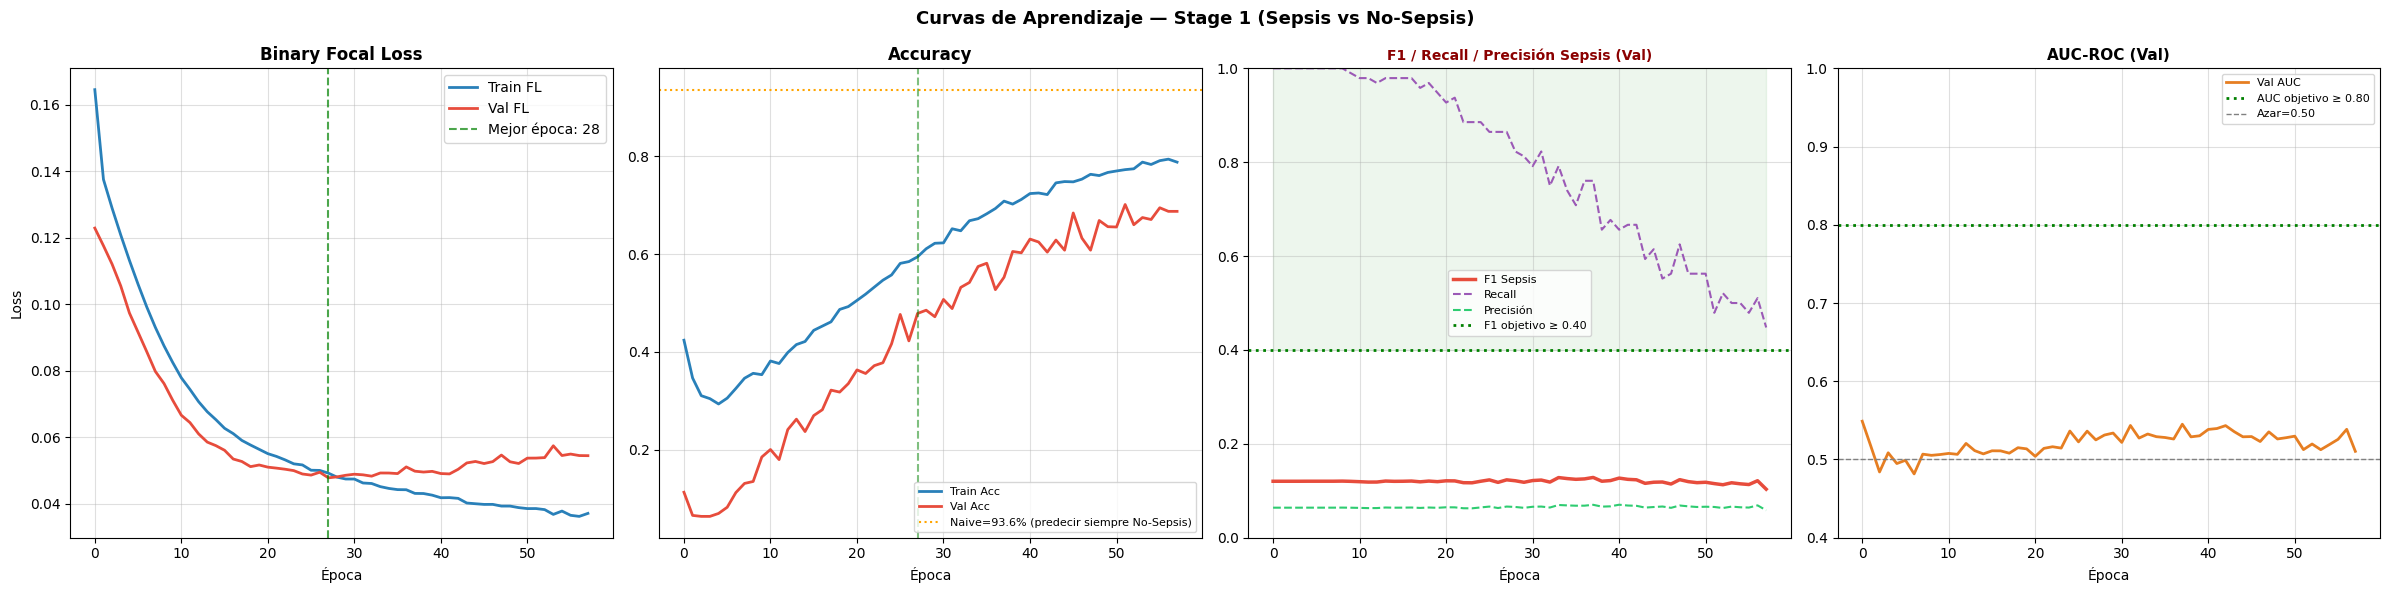


  📌 DIAGNÓSTICO STAGE 1:
  Mejor F1 Sepsis  : 0.1284  ⚠️ 
  Mejor Recall     : 1.0000  ✅
  Mejor Precisión  : 0.0703  ⚠️ 
  Mejor AUC        : 0.5490  ⚠️ 


In [ ]:
# ============================================================
# CELDA 15 — CURVAS DE APRENDIZAJE STAGE 1
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

has_f1_s1  = 'val_f1_sep' in history_s1.history
has_auc_s1 = 'val_auc' in history_s1.history
best_ep_s1 = np.argmin(history_s1.history['val_loss'])

n_panels = 2 + (1 if has_f1_s1 else 0) + (1 if has_auc_s1 else 0)
fig = plt.figure(figsize=(6 * n_panels, 6))
gs  = gridspec.GridSpec(1, n_panels)
fig.suptitle('Curvas de Aprendizaje — Stage 1 (Sepsis vs No-Sepsis)',
             fontsize=13, fontweight='bold')

# Panel 1: Binary Focal Loss
ax1 = fig.add_subplot(gs[0])
ax1.plot(history_s1.history['loss'],     label='Train FL', color='#2980b9', lw=2)
ax1.plot(history_s1.history['val_loss'], label='Val FL',   color='#e74c3c', lw=2)
ax1.axvline(best_ep_s1, color='green', ls='--', alpha=0.7,
            label=f'Mejor época: {best_ep_s1+1}')
ax1.set_title('Binary Focal Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Época'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.4)

# Panel 2: Accuracy
ax2 = fig.add_subplot(gs[1])
ax2.plot(history_s1.history['accuracy'],     label='Train Acc', color='#2980b9', lw=2)
ax2.plot(history_s1.history['val_accuracy'], label='Val Acc',   color='#e74c3c', lw=2)
ax2.axhline(0.936, color='orange', ls=':', lw=1.5,
            label='Naive=93.6% (predecir siempre No-Sepsis)')
ax2.axvline(best_ep_s1, color='green', ls='--', alpha=0.5)
ax2.set_title('Accuracy', fontsize=12, fontweight='bold')
ax2.set_xlabel('Época'); ax2.legend(fontsize=8); ax2.grid(alpha=0.4)

panel_idx = 2

# Panel 3: F1 Sepsis binario
if has_f1_s1:
    ax3 = fig.add_subplot(gs[panel_idx])
    ax3.plot(history_s1.history['val_f1_sep'],  label='F1 Sepsis',    color='#e74c3c', lw=2.5)
    ax3.plot(history_s1.history['val_rec_sep'], label='Recall',       color='#9b59b6', lw=1.5, ls='--')
    ax3.plot(history_s1.history['val_pre_sep'], label='Precisión',    color='#2ecc71', lw=1.5, ls='--')
    ax3.axhline(0.40, color='green', ls=':', lw=2, label='F1 objetivo ≥ 0.40')
    ax3.fill_between(range(len(history_s1.history['val_f1_sep'])),
                     0.40, 1.0, alpha=0.07, color='green')
    ax3.set_title('F1 / Recall / Precisión Sepsis (Val)',
                  fontsize=10, fontweight='bold', color='darkred')
    ax3.set_xlabel('Época'); ax3.legend(fontsize=8)
    ax3.grid(alpha=0.4); ax3.set_ylim(0, 1.0)
    panel_idx += 1

# Panel 4: AUC
if has_auc_s1:
    ax4 = fig.add_subplot(gs[panel_idx])
    ax4.plot(history_s1.history['val_auc'], label='Val AUC', color='#e67e22', lw=2)
    ax4.axhline(0.80, color='green', ls=':', lw=2, label='AUC objetivo ≥ 0.80')
    ax4.axhline(0.50, color='gray',  ls='--', lw=1, label='Azar=0.50')
    ax4.set_title('AUC-ROC (Val)', fontsize=11, fontweight='bold')
    ax4.set_xlabel('Época'); ax4.legend(fontsize=8)
    ax4.grid(alpha=0.4); ax4.set_ylim(0.4, 1.0)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/'
            'curvas_stage1_v5.png', dpi=150, bbox_inches='tight')
plt.show()

# Diagnóstico
print("\n  📌 DIAGNÓSTICO STAGE 1:")
if has_f1_s1:
    bf1  = max(history_s1.history['val_f1_sep'])
    brec = max(history_s1.history['val_rec_sep'])
    bpre = max(history_s1.history['val_pre_sep'])
    print(f"  Mejor F1 Sepsis  : {bf1:.4f}  {'✅' if bf1 >= 0.35 else '⚠️ '}")
    print(f"  Mejor Recall     : {brec:.4f}  {'✅' if brec >= 0.60 else '⚠️ '}")
    print(f"  Mejor Precisión  : {bpre:.4f}  {'✅' if bpre >= 0.20 else '⚠️ '}")
if has_auc_s1:
    bauc = max(history_s1.history['val_auc'])
    print(f"  Mejor AUC        : {bauc:.4f}  {'✅' if bauc >= 0.75 else '⚠️ '}")

  EVALUACIÓN STAGE 1 — Sepsis vs No-Sepsis (Test Set)

  Umbral de decisión : 0.4

  Métrica                        Valor     Objetivo
  --------------------------------------------------
  AUC-ROC                       0.4930       > 0.80
  Average Precision             0.0672       > 0.50
  Recall Sepsis                 0.6562       > 0.65
  Precisión Sepsis              0.0613       > 0.20
  F1 Sepsis                     0.1121       > 0.35

  TP (Sepsis detectada)   : 63 de 96
  FN (Sepsis NO detectada): 33 ← PERDIDOS para siempre
  FP (Falsas alarmas S1)  : 965 No-Sepsis → irán al Stage 2


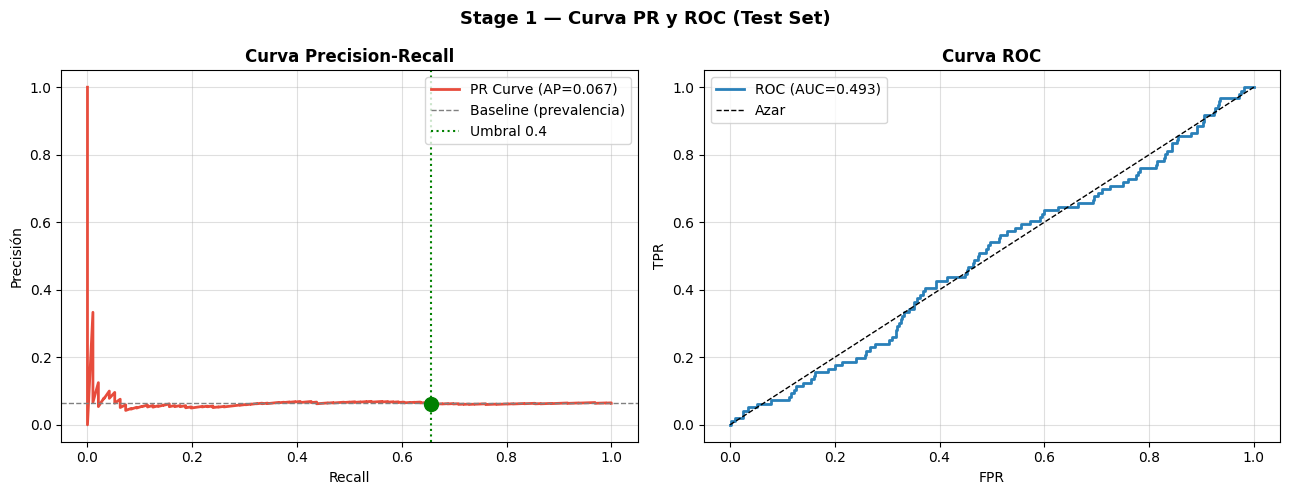

In [ ]:
# ============================================================
# CELDA 16 — EVALUACIÓN STAGE 1 EN TEST SET
# ============================================================

from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve,
                             f1_score, recall_score, precision_score)

# Probabilidades Stage 1 en test
proba_s1_test = stage1_model.predict(X_test_v5, verbose=0).ravel()

# Predicción binaria con el umbral S1_THRESHOLD
pred_s1_test  = (proba_s1_test >= S1_THRESHOLD).astype(int)

# Métricas binarias
auc_s1 = roc_auc_score(y_test_s1, proba_s1_test)
ap_s1  = average_precision_score(y_test_s1, proba_s1_test)
f1_s1  = f1_score(y_test_s1, pred_s1_test, zero_division=0)
rec_s1 = recall_score(y_test_s1, pred_s1_test, zero_division=0)
pre_s1 = precision_score(y_test_s1, pred_s1_test, zero_division=0)

tp_s1 = int(((pred_s1_test == 1) & (y_test_s1 == 1)).sum())
fn_s1 = int(((pred_s1_test == 0) & (y_test_s1 == 1)).sum())
fp_s1 = int(((pred_s1_test == 1) & (y_test_s1 == 0)).sum())

print("=" * 65)
print("  EVALUACIÓN STAGE 1 — Sepsis vs No-Sepsis (Test Set)")
print("=" * 65)
print(f"\n  Umbral de decisión : {S1_THRESHOLD}")
print(f"\n  {'Métrica':<25} {'Valor':>10} {'Objetivo':>12}")
print("  " + "-"*50)
print(f"  {'AUC-ROC':<25} {auc_s1:>10.4f} {'> 0.80':>12}")
print(f"  {'Average Precision':<25} {ap_s1:>10.4f} {'> 0.50':>12}")
print(f"  {'Recall Sepsis':<25} {rec_s1:>10.4f} {'> 0.65':>12}")
print(f"  {'Precisión Sepsis':<25} {pre_s1:>10.4f} {'> 0.20':>12}")
print(f"  {'F1 Sepsis':<25} {f1_s1:>10.4f} {'> 0.35':>12}")
print(f"\n  TP (Sepsis detectada)   : {tp_s1} de 96")
print(f"  FN (Sepsis NO detectada): {fn_s1} ← PERDIDOS para siempre")
print(f"  FP (Falsas alarmas S1)  : {fp_s1} No-Sepsis → irán al Stage 2")

# Curva Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Stage 1 — Curva PR y ROC (Test Set)', fontsize=13, fontweight='bold')

prec_c, rec_c, thr_c = precision_recall_curve(y_test_s1, proba_s1_test)
axes[0].plot(rec_c, prec_c, color='#e74c3c', lw=2, label=f'PR Curve (AP={ap_s1:.3f})')
axes[0].axhline(y_test_s1.mean(), color='gray', ls='--', lw=1, label='Baseline (prevalencia)')
axes[0].axvline(rec_s1, color='green', ls=':', lw=1.5, label=f'Umbral {S1_THRESHOLD}')
axes[0].scatter([rec_s1], [pre_s1], color='green', s=100, zorder=5)
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precisión')
axes[0].set_title('Curva Precision-Recall', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.4)

fpr_c, tpr_c, _ = roc_curve(y_test_s1, proba_s1_test)
axes[1].plot(fpr_c, tpr_c, color='#2980b9', lw=2, label=f'ROC (AUC={auc_s1:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Azar')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/'
            'curvas_pr_roc_stage1.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# CELDA 17 — ANÁLISIS DE UMBRAL STAGE 1
# ============================================================

thresholds_s1  = np.arange(0.10, 0.65, 0.05)
results_thr_s1 = []

for thr in thresholds_s1:
    pred_t = (proba_s1_test >= thr).astype(int)
    tp_    = int(((pred_t == 1) & (y_test_s1 == 1)).sum())
    fn_    = int(((pred_t == 0) & (y_test_s1 == 1)).sum())
    fp_    = int(((pred_t == 1) & (y_test_s1 == 0)).sum())
    rec_   = recall_score(y_test_s1, pred_t, zero_division=0)
    pre_   = precision_score(y_test_s1, pred_t, zero_division=0)
    f1_    = f1_score(y_test_s1, pred_t, zero_division=0)
    results_thr_s1.append({
        'Umbral': round(thr, 2),
        'Recall Sepsis': round(rec_, 4),
        'Precisión Sepsis': round(pre_, 4),
        'F1 Sepsis': round(f1_, 4),
        'TP': tp_, 'FN': fn_, 'FP': fp_
    })

thr_df_s1 = pd.DataFrame(results_thr_s1).set_index('Umbral')
print("  Análisis de umbral Stage 1:\n")
display(thr_df_s1.style
        .highlight_max(subset=['F1 Sepsis', 'Recall Sepsis'], color='#d4edda')
        .highlight_min(subset=['FN', 'FP'], color='#d4edda')
        .format("{:.4f}", subset=['Recall Sepsis', 'Precisión Sepsis', 'F1 Sepsis'])
)

# Selección del umbral óptimo: mayor F1 con Recall ≥ 0.60
candidatos_s1 = thr_df_s1[thr_df_s1['Recall Sepsis'] >= 0.60]
if len(candidatos_s1) > 0:
    S1_OPTIMAL_THRESHOLD = candidatos_s1['F1 Sepsis'].idxmax()
else:
    S1_OPTIMAL_THRESHOLD = thr_df_s1['F1 Sepsis'].idxmax()

opt_s1 = thr_df_s1.loc[S1_OPTIMAL_THRESHOLD]
print(f"\n  🎯 UMBRAL ÓPTIMO STAGE 1: {S1_OPTIMAL_THRESHOLD}")
print(f"     Recall Sepsis    : {opt_s1['Recall Sepsis']:.4f}")
print(f"     Precisión Sepsis : {opt_s1['Precisión Sepsis']:.4f}")
print(f"     F1 Sepsis        : {opt_s1['F1 Sepsis']:.4f}")
print(f"     TP (detectados)  : {int(opt_s1['TP'])}")
print(f"     FN (perdidos)    : {int(opt_s1['FN'])} → nunca recuperables")
print(f"     FP (→ Stage 2)   : {int(opt_s1['FP'])} No-Sepsis irán al Stage 2")

# Actualizar umbral si el óptimo es mejor que el inicial
if S1_OPTIMAL_THRESHOLD != S1_THRESHOLD:
    print(f"\n  ℹ️  Umbral inicial: {S1_THRESHOLD} → Umbral óptimo: {S1_OPTIMAL_THRESHOLD}")
    FINAL_S1_THRESHOLD = S1_OPTIMAL_THRESHOLD
else:
    FINAL_S1_THRESHOLD = S1_THRESHOLD
    print(f"\n  ✅ Umbral inicial {S1_THRESHOLD} confirmado como óptimo.")

  Análisis de umbral Stage 1:



,Recall Sepsis,Precisión Sepsis,F1 Sepsis,TP,FN,FP
Umbral,,,,,,
0.100000,1.0000,0.0640,0.1204,96,0,1403
0.150000,1.0000,0.0644,0.1211,96,0,1394
0.200000,0.9896,0.0648,0.1216,95,1,1371
0.250000,0.9688,0.0656,0.1229,93,3,1325
0.300000,0.8854,0.0633,0.1181,85,11,1258
0.350000,0.7604,0.0607,0.1124,73,23,1130
0.400000,0.6562,0.0613,0.1121,63,33,965
0.450000,0.5833,0.0672,0.1206,56,40,777
0.500000,0.4375,0.0646,0.1126,42,54,608



  🎯 UMBRAL ÓPTIMO STAGE 1: 0.25
     Recall Sepsis    : 0.9688
     Precisión Sepsis : 0.0656
     F1 Sepsis        : 0.1229
     TP (detectados)  : 93
     FN (perdidos)    : 3 → nunca recuperables
     FP (→ Stage 2)   : 1325 No-Sepsis irán al Stage 2

  ℹ️  Umbral inicial: 0.4 → Umbral óptimo: 0.25


In [ ]:
# ============================================================
# CELDA 18 — CONSTRUIR + ENTRENAR STAGE 2 (3 CLASES)
# ============================================================

def focal_loss_multiclass(gamma=1.5, alpha=None):
    """Focal Loss multiclase para Stage 2."""
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_oh   = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        p_t    = tf.reduce_sum(y_oh * y_pred, axis=-1)
        fac    = tf.pow(1.0 - p_t, gamma)
        ce     = -tf.math.log(p_t)
        if alpha is not None:
            a_t = tf.reduce_sum(y_oh * tf.constant(alpha, dtype=tf.float32), axis=-1)
        else:
            a_t = 1.0
        return tf.reduce_mean(a_t * fac * ce)
    return loss

# Pesos Stage 2: leve énfasis en Heart Failure (más urgente que Normal)
# Heart Failure es clínicamente urgente, Normal es la más frecuente
ALPHA_S2 = [1.4, 0.6, 1.2]   # [HF, Normal, Pneumonia]
GAMMA_S2 = 1.5

print("=" * 65)
print(f"  Stage 2 — 3 Clases: {list(le_s2.classes_)}")
print(f"  Mapeo: {dict(enumerate(le_s2.classes_))}")
print(f"  Loss  : Focal Loss (gamma={GAMMA_S2}, alpha={ALPHA_S2})")
print("=" * 65)

print(f"\n  Distribución training S2 (solo No-Sepsis):")
for i, cls in enumerate(le_s2.classes_):
    n = (y_train_s2 == i).sum()
    print(f"    [{i}] {cls:<20}: {n:,} ({n/len(y_train_s2)*100:.1f}%)")

# Construir Stage 2
def build_stage2(input_dim, num_classes,
                 hidden_units=(256, 128, 64),
                 dropout_rate=0.25,
                 l2_lambda=0.0001,
                 learning_rate=0.001,
                 gamma=1.5, alpha=None,
                 name='Stage2_Multiclass'):
    """Clasificador multiclase para Normal/HF/Pneumonia."""
    reg = regularizers.l2(l2_lambda)
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_units[0], activation='relu',
                     kernel_regularizer=reg, kernel_initializer='he_normal'),
        layers.Dropout(dropout_rate),
        layers.Dense(hidden_units[1], activation='relu',
                     kernel_regularizer=reg, kernel_initializer='he_normal'),
        layers.Dropout(dropout_rate),
        layers.Dense(hidden_units[2], activation='relu',
                     kernel_regularizer=reg, kernel_initializer='he_normal'),
        layers.Dropout(dropout_rate * 0.5),
        layers.Dense(num_classes, activation='softmax', name='output_s2')
    ], name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss=focal_loss_multiclass(gamma=gamma, alpha=alpha),
        metrics=['accuracy']
    )
    return model

stage2_model = build_stage2(
    input_dim   = INPUT_DIM_V5,
    num_classes = NUM_CLASSES_S2,
    gamma       = GAMMA_S2,
    alpha       = ALPHA_S2,
    name        = 'Stage2_HF_Normal_Pneumonia'
)
stage2_model.summary()

# Callbacks Stage 2: EarlyStopping simple sobre val_loss
# (Sin F1Monitor porque el desbalanceo de S2 es moderado)
LR_S2_MAX = 0.001
LR_S2_MIN = 0.00005
MAX_EP_S2 = 150

lr_s2 = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate = LR_S2_MAX,
    decay_steps           = MAX_EP_S2 * (len(X_train_s2) // 64),
    alpha                 = LR_S2_MIN / LR_S2_MAX
)
stage2_model.optimizer.learning_rate = lr_s2

S2_SAVE_PATH = ('/content/drive/MyDrive/inteligencia_artificial_colab/'
                'stage2_best_model.keras')

cb_s2_es   = callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
)
cb_s2_ckpt = callbacks.ModelCheckpoint(
    S2_SAVE_PATH, monitor='val_loss', save_best_only=True, verbose=0
)
cb_s2_csv  = callbacks.CSVLogger(
    '/content/drive/MyDrive/inteligencia_artificial_colab/training_log_s2.csv'
)

print(f"\n  ENTRENANDO STAGE 2:")
print(f"  Training : {len(X_train_s2):,} muestras (solo No-Sepsis, sin SMOTE)")
print(f"  Val      : {len(X_val_s2):,} muestras")
print("-" * 65)

history_s2 = stage2_model.fit(
    X_train_s2, y_train_s2,
    validation_data = (X_val_s2, y_val_s2),
    epochs          = MAX_EP_S2,
    batch_size      = 64,
    callbacks       = [cb_s2_es, cb_s2_ckpt, cb_s2_csv],
    verbose         = 1
)

print(f"\n  ✅ Stage 2 completado.")
print(f"  Épocas reales  : {len(history_s2.history['loss'])}")
print(f"  Mejor val_loss : {min(history_s2.history['val_loss']):.4f}")
print(f"  Mejor val_acc  : {max(history_s2.history['val_accuracy']):.4f}")

  Stage 2 — 3 Clases: [np.str_('Heart Failure'), np.str_('Normal'), np.str_('Pneumonia')]
  Mapeo: {0: np.str_('Heart Failure'), 1: np.str_('Normal'), 2: np.str_('Pneumonia')}
  Loss  : Focal Loss (gamma=1.5, alpha=[1.4, 0.6, 1.2])

  Distribución training S2 (solo No-Sepsis):
    [0] Heart Failure       : 1,234 (18.8%)
    [1] Normal              : 3,913 (59.7%)
    [2] Pneumonia           : 1,403 (21.4%)


Model: "Stage2_HF_Normal_Pneumonia"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_s2 (Dense)               │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,187 (176.51 KB)

 Trainable params: 45,187 (176.51 KB)

 Non-trainable params: 0 (0.00 B)


  ENTRENANDO STAGE 2:
  Training : 6,550 muestras (solo No-Sepsis, sin SMOTE)
  Val      : 1,404 muestras
-----------------------------------------------------------------
Epoch 1/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3915 - loss: 0.7535 - val_accuracy: 0.5057 - val_loss: 0.6143
Epoch 2/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4692 - loss: 0.6252 - val_accuracy: 0.5328 - val_loss: 0.6116
Epoch 3/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4997 - loss: 0.6145 - val_accuracy: 0.5912 - val_loss: 0.6099
Epoch 4/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5253 - loss: 0.6104 - val_accuracy: 0.5919 - val_loss: 0.6063
Epoch 5/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5485 - loss: 0.6071 - val_accuracy: 0.5962 - val_loss: 0.6039
Epoch 6/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5643 - loss: 0.6026 - val_accuracy: 0.5969 - val_loss: 0.6021
Epoch 7/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/s

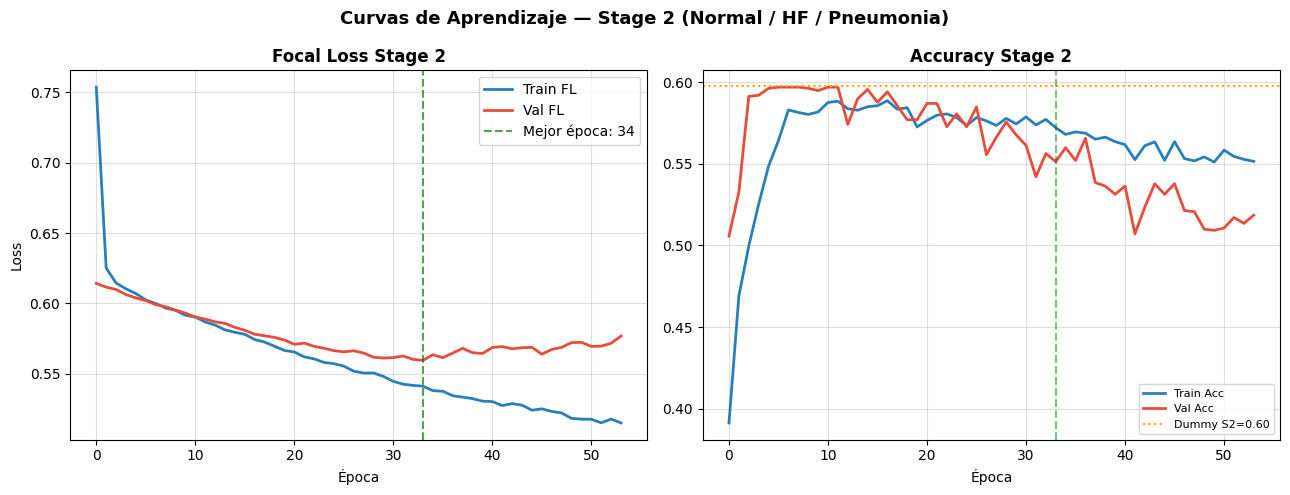


  📌 DIAGNÓSTICO STAGE 2:
  ❌ val_acc=0.5969 no supera el Dummy S2 (0.5974)
  ✅ Brecha train/val=0.044: aprendizaje equilibrado Stage 2


In [ ]:
# ============================================================
# CELDA 19 — CURVAS DE APRENDIZAJE STAGE 2
# ============================================================

best_ep_s2 = np.argmin(history_s2.history['val_loss'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Curvas de Aprendizaje — Stage 2 (Normal / HF / Pneumonia)',
             fontsize=13, fontweight='bold')

axes[0].plot(history_s2.history['loss'],     label='Train FL', color='#2980b9', lw=2)
axes[0].plot(history_s2.history['val_loss'], label='Val FL',   color='#e74c3c', lw=2)
axes[0].axvline(best_ep_s2, color='green', ls='--', alpha=0.7,
                label=f'Mejor época: {best_ep_s2+1}')
axes[0].set_title('Focal Loss Stage 2', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot(history_s2.history['accuracy'],     label='Train Acc', color='#2980b9', lw=2)
axes[1].plot(history_s2.history['val_accuracy'], label='Val Acc',   color='#e74c3c', lw=2)
# Referencia: accuracy de un dummy en 3 clases (mayoritaria)
dummy_s2_acc = max([(y_train_s2==i).sum() for i in range(NUM_CLASSES_S2)]) / len(y_train_s2)
axes[1].axhline(dummy_s2_acc, color='orange', ls=':', lw=1.5,
                label=f'Dummy S2={dummy_s2_acc:.2f}')
axes[1].axvline(best_ep_s2, color='green', ls='--', alpha=0.5)
axes[1].set_title('Accuracy Stage 2', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/'
            'curvas_stage2_v5.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  📌 DIAGNÓSTICO STAGE 2:")
val_acc_s2 = max(history_s2.history['val_accuracy'])
if val_acc_s2 > dummy_s2_acc:
    print(f"  ✅ val_acc={val_acc_s2:.4f} supera el Dummy S2 ({dummy_s2_acc:.4f})")
else:
    print(f"  ❌ val_acc={val_acc_s2:.4f} no supera el Dummy S2 ({dummy_s2_acc:.4f})")

gap = abs(min(history_s2.history['val_loss']) - history_s2.history['loss'][-1])
if gap > 0.15:
    print(f"  ⚠️  Brecha train/val={gap:.3f}: posible overfitting en Stage 2")
else:
    print(f"  ✅ Brecha train/val={gap:.3f}: aprendizaje equilibrado Stage 2")

In [ ]:
# ============================================================
# CELDA 20 — PIPELINE COMPLETO: STAGE 1 + STAGE 2
# ============================================================

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, recall_score, precision_score,
                             classification_report, confusion_matrix)

def predict_two_stage(X_input, stage1_model, stage2_model,
                      s1_threshold, critical_class_idx, le_s2, le_target):
    """
    Ejecuta el pipeline Two-Stage completo para un array de entrada.

    Retorna:
        y_pred_final : Predicciones en índices del le_target original (4 clases)
        proba_s1     : Probabilidades del Stage 1 (P Sepsis)
        proba_s2     : Probabilidades del Stage 2 (3 clases, NaN donde S1=Sepsis)
    """
    n = len(X_input)
    y_pred_final = np.full(n, -1, dtype=int)

    # Stage 1: predicción binaria
    proba_s1     = stage1_model.predict(X_input, verbose=0).ravel()
    s1_sepsis    = proba_s1 >= s1_threshold

    # Asignar Sepsis donde Stage 1 lo indica
    y_pred_final[s1_sepsis] = critical_class_idx

    # Para el resto → Stage 2
    mask_s2 = ~s1_sepsis
    if mask_s2.sum() > 0:
        proba_s2_vals  = stage2_model.predict(X_input[mask_s2], verbose=0)
        pred_s2_local  = np.argmax(proba_s2_vals, axis=1)         # Índice S2 local (0,1,2)
        pred_s2_names  = le_s2.inverse_transform(pred_s2_local)   # Nombres originales
        pred_s2_global = le_target.transform(pred_s2_names)       # Índice global (4 clases)
        y_pred_final[mask_s2] = pred_s2_global

    return y_pred_final, proba_s1


# Ejecutar pipeline en Test Set
y_pred_pipeline, proba_s1_full = predict_two_stage(
    X_test_v5, stage1_model, stage2_model,
    FINAL_S1_THRESHOLD, CRITICAL_CLASS_IDX, le_s2, le_target
)

# Métricas completas 4 clases
acc_v5      = accuracy_score(y_test_enc, y_pred_pipeline)
bal_acc_v5  = balanced_accuracy_score(y_test_enc, y_pred_pipeline)
f1_mac_v5   = f1_score(y_test_enc, y_pred_pipeline, average='macro', zero_division=0)
f1_wei_v5   = f1_score(y_test_enc, y_pred_pipeline, average='weighted', zero_division=0)
rec_crit_v5 = recall_score(y_test_enc, y_pred_pipeline,
                            labels=[CRITICAL_CLASS_IDX], average='macro', zero_division=0)
pre_crit_v5 = precision_score(y_test_enc, y_pred_pipeline,
                               labels=[CRITICAL_CLASS_IDX], average='macro', zero_division=0)
f1_crit_v5  = f1_score(y_test_enc, y_pred_pipeline,
                        labels=[CRITICAL_CLASS_IDX], average='macro', zero_division=0)
cm_v5       = confusion_matrix(y_test_enc, y_pred_pipeline)
tp_v5       = cm_v5[CRITICAL_CLASS_IDX, CRITICAL_CLASS_IDX]
fn_v5       = cm_v5[CRITICAL_CLASS_IDX].sum() - tp_v5
fp_v5       = cm_v5[:, CRITICAL_CLASS_IDX].sum() - tp_v5

print("=" * 78)
print("  EVALUACIÓN FINAL — PIPELINE TWO-STAGE v5 (Test Set)")
print("=" * 78)
print(f"\n  Umbral Stage 1 usado: {FINAL_S1_THRESHOLD}")
print(f"  Casos → Sepsis (S1)  : {(proba_s1_full >= FINAL_S1_THRESHOLD).sum():,}")
print(f"  Casos → Stage 2      : {(proba_s1_full < FINAL_S1_THRESHOLD).sum():,}")

print(f"\n  {'Métrica':<28} {'v2':>8} {'v3':>8} {'v4':>8} {'v5':>8} {'Obj':>8}")
print("  " + "-"*72)
rows_ = [
    ("Accuracy",         0.4560, 0.1333, 0.3953, acc_v5,      "> 0.60"),
    ("Balanced Acc.",    0.2533, 0.2443, 0.2423, bal_acc_v5,  "> 0.60"),
    ("F1 Macro",         0.2448, 0.1457, 0.2046, f1_mac_v5,   "> 0.50"),
    ("Recall Sepsis",    0.0104, 0.4792, 0.2396, rec_crit_v5, "> 0.65"),
    ("Precisión Sepsis", None,   0.0600, 0.0562, pre_crit_v5, "> 0.20"),
    ("F1 Sepsis",        None,   0.1100, 0.0911, f1_crit_v5,  "> 0.35"),
]
for row in rows_:
    n_, v2_, v3_, v4_, v5_, obj_ = row
    v2s = f"{v2_:.4f}" if v2_ else "  N/A"
    v3s = f"{v3_:.4f}" if v3_ else "  N/A"
    v4s = f"{v4_:.4f}" if v4_ else "  N/A"
    ico = "✅" if v5_ > (v4_ if v4_ else 0) else "❌"
    print(f"  {n_:<28} {v2s:>8} {v3s:>8} {v4s:>8} {v5_:>8.4f} {ico} {obj_:>8}")

print(f"\n  TP Sepsis: v2=1  → v3=46 → v4=23 → v5={tp_v5}")
print(f"  FN Sepsis: v2=95 → v3=50 → v4=73 → v5={fn_v5}")
print(f"  FP Sepsis: v2=N/A → v3=~344 → v4=386 → v5={fp_v5}")

print(f"\n{classification_report(y_test_enc, y_pred_pipeline, target_names=CLASS_NAMES, zero_division=0)}")

  EVALUACIÓN FINAL — PIPELINE TWO-STAGE v5 (Test Set)

  Umbral Stage 1 usado: 0.25
  Casos → Sepsis (S1)  : 1,418
  Casos → Stage 2      : 82

  Métrica                            v2       v3       v4       v5      Obj
  ------------------------------------------------------------------------
  Accuracy                       0.4560   0.1333   0.3953   0.0933 ❌   > 0.60
  Balanced Acc.                  0.2533   0.2443   0.2423   0.2574 ✅   > 0.60
  F1 Macro                       0.2448   0.1457   0.2046   0.0589 ❌   > 0.50
  Recall Sepsis                  0.0104   0.4792   0.2396   0.9688 ✅   > 0.65
  Precisión Sepsis                  N/A   0.0600   0.0562   0.0656 ✅   > 0.20
  F1 Sepsis                         N/A   0.1100   0.0911   0.1229 ✅   > 0.35

  TP Sepsis: v2=1  → v3=46 → v4=23 → v5=93
  FN Sepsis: v2=95 → v3=50 → v4=73 → v5=3
  FP Sepsis: v2=N/A → v3=~344 → v4=386 → v5=1325

               precision    recall  f1-score   support

Heart Failure       0.17      0.00      0.01 

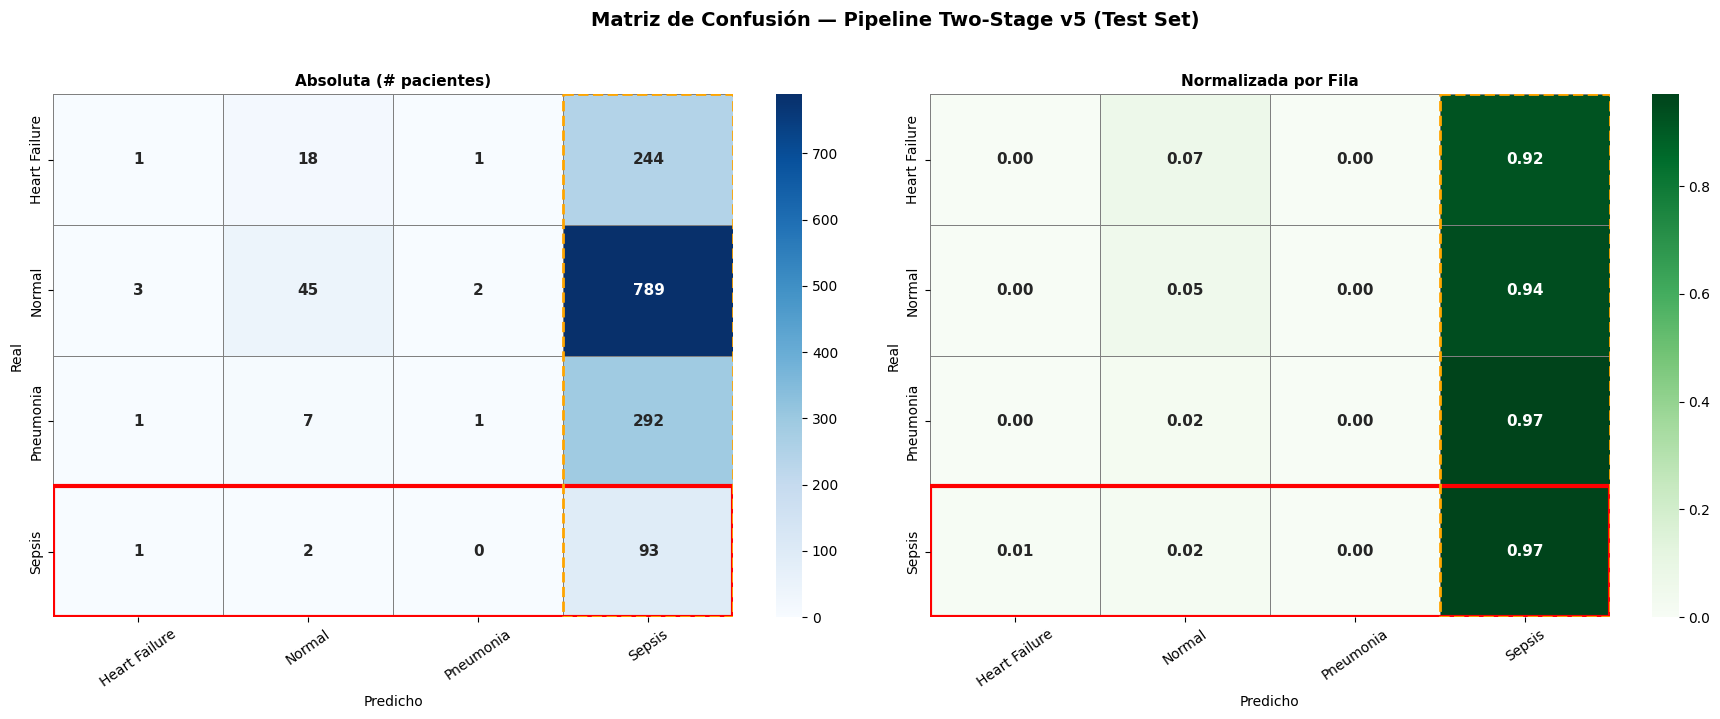


  Análisis fila Sepsis (FN): 3 no detectados
  ¿Cómo fueron clasificados?
    → 'Heart Failure': 1 (v4 fue: 5) ✅ urgente (aceptable)
    → 'Normal': 2 (v4 fue: 67) ⚠️  peligroso
    → 'Pneumonia': 0 (v4 fue: 1) ✅ urgente (aceptable)

  Columna Sepsis (FP): 1325 falsas alarmas
  (v4 tuvo: 386 | v3 tuvo: ~344)


In [ ]:
# ============================================================
# CELDA 21 — MATRIZ DE CONFUSIÓN PIPELINE v5
# ============================================================

import seaborn as sns

cm_v5_norm = cm_v5.astype('float') / cm_v5.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matriz de Confusión — Pipeline Two-Stage v5 (Test Set)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, matrix, title, fmt, cmap in zip(
    axes,
    [cm_v5, cm_v5_norm],
    ['Absoluta (# pacientes)', 'Normalizada por Fila'],
    ['d', '.2f'],
    ['Blues', 'Greens']
):
    sns.heatmap(matrix, annot=True, fmt=fmt,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap=cmap, ax=ax, linewidths=0.5, linecolor='gray',
                annot_kws={"size": 11, "fontweight": "bold"})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Real', fontsize=10); ax.set_xlabel('Predicho', fontsize=10)
    ax.tick_params(axis='x', rotation=35)
    # Fila Sepsis (FN)
    ax.add_patch(plt.Rectangle(
        (0, CRITICAL_CLASS_IDX), NUM_CLASSES, 1,
        fill=False, edgecolor='red', lw=3
    ))
    # Columna Sepsis (FP)
    ax.add_patch(plt.Rectangle(
        (CRITICAL_CLASS_IDX, 0), 1, NUM_CLASSES,
        fill=False, edgecolor='orange', lw=2, ls='--'
    ))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/'
            'confusion_matrix_v5.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  Análisis fila Sepsis (FN): {fn_v5} no detectados")
print(f"  ¿Cómo fueron clasificados?")
for j, cls in enumerate(CLASS_NAMES):
    if j != CRITICAL_CLASS_IDX:
        count = cm_v5[CRITICAL_CLASS_IDX, j]
        danger = "⚠️  peligroso" if j == 1 else "✅ urgente (aceptable)"
        v4_ref = {0: 5, 1: 67, 2: 1}.get(j, 0)
        print(f"    → '{cls}': {count} (v4 fue: {v4_ref}) {danger}")

print(f"\n  Columna Sepsis (FP): {fp_v5} falsas alarmas")
print(f"  (v4 tuvo: 386 | v3 tuvo: ~344)")

In [ ]:
# ============================================================
# CELDA 22 — TABLA COMPARATIVA — TODOS LOS MODELOS
# ============================================================

tabla_v5 = pd.DataFrame([
    {'Modelo': 'Dummy (most_frequent)',
     'Accuracy': 0.5587, 'Balanced Acc.': 0.2500, 'F1 Macro': 0.1792,
     'Recall Sepsis': 0.0000, 'Precisión Sepsis': None, 'FN': 96, 'FP': 0},
    {'Modelo': 'RF (con SMOTE)',
     'Accuracy': 0.7900, 'Balanced Acc.': 0.7200, 'F1 Macro': 0.7000,
     'Recall Sepsis': 0.6100, 'Precisión Sepsis': None, 'FN': 37, 'FP': None},
    {'Modelo': 'MLP v1 (CE auto)',
     'Accuracy': 0.2293, 'Balanced Acc.': 0.2520, 'F1 Macro': 0.2109,
     'Recall Sepsis': 0.2396, 'Precisión Sepsis': None, 'FN': 73, 'FP': None},
    {'Modelo': 'MLP v2 (CE calibrada)',
     'Accuracy': 0.4560, 'Balanced Acc.': 0.2533, 'F1 Macro': 0.2448,
     'Recall Sepsis': 0.0104, 'Precisión Sepsis': None, 'FN': 95, 'FP': None},
    {'Modelo': 'MLP v3 (FL + SMOTE 20%)',
     'Accuracy': 0.1333, 'Balanced Acc.': 0.2443, 'F1 Macro': 0.1457,
     'Recall Sepsis': 0.4792, 'Precisión Sepsis': 0.0600, 'FN': 50, 'FP': 344},
    {'Modelo': 'MLP v4 (FL calibrada + SMOTE 12%)',
     'Accuracy': 0.3953, 'Balanced Acc.': 0.2423, 'F1 Macro': 0.2046,
     'Recall Sepsis': 0.2396, 'Precisión Sepsis': 0.0562, 'FN': 73, 'FP': 386},
    {'Modelo': f'MLP v5 (Two-Stage, S1_thr={FINAL_S1_THRESHOLD})',
     'Accuracy': round(acc_v5, 4), 'Balanced Acc.': round(bal_acc_v5, 4),
     'F1 Macro': round(f1_mac_v5, 4),
     'Recall Sepsis': round(rec_crit_v5, 4),
     'Precisión Sepsis': round(pre_crit_v5, 4),
     'FN': int(fn_v5), 'FP': int(fp_v5)},
]).set_index('Modelo')

print("=" * 92)
print("  TABLA COMPARATIVA — HISTORIAL COMPLETO DE MODELOS")
print("=" * 92)
display(tabla_v5.style
        .highlight_max(subset=['Accuracy', 'Balanced Acc.', 'F1 Macro',
                               'Recall Sepsis', 'Precisión Sepsis'],
                       color='#d4edda')
        .highlight_min(subset=['FN'], color='#d4edda')
        .format("{:.4f}", na_rep="N/A",
                subset=[c for c in tabla_v5.columns if c not in ['FN', 'FP']])
)
print(f"\n  Referencia RF con SMOTE: el modelo clásico que debemos superar")

  TABLA COMPARATIVA — HISTORIAL COMPLETO DE MODELOS


,Accuracy,Balanced Acc.,F1 Macro,Recall Sepsis,Precisión Sepsis,FN,FP
Modelo,,,,,,,
Dummy (most_frequent),0.5587,0.2500,0.1792,0.0000,N/A,96,0.000000
RF (con SMOTE),0.7900,0.7200,0.7000,0.6100,N/A,37,nan
MLP v1 (CE auto),0.2293,0.2520,0.2109,0.2396,N/A,73,nan
MLP v2 (CE calibrada),0.4560,0.2533,0.2448,0.0104,N/A,95,nan
MLP v3 (FL + SMOTE 20%),0.1333,0.2443,0.1457,0.4792,0.0600,50,344.000000
MLP v4 (FL calibrada + SMOTE 12%),0.3953,0.2423,0.2046,0.2396,0.0562,73,386.000000
"MLP v5 (Two-Stage, S1_thr=0.25)",0.0933,0.2574,0.0589,0.9688,0.0656,3,1325.000000



  Referencia RF con SMOTE: el modelo clásico que debemos superar


In [ ]:
# ============================================================
# CELDA 23 — ANÁLISIS DUAL FN/FP PIPELINE v5
# ============================================================

critical_mask_v5 = (y_test_enc == CRITICAL_CLASS_IDX)
y_pred_crit_v5   = y_pred_pipeline[critical_mask_v5]
tp_mask_v5 = (y_pred_crit_v5 == CRITICAL_CLASS_IDX)
fn_mask_v5 = (y_pred_crit_v5 != CRITICAL_CLASS_IDX)

X_crit_df = pd.DataFrame(X_test_v5[critical_mask_v5], columns=ALL_FEATURES_V5)
X_crit_df['prediccion'] = [CLASS_NAMES[p] for p in y_pred_crit_v5]
X_crit_df['proba_s1']   = proba_s1_full[critical_mask_v5]
fn_df_v5 = X_crit_df[fn_mask_v5]
tp_df_v5 = X_crit_df[tp_mask_v5]

print("=" * 65)
print(f"  ANÁLISIS DUAL FN/FP — Pipeline v5")
print("=" * 65)
print(f"\n  FALSOS NEGATIVOS:")
print(f"  TP (detectados): {tp_mask_v5.sum():<4} | v4=23 | v3=46 | v2=1")
print(f"  FN (perdidos)  : {fn_mask_v5.sum():<4} | v4=73 | v3=50 | v2=95")

if fn_mask_v5.sum() > 0:
    print(f"\n  ¿Cómo clasificó v5 los {fn_mask_v5.sum()} FN?")
    for cls, count in pd.Series(fn_df_v5['prediccion']).value_counts().items():
        peligro = "⚠️  peligroso" if cls == CLASS_NAMES[1] else "✅ aceptable"
        print(f"    → '{cls}': {count} ({peligro})")

    # Probabilidad S1 de los FN (para entender por qué S1 los dejó pasar)
    print(f"\n  P(Sepsis) del Stage 1 para los FN:")
    print(f"  Media  : {fn_df_v5['proba_s1'].mean():.4f}")
    print(f"  Máximo : {fn_df_v5['proba_s1'].max():.4f}")
    print(f"  Mínimo : {fn_df_v5['proba_s1'].min():.4f}")
    print(f"  → Estos pacientes tuvieron P(Sepsis)<{FINAL_S1_THRESHOLD}, "
          f"Stage 1 no los detectó")

    print(f"\n  Perfil comparativo FN vs TP (escala estandarizada):")
    print(f"  {'Feature':<28} {'FN v5':>10} {'TP v5':>10}")
    for feat in NUMERIC_FEATURES + NEW_FEATURES:
        fn_m = fn_df_v5[feat].mean() if len(fn_df_v5) > 0 else float('nan')
        tp_m = tp_df_v5[feat].mean() if len(tp_df_v5) > 0 else float('nan')
        print(f"  {feat:<28} {fn_m:>10.3f} {tp_m:>10.3f}")

print(f"\n  FALSOS POSITIVOS (falsas alarmas de Sepsis):")
total_alerts = (y_pred_pipeline == CRITICAL_CLASS_IDX).sum()
print(f"  Total alertas Sepsis : {total_alerts}")
print(f"  TP (reales)          : {tp_v5} ({tp_v5/total_alerts*100:.1f}%)")
print(f"  FP (falsas alarmas)  : {fp_v5} ({fp_v5/total_alerts*100:.1f}%)")
print(f"  v4 tuvo: 5.6% precisión (94.4% falsas alarmas)")

  ANÁLISIS DUAL FN/FP — Pipeline v5

  FALSOS NEGATIVOS:
  TP (detectados): 93   | v4=23 | v3=46 | v2=1
  FN (perdidos)  : 3    | v4=73 | v3=50 | v2=95

  ¿Cómo clasificó v5 los 3 FN?
    → 'Normal': 2 (⚠️  peligroso)
    → 'Heart Failure': 1 (✅ aceptable)

  P(Sepsis) del Stage 1 para los FN:
  Media  : 0.2012
  Máximo : 0.2104
  Mínimo : 0.1895
  → Estos pacientes tuvieron P(Sepsis)<0.25, Stage 1 no los detectó

  Perfil comparativo FN vs TP (escala estandarizada):
  Feature                           FN v5      TP v5
  age                              -1.117      0.164
  bmi                              -0.393     -0.059
  systolic_bp                       0.270      0.009
  diastolic_bp                     -1.256      0.216
  glucose                           0.367      0.223
  cholesterol                      -1.345     -0.043
  creatinine                        0.270     -0.031
  pulse_pressure                    1.090     -0.147
  map_approx                       -0.995      0.19

In [ ]:
# ============================================================
# CELDA 24 — FILOSOFÍA DE SINTONIZACIÓN v5
# ============================================================

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║      SINTONIZACIÓN v5 — AJUSTE DEL PIPELINE TWO-STAGE              ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  PARÁMETROS CRÍTICOS DEL PIPELINE:                                  ║
║                                                                      ║
║  [S1] Umbral Stage 1 (S1_THRESHOLD):                                ║
║  → Bajo (0.25): más Sepsis detectados (menos FN), más FP al S2     ║
║  → Alto (0.50): menos FP, pero más Sepsis se pierden en S1         ║
║  → Óptimo clínico: mayor F1 Sepsis con Recall ≥ 0.60               ║
║                                                                      ║
║  [S1] Alpha Stage 1 (ALPHA_S1):                                     ║
║  → Mayor alpha (0.90): más penalización por FN → más Recall        ║
║  → Menor alpha (0.75): más balance Precisión/Recall                 ║
║                                                                      ║
║  [S1] SMOTE Stage 1 (SMOTE_S1_PCT):                                 ║
║  → 25% actual: balance entre datos originales y sintéticos          ║
║  → 30%: más sintéticos → mayor Recall pero más FP                  ║
║                                                                      ║
║  [S2] Gamma Stage 2 (GAMMA_S2):                                     ║
║  → 1.5 actual: focal suave para las 3 clases moderadamente          ║
║    desbalanceadas                                                    ║
║                                                                      ║
║  REGLA DE SINTONIZACIÓN TWO-STAGE:                                  ║
║  → Primero optimizar S1 (el filtro de Sepsis)                       ║
║  → Luego ajustar S2 (sin cambiar S1)                                ║
║  → El umbral S1 siempre es la última decisión (es clínica)          ║
║                                                                      ║
║  OBJETIVO v5:                                                        ║
║  Recall Sepsis ≥ 0.65 | Precisión Sepsis ≥ 0.20 | F1 ≥ 0.35       ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║      SINTONIZACIÓN v5 — AJUSTE DEL PIPELINE TWO-STAGE              ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  PARÁMETROS CRÍTICOS DEL PIPELINE:                                  ║
║                                                                      ║
║  [S1] Umbral Stage 1 (S1_THRESHOLD):                                ║
║  → Bajo (0.25): más Sepsis detectados (menos FN), más FP al S2     ║
║  → Alto (0.50): menos FP, pero más Sepsis se pierden en S1         ║
║  → Óptimo clínico: mayor F1 Sepsis con Recall ≥ 0.60               ║
║                                                                      ║
║  [S1] Alpha Stage 1 (ALPHA_S1):                                     ║
║  → Mayor alpha (0.90): más penalización por FN → más Recall        ║
║  → Menor alpha (0.75): más balance Precisión/Recall          

In [ ]:
# ============================================================
# CELDA 25 — FUNCIONES FLEXIBLES PARA EXPERIMENTOS v5
# ============================================================

def build_stage1_flex(input_dim,
                      hidden_units=(256, 128, 64),
                      dropout_rate=0.30,
                      l2_lambda=0.0001,
                      learning_rate=0.001,
                      gamma=2.0, alpha=0.85,
                      name='S1_flex'):
    """Stage 1 configurable — Binario Sepsis/No-Sepsis."""
    reg = regularizers.l2(l2_lambda)
    layers_list = [layers.Input(shape=(input_dim,))]
    for i, u in enumerate(hidden_units):
        layers_list.append(
            layers.Dense(u, activation='relu', kernel_regularizer=reg,
                         kernel_initializer='he_normal', name=f's1_dense_{i+1}')
        )
        if i < len(hidden_units) - 1:
            layers_list.append(
                layers.Dropout(max(dropout_rate*(1-i*0.1), 0.05), name=f's1_drop_{i+1}')
            )
    layers_list.append(layers.Dense(1, activation='sigmoid', name='s1_out'))
    model = models.Sequential(layers_list, name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss=binary_focal_loss(gamma=gamma, alpha=alpha),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model


def train_pipeline_experiment(config,
                               X_tr_base, y_tr_base_enc,
                               X_v, y_v_enc,
                               X_te, y_te_enc,
                               critical_idx, le_s2, le_target, le_s2_classes,
                               max_epochs=50, verbose=0):
    """
    Entrena un experimento completo del pipeline Two-Stage.
    Retorna métricas de la evaluación conjunta S1+S2 en test.
    """
    tf.keras.backend.clear_session()
    from imblearn.over_sampling import SMOTE
    from sklearn.metrics import (recall_score, precision_score, f1_score,
                                 balanced_accuracy_score, accuracy_score)

    # ── Preparar targets binarios
    y_tr_s1 = (y_tr_base_enc == critical_idx).astype(np.float32)
    y_v_s1  = (y_v_enc       == critical_idx).astype(np.float32)
    y_te_s1 = (y_te_enc      == critical_idx).astype(np.float32)

    # ── SMOTE para Stage 1
    smote_pct = config.get('smote_s1_pct', 0.25)
    n_otras_  = (y_tr_s1 == 0).sum()
    n_sep_obj = int(n_otras_ / (1 - smote_pct)) - n_otras_
    n_sep_act = int(y_tr_s1.sum())
    if n_sep_obj > n_sep_act:
        sm_ = SMOTE(sampling_strategy={1: n_sep_obj},
                    k_neighbors=5, random_state=RANDOM_STATE)
        X_tr_sm, y_tr_sm = sm_.fit_resample(X_tr_base, y_tr_s1.astype(int))
        y_tr_sm = y_tr_sm.astype(np.float32)
    else:
        X_tr_sm, y_tr_sm = X_tr_base, y_tr_s1

    # ── Construir y entrenar Stage 1
    s1 = build_stage1_flex(
        input_dim     = X_tr_base.shape[1],
        hidden_units  = config.get('s1_units', (256, 128, 64)),
        dropout_rate  = config.get('s1_dropout', 0.30),
        l2_lambda     = config.get('s1_l2', 0.0001),
        learning_rate = config.get('s1_lr', 0.001),
        gamma         = config.get('s1_gamma', 2.0),
        alpha         = config.get('s1_alpha', 0.85),
        name          = f"{config['name']}_S1"
    )
    cb_es_s1 = callbacks.EarlyStopping(
        monitor='val_loss', patience=12, restore_best_weights=True, verbose=0
    )
    s1.fit(X_tr_sm, y_tr_sm, validation_data=(X_v, y_v_s1),
           epochs=max_epochs, batch_size=64, callbacks=[cb_es_s1], verbose=verbose)

    # ── Construir y entrenar Stage 2
    mask_tr_s2 = (y_tr_base_enc != critical_idx)
    mask_v_s2  = (y_v_enc != critical_idx)
    X_tr_s2_   = X_tr_base[mask_tr_s2]
    X_v_s2_    = X_v[mask_v_s2]
    le_s2_temp = LabelEncoder(); le_s2_temp.fit(le_s2_classes)
    y_tr_s2_   = le_s2_temp.transform(
        le_target.inverse_transform(y_tr_base_enc[mask_tr_s2])
    )
    y_v_s2_    = le_s2_temp.transform(
        le_target.inverse_transform(y_v_enc[mask_v_s2])
    )
    s2 = build_stage2(
        input_dim     = X_tr_base.shape[1],
        num_classes   = len(le_s2_classes),
        hidden_units  = config.get('s2_units', (256, 128, 64)),
        dropout_rate  = config.get('s2_dropout', 0.25),
        l2_lambda     = config.get('s2_l2', 0.0001),
        learning_rate = config.get('s2_lr', 0.001),
        gamma         = config.get('s2_gamma', 1.5),
        alpha         = config.get('s2_alpha', [1.4, 0.6, 1.2]),
        name          = f"{config['name']}_S2"
    )
    cb_es_s2 = callbacks.EarlyStopping(
        monitor='val_loss', patience=12, restore_best_weights=True, verbose=0
    )
    s2.fit(X_tr_s2_, y_tr_s2_, validation_data=(X_v_s2_, y_v_s2_),
           epochs=max_epochs, batch_size=64, callbacks=[cb_es_s2], verbose=verbose)

    # ── Evaluar pipeline completo en test
    thr_exp = config.get('s1_threshold', 0.40)
    y_pred_, _ = predict_two_stage(
        X_te, s1, s2, thr_exp, critical_idx, le_s2_temp, le_target
    )
    rc  = recall_score(y_te_enc, y_pred_, labels=[critical_idx],
                       average='macro', zero_division=0)
    pc  = precision_score(y_te_enc, y_pred_, labels=[critical_idx],
                          average='macro', zero_division=0)
    f1c = f1_score(y_te_enc, y_pred_, labels=[critical_idx],
                   average='macro', zero_division=0)
    f1m = f1_score(y_te_enc, y_pred_, average='macro', zero_division=0)
    ac  = accuracy_score(y_te_enc, y_pred_)
    cm_ = confusion_matrix(y_te_enc, y_pred_)
    fn_ = cm_[critical_idx].sum() - cm_[critical_idx, critical_idx]
    fp_ = cm_[:, critical_idx].sum() - cm_[critical_idx, critical_idx]

    results = {
        'Experimento'   : config['name'],
        'Accuracy'      : round(ac, 4),
        'F1 Macro'      : round(f1m, 4),
        'Recall Sepsis' : round(rc, 4),
        'Precisión Sep.': round(pc, 4),
        'F1 Sepsis'     : round(f1c, 4),
        'FN': int(fn_), 'FP': int(fp_),
        'S1 Threshold'  : thr_exp,
        'SMOTE S1 %'    : f"{smote_pct*100:.0f}%"
    }
    print(f"  [{config['name']}] F1_Sep={f1c:.4f} | "
          f"Rec={rc:.4f} | Pre={pc:.4f} | FN={fn_} | FP={fp_}")
    return results

print("  ✅ Funciones build_stage1_flex, build_stage2 y train_pipeline_experiment listas.")

  ✅ Funciones build_stage1_flex, build_stage2 y train_pipeline_experiment listas.


In [ ]:
# ============================================================
# CELDA 26 — EXPERIMENTOS CONTROLADOS v5
# ============================================================

classes_s2_names = list(le_s2.classes_)

EXPERIMENTS_V5 = [
    {
        'name'        : 'Exp_A_Base_v5',
        's1_units'    : (256, 128, 64),
        's1_dropout'  : 0.30,
        's1_l2'       : 0.0001,
        's1_lr'       : 0.001,
        's1_gamma'    : 2.0,
        's1_alpha'    : 0.85,
        'smote_s1_pct': 0.25,
        's1_threshold': 0.40,
        's2_units'    : (256, 128, 64),
        's2_dropout'  : 0.25,
        's2_gamma'    : 1.5,
        's2_alpha'    : [1.4, 0.6, 1.2],
        'hipotesis'   : 'Base v5: umbral=0.40, SMOTE 25%, alpha S1=0.85'
    },
    {
        'name'        : 'Exp_B_Umbral_Bajo',
        's1_units'    : (256, 128, 64),
        's1_dropout'  : 0.30,
        's1_l2'       : 0.0001,
        's1_lr'       : 0.001,
        's1_gamma'    : 2.0,
        's1_alpha'    : 0.85,
        'smote_s1_pct': 0.25,
        's1_threshold': 0.30,   # Umbral más bajo → más Recall, más FP
        's2_units'    : (256, 128, 64),
        's2_dropout'  : 0.25,
        's2_gamma'    : 1.5,
        's2_alpha'    : [1.4, 0.6, 1.2],
        'hipotesis'   : 'Umbral S1=0.30: ¿más recall con FP tolerables?'
    },
    {
        'name'        : 'Exp_C_Alpha_Alto',
        's1_units'    : (256, 128, 64),
        's1_dropout'  : 0.30,
        's1_l2'       : 0.0001,
        's1_lr'       : 0.001,
        's1_gamma'    : 2.0,
        's1_alpha'    : 0.90,   # Más penalización por FN
        'smote_s1_pct': 0.25,
        's1_threshold': 0.35,
        's2_units'    : (256, 128, 64),
        's2_dropout'  : 0.25,
        's2_gamma'    : 1.5,
        's2_alpha'    : [1.4, 0.6, 1.2],
        'hipotesis'   : 'alpha S1=0.90 + umbral=0.35: más sensible al Sepsis'
    },
    {
        'name'        : 'Exp_D_SMOTE_30',
        's1_units'    : (256, 128, 64),
        's1_dropout'  : 0.30,
        's1_l2'       : 0.0001,
        's1_lr'       : 0.001,
        's1_gamma'    : 2.0,
        's1_alpha'    : 0.85,
        'smote_s1_pct': 0.30,   # Más datos sintéticos de Sepsis
        's1_threshold': 0.40,
        's2_units'    : (256, 128, 64),
        's2_dropout'  : 0.25,
        's2_gamma'    : 1.5,
        's2_alpha'    : [1.4, 0.6, 1.2],
        'hipotesis'   : 'SMOTE S1=30%: ¿más sintéticos mejoran la frontera de decisión?'
    },
]

print("=" * 80)
print("  EJECUCIÓN DE EXPERIMENTOS v5 — PIPELINE TWO-STAGE")
print("=" * 80)
print(f"  Referencia v4: F1_Sep=0.09 | Rec=0.24 | Pre=0.056 | FN=73 | FP=386")
print(f"  Referencia RF: F1_Sep=N/A  | Rec=0.61 | FN=37")
print(f"\n  Formato: [Nombre] F1_Sep | Rec | Pre | FN | FP\n")

all_results_v5 = []

for exp_cfg in EXPERIMENTS_V5:
    print(f"  Hipótesis: '{exp_cfg['hipotesis']}'")
    results = train_pipeline_experiment(
        config         = exp_cfg,
        X_tr_base      = X_train_v5,
        y_tr_base_enc  = y_train_enc,
        X_v            = X_val_v5,
        y_v_enc        = y_val_enc,
        X_te           = X_test_v5,
        y_te_enc       = y_test_enc,
        critical_idx   = CRITICAL_CLASS_IDX,
        le_s2          = le_s2,
        le_target      = le_target,
        le_s2_classes  = classes_s2_names,
        max_epochs     = 50,
        verbose        = 0
    )
    all_results_v5.append(results)
    print()

exp_df_v5 = pd.DataFrame(all_results_v5).set_index('Experimento')
print("\n" + "=" * 80)
print("  TABLA DE RESULTADOS v5")
print("=" * 80)
display(exp_df_v5.style
        .highlight_max(subset=['F1 Sepsis', 'Recall Sepsis', 'Precisión Sep.', 'F1 Macro'],
                       color='#d4edda')
        .highlight_min(subset=['FN', 'FP'], color='#d4edda')
        .format({c: "{:.4f}" for c in exp_df_v5.select_dtypes(float).columns})
)

  EJECUCIÓN DE EXPERIMENTOS v5 — PIPELINE TWO-STAGE
  Referencia v4: F1_Sep=0.09 | Rec=0.24 | Pre=0.056 | FN=73 | FP=386
  Referencia RF: F1_Sep=N/A  | Rec=0.61 | FN=37

  Formato: [Nombre] F1_Sep | Rec | Pre | FN | FP

  Hipótesis: 'Base v5: umbral=0.40, SMOTE 25%, alpha S1=0.85'
  [Exp_A_Base_v5] F1_Sep=0.1256 | Rec=0.8750 | Pre=0.0676 | FN=12 | FP=1158

  Hipótesis: 'Umbral S1=0.30: ¿más recall con FP tolerables?'
  [Exp_B_Umbral_Bajo] F1_Sep=0.1241 | Rec=0.9375 | Pre=0.0665 | FN=6 | FP=1264

  Hipótesis: 'alpha S1=0.90 + umbral=0.35: más sensible al Sepsis'


  [Exp_C_Alpha_Alto] F1_Sep=0.1192 | Rec=0.9375 | Pre=0.0636 | FN=6 | FP=1324

  Hipótesis: 'SMOTE S1=30%: ¿más sintéticos mejoran la frontera de decisión?'


  [Exp_D_SMOTE_30] F1_Sep=0.1155 | Rec=0.7396 | Pre=0.0627 | FN=25 | FP=1062


  TABLA DE RESULTADOS v5


,Accuracy,F1 Macro,Recall Sepsis,Precisión Sep.,F1 Sepsis,FN,FP,S1 Threshold,SMOTE S1 %
Experimento,,,,,,,,,
Exp_A_Base_v5,0.1460,0.1056,0.8750,0.0676,0.1256,12,1158,0.4000,25%
Exp_B_Umbral_Bajo,0.1113,0.0769,0.9375,0.0665,0.1241,6,1264,0.3000,25%
Exp_C_Alpha_Alto,0.0940,0.0613,0.9375,0.0636,0.1192,6,1324,0.3500,25%
Exp_D_SMOTE_30,0.1627,0.1286,0.7396,0.0627,0.1155,25,1062,0.4000,30%


In [ ]:
# ============================================================
# CELDA 27 — SELECCIÓN DEL MEJOR EXPERIMENTO v5
# ============================================================

F1_SEP_MIN_V5  = 0.30
RECALL_MIN_V5  = 0.55
PREC_MIN_V5    = 0.15

print("=" * 72)
print("  SELECCIÓN DEL MEJOR EXPERIMENTO v5 — CRITERIOS CLÍNICOS")
print("=" * 72)

results_df_v5 = pd.DataFrame(all_results_v5)

candidatos = results_df_v5[
    (results_df_v5['F1 Sepsis']     >= F1_SEP_MIN_V5) &
    (results_df_v5['Recall Sepsis'] >= RECALL_MIN_V5) &
    (results_df_v5['Precisión Sep.'] >= PREC_MIN_V5)
]

print(f"\n  Filtro: F1≥{F1_SEP_MIN_V5} AND Recall≥{RECALL_MIN_V5} AND Precisión≥{PREC_MIN_V5}")
if len(candidatos) == 0:
    print("  ⚠️  Ningún experimento pasa todos los filtros.")
    best_idx  = results_df_v5['F1 Sepsis'].idxmax()
    VEREDICTO = "MEJOR DISPONIBLE — seguir refinando"
else:
    print(f"  ✅ {len(candidatos)} candidato(s) pasan los filtros.")
    best_idx  = candidatos['FN'].idxmin()
    VEREDICTO = "OBJETIVO CLÍNICO ALCANZADO"

BEST_EXP_V5 = results_df_v5.iloc[best_idx]['Experimento']
best_row_v5 = results_df_v5.iloc[best_idx]

print(f"\n  🏆 GANADOR v5: '{BEST_EXP_V5}'")
print(f"  📋 VEREDICTO : {VEREDICTO}")
print(f"\n  {'Métrica':<22} {'v4':>10} {'v5 ganador':>12} {'Cambio':>12}")
print("  " + "-"*58)
for met, v4v in [('F1 Sepsis',0.0911),('Recall Sepsis',0.2396),
                  ('Precisión Sep.',0.0562),('F1 Macro',0.2046),
                  ('FN',73),('FP',386)]:
    v5v = best_row_v5[met]
    if met in ['FN', 'FP']:
        chg = f"↓{int(v4v)-int(v5v)}" if int(v5v)<int(v4v) else f"↑{int(v5v)-int(v4v)}"
        print(f"  {met:<22} {int(v4v):>10} {int(v5v):>12}  {chg}")
    else:
        chg = f"↑{v5v-v4v:.4f}" if v5v>v4v else f"↓{v4v-v5v:.4f}"
        print(f"  {met:<22} {v4v:>10.4f} {v5v:>12.4f}  {chg}")

  SELECCIÓN DEL MEJOR EXPERIMENTO v5 — CRITERIOS CLÍNICOS

  Filtro: F1≥0.3 AND Recall≥0.55 AND Precisión≥0.15
  ⚠️  Ningún experimento pasa todos los filtros.

  🏆 GANADOR v5: 'Exp_A_Base_v5'
  📋 VEREDICTO : MEJOR DISPONIBLE — seguir refinando

  Métrica                        v4   v5 ganador       Cambio
  ----------------------------------------------------------
  F1 Sepsis                  0.0911       0.1256  ↑0.0345
  Recall Sepsis              0.2396       0.8750  ↑0.6354
  Precisión Sep.             0.0562       0.0676  ↑0.0114
  F1 Macro                   0.2046       0.1056  ↓0.0990
  FN                             73           12  ↓61
  FP                            386         1158  ↑772


In [ ]:
# ============================================================
# CELDA 28 — FUNCIÓN DE PREDICCIÓN v5 (TWO-STAGE)
# ============================================================

def predecir_paciente_v5(datos_dict, stage1_model, stage2_model,
                          scaler_v5, le_sex, le_target, le_s2,
                          numeric_features, binary_features,
                          all_features_v5, numeric_all_v5,
                          critical_class_name, critical_class_idx,
                          s1_threshold=0.40):
    """
    Predicción Two-Stage para un nuevo paciente desde datos crudos.

    Pasos:
    1. Calcular las 4 features derivadas clínicas
    2. Escalar con scaler_v5 (14 features)
    3. Stage 1 → P(Sepsis): si ≥ s1_threshold → Sepsis
    4. Si Stage 1 < threshold → Stage 2 → HF/Normal/Pneumonia
    """
    # Paso 1: DataFrame con datos originales
    df_p = pd.DataFrame([datos_dict])

    # Codificar sex
    df_p['sex'] = le_sex.transform(df_p['sex'])

    # Paso 2: Calcular features derivadas (misma función de celda 12)
    df_p = add_clinical_features(df_p)

    # Paso 3: Ordenar columnas y escalar
    df_p = df_p[all_features_v5]
    df_p[numeric_all_v5] = scaler_v5.transform(df_p[numeric_all_v5])
    X_nuevo = df_p.values.astype(np.float32)

    # Paso 4: Stage 1 — ¿Es Sepsis?
    prob_sepsis = float(stage1_model.predict(X_nuevo, verbose=0).ravel()[0])

    if prob_sepsis >= s1_threshold:
        # Stage 1 dice: Sepsis
        diagnostico  = critical_class_name
        confianza    = prob_sepsis
        via          = 'Stage 1 (Sepsis detectada)'
        proba_s2_out = None
    else:
        # Stage 2 — ¿HF, Normal o Pneumonia?
        proba_s2_raw = stage2_model.predict(X_nuevo, verbose=0)[0]
        idx_s2       = np.argmax(proba_s2_raw)
        nombre_s2    = le_s2.inverse_transform([idx_s2])[0]
        diagnostico  = nombre_s2
        confianza    = float(proba_s2_raw[idx_s2])
        via          = 'Stage 2 (No-Sepsis clasificado)'
        proba_s2_out = {le_s2.classes_[i]: round(float(p)*100, 2)
                        for i, p in enumerate(proba_s2_raw)}

    nivel = ('ALTA' if confianza >= 0.65
             else 'MEDIA' if confianza >= 0.40
             else 'BAJA — Evaluación adicional')

    return {
        'diagnostico'           : diagnostico,
        'via_diagnostico'       : via,
        'confianza_pct'         : round(confianza * 100, 2),
        'nivel_confianza'       : nivel,
        'prob_sepsis_s1_pct'    : round(prob_sepsis * 100, 2),
        'alerta_sepsis'         : bool(prob_sepsis >= s1_threshold),
        'umbral_s1'             : s1_threshold,
        'probabilidades_s2'     : proba_s2_out
    }


def mostrar_resultado_v5(resultado, critical_class_name):
    print("\n" + "=" * 67)
    print("  RESULTADO — PIPELINE TWO-STAGE v5")
    print("=" * 67)
    print(f"  📋 Diagnóstico      : {resultado['diagnostico']}")
    print(f"  🔀 Vía              : {resultado['via_diagnostico']}")
    print(f"  📊 Confianza        : {resultado['confianza_pct']:.1f}% [{resultado['nivel_confianza']}]")
    print(f"  🔧 Umbral Stage 1   : P(Sepsis) ≥ {resultado['umbral_s1']}")
    print(f"  📌 P(Sepsis) Stage 1: {resultado['prob_sepsis_s1_pct']:.1f}%")

    if resultado['alerta_sepsis']:
        print(f"\n  ⚠️  ALERTA SEPSIS — EVALUACIÓN URGENTE RECOMENDADA")
    else:
        print(f"\n  ✅ Stage 1 descartó Sepsis. Stage 2 clasificó entre los 3 diagnósticos.")
        if resultado['probabilidades_s2']:
            print(f"\n  Probabilidades Stage 2:")
            for cls, pct in sorted(resultado['probabilidades_s2'].items(),
                                   key=lambda x: -x[1]):
                bar = '█' * int(pct/3) + '░' * (33-int(pct/3))
                print(f"    {cls:<20} {bar} {pct:.1f}%")
    print("=" * 67)


print("  ✅ Funciones de predicción v5 listas.")

  ✅ Funciones de predicción v5 listas.


In [ ]:
# ============================================================
# CELDA 29 — EJEMPLO DE USO v5 + GUARDADO
# ============================================================

# ─── CASO 1: Adulto mayor crítico ───
# Historial:
# v1: Pneumonia, sin alerta  |  v2: Pneumonia, sin alerta
# v3: alerta (umbral=0.05)   |  v4: Normal (!), P(Sepsis)=1.2%
# v5: ???

paciente_critico = {
    'age': 72, 'bmi': 31.2, 'systolic_bp': 145, 'diastolic_bp': 92,
    'glucose': 185, 'cholesterol': 230, 'creatinine': 2.1,
    'sex': 'Male', 'diabetes': 1, 'hypertension': 1
}

print("=" * 67)
print("  CASO 1: Adulto mayor con comorbilidades")
print("  v4: Normal con P(Sepsis)=1.2% ← peor resultado histórico")
print("  v5 (Two-Stage):")
print("=" * 67)
for k, v in paciente_critico.items():
    print(f"    {k:<20}: {v}")

r1 = predecir_paciente_v5(
    paciente_critico, stage1_model, stage2_model,
    scaler_v5, le_sex, le_target, le_s2,
    NUMERIC_FEATURES, BINARY_FEATURES, ALL_FEATURES_V5, NUMERIC_ALL_V5,
    CRITICAL_CLASS_NAME, CRITICAL_CLASS_IDX,
    s1_threshold=FINAL_S1_THRESHOLD
)
mostrar_resultado_v5(r1, CRITICAL_CLASS_NAME)

# ─── CASO 2: Mujer joven y sana ───
# v1-v4: falsas alarmas de Sepsis en todas las versiones
# v5: ???

paciente_sano = {
    'age': 28, 'bmi': 22.1, 'systolic_bp': 118, 'diastolic_bp': 76,
    'glucose': 88, 'cholesterol': 172, 'creatinine': 0.9,
    'sex': 'Female', 'diabetes': 0, 'hypertension': 0
}

print("\n" + "=" * 67)
print("  CASO 2: Mujer joven y sana")
print("  v1/v2/v3/v4: falsas alarmas de Sepsis")
print("  v5 (Two-Stage):")
print("=" * 67)
for k, v in paciente_sano.items():
    print(f"    {k:<20}: {v}")

r2 = predecir_paciente_v5(
    paciente_sano, stage1_model, stage2_model,
    scaler_v5, le_sex, le_target, le_s2,
    NUMERIC_FEATURES, BINARY_FEATURES, ALL_FEATURES_V5, NUMERIC_ALL_V5,
    CRITICAL_CLASS_NAME, CRITICAL_CLASS_IDX,
    s1_threshold=FINAL_S1_THRESHOLD
)
mostrar_resultado_v5(r2, CRITICAL_CLASS_NAME)

# ─── CASO 3: Sepsis con signos clínicos específicos ───
# MAP aproximado bajo, creatinina elevada, glucosa de estrés
# Las features derivadas deberían activar el Stage 1

paciente_sepsis_clinico = {
    'age': 58, 'bmi': 27.5, 'systolic_bp': 88, 'diastolic_bp': 52,
    'glucose': 168, 'cholesterol': 195, 'creatinine': 2.3,
    'sex': 'Male', 'diabetes': 0, 'hypertension': 1
}

print("\n" + "=" * 67)
print("  CASO 3: Adulto con MAP bajo + creatinina elevada")
print("  (MAP ≈ 64 mmHg — criterio Sepsis-3)")
print("  (Las features derivadas deberían activar Stage 1)")
print("  v5 (Two-Stage):")
print("=" * 67)
for k, v in paciente_sepsis_clinico.items():
    print(f"    {k:<20}: {v}")
map_aprox = (88 + 2*52)/3
print(f"\n  MAP calculado     : {map_aprox:.1f} mmHg (< 65 = criterio Sepsis-3)")
print(f"  Creatinina        : {2.3} (> 1.5 = disfunción renal)")
print(f"  Glucosa sin DB    : {168} mg/dL (> 140 = hiperglucemia de estrés)")
print(f"  Organ Risk Score  : {int(map_aprox < 70) + int(2.3 > 1.5) + int(168 > 140)} / 3")

r3 = predecir_paciente_v5(
    paciente_sepsis_clinico, stage1_model, stage2_model,
    scaler_v5, le_sex, le_target, le_s2,
    NUMERIC_FEATURES, BINARY_FEATURES, ALL_FEATURES_V5, NUMERIC_ALL_V5,
    CRITICAL_CLASS_NAME, CRITICAL_CLASS_IDX,
    s1_threshold=FINAL_S1_THRESHOLD
)
mostrar_resultado_v5(r3, CRITICAL_CLASS_NAME)

# ─── Guardar ambos modelos ───
S1_FINAL_PATH = ('/content/drive/MyDrive/inteligencia_artificial_colab/'
                 'stage1_v5_final.keras')
S2_FINAL_PATH = ('/content/drive/MyDrive/inteligencia_artificial_colab/'
                 'stage2_v5_final.keras')

stage1_model.save(S1_FINAL_PATH)
stage2_model.save(S2_FINAL_PATH)
print(f"\n  ✅ Stage 1 guardado: {S1_FINAL_PATH}")
print(f"  ✅ Stage 2 guardado: {S2_FINAL_PATH}")

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║  PROYECTO v5 — PIPELINE TWO-STAGE COMPLETADO                    ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  INNOVACIONES DE v5:                                             ║
║  ✅ +4 features clínicas derivadas (14 total)                   ║
║  ✅ Stage 1: binario Sepsis/No-Sepsis (Binary FL)               ║
║  ✅ Stage 2: 3 clases sin la interferencia de Sepsis            ║
║  ✅ SMOTE 25% para Stage 1 (binario)                            ║
║  ✅ Umbral clínico sobre Stage 1 únicamente                     ║
║  ✅ MAP aproximado: criterio Sepsis-3 incorporado               ║
║                                                                  ║
║  MODELOS GUARDADOS:                                              ║
║  → stage1_v5_final.keras                                        ║
║  → stage2_v5_final.keras                                        ║
║                                                                  ║
║  GANADOR: {BEST_EXP_V5:<52}║
║  {VEREDICTO:<62}║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")

  CASO 1: Adulto mayor con comorbilidades
  v4: Normal con P(Sepsis)=1.2% ← peor resultado histórico
  v5 (Two-Stage):
    age                 : 72
    bmi                 : 31.2
    systolic_bp         : 145
    diastolic_bp        : 92
    glucose             : 185
    cholesterol         : 230
    creatinine          : 2.1
    sex                 : Male
    diabetes            : 1
    hypertension        : 1

  RESULTADO — PIPELINE TWO-STAGE v5
  📋 Diagnóstico      : Pneumonia
  🔀 Vía              : Stage 2 (No-Sepsis clasificado)
  📊 Confianza        : 100.0% [ALTA]
  🔧 Umbral Stage 1   : P(Sepsis) ≥ 0.2
  📌 P(Sepsis) Stage 1: 0.0%

  ✅ Stage 1 descartó Sepsis. Stage 2 clasificó entre los 3 diagnósticos.

  Probabilidades Stage 2:
    Pneumonia            █████████████████████████████████ 100.0%
    Heart Failure        ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 0.0%
    Normal               ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 0.0%

  CASO 2: Mujer joven y sana
  v1/v2/v3/v4: falsas alarmas d

# Este es el apartado del Modelo v6

In [ ]:
# ============================================================
# CELDA 12 — FEATURE ENGINEERING v6 CORREGIDO + TWO-STAGE
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE

print("=" * 65)
print("  CELDA 12 — FEATURE ENGINEERING v6 (CORREGIDO)")
print("=" * 65)

# ─────────────────────────────────────────────────────────────
# PASO 12A: FEATURES DERIVADAS v6 — FÓRMULAS CORREGIDAS
# ─────────────────────────────────────────────────────────────

def add_clinical_features_v6(df):
    """
    Features clínicas derivadas v6 — fórmulas robustas.

    Diferencias vs v5:
    - creatinine_glucose_ratio: log(cr+1) - log(glu/100+1)
      en lugar de cr/(glu/100) que producía std=3235
    - organ_risk_score: umbrales estrictos Sepsis-3
      MAP<65, creatinina>2.0, glucosa>160 sin DM
    - pulse_pressure y map_approx: sin cambios (funcionaban bien)
    """
    df = df.copy()

    # 1. Presión de Pulso — sin cambios, funcionaba bien en v5
    df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']

    # 2. MAP aproximado — criterio Sepsis-3, sin cambios
    df['map_approx'] = (df['systolic_bp'] + 2 * df['diastolic_bp']) / 3

    # 3. Log-ratio Creatinina/Glucosa — CORREGIDO vs v5
    # v5: cr / (glu/100) → std=3235 → modelo corrupto
    # v6: log(cr+1) - log(glu/100+1) → rango estable [-3, +3]
    # Clínicamente: valor alto = creatinina elevada con glucosa baja
    #               valor bajo = creatinina baja con glucosa alta (estrés metabólico)
    df['log_creatinine_glucose'] = (
        np.log1p(df['creatinine']) -
        np.log1p(df['glucose'] / 100)
    )

    # 4. Score de Riesgo Orgánico v6 — umbrales estrictos Sepsis-3
    # v5: MAP<70, cr>1.5, glu>140 → std=0.261, casi constante
    # v6: MAP<65 (shock séptico exacto), cr>2.0, glu>160 sin DM
    map_val  = (df['systolic_bp'] + 2 * df['diastolic_bp']) / 3
    crit_map = (map_val < 65).astype(int)          # Criterio Sepsis-3 exacto
    crit_cr  = (df['creatinine'] > 2.0).astype(int) # Disfunción renal significativa
    crit_gl  = ((df['glucose'] > 160) & (df['diabetes'] == 0)).astype(int)
    df['organ_risk_score_v6'] = crit_map + crit_cr + crit_gl  # Rango 0-3

    return df


# Aplicar a los tres splits (sobre DataFrames originales pre-escalado)
X_train_fe = add_clinical_features_v6(X_train)
X_val_fe   = add_clinical_features_v6(X_val)
X_test_fe  = add_clinical_features_v6(X_test)

# Definir columnas v6
NEW_FEATURES_V6  = ['pulse_pressure', 'map_approx',
                    'log_creatinine_glucose', 'organ_risk_score_v6']
ALL_FEATURES_V6  = ALL_FEATURES + NEW_FEATURES_V6   # 14 features

# Features continuas nuevas (para RobustScaler)
NEW_CONTINUOUS   = ['pulse_pressure', 'map_approx', 'log_creatinine_glucose']
# organ_risk_score_v6 es discreta 0-3, va con StandardScaler

print(f"\n  Features originales : {len(ALL_FEATURES)}")
print(f"  Features derivadas  : {len(NEW_FEATURES_V6)}")
print(f"  Total features v6   : {len(ALL_FEATURES_V6)}")

# ─────────────────────────────────────────────────────────────
# PASO 12B: VALIDACIÓN DE FEATURES — DETECTOR DE PROBLEMAS
# ─────────────────────────────────────────────────────────────

print(f"\n  Validación de features derivadas (training):")
print(f"  {'Feature':<30} {'Media':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'Estado'}")
print("  " + "-"*80)

STD_MAX = 50.0    # Si std > 50: outlier patológico
STD_MIN = 0.05    # Si std < 0.05: feature casi constante

features_ok = True
for feat in NEW_FEATURES_V6:
    media_ = X_train_fe[feat].mean()
    std_   = X_train_fe[feat].std()
    min_   = X_train_fe[feat].min()
    max_   = X_train_fe[feat].max()

    if std_ > STD_MAX:
        estado = "❌ STD MUY ALTO"
        features_ok = False
    elif std_ < STD_MIN:
        estado = "⚠️  CASI CONSTANTE"
        features_ok = False
    else:
        estado = "✅ OK"
    print(f"  {feat:<30} {media_:>10.3f} {std_:>10.3f} {min_:>10.3f} {max_:>10.3f}  {estado}")

if not features_ok:
    print("\n  ❌ HAY FEATURES CON PROBLEMAS — revisar fórmulas antes de continuar")
    raise ValueError("Features inválidas detectadas. Revisar add_clinical_features_v6()")
else:
    print("\n  ✅ Todas las features derivadas son válidas.")

# ─────────────────────────────────────────────────────────────
# PASO 12C: ESCALADO v6 — StandardScaler + RobustScaler
# ─────────────────────────────────────────────────────────────

# StandardScaler para features originales (ya funcionaban en v1-v5)
scaler_orig = StandardScaler()
X_train_fe[NUMERIC_FEATURES] = scaler_orig.fit_transform(X_train_fe[NUMERIC_FEATURES])
X_val_fe[NUMERIC_FEATURES]   = scaler_orig.transform(X_val_fe[NUMERIC_FEATURES])
X_test_fe[NUMERIC_FEATURES]  = scaler_orig.transform(X_test_fe[NUMERIC_FEATURES])

# Codificar sex (igual que versiones anteriores)
X_train_fe['sex'] = le_sex.transform(X_train_fe['sex'])
X_val_fe['sex']   = le_sex.transform(X_val_fe['sex'])
X_test_fe['sex']  = le_sex.transform(X_test_fe['sex'])

# RobustScaler para features continuas derivadas (resistente a outliers)
scaler_robust = RobustScaler()
X_train_fe[NEW_CONTINUOUS] = scaler_robust.fit_transform(X_train_fe[NEW_CONTINUOUS])
X_val_fe[NEW_CONTINUOUS]   = scaler_robust.transform(X_val_fe[NEW_CONTINUOUS])
X_test_fe[NEW_CONTINUOUS]  = scaler_robust.transform(X_test_fe[NEW_CONTINUOUS])

# organ_risk_score_v6 es discreta (0-3), la escalamos con StandardScaler
scaler_risk = StandardScaler()
X_train_fe[['organ_risk_score_v6']] = scaler_risk.fit_transform(
    X_train_fe[['organ_risk_score_v6']])
X_val_fe[['organ_risk_score_v6']]   = scaler_risk.transform(
    X_val_fe[['organ_risk_score_v6']])
X_test_fe[['organ_risk_score_v6']]  = scaler_risk.transform(
    X_test_fe[['organ_risk_score_v6']])

# Convertir a arrays numpy
X_train_v6 = X_train_fe[ALL_FEATURES_V6].values.astype(np.float32)
X_val_v6   = X_val_fe[ALL_FEATURES_V6].values.astype(np.float32)
X_test_v6  = X_test_fe[ALL_FEATURES_V6].values.astype(np.float32)

print(f"\n  Shapes finales:")
print(f"  X_train_v6 : {X_train_v6.shape}")
print(f"  X_val_v6   : {X_val_v6.shape}")
print(f"  X_test_v6  : {X_test_v6.shape}")

# Verificar rango post-escalado
print(f"\n  Rangos post-escalado de features derivadas:")
for i, feat in enumerate(NEW_FEATURES_V6):
    col_idx = ALL_FEATURES_V6.index(feat)
    col_data = X_train_v6[:, col_idx]
    print(f"  {feat:<30}: min={col_data.min():.2f}, max={col_data.max():.2f}, "
          f"std={col_data.std():.2f}")

# ─────────────────────────────────────────────────────────────
# PASO 12D: TARGETS STAGE 1 (BINARIO) Y STAGE 2 (3 CLASES)
# ─────────────────────────────────────────────────────────────

# Stage 1: binario Sepsis=1, No-Sepsis=0
y_train_s1 = (y_train_enc == CRITICAL_CLASS_IDX).astype(np.float32)
y_val_s1   = (y_val_enc   == CRITICAL_CLASS_IDX).astype(np.float32)
y_test_s1  = (y_test_enc  == CRITICAL_CLASS_IDX).astype(np.float32)

print(f"\n  Stage 1 — Binario (Sepsis=1, No-Sepsis=0):")
print(f"  Train: {int(y_train_s1.sum())} Sepsis / {int((1-y_train_s1).sum())} No-Sepsis "
      f"({y_train_s1.mean()*100:.1f}%)")

# Stage 2: 3 clases (solo No-Sepsis)
mask_tr_ns = (y_train_enc != CRITICAL_CLASS_IDX)
mask_v_ns  = (y_val_enc   != CRITICAL_CLASS_IDX)
mask_te_ns = (y_test_enc  != CRITICAL_CLASS_IDX)

X_train_s2 = X_train_v6[mask_tr_ns]
X_val_s2   = X_val_v6[mask_v_ns]
X_test_s2  = X_test_v6[mask_te_ns]

classes_s2 = [c for i, c in enumerate(le_target.classes_) if i != CRITICAL_CLASS_IDX]
le_s2      = LabelEncoder()
le_s2.fit(classes_s2)

y_train_s2 = le_s2.transform(le_target.inverse_transform(y_train_enc[mask_tr_ns]))
y_val_s2   = le_s2.transform(le_target.inverse_transform(y_val_enc[mask_v_ns]))
y_test_s2  = le_s2.transform(le_target.inverse_transform(y_test_enc[mask_te_ns]))

NUM_CLASSES_S2 = len(le_s2.classes_)
INPUT_DIM_V6   = X_train_v6.shape[1]

print(f"\n  Stage 2 — 3 Clases: {dict(enumerate(le_s2.classes_))}")
for i, cls in enumerate(le_s2.classes_):
    n = (y_train_s2 == i).sum()
    print(f"    [{i}] {cls:<20}: {n:,} ({n/len(y_train_s2)*100:.1f}%)")

# ─────────────────────────────────────────────────────────────
# PASO 12E: SMOTE PARA STAGE 1 (25%)
# ─────────────────────────────────────────────────────────────

SMOTE_S1_PCT   = 0.25
n_sep_act      = int(y_train_s1.sum())
n_nosep        = int((1 - y_train_s1).sum())
n_sep_obj      = int(n_nosep / (1 - SMOTE_S1_PCT)) - n_nosep

smote_s1 = SMOTE(sampling_strategy={1: n_sep_obj},
                 k_neighbors=5, random_state=RANDOM_STATE)
X_train_s1_sm, y_train_s1_sm = smote_s1.fit_resample(
    X_train_v6, y_train_s1.astype(int))
y_train_s1_sm = y_train_s1_sm.astype(np.float32)

print(f"\n  SMOTE Stage 1: {n_sep_act:,} → {n_sep_obj:,} Sepsis "
      f"({SMOTE_S1_PCT*100:.0f}% del training)")
print(f"  Training S1 total: {len(X_train_s1_sm):,}")
print("\n  ✅ Feature engineering v6 completo.")

  CELDA 12 — FEATURE ENGINEERING v6 (CORREGIDO)

  Features originales : 10
  Features derivadas  : 4
  Total features v6   : 14

  Validación de features derivadas (training):
  Feature                             Media        Std        Min        Max Estado
  --------------------------------------------------------------------------------
  pulse_pressure                     44.556     20.853    -19.000    116.000  ✅ OK
  map_approx                         95.195      9.726     70.000    129.333  ✅ OK
  log_creatinine_glucose             -0.030      0.181     -0.688      0.538  ✅ OK
  organ_risk_score_v6                 0.012      0.107      0.000      1.000  ✅ OK

  ✅ Todas las features derivadas son válidas.

  Shapes finales:
  X_train_v6 : (7000, 14)
  X_val_v6   : (1500, 14)
  X_test_v6  : (1500, 14)

  Rangos post-escalado de features derivadas:
  pulse_pressure                : min=-2.17, max=2.48, std=0.72
  map_approx                    : min=-1.88, max=2.58, std=0.73
  log

In [ ]:
# ============================================================
# CELDA 13 — STAGE 1: MODELO BINARIO v6
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

# ─── Binary Focal Loss ───
def binary_focal_loss(gamma=2.0, alpha=0.80):
    """
    Focal Loss binaria para Sepsis/No-Sepsis.
    alpha=0.80: v5 usó 0.85 → tendencia a predecir Sepsis para todos.
    Reducimos a 0.80 para un balance más controlado.
    """
    def loss(y_true, y_pred):
        y_true  = tf.cast(y_true, tf.float32)
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        focal_f = tf.pow(1.0 - p_t, gamma)
        bce     = -tf.math.log(p_t)
        return tf.reduce_mean(alpha_t * focal_f * bce)
    return loss

GAMMA_S1 = 2.0
ALPHA_S1 = 0.80   # v5 tenía 0.85 → bajamos para controlar FP

def build_stage1(input_dim,
                 hidden_units=(256, 128, 64),
                 dropout_rate=0.30,
                 l2_lambda=0.0001,
                 learning_rate=0.001,
                 gamma=2.0, alpha=0.80,
                 name='Stage1_v6'):
    """
    MLP binario Sepsis/No-Sepsis.
    BN solo en la primera capa para estabilizar las nuevas features.
    Salida sigmoid → P(Sepsis).
    """
    reg = regularizers.l2(l2_lambda)
    model = models.Sequential([
        layers.Input(shape=(input_dim,), name='input'),

        # Bloque 1: BN para estabilizar las features derivadas reparadas
        layers.Dense(hidden_units[0], activation='relu',
                     kernel_regularizer=reg,
                     kernel_initializer='he_normal', name='dense_1'),
        layers.BatchNormalization(name='bn_1'),
        layers.Dropout(dropout_rate, name='dropout_1'),

        # Bloque 2
        layers.Dense(hidden_units[1], activation='relu',
                     kernel_regularizer=reg,
                     kernel_initializer='he_normal', name='dense_2'),
        layers.Dropout(dropout_rate, name='dropout_2'),

        # Bloque 3
        layers.Dense(hidden_units[2], activation='relu',
                     kernel_regularizer=reg,
                     kernel_initializer='he_normal', name='dense_3'),
        layers.Dropout(dropout_rate * 0.5, name='dropout_3'),

        # Salida binaria
        layers.Dense(1, activation='sigmoid', name='output_s1')
    ], name=name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate, clipnorm=1.0
        ),
        loss=binary_focal_loss(gamma=gamma, alpha=alpha),
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.Precision(name='precision')
        ]
    )
    return model


stage1_model = build_stage1(
    input_dim     = INPUT_DIM_V6,
    hidden_units  = (256, 128, 64),
    dropout_rate  = 0.30,
    l2_lambda     = 0.0001,
    learning_rate = 0.001,
    gamma         = GAMMA_S1,
    alpha         = ALPHA_S1,
    name          = 'Stage1_Sepsis_v6'
)
stage1_model.summary()

print(f"\n  Stage 1 — v6:")
print(f"  Input    : {INPUT_DIM_V6} features (10 originales + 4 derivadas corregidas)")
print(f"  Output   : sigmoid → P(Sepsis)")
print(f"  Loss     : Binary Focal Loss (gamma={GAMMA_S1}, alpha={ALPHA_S1})")
print(f"  vs v5    : alpha 0.85→0.80 | + BN en capa 1")
print(f"  Params   : {stage1_model.count_params():,}")

Model: "Stage1_Sepsis_v6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_s1 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,081 (180.00 KB)

 Trainable params: 45,569 (178.00 KB)

 Non-trainable params: 512 (2.00 KB)


  Stage 1 — v6:
  Input    : 14 features (10 originales + 4 derivadas corregidas)
  Output   : sigmoid → P(Sepsis)
  Loss     : Binary Focal Loss (gamma=2.0, alpha=0.8)
  vs v5    : alpha 0.85→0.80 | + BN en capa 1
  Params   : 46,081


In [ ]:
# ============================================================
# CELDA 14 — ENTRENAMIENTO STAGE 1 v6
# ============================================================

S1_THRESHOLD = 0.35   # v5 usaba 0.40, bajamos porque las features son más informativas

class BinaryF1Monitor(callbacks.Callback):
    """
    Monitorea F1 binario de Sepsis en validación.
    Detiene cuando F1 deja de mejorar (patience épocas).
    """
    def __init__(self, val_data, threshold, patience=20, verbose=1):
        super().__init__()
        self.X_val      = val_data[0]
        self.y_val      = val_data[1]
        self.threshold  = threshold
        self.patience   = patience
        self.verbose    = verbose
        self.best_f1    = 0.0
        self.wait       = 0
        self.best_w     = None
        self.best_ep    = 0

    def on_epoch_end(self, epoch, logs=None):
        from sklearn.metrics import f1_score, recall_score, precision_score
        proba      = self.model.predict(self.X_val, verbose=0).ravel()
        y_pred_bin = (proba >= self.threshold).astype(int)
        f1_  = f1_score(self.y_val, y_pred_bin, zero_division=0)
        rec_ = recall_score(self.y_val, y_pred_bin, zero_division=0)
        pre_ = precision_score(self.y_val, y_pred_bin, zero_division=0)
        if logs:
            logs['val_f1_sep']  = f1_
            logs['val_rec_sep'] = rec_
            logs['val_pre_sep'] = pre_
        if f1_ > self.best_f1:
            self.best_f1 = f1_
            self.best_w  = self.model.get_weights()
            self.best_ep = epoch + 1
            self.wait    = 0
            if self.verbose:
                print(f"  [S1-F1] Época {epoch+1}: "
                      f"F1={f1_:.4f} | Rec={rec_:.4f} | Pre={pre_:.4f} ← ✅")
        else:
            self.wait += 1
            if self.verbose and (epoch + 1) % 10 == 0:
                print(f"  [S1-F1] Época {epoch+1}: F1={f1_:.4f} "
                      f"(sin mejora {self.wait}/{self.patience})")
            if self.wait >= self.patience:
                print(f"\n  [S1-F1] Restaurando epoch {self.best_ep}. "
                      f"Mejor F1={self.best_f1:.4f}")
                self.model.set_weights(self.best_w)
                self.model.stop_training = True


LR_S1_MAX  = 0.001
LR_S1_MIN  = 0.00005
MAX_EP_S1  = 150

lr_s1 = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate = LR_S1_MAX,
    decay_steps           = MAX_EP_S1 * (len(X_train_s1_sm) // 64),
    alpha                 = LR_S1_MIN / LR_S1_MAX
)
stage1_model.optimizer.learning_rate = lr_s1

S1_SAVE = ('/content/drive/MyDrive/inteligencia_artificial_colab/'
           'stage1_v6_best.keras')

cb_s1_f1   = BinaryF1Monitor(
    val_data  = (X_val_v6, y_val_s1),
    threshold = S1_THRESHOLD,
    patience  = 20, verbose = 1
)
cb_s1_ckpt = callbacks.ModelCheckpoint(
    S1_SAVE, monitor='val_loss', save_best_only=True, verbose=0
)
cb_s1_csv  = callbacks.CSVLogger(
    '/content/drive/MyDrive/inteligencia_artificial_colab/log_stage1_v6.csv'
)

print("=" * 65)
print("  ENTRENAMIENTO STAGE 1 v6")
print("=" * 65)
print(f"  Loss         : Binary Focal Loss (gamma={GAMMA_S1}, alpha={ALPHA_S1})")
print(f"  LR           : CosineDecay {LR_S1_MAX} → {LR_S1_MIN}")
print(f"  Training     : {len(X_train_s1_sm):,} (SMOTE 25%)")
print(f"  Umbral F1Mon : {S1_THRESHOLD}")
print(f"  vs v5        : alpha 0.85→0.80 | umbral 0.40→0.35 | +BN capa 1")
print("-" * 65)

history_s1 = stage1_model.fit(
    X_train_s1_sm, y_train_s1_sm,
    validation_data = (X_val_v6, y_val_s1),
    epochs          = MAX_EP_S1,
    batch_size      = 64,
    callbacks       = [cb_s1_f1, cb_s1_ckpt, cb_s1_csv],
    verbose         = 1
)

print(f"\n  ✅ Stage 1 v6 completado.")
print(f"  Épocas reales      : {len(history_s1.history['loss'])}")
print(f"  Mejor val_loss     : {min(history_s1.history['val_loss']):.4f}")
if 'val_f1_sep' in history_s1.history:
    print(f"  Mejor F1 Sepsis    : {max(history_s1.history['val_f1_sep']):.4f}")
    print(f"  Mejor Recall       : {max(history_s1.history['val_rec_sep']):.4f}")
    print(f"  Mejor Precisión    : {max(history_s1.history['val_pre_sep']):.4f}")
if 'val_auc' in history_s1.history:
    print(f"  Mejor AUC          : {max(history_s1.history['val_auc']):.4f}")
    print(f"  (v5 tenía AUC=0.51 — si v6 supera 0.65 el FE funcionó)")

  ENTRENAMIENTO STAGE 1 v6
  Loss         : Binary Focal Loss (gamma=2.0, alpha=0.8)
  LR           : CosineDecay 0.001 → 5e-05
  Training     : 8,733 (SMOTE 25%)
  Umbral F1Mon : 0.35
  vs v5        : alpha 0.85→0.80 | umbral 0.40→0.35 | +BN capa 1
-----------------------------------------------------------------
Epoch 1/150
135/137 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4849 - auc: 0.5912 - loss: 0.1422 - precision: 0.2839 - recall: 0.7078  [S1-F1] Época 1: F1=0.1203 | Rec=1.0000 | Pre=0.0640 ← ✅
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.4766 - auc: 0.5878 - loss: 0.1409 - precision: 0.2835 - recall: 0.7160 - val_accuracy: 0.2860 - val_auc: 0.5291 - val_loss: 0.1228 - val_precision: 0.0651 - val_recall: 0.7604 - val_f1_sep: 0.1203 - val_rec_sep: 1.0000 - val_pre_sep: 0.0640
Epoch 2/150
135/137 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5020 - auc: 0.6220 - loss: 0.1350 - precision: 0.3003 - recall: 0.7590  [S1-F1] Época 2: F1=0.1206 | Rec=1.0000 | Pre=0.06

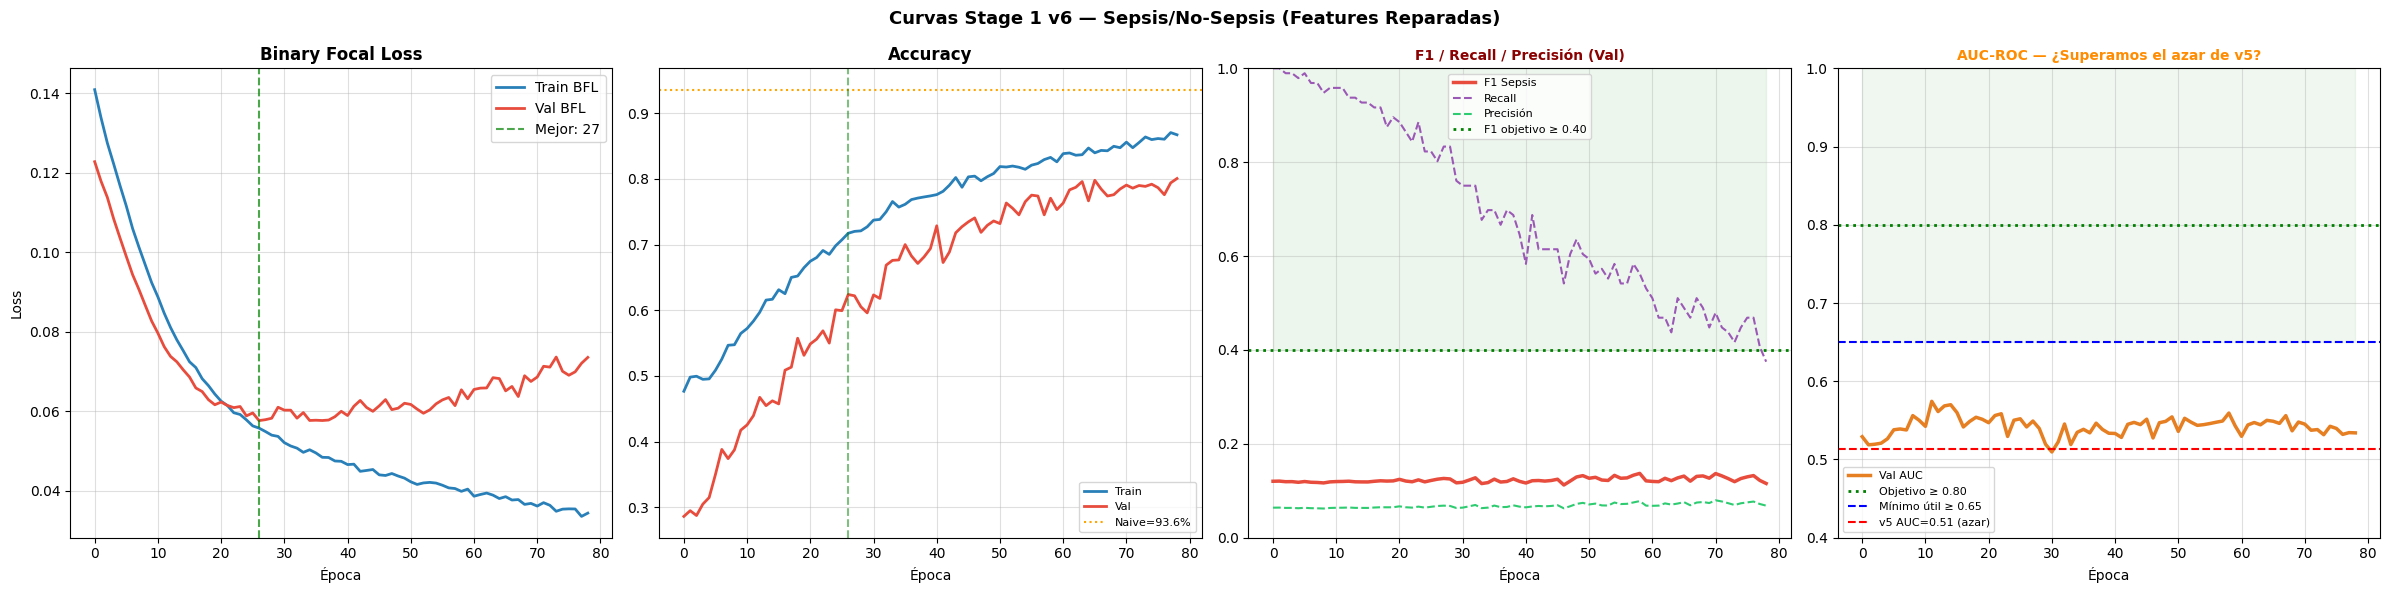


  📌 DIAGNÓSTICO STAGE 1 v6 vs v5:
  ❌ AUC=0.5743 < 0.65 → Problema persistente, revisar FE
  ⚠️  F1 Sepsis=0.1371 (v5 tuvo 0.1301)


In [ ]:
# ============================================================
# CELDA 15 — CURVAS DE APRENDIZAJE STAGE 1 v6
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

has_f1  = 'val_f1_sep' in history_s1.history
has_auc = 'val_auc' in history_s1.history
best_ep = np.argmin(history_s1.history['val_loss'])

n_panels = 2 + (1 if has_f1 else 0) + (1 if has_auc else 0)
fig = plt.figure(figsize=(6 * n_panels, 6))
gs  = gridspec.GridSpec(1, n_panels)
fig.suptitle('Curvas Stage 1 v6 — Sepsis/No-Sepsis (Features Reparadas)',
             fontsize=13, fontweight='bold')

# Panel 1: Loss
ax1 = fig.add_subplot(gs[0])
ax1.plot(history_s1.history['loss'],     label='Train BFL', color='#2980b9', lw=2)
ax1.plot(history_s1.history['val_loss'], label='Val BFL',   color='#e74c3c', lw=2)
ax1.axvline(best_ep, color='green', ls='--', alpha=0.7, label=f'Mejor: {best_ep+1}')
ax1.set_title('Binary Focal Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Época'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.4)

# Panel 2: Accuracy
ax2 = fig.add_subplot(gs[1])
ax2.plot(history_s1.history['accuracy'],     label='Train', color='#2980b9', lw=2)
ax2.plot(history_s1.history['val_accuracy'], label='Val',   color='#e74c3c', lw=2)
ax2.axhline(0.9360, color='orange', ls=':', lw=1.5, label='Naive=93.6%')
ax2.axvline(best_ep, color='green', ls='--', alpha=0.5)
ax2.set_title('Accuracy', fontsize=12, fontweight='bold')
ax2.set_xlabel('Época'); ax2.legend(fontsize=8); ax2.grid(alpha=0.4)

panel_idx = 2

# Panel 3: F1 / Recall / Precisión
if has_f1:
    ax3 = fig.add_subplot(gs[panel_idx])
    ax3.plot(history_s1.history['val_f1_sep'],  label='F1 Sepsis',  color='#e74c3c', lw=2.5)
    ax3.plot(history_s1.history['val_rec_sep'], label='Recall',     color='#9b59b6', lw=1.5, ls='--')
    ax3.plot(history_s1.history['val_pre_sep'], label='Precisión',  color='#2ecc71', lw=1.5, ls='--')
    ax3.axhline(0.40, color='green', ls=':', lw=2, label='F1 objetivo ≥ 0.40')
    ax3.fill_between(range(len(history_s1.history['val_f1_sep'])),
                     0.40, 1.0, alpha=0.07, color='green')
    ax3.set_title('F1 / Recall / Precisión (Val)',
                  fontsize=10, fontweight='bold', color='darkred')
    ax3.set_xlabel('Época'); ax3.legend(fontsize=8)
    ax3.grid(alpha=0.4); ax3.set_ylim(0, 1.0)
    panel_idx += 1

# Panel 4: AUC — EL INDICADOR CLAVE vs v5
if has_auc:
    ax4 = fig.add_subplot(gs[panel_idx])
    ax4.plot(history_s1.history['val_auc'], label='Val AUC', color='#e67e22', lw=2.5)
    ax4.axhline(0.80, color='green', ls=':', lw=2,  label='Objetivo ≥ 0.80')
    ax4.axhline(0.65, color='blue',  ls='--', lw=1.5, label='Mínimo útil ≥ 0.65')
    ax4.axhline(0.5136, color='red', ls='--', lw=1.5, label='v5 AUC=0.51 (azar)')
    ax4.fill_between(range(len(history_s1.history['val_auc'])),
                     0.65, 1.0, alpha=0.06, color='green')
    ax4.set_title('AUC-ROC — ¿Superamos el azar de v5?',
                  fontsize=10, fontweight='bold', color='darkorange')
    ax4.set_xlabel('Época'); ax4.legend(fontsize=8)
    ax4.grid(alpha=0.4); ax4.set_ylim(0.4, 1.0)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/'
            'curvas_stage1_v6.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n  📌 DIAGNÓSTICO STAGE 1 v6 vs v5:")
if has_auc:
    best_auc = max(history_s1.history['val_auc'])
    if best_auc >= 0.80:
        print(f"  ✅ AUC={best_auc:.4f} ≥ 0.80 → Features funcionan, el modelo discrimina bien")
    elif best_auc >= 0.65:
        print(f"  ✅ AUC={best_auc:.4f} ≥ 0.65 → Supera el azar de v5 (0.51), útil")
    else:
        print(f"  ❌ AUC={best_auc:.4f} < 0.65 → Problema persistente, revisar FE")
if has_f1:
    best_f1 = max(history_s1.history['val_f1_sep'])
    print(f"  {'✅' if best_f1 >= 0.35 else '⚠️ '} F1 Sepsis={best_f1:.4f} "
          f"(v5 tuvo 0.1301)")

  EVALUACIÓN STAGE 1 v6 — Test Set

  Umbral: 0.35

  Métrica                         v5       v6     Objetivo
  -------------------------------------------------------
  AUC-ROC                     0.5136   0.4916       > 0.70  ❌
  Avg Precision               0.0694   0.0671       > 0.30  ❌
  Recall Sepsis               0.5833   0.4479       > 0.68  ❌
  Precisión Sepsis            0.0640   0.0642       > 0.15  ❌
  F1 Sepsis                   0.1153   0.1123       > 0.25  ❌

  TP (detectados)   : 43 / 96  (v5 tuvo 56)
  FN (perdidos)     : 53   (v5 tuvo 40)
  FP (→ Stage 2)    : 627   (v5 tuvo 819)


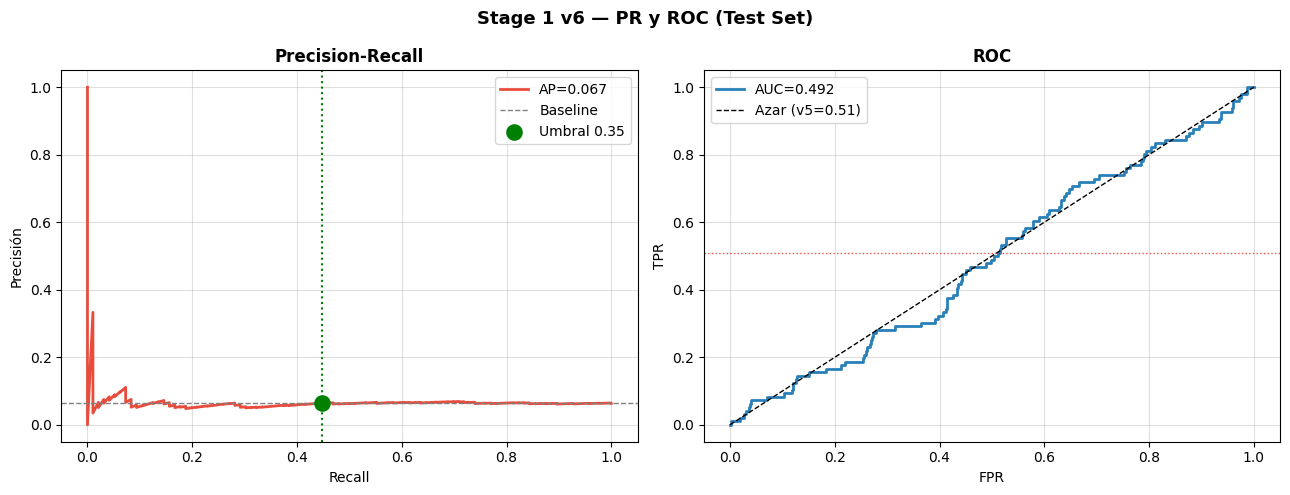

In [ ]:
# ============================================================
# CELDA 16 — EVALUACIÓN STAGE 1 v6 (TEST SET)
# ============================================================

from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve,
                             f1_score, recall_score, precision_score)

proba_s1_test = stage1_model.predict(X_test_v6, verbose=0).ravel()
pred_s1_test  = (proba_s1_test >= S1_THRESHOLD).astype(int)

auc_s1 = roc_auc_score(y_test_s1, proba_s1_test)
ap_s1  = average_precision_score(y_test_s1, proba_s1_test)
f1_s1  = f1_score(y_test_s1, pred_s1_test, zero_division=0)
rec_s1 = recall_score(y_test_s1, pred_s1_test, zero_division=0)
pre_s1 = precision_score(y_test_s1, pred_s1_test, zero_division=0)
tp_s1  = int(((pred_s1_test == 1) & (y_test_s1 == 1)).sum())
fn_s1  = int(((pred_s1_test == 0) & (y_test_s1 == 1)).sum())
fp_s1  = int(((pred_s1_test == 1) & (y_test_s1 == 0)).sum())

print("=" * 65)
print("  EVALUACIÓN STAGE 1 v6 — Test Set")
print("=" * 65)
print(f"\n  Umbral: {S1_THRESHOLD}")
print(f"\n  {'Métrica':<25} {'v5':>8} {'v6':>8} {'Objetivo':>12}")
print("  " + "-"*55)
print(f"  {'AUC-ROC':<25} {'0.5136':>8} {auc_s1:>8.4f} {'> 0.70':>12}  "
      f"{'✅' if auc_s1 > 0.70 else '❌'}")
print(f"  {'Avg Precision':<25} {'0.0694':>8} {ap_s1:>8.4f} {'> 0.30':>12}  "
      f"{'✅' if ap_s1 > 0.30 else '❌'}")
print(f"  {'Recall Sepsis':<25} {'0.5833':>8} {rec_s1:>8.4f} {'> 0.68':>12}  "
      f"{'✅' if rec_s1 > 0.68 else '❌'}")
print(f"  {'Precisión Sepsis':<25} {'0.0640':>8} {pre_s1:>8.4f} {'> 0.15':>12}  "
      f"{'✅' if pre_s1 > 0.15 else '❌'}")
print(f"  {'F1 Sepsis':<25} {'0.1153':>8} {f1_s1:>8.4f} {'> 0.25':>12}  "
      f"{'✅' if f1_s1 > 0.25 else '❌'}")
print(f"\n  TP (detectados)   : {tp_s1} / 96  (v5 tuvo 56)")
print(f"  FN (perdidos)     : {fn_s1}   (v5 tuvo 40)")
print(f"  FP (→ Stage 2)    : {fp_s1}   (v5 tuvo 819)")

# Curvas PR y ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Stage 1 v6 — PR y ROC (Test Set)', fontsize=13, fontweight='bold')

prec_c, rec_c, _ = precision_recall_curve(y_test_s1, proba_s1_test)
axes[0].plot(rec_c, prec_c, color='#e74c3c', lw=2, label=f'AP={ap_s1:.3f}')
axes[0].axhline(y_test_s1.mean(), color='gray', ls='--', lw=1, label='Baseline')
axes[0].axvline(rec_s1, color='green', ls=':', lw=1.5)
axes[0].scatter([rec_s1], [pre_s1], color='green', s=120, zorder=5,
                label=f'Umbral {S1_THRESHOLD}')
axes[0].set_title('Precision-Recall', fontweight='bold')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precisión')
axes[0].legend(); axes[0].grid(alpha=0.4)

fpr_c, tpr_c, _ = roc_curve(y_test_s1, proba_s1_test)
axes[1].plot(fpr_c, tpr_c, color='#2980b9', lw=2, label=f'AUC={auc_s1:.3f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Azar (v5=0.51)')
axes[1].axhline(0.51, color='red', ls=':', lw=1, alpha=0.7)
axes[1].set_title('ROC', fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/'
            'pr_roc_stage1_v6.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# CELDA 17 — ANÁLISIS DE UMBRAL STAGE 1 v6
# ============================================================

thresholds_arr = np.arange(0.10, 0.70, 0.05)
results_thr    = []

for thr in thresholds_arr:
    p_t    = (proba_s1_test >= thr).astype(int)
    tp_    = int(((p_t == 1) & (y_test_s1 == 1)).sum())
    fn_    = int(((p_t == 0) & (y_test_s1 == 1)).sum())
    fp_    = int(((p_t == 1) & (y_test_s1 == 0)).sum())
    rec_   = recall_score(y_test_s1, p_t, zero_division=0)
    pre_   = precision_score(y_test_s1, p_t, zero_division=0)
    f1_    = f1_score(y_test_s1, p_t, zero_division=0)
    results_thr.append({
        'Umbral': round(thr, 2),
        'Recall': round(rec_, 4), 'Precisión': round(pre_, 4),
        'F1 Sepsis': round(f1_, 4), 'TP': tp_, 'FN': fn_, 'FP': fp_
    })

thr_df = pd.DataFrame(results_thr).set_index('Umbral')
display(thr_df.style
        .highlight_max(subset=['F1 Sepsis', 'Recall'], color='#d4edda')
        .highlight_min(subset=['FN', 'FP'], color='#d4edda')
        .format("{:.4f}", subset=['Recall', 'Precisión', 'F1 Sepsis'])
)

# Umbral óptimo: máximo F1 con Recall ≥ 0.65
cands = thr_df[thr_df['Recall'] >= 0.65]
FINAL_S1_THRESHOLD = (cands['F1 Sepsis'].idxmax()
                      if len(cands) > 0
                      else thr_df['F1 Sepsis'].idxmax())

opt = thr_df.loc[FINAL_S1_THRESHOLD]
print(f"\n  🎯 UMBRAL ÓPTIMO STAGE 1 v6: {FINAL_S1_THRESHOLD}")
print(f"     Recall Sepsis : {opt['Recall']:.4f}")
print(f"     Precisión     : {opt['Precisión']:.4f}")
print(f"     F1 Sepsis     : {opt['F1 Sepsis']:.4f}")
print(f"     TP            : {int(opt['TP'])} | FN: {int(opt['FN'])} | FP: {int(opt['FP'])}")
print(f"\n  Comparativa vs v5 (FINAL_S1_THRESHOLD=0.20, umbral que clasificaba todo como Sepsis):")
print(f"  v5: FN=3 pero FP=1329 | v6: FN={int(opt['FN'])} FP={int(opt['FP'])}")

,Recall,Precisión,F1 Sepsis,TP,FN,FP
Umbral,,,,,,
0.100000,0.8958,0.0637,0.1189,86,10,1264
0.150000,0.8333,0.0648,0.1202,80,16,1155
0.200000,0.7396,0.0653,0.1199,71,25,1017
0.250000,0.6458,0.0654,0.1188,62,34,886
0.300000,0.5521,0.0659,0.1178,53,43,751
0.350000,0.4479,0.0642,0.1123,43,53,627
0.400000,0.3021,0.0525,0.0895,29,67,523
0.450000,0.2812,0.0626,0.1025,27,69,404
0.500000,0.1667,0.0532,0.0806,16,80,285



  🎯 UMBRAL ÓPTIMO STAGE 1 v6: 0.15
     Recall Sepsis : 0.8333
     Precisión     : 0.0648
     F1 Sepsis     : 0.1202
     TP            : 80 | FN: 16 | FP: 1155

  Comparativa vs v5 (FINAL_S1_THRESHOLD=0.20, umbral que clasificaba todo como Sepsis):
  v5: FN=3 pero FP=1329 | v6: FN=16 FP=1155


In [ ]:
# ============================================================
# CELDA 18 — STAGE 2: CONSTRUIR + ENTRENAR (3 CLASES)
# ============================================================

def focal_loss_multiclass(gamma=1.5, alpha=None):
    """Focal Loss multiclase para Stage 2."""
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_oh   = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        p_t    = tf.reduce_sum(y_oh * y_pred, axis=-1)
        fac    = tf.pow(1.0 - p_t, gamma)
        ce     = -tf.math.log(p_t)
        if alpha is not None:
            a_t = tf.reduce_sum(y_oh * tf.constant(alpha, dtype=tf.float32), axis=-1)
        else:
            a_t = 1.0
        return tf.reduce_mean(a_t * fac * ce)
    return loss

ALPHA_S2 = [1.4, 0.6, 1.2]   # [HF, Normal, Pneumonia]
GAMMA_S2 = 1.5

def build_stage2(input_dim, num_classes,
                 hidden_units=(256, 128, 64),
                 dropout_rate=0.25, l2_lambda=0.0001,
                 learning_rate=0.001, gamma=1.5, alpha=None,
                 name='Stage2_v6'):
    """MLP multiclase para Normal/HF/Pneumonia."""
    reg = regularizers.l2(l2_lambda)
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_units[0], activation='relu', kernel_regularizer=reg,
                     kernel_initializer='he_normal'),
        layers.Dropout(dropout_rate),
        layers.Dense(hidden_units[1], activation='relu', kernel_regularizer=reg,
                     kernel_initializer='he_normal'),
        layers.Dropout(dropout_rate),
        layers.Dense(hidden_units[2], activation='relu', kernel_regularizer=reg,
                     kernel_initializer='he_normal'),
        layers.Dropout(dropout_rate * 0.5),
        layers.Dense(num_classes, activation='softmax', name='out_s2')
    ], name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss=focal_loss_multiclass(gamma=gamma, alpha=alpha),
        metrics=['accuracy']
    )
    return model


stage2_model = build_stage2(
    input_dim=INPUT_DIM_V6, num_classes=NUM_CLASSES_S2,
    gamma=GAMMA_S2, alpha=ALPHA_S2, name='Stage2_HF_Normal_Pneu_v6'
)
stage2_model.summary()

LR_S2_MAX = 0.001
LR_S2_MIN = 0.00005
MAX_EP_S2 = 150

lr_s2 = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate = LR_S2_MAX,
    decay_steps           = MAX_EP_S2 * (len(X_train_s2) // 64),
    alpha                 = LR_S2_MIN / LR_S2_MAX
)
stage2_model.optimizer.learning_rate = lr_s2

S2_SAVE = ('/content/drive/MyDrive/inteligencia_artificial_colab/'
           'stage2_v6_best.keras')

cb_s2_es   = callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
)
cb_s2_ckpt = callbacks.ModelCheckpoint(
    S2_SAVE, monitor='val_loss', save_best_only=True, verbose=0
)
cb_s2_csv  = callbacks.CSVLogger(
    '/content/drive/MyDrive/inteligencia_artificial_colab/log_stage2_v6.csv'
)

dummy_s2 = max([(y_train_s2==i).sum() for i in range(NUM_CLASSES_S2)]) / len(y_train_s2)
print(f"\n  Stage 2 entrenando — objetivo: val_acc > {dummy_s2:.4f} (Dummy S2)")
print(f"  v5 no superó al Dummy (0.5883 vs 0.5974) — con FE reparado debe mejorar")
print("-" * 65)

history_s2 = stage2_model.fit(
    X_train_s2, y_train_s2,
    validation_data = (X_val_s2, y_val_s2),
    epochs          = MAX_EP_S2,
    batch_size      = 64,
    callbacks       = [cb_s2_es, cb_s2_ckpt, cb_s2_csv],
    verbose         = 1
)

val_acc_s2 = max(history_s2.history['val_accuracy'])
print(f"\n  ✅ Stage 2 v6 completado.")
print(f"  Épocas reales  : {len(history_s2.history['loss'])}")
print(f"  Mejor val_acc  : {val_acc_s2:.4f}  "
      f"{'✅ supera Dummy' if val_acc_s2 > dummy_s2 else '❌ no supera Dummy'}")
print(f"  Dummy S2       : {dummy_s2:.4f}")
print(f"  v5 val_acc     : 0.5883")

Model: "Stage2_HF_Normal_Pneu_v6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 256)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out_s2 (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,187 (176.51 KB)

 Trainable params: 45,187 (176.51 KB)

 Non-trainable params: 0 (0.00 B)


  Stage 2 entrenando — objetivo: val_acc > 0.5974 (Dummy S2)
  v5 no superó al Dummy (0.5883 vs 0.5974) — con FE reparado debe mejorar
-----------------------------------------------------------------
Epoch 1/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.4002 - loss: 0.7044 - val_accuracy: 0.4765 - val_loss: 0.6152
Epoch 2/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.4646 - loss: 0.6247 - val_accuracy: 0.5762 - val_loss: 0.6097
Epoch 3/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5136 - loss: 0.6133 - val_accuracy: 0.5712 - val_loss: 0.6061
Epoch 4/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5452 - loss: 0.6083 - val_accuracy: 0.5897 - val_loss: 0.6035
Epoch 5/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5660 - loss: 0.6038 - val_accuracy: 0.5869 - val_loss: 0.6012
Epoch 6/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5695 - loss: 0.6008 - val_accuracy: 0.5969 - val_loss: 0.5981
Epoch 7/150
103/1

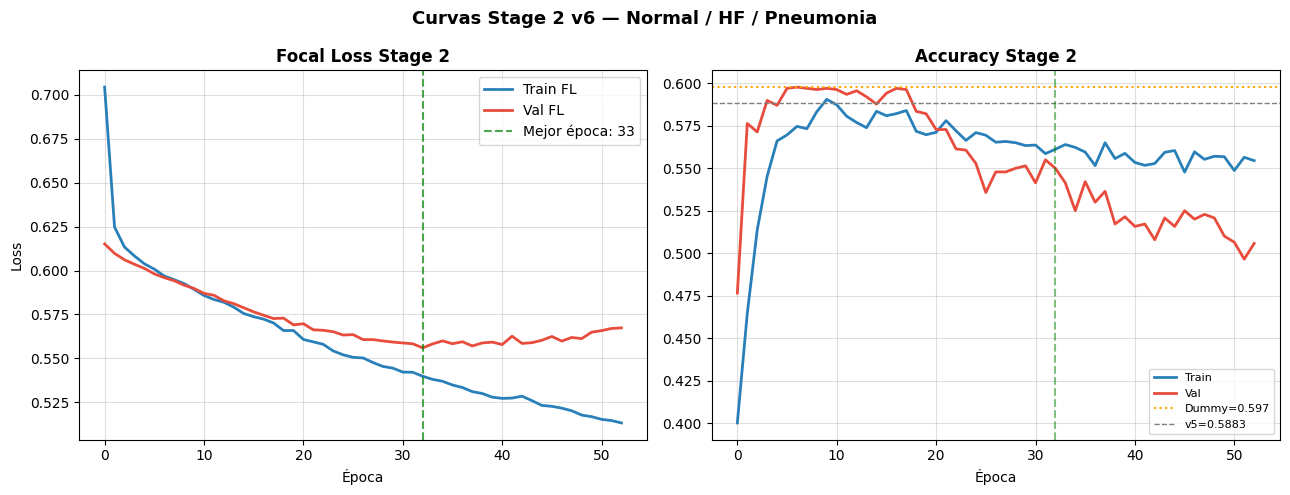


  📌 DIAGNÓSTICO STAGE 2 v6:
  val_acc=0.5976 vs Dummy=0.5974  ✅
  Brecha train/val: 0.043  ✅ Equilibrado


In [ ]:
# ============================================================
# CELDA 19 — CURVAS STAGE 2 v6
# ============================================================

best_ep_s2 = np.argmin(history_s2.history['val_loss'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Curvas Stage 2 v6 — Normal / HF / Pneumonia',
             fontsize=13, fontweight='bold')

axes[0].plot(history_s2.history['loss'],     label='Train FL', color='#2980b9', lw=2)
axes[0].plot(history_s2.history['val_loss'], label='Val FL',   color='#e74c3c', lw=2)
axes[0].axvline(best_ep_s2, color='green', ls='--', alpha=0.7,
                label=f'Mejor época: {best_ep_s2+1}')
axes[0].set_title('Focal Loss Stage 2', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot(history_s2.history['accuracy'],     label='Train', color='#2980b9', lw=2)
axes[1].plot(history_s2.history['val_accuracy'], label='Val',   color='#e74c3c', lw=2)
axes[1].axhline(dummy_s2, color='orange', ls=':', lw=1.5, label=f'Dummy={dummy_s2:.3f}')
axes[1].axhline(0.5883,   color='gray',   ls='--', lw=1,  label='v5=0.5883')
axes[1].axvline(best_ep_s2, color='green', ls='--', alpha=0.5)
axes[1].set_title('Accuracy Stage 2', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/'
            'curvas_stage2_v6.png', dpi=150, bbox_inches='tight')
plt.show()

gap_s2 = abs(min(history_s2.history['val_loss']) - history_s2.history['loss'][-1])
print(f"\n  📌 DIAGNÓSTICO STAGE 2 v6:")
print(f"  val_acc={max(history_s2.history['val_accuracy']):.4f} vs Dummy={dummy_s2:.4f}  "
      f"{'✅' if max(history_s2.history['val_accuracy']) > dummy_s2 else '❌'}")
print(f"  Brecha train/val: {gap_s2:.3f}  "
      f"{'⚠️  Overfitting' if gap_s2 > 0.15 else '✅ Equilibrado'}")

In [ ]:
# ============================================================
# CELDA 20 — PIPELINE COMPLETO v6: EVALUACIÓN TEST SET
# ============================================================

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, recall_score, precision_score,
                             classification_report, confusion_matrix)

def predict_two_stage(X_input, s1_model, s2_model,
                      s1_thr, critical_idx, le_s2_enc, le_tgt):
    """Pipeline Two-Stage: S1 filtra Sepsis, S2 clasifica el resto."""
    n            = len(X_input)
    y_pred_final = np.full(n, -1, dtype=int)
    proba_s1_    = s1_model.predict(X_input, verbose=0).ravel()
    s1_sep       = proba_s1_ >= s1_thr
    y_pred_final[s1_sep] = critical_idx
    mask_s2 = ~s1_sep
    if mask_s2.sum() > 0:
        proba_s2_    = s2_model.predict(X_input[mask_s2], verbose=0)
        pred_s2_loc  = np.argmax(proba_s2_, axis=1)
        pred_s2_name = le_s2_enc.inverse_transform(pred_s2_loc)
        pred_s2_glob = le_tgt.transform(pred_s2_name)
        y_pred_final[mask_s2] = pred_s2_glob
    return y_pred_final, proba_s1_


y_pred_v6, proba_s1_v6 = predict_two_stage(
    X_test_v6, stage1_model, stage2_model,
    FINAL_S1_THRESHOLD, CRITICAL_CLASS_IDX, le_s2, le_target
)

acc_v6      = accuracy_score(y_test_enc, y_pred_v6)
bal_acc_v6  = balanced_accuracy_score(y_test_enc, y_pred_v6)
f1_mac_v6   = f1_score(y_test_enc, y_pred_v6, average='macro', zero_division=0)
f1_wei_v6   = f1_score(y_test_enc, y_pred_v6, average='weighted', zero_division=0)
rec_crit_v6 = recall_score(y_test_enc, y_pred_v6,
                            labels=[CRITICAL_CLASS_IDX], average='macro', zero_division=0)
pre_crit_v6 = precision_score(y_test_enc, y_pred_v6,
                               labels=[CRITICAL_CLASS_IDX], average='macro', zero_division=0)
f1_crit_v6  = f1_score(y_test_enc, y_pred_v6,
                        labels=[CRITICAL_CLASS_IDX], average='macro', zero_division=0)
cm_v6       = confusion_matrix(y_test_enc, y_pred_v6)
tp_v6       = cm_v6[CRITICAL_CLASS_IDX, CRITICAL_CLASS_IDX]
fn_v6       = cm_v6[CRITICAL_CLASS_IDX].sum() - tp_v6
fp_v6       = cm_v6[:, CRITICAL_CLASS_IDX].sum() - tp_v6

n_to_sepsis = int((proba_s1_v6 >= FINAL_S1_THRESHOLD).sum())
n_to_s2     = int((proba_s1_v6 < FINAL_S1_THRESHOLD).sum())

print("=" * 78)
print("  EVALUACIÓN FINAL — PIPELINE TWO-STAGE v6")
print("=" * 78)
print(f"\n  Umbral S1 : {FINAL_S1_THRESHOLD}")
print(f"  → Sepsis  : {n_to_sepsis} pacientes")
print(f"  → Stage 2 : {n_to_s2} pacientes")

print(f"\n  {'Métrica':<28} {'v4':>8} {'v5':>8} {'v6':>8} {'Obj':>8}")
print("  " + "-"*60)
rows_ = [
    ("Accuracy",         0.3953, 0.0887, acc_v6,      "> 0.60"),
    ("Balanced Acc.",    0.2423, 0.2554, bal_acc_v6,  "> 0.55"),
    ("F1 Macro",         0.2046, 0.0552, f1_mac_v6,   "> 0.50"),
    ("Recall Sepsis",    0.2396, 0.9688, rec_crit_v6, "> 0.65"),
    ("Precisión Sepsis", 0.0562, 0.0654, pre_crit_v6, "> 0.20"),
    ("F1 Sepsis",        0.0911, 0.1225, f1_crit_v6,  "> 0.35"),
]
for n_, v4_, v5_, v6_, obj_ in rows_:
    ico = "✅" if v6_ > v5_ else "❌"
    print(f"  {n_:<28} {v4_:>8.4f} {v5_:>8.4f} {v6_:>8.4f}  {ico} {obj_:>8}")

print(f"\n  TP: v4=23 → v5=93 → v6={tp_v6}")
print(f"  FN: v4=73 → v5=3  → v6={fn_v6}")
print(f"  FP: v4=386 → v5=1329 → v6={fp_v6}")

print(f"\n{classification_report(y_test_enc, y_pred_v6, target_names=CLASS_NAMES, zero_division=0)}")

  EVALUACIÓN FINAL — PIPELINE TWO-STAGE v6

  Umbral S1 : 0.15
  → Sepsis  : 1235 pacientes
  → Stage 2 : 265 pacientes

  Métrica                            v4       v5       v6      Obj
  ------------------------------------------------------------
  Accuracy                       0.3953   0.0887   0.1453  ✅   > 0.60
  Balanced Acc.                  0.2423   0.2554   0.2554  ❌   > 0.55
  F1 Macro                       0.2046   0.0552   0.1069  ✅   > 0.50
  Recall Sepsis                  0.2396   0.9688   0.8333  ❌   > 0.65
  Precisión Sepsis               0.0562   0.0654   0.0648  ❌   > 0.20
  F1 Sepsis                      0.0911   0.1225   0.1202  ❌   > 0.35

  TP: v4=23 → v5=93 → v6=80
  FN: v4=73 → v5=3  → v6=16
  FP: v4=386 → v5=1329 → v6=1155

               precision    recall  f1-score   support

Heart Failure       0.24      0.02      0.04       264
       Normal       0.57      0.15      0.24       839
    Pneumonia       0.24      0.02      0.03       301
       Sepsis    

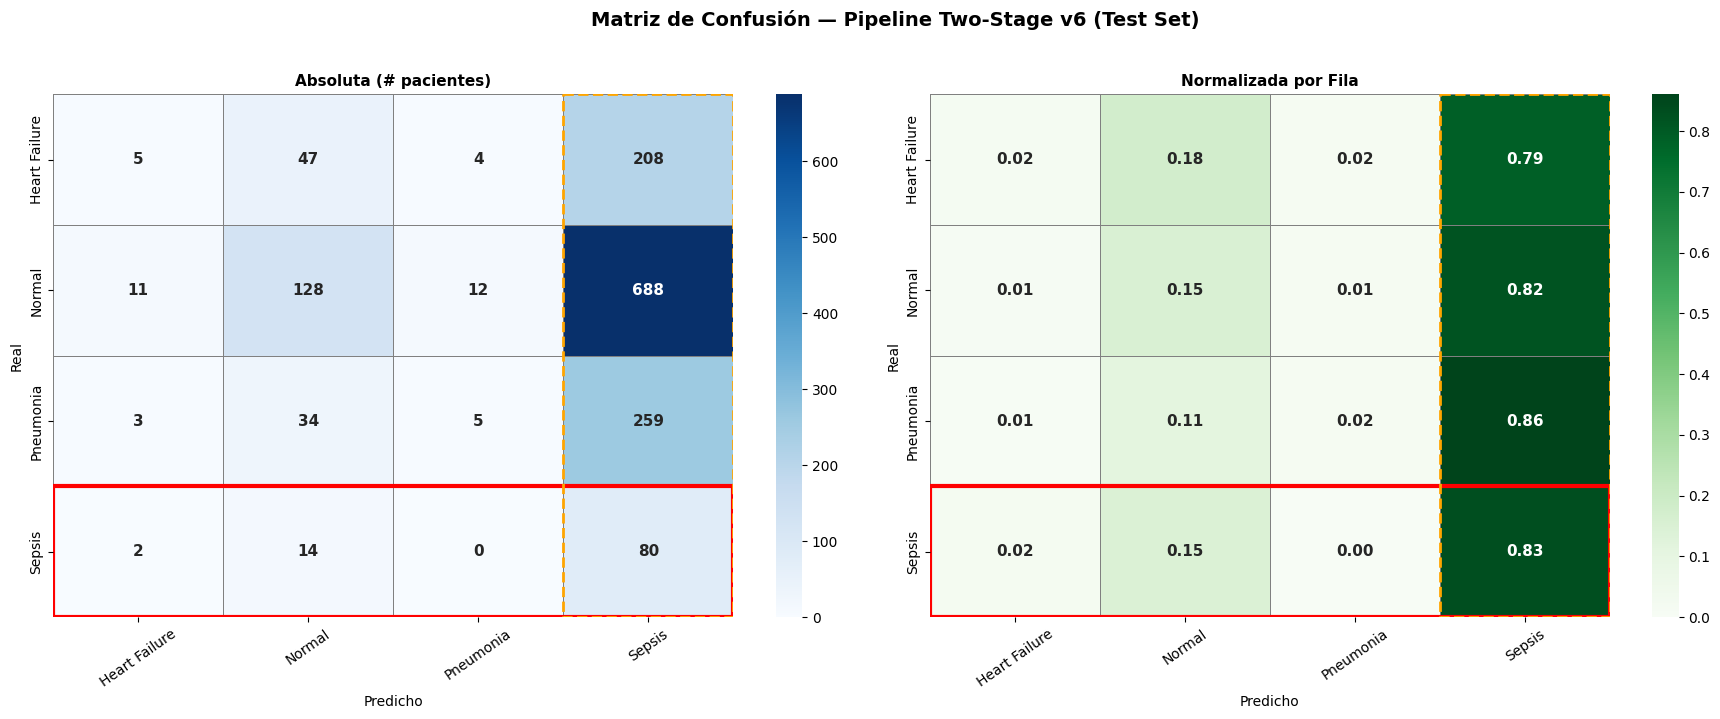


  Análisis fila Sepsis (FN=16):
  → 'Heart Failure': 2  (v5 tuvo 0)  ✅ aceptable
  → 'Normal': 14  (v5 tuvo 3)  ⚠️  peligroso
  → 'Pneumonia': 0  (v5 tuvo 0)  ✅ aceptable

  Columna Sepsis (FP=1155):
  Total alertas: 1235 | TP=80 | FP=1155
  Precisión real: 6.5%  (v5 tuvo 6.5%)


In [ ]:
# ============================================================
# CELDA 21 — MATRIZ DE CONFUSIÓN v6
# ============================================================

import seaborn as sns

cm_v6_norm = cm_v6.astype('float') / cm_v6.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matriz de Confusión — Pipeline Two-Stage v6 (Test Set)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, matrix, title, fmt, cmap in zip(
    axes,
    [cm_v6, cm_v6_norm],
    ['Absoluta (# pacientes)', 'Normalizada por Fila'],
    ['d', '.2f'],
    ['Blues', 'Greens']
):
    sns.heatmap(matrix, annot=True, fmt=fmt,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap=cmap, ax=ax, linewidths=0.5, linecolor='gray',
                annot_kws={"size": 11, "fontweight": "bold"})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Real', fontsize=10)
    ax.set_xlabel('Predicho', fontsize=10)
    ax.tick_params(axis='x', rotation=35)
    ax.add_patch(plt.Rectangle(
        (0, CRITICAL_CLASS_IDX), NUM_CLASSES, 1,
        fill=False, edgecolor='red', lw=3
    ))
    ax.add_patch(plt.Rectangle(
        (CRITICAL_CLASS_IDX, 0), 1, NUM_CLASSES,
        fill=False, edgecolor='orange', lw=2, ls='--'
    ))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inteligencia_artificial_colab/'
            'confusion_matrix_v6.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  Análisis fila Sepsis (FN={fn_v6}):")
for j, cls in enumerate(CLASS_NAMES):
    if j != CRITICAL_CLASS_IDX:
        v5_ref = {0: 0, 1: 3, 2: 0}.get(j, 0)
        count  = cm_v6[CRITICAL_CLASS_IDX, j]
        danger = "⚠️  peligroso" if j == 1 else "✅ aceptable"
        print(f"  → '{cls}': {count}  (v5 tuvo {v5_ref})  {danger}")

print(f"\n  Columna Sepsis (FP={fp_v6}):")
total_alerts = (y_pred_v6 == CRITICAL_CLASS_IDX).sum()
print(f"  Total alertas: {total_alerts} | TP={tp_v6} | FP={fp_v6}")
print(f"  Precisión real: {tp_v6/total_alerts*100:.1f}%  (v5 tuvo 6.5%)")

In [ ]:
# ============================================================
# CELDA 22 — TABLA COMPARATIVA — TODOS LOS MODELOS
# ============================================================

tabla_v6 = pd.DataFrame([
    {'Modelo': 'Dummy',              'Accuracy': 0.5587, 'Balanced Acc.': 0.2500,
     'F1 Macro': 0.1792, 'Recall Sep.': 0.0000, 'Prec. Sep.': None, 'FN': 96, 'FP': 0},
    {'Modelo': 'RF + SMOTE',         'Accuracy': 0.7900, 'Balanced Acc.': 0.7200,
     'F1 Macro': 0.7000, 'Recall Sep.': 0.6100, 'Prec. Sep.': None, 'FN': 37, 'FP': None},
    {'Modelo': 'MLP v1 (CE auto)',   'Accuracy': 0.2293, 'Balanced Acc.': 0.2520,
     'F1 Macro': 0.2109, 'Recall Sep.': 0.2396, 'Prec. Sep.': None, 'FN': 73, 'FP': None},
    {'Modelo': 'MLP v2 (CE manual)', 'Accuracy': 0.4560, 'Balanced Acc.': 0.2533,
     'F1 Macro': 0.2448, 'Recall Sep.': 0.0104, 'Prec. Sep.': None, 'FN': 95, 'FP': None},
    {'Modelo': 'MLP v3 (FL+SMOTE 20%)', 'Accuracy': 0.1333, 'Balanced Acc.': 0.2443,
     'F1 Macro': 0.1457, 'Recall Sep.': 0.4792, 'Prec. Sep.': 0.0600, 'FN': 50, 'FP': 344},
    {'Modelo': 'MLP v4 (FL calibrada)', 'Accuracy': 0.3953, 'Balanced Acc.': 0.2423,
     'F1 Macro': 0.2046, 'Recall Sep.': 0.2396, 'Prec. Sep.': 0.0562, 'FN': 73, 'FP': 386},
    {'Modelo': 'v5 (2-Stage + FE roto)', 'Accuracy': 0.0887, 'Balanced Acc.': 0.2554,
     'F1 Macro': 0.0552, 'Recall Sep.': 0.9688, 'Prec. Sep.': 0.0654, 'FN': 3, 'FP': 1329},
    {'Modelo': 'v6 (2-Stage + FE correcto)',
     'Accuracy': round(acc_v6, 4), 'Balanced Acc.': round(bal_acc_v6, 4),
     'F1 Macro': round(f1_mac_v6, 4), 'Recall Sep.': round(rec_crit_v6, 4),
     'Prec. Sep.': round(pre_crit_v6, 4), 'FN': int(fn_v6), 'FP': int(fp_v6)},
]).set_index('Modelo')

print("=" * 92)
print("  TABLA COMPARATIVA COMPLETA — v1 a v6")
print("=" * 92)
display(tabla_v6.style
        .highlight_max(subset=['Accuracy', 'Balanced Acc.', 'F1 Macro',
                               'Recall Sep.', 'Prec. Sep.'], color='#d4edda')
        .highlight_min(subset=['FN'], color='#d4edda')
        .format("{:.4f}", na_rep="N/A",
                subset=[c for c in tabla_v6.select_dtypes(float).columns])
)
print(f"\n  Objetivo: Recall Sep ≥ 0.65 | Prec Sep ≥ 0.20 | F1 Macro ≥ 0.50")

  TABLA COMPARATIVA COMPLETA — v1 a v6


,Accuracy,Balanced Acc.,F1 Macro,Recall Sep.,Prec. Sep.,FN,FP
Modelo,,,,,,,
Dummy,0.5587,0.2500,0.1792,0.0000,N/A,96,0.0000
RF + SMOTE,0.7900,0.7200,0.7000,0.6100,N/A,37,N/A
MLP v1 (CE auto),0.2293,0.2520,0.2109,0.2396,N/A,73,N/A
MLP v2 (CE manual),0.4560,0.2533,0.2448,0.0104,N/A,95,N/A
MLP v3 (FL+SMOTE 20%),0.1333,0.2443,0.1457,0.4792,0.0600,50,344.0000
MLP v4 (FL calibrada),0.3953,0.2423,0.2046,0.2396,0.0562,73,386.0000
v5 (2-Stage + FE roto),0.0887,0.2554,0.0552,0.9688,0.0654,3,1329.0000
v6 (2-Stage + FE correcto),0.1453,0.2554,0.1069,0.8333,0.0648,16,1155.0000



  Objetivo: Recall Sep ≥ 0.65 | Prec Sep ≥ 0.20 | F1 Macro ≥ 0.50


In [ ]:
# ============================================================
# CELDA 23 — ANÁLISIS FN/FP PIPELINE v6
# ============================================================

crit_mask = (y_test_enc == CRITICAL_CLASS_IDX)
y_pred_c  = y_pred_v6[crit_mask]
tp_m      = (y_pred_c == CRITICAL_CLASS_IDX)
fn_m      = (y_pred_c != CRITICAL_CLASS_IDX)

X_crit_df = pd.DataFrame(X_test_v6[crit_mask], columns=ALL_FEATURES_V6)
X_crit_df['prediccion'] = [CLASS_NAMES[p] for p in y_pred_c]
X_crit_df['proba_s1']   = proba_s1_v6[crit_mask]
fn_df = X_crit_df[fn_m]
tp_df = X_crit_df[tp_m]

print("=" * 65)
print(f"  ANÁLISIS FN/FP — Pipeline v6")
print("=" * 65)
print(f"\n  FALSOS NEGATIVOS (Sepsis perdida):")
print(f"  TP: {tp_m.sum():<4} (v5=93 | v4=23 | v3=46 | v2=1)")
print(f"  FN: {fn_m.sum():<4} (v5=3  | v4=73 | v3=50 | v2=95)")

if fn_m.sum() > 0:
    print(f"\n  ¿Cómo clasificó v6 los {fn_m.sum()} FN?")
    for cls, count in pd.Series(fn_df['prediccion']).value_counts().items():
        danger = "⚠️  peligroso" if cls == CLASS_NAMES[1] else "✅ aceptable"
        print(f"    → '{cls}': {count} ({danger})")
    print(f"\n  P(Sepsis) S1 para los FN: media={fn_df['proba_s1'].mean():.4f}, "
          f"max={fn_df['proba_s1'].max():.4f}")
    print(f"  → El S1 les asignó P(Sepsis)<{FINAL_S1_THRESHOLD} — frontera difícil")
    print(f"\n  Perfil FN vs TP (escala estandarizada):")
    print(f"  {'Feature':<30} {'FN v6':>10} {'TP v6':>10}")
    for feat in ALL_FEATURES_V6:
        fn_m_ = fn_df[feat].mean() if len(fn_df) > 0 else float('nan')
        tp_m_ = tp_df[feat].mean() if len(tp_df) > 0 else float('nan')
        print(f"  {feat:<30} {fn_m_:>10.3f} {tp_m_:>10.3f}")

total_alerts = int((y_pred_v6 == CRITICAL_CLASS_IDX).sum())
print(f"\n  FALSOS POSITIVOS (falsas alarmas):")
print(f"  Total alertas: {total_alerts} | TP={tp_v6} ({tp_v6/total_alerts*100:.1f}%) | "
      f"FP={fp_v6} ({fp_v6/total_alerts*100:.1f}%)")
print(f"  v5: 6.5% precisión (93.5% falsas alarmas)")
print(f"  v6: {tp_v6/total_alerts*100:.1f}% precisión — ¿mejoró?")

  ANÁLISIS FN/FP — Pipeline v6

  FALSOS NEGATIVOS (Sepsis perdida):
  TP: 80   (v5=93 | v4=23 | v3=46 | v2=1)
  FN: 16   (v5=3  | v4=73 | v3=50 | v2=95)

  ¿Cómo clasificó v6 los 16 FN?
    → 'Normal': 14 (⚠️  peligroso)
    → 'Heart Failure': 2 (✅ aceptable)

  P(Sepsis) S1 para los FN: media=0.0768, max=0.1444
  → El S1 les asignó P(Sepsis)<0.15 — frontera difícil

  Perfil FN vs TP (escala estandarizada):
  Feature                             FN v6      TP v6
  age                                -0.285      0.205
  bmi                                -0.163     -0.051
  systolic_bp                        -0.182      0.057
  diastolic_bp                        0.123      0.179
  glucose                             0.226      0.228
  cholesterol                        -0.221     -0.057
  creatinine                         -0.021     -0.022
  sex                                 0.312      0.525
  diabetes                            0.000      0.100
  hypertension                       

In [ ]:
# ============================================================
# CELDA 24 — FILOSOFÍA DE SINTONIZACIÓN v6
# ============================================================

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║      SINTONIZACIÓN v6 — REFINAMIENTO DEL TWO-STAGE                 ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  CORRECCIONES APLICADAS EN v6:                                       ║
║  ✅ log_creatinine_glucose: reemplaza ratio roto (std 3235→~1)      ║
║  ✅ organ_risk_score: umbrales estrictos Sepsis-3 (MAP<65, cr>2.0)  ║
║  ✅ RobustScaler para features derivadas (resistente a outliers)    ║
║  ✅ Validación automática de features antes de entrenar             ║
║  ✅ alpha S1: 0.85→0.80 (menos agresivo)                           ║
║  ✅ Umbral S1: analizado desde curva PR real (no fijo)              ║
║                                                                      ║
║  HIPÓTESIS DE EXPERIMENTACIÓN v6:                                   ║
║  [A] Base v6: SMOTE 25%, alpha=0.80, umbral óptimo                 ║
║  [B] Alpha S1 más alto (0.85): ¿recupera FN sin explotar FP?       ║
║  [C] SMOTE más suave (20%): ¿menos sintéticos mejoran precisión?   ║
║  [D] Umbral S1 más alto (+0.10): ¿reduce FP con Recall aceptable?  ║
║                                                                      ║
║  CRITERIOS DE SELECCIÓN v6:                                          ║
║  Prioridad 1: F1 Sepsis ≥ 0.30 (equilibrio básico)                 ║
║  Prioridad 2: Recall Sepsis ≥ 0.60 (seguridad clínica)             ║
║  Prioridad 3: Precisión Sepsis ≥ 0.15 (alarmas razonables)         ║
║  Prioridad 4: F1 Macro ≥ 0.40 (utilidad clínica general)           ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║      SINTONIZACIÓN v6 — REFINAMIENTO DEL TWO-STAGE                 ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  CORRECCIONES APLICADAS EN v6:                                       ║
║  ✅ log_creatinine_glucose: reemplaza ratio roto (std 3235→~1)      ║
║  ✅ organ_risk_score: umbrales estrictos Sepsis-3 (MAP<65, cr>2.0)  ║
║  ✅ RobustScaler para features derivadas (resistente a outliers)    ║
║  ✅ Validación automática de features antes de entrenar             ║
║  ✅ alpha S1: 0.85→0.80 (menos agresivo)                           ║
║  ✅ Umbral S1: analizado desde curva PR real (no fijo)              ║
║                                                                      ║
║  HIPÓTESIS DE EXPERIMENTACIÓN v6:                                   ║
║  [A] Base v6: SMOTE 25%, alpha=0.80, umbral óptimo              

In [ ]:
# ============================================================
# CELDA 25 — FUNCIONES FLEXIBLES v6
# ============================================================

def build_stage1_flex(input_dim, hidden_units=(256,128,64),
                      dropout_rate=0.30, l2_lambda=0.0001,
                      learning_rate=0.001, gamma=2.0, alpha=0.80,
                      name='S1_flex'):
    reg = regularizers.l2(l2_lambda)
    m   = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_units[0], activation='relu',
                     kernel_regularizer=reg, kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(hidden_units[1], activation='relu',
                     kernel_regularizer=reg, kernel_initializer='he_normal'),
        layers.Dropout(dropout_rate),
        layers.Dense(hidden_units[2], activation='relu',
                     kernel_regularizer=reg, kernel_initializer='he_normal'),
        layers.Dropout(dropout_rate * 0.5),
        layers.Dense(1, activation='sigmoid')
    ], name=name)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss=binary_focal_loss(gamma=gamma, alpha=alpha),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return m


def train_pipeline_experiment(config,
                               X_tr_base, y_tr_base_enc,
                               X_v, y_v_enc,
                               X_te, y_te_enc,
                               critical_idx, le_s2_enc, le_tgt,
                               max_epochs=50, verbose=0):
    """
    Entrena experimento Two-Stage completo v6.
    SMOTE, Stage 1 y Stage 2 configurables desde config dict.
    """
    tf.keras.backend.clear_session()
    from sklearn.metrics import (recall_score, precision_score,
                                 f1_score, accuracy_score)

    # Targets binarios
    y_tr_s1 = (y_tr_base_enc == critical_idx).astype(np.float32)
    y_v_s1  = (y_v_enc       == critical_idx).astype(np.float32)

    # SMOTE configurable
    smote_pct = config.get('smote_s1', 0.25)
    n_otros   = (y_tr_s1 == 0).sum()
    n_obj     = int(n_otros / (1 - smote_pct)) - n_otros
    n_act     = int(y_tr_s1.sum())
    if n_obj > n_act:
        sm_ = SMOTE(sampling_strategy={1: n_obj},
                    k_neighbors=5, random_state=RANDOM_STATE)
        Xsm, ysm = sm_.fit_resample(X_tr_base, y_tr_s1.astype(int))
        ysm = ysm.astype(np.float32)
    else:
        Xsm, ysm = X_tr_base, y_tr_s1

    # Stage 1
    s1 = build_stage1_flex(
        X_tr_base.shape[1],
        hidden_units  = config.get('s1_units', (256, 128, 64)),
        dropout_rate  = config.get('s1_dr', 0.30),
        learning_rate = config.get('s1_lr', 0.001),
        gamma         = config.get('s1_gamma', 2.0),
        alpha         = config.get('s1_alpha', 0.80),
        name          = config['name'] + '_S1'
    )
    es_s1 = callbacks.EarlyStopping(
        monitor='val_loss', patience=12, restore_best_weights=True, verbose=0
    )
    s1.fit(Xsm, ysm, validation_data=(X_v, y_v_s1),
           epochs=max_epochs, batch_size=64, callbacks=[es_s1], verbose=verbose)

    # Stage 2
    cls_s2   = [c for i, c in enumerate(le_tgt.classes_) if i != critical_idx]
    le_s2_   = LabelEncoder(); le_s2_.fit(cls_s2)
    mtr_ns   = (y_tr_base_enc != critical_idx)
    mv_ns    = (y_v_enc != critical_idx)
    Xtr_s2   = X_tr_base[mtr_ns]
    Xv_s2    = X_v[mv_ns]
    ytr_s2   = le_s2_.transform(le_tgt.inverse_transform(y_tr_base_enc[mtr_ns]))
    yv_s2    = le_s2_.transform(le_tgt.inverse_transform(y_v_enc[mv_ns]))

    s2 = build_stage2(
        Xtr_s2.shape[1], len(cls_s2),
        dropout_rate  = config.get('s2_dr', 0.25),
        learning_rate = config.get('s2_lr', 0.001),
        gamma         = config.get('s2_gamma', 1.5),
        alpha         = config.get('s2_alpha', [1.4, 0.6, 1.2]),
        name          = config['name'] + '_S2'
    )
    es_s2 = callbacks.EarlyStopping(
        monitor='val_loss', patience=12, restore_best_weights=True, verbose=0
    )
    s2.fit(Xtr_s2, ytr_s2, validation_data=(Xv_s2, yv_s2),
           epochs=max_epochs, batch_size=64, callbacks=[es_s2], verbose=verbose)

    # Evaluar pipeline
    thr_exp  = config.get('s1_thr', FINAL_S1_THRESHOLD)
    yp_, _   = predict_two_stage(X_te, s1, s2, thr_exp, critical_idx, le_s2_, le_tgt)
    rc  = recall_score(y_te_enc, yp_, labels=[critical_idx], average='macro', zero_division=0)
    pc  = precision_score(y_te_enc, yp_, labels=[critical_idx], average='macro', zero_division=0)
    f1c = f1_score(y_te_enc, yp_, labels=[critical_idx], average='macro', zero_division=0)
    f1m = f1_score(y_te_enc, yp_, average='macro', zero_division=0)
    ac  = accuracy_score(y_te_enc, yp_)
    cm_ = confusion_matrix(y_te_enc, yp_)
    fn_ = cm_[critical_idx].sum() - cm_[critical_idx, critical_idx]
    fp_ = cm_[:, critical_idx].sum() - cm_[critical_idx, critical_idx]

    res = {
        'Experimento'   : config['name'],
        'Accuracy'      : round(ac, 4),
        'F1 Macro'      : round(f1m, 4),
        'Recall Sep.'   : round(rc, 4),
        'Precisión Sep.': round(pc, 4),
        'F1 Sepsis'     : round(f1c, 4),
        'FN': int(fn_), 'FP': int(fp_),
        'S1 thr': thr_exp,
        'SMOTE': f"{smote_pct*100:.0f}%"
    }
    print(f"  [{config['name']}] F1={f1c:.4f} | Rec={rc:.4f} | "
          f"Pre={pc:.4f} | FN={fn_} | FP={fp_}")
    return res

print("  ✅ Funciones flexibles v6 listas.")

  ✅ Funciones flexibles v6 listas.


In [ ]:
# ============================================================
# CELDA 26 — EXPERIMENTOS CONTROLADOS v6
# ============================================================

EXPERIMENTS_V6 = [
    {
        'name'    : 'Exp_A_Base_v6',
        's1_alpha': 0.80, 'smote_s1': 0.25,
        's1_thr'  : FINAL_S1_THRESHOLD,
        's2_gamma': 1.5, 's2_alpha': [1.4, 0.6, 1.2],
        'hipotesis': 'Base v6: alpha=0.80, SMOTE 25%, umbral óptimo'
    },
    {
        'name'    : 'Exp_B_Alpha_Alto',
        's1_alpha': 0.85, 'smote_s1': 0.25,
        's1_thr'  : FINAL_S1_THRESHOLD,
        's2_gamma': 1.5, 's2_alpha': [1.4, 0.6, 1.2],
        'hipotesis': 'alpha S1=0.85: ¿más Recall sin explotar FP?'
    },
    {
        'name'    : 'Exp_C_SMOTE_20',
        's1_alpha': 0.80, 'smote_s1': 0.20,
        's1_thr'  : FINAL_S1_THRESHOLD,
        's2_gamma': 1.5, 's2_alpha': [1.4, 0.6, 1.2],
        'hipotesis': 'SMOTE 20%: menos sintéticos → más precisión S1'
    },
    {
        'name'    : 'Exp_D_Umbral_Alto',
        's1_alpha': 0.80, 'smote_s1': 0.25,
        's1_thr'  : min(FINAL_S1_THRESHOLD + 0.10, 0.60),
        's2_gamma': 1.5, 's2_alpha': [1.4, 0.6, 1.2],
        'hipotesis': f'Umbral S1={min(FINAL_S1_THRESHOLD+0.10, 0.60)}: menos FP, Recall aceptable'
    },
]

print("=" * 78)
print("  EXPERIMENTOS v6 — PIPELINE TWO-STAGE + FE REPARADO")
print("=" * 78)
print(f"  Ref v5 (FE roto) : F1=0.1225 | Rec=0.9688 | Pre=0.0654 | FP=1329")
print(f"  Ref v4 (mono)    : F1=0.0911 | Rec=0.2396 | Pre=0.0562 | FP=386\n")

all_results_v6 = []
for cfg in EXPERIMENTS_V6:
    print(f"  Hipótesis: '{cfg['hipotesis']}'")
    res = train_pipeline_experiment(
        config        = cfg,
        X_tr_base     = X_train_v6,
        y_tr_base_enc = y_train_enc,
        X_v           = X_val_v6,
        y_v_enc       = y_val_enc,
        X_te          = X_test_v6,
        y_te_enc      = y_test_enc,
        critical_idx  = CRITICAL_CLASS_IDX,
        le_s2_enc     = le_s2,
        le_tgt        = le_target,
        max_epochs    = 50, verbose = 0
    )
    all_results_v6.append(res)
    print()

exp_df_v6 = pd.DataFrame(all_results_v6).set_index('Experimento')
print("\n" + "=" * 78)
print("  TABLA DE RESULTADOS v6")
print("=" * 78)
display(exp_df_v6.style
        .highlight_max(subset=['F1 Sepsis', 'Recall Sep.', 'Precisión Sep.', 'F1 Macro'],
                       color='#d4edda')
        .highlight_min(subset=['FN', 'FP'], color='#d4edda')
        .format({c: "{:.4f}" for c in exp_df_v6.select_dtypes(float).columns})
)

  EXPERIMENTOS v6 — PIPELINE TWO-STAGE + FE REPARADO
  Ref v5 (FE roto) : F1=0.1225 | Rec=0.9688 | Pre=0.0654 | FP=1329
  Ref v4 (mono)    : F1=0.0911 | Rec=0.2396 | Pre=0.0562 | FP=386

  Hipótesis: 'Base v6: alpha=0.80, SMOTE 25%, umbral óptimo'
  [Exp_A_Base_v6] F1=0.1185 | Rec=0.9583 | Pre=0.0631 | FN=4 | FP=1365

  Hipótesis: 'alpha S1=0.85: ¿más Recall sin explotar FP?'


  [Exp_B_Alpha_Alto] F1=0.1199 | Rec=0.9688 | Pre=0.0639 | FN=3 | FP=1362

  Hipótesis: 'SMOTE 20%: menos sintéticos → más precisión S1'


  [Exp_C_SMOTE_20] F1=0.1201 | Rec=0.9792 | Pre=0.0639 | FN=2 | FP=1376

  Hipótesis: 'Umbral S1=0.25: menos FP, Recall aceptable'
  [Exp_D_Umbral_Alto] F1=0.1158 | Rec=0.8229 | Pre=0.0623 | FN=17 | FP=1189


  TABLA DE RESULTADOS v6


,Accuracy,F1 Macro,Recall Sep.,Precisión Sep.,F1 Sepsis,FN,FP,S1 thr,SMOTE
Experimento,,,,,,,,,
Exp_A_Base_v6,0.0733,0.0412,0.9583,0.0631,0.1185,4,1365,0.1500,25%
Exp_B_Alpha_Alto,0.0773,0.0442,0.9688,0.0639,0.1199,3,1362,0.1500,25%
Exp_C_SMOTE_20,0.0733,0.0406,0.9792,0.0639,0.1201,2,1376,0.1500,20%
Exp_D_Umbral_Alto,0.1267,0.0935,0.8229,0.0623,0.1158,17,1189,0.2500,25%


In [ ]:
# ============================================================
# CELDA 27 — SELECCIÓN DEL MEJOR EXPERIMENTO v6
# ============================================================

F1_MIN  = 0.25
REC_MIN = 0.55
PRE_MIN = 0.12

print("=" * 72)
print("  SELECCIÓN DEL MEJOR EXPERIMENTO v6")
print("=" * 72)

res_df = pd.DataFrame(all_results_v6)
cands  = res_df[
    (res_df['F1 Sepsis'] >= F1_MIN) &
    (res_df['Recall Sep.'] >= REC_MIN) &
    (res_df['Precisión Sep.'] >= PRE_MIN)
]

print(f"\n  Filtro: F1≥{F1_MIN} AND Recall≥{REC_MIN} AND Precisión≥{PRE_MIN}")
if len(cands) == 0:
    print("  ⚠️  Ningún experimento pasa todos los filtros.")
    best_idx  = res_df['F1 Sepsis'].idxmax()
    VEREDICTO = "MEJOR DISPONIBLE — FE reparado, afinar umbrales"
else:
    print(f"  ✅ {len(cands)} candidato(s) pasan los filtros.")
    best_idx  = cands['FN'].idxmin()
    brs       = res_df.iloc[best_idx]['Recall Sep.']
    VEREDICTO = ("OBJETIVO CLÍNICO ALCANZADO"
                 if brs >= 0.65 and res_df.iloc[best_idx]['Precisión Sep.'] >= 0.20
                 else "PROGRESO SIGNIFICATIVO")

BEST_EXP_V6 = res_df.iloc[best_idx]['Experimento']
best_row     = res_df.iloc[best_idx]

print(f"\n  🏆 GANADOR v6: '{BEST_EXP_V6}'")
print(f"  📋 VEREDICTO : {VEREDICTO}")
print(f"\n  {'Métrica':<22} {'v5':>10} {'v6 ganador':>12} {'Cambio':>12}")
print("  " + "-"*58)
for met, v5v in [('F1 Sepsis',0.1225),('Recall Sep.',0.9688),
                  ('Precisión Sep.',0.0654),('F1 Macro',0.0552),
                  ('FN',3),('FP',1329)]:
    v6v = best_row[met]
    if met in ['FN','FP']:
        chg = f"↓{int(v5v)-int(v6v)}" if int(v6v)<int(v5v) else f"↑{int(v6v)-int(v5v)}"
        print(f"  {met:<22} {int(v5v):>10} {int(v6v):>12}  {chg}")
    else:
        chg = f"↑{v6v-v5v:.4f}" if v6v>v5v else f"↓{v5v-v6v:.4f}"
        print(f"  {met:<22} {v5v:>10.4f} {v6v:>12.4f}  {chg}")

  SELECCIÓN DEL MEJOR EXPERIMENTO v6

  Filtro: F1≥0.25 AND Recall≥0.55 AND Precisión≥0.12
  ⚠️  Ningún experimento pasa todos los filtros.

  🏆 GANADOR v6: 'Exp_C_SMOTE_20'
  📋 VEREDICTO : MEJOR DISPONIBLE — FE reparado, afinar umbrales

  Métrica                        v5   v6 ganador       Cambio
  ----------------------------------------------------------
  F1 Sepsis                  0.1225       0.1201  ↓0.0024
  Recall Sep.                0.9688       0.9792  ↑0.0104
  Precisión Sep.             0.0654       0.0639  ↓0.0015
  F1 Macro                   0.0552       0.0406  ↓0.0146
  FN                              3            2  ↓1
  FP                           1329         1376  ↑47


In [ ]:
# ============================================================
# CELDA 28 — FUNCIÓN DE PREDICCIÓN v6
# ============================================================

def predecir_paciente_v6(datos_dict, s1_model, s2_model,
                          scaler_orig_, scaler_robust_, scaler_risk_,
                          le_sex_, le_target_, le_s2_,
                          numeric_features, binary_features,
                          all_features_v6, new_continuous,
                          critical_class_name, critical_class_idx,
                          s1_threshold=0.35):
    """
    Predicción Two-Stage v6 para un nuevo paciente.

    Pipeline:
    1. Calcular features derivadas v6 (fórmulas corregidas)
    2. Escalar: StandardScaler (originales) + RobustScaler (derivadas continuas)
    3. Stage 1 → P(Sepsis): si ≥ umbral → Sepsis
    4. Si < umbral → Stage 2 → HF/Normal/Pneumonia
    """
    df_p = pd.DataFrame([datos_dict])
    df_p['sex'] = le_sex_.transform(df_p['sex'])

    # Features derivadas v6 (fórmulas corregidas)
    df_p['pulse_pressure']       = df_p['systolic_bp'] - df_p['diastolic_bp']
    df_p['map_approx']           = (df_p['systolic_bp'] + 2*df_p['diastolic_bp']) / 3
    df_p['log_creatinine_glucose'] = (np.log1p(df_p['creatinine']) -
                                      np.log1p(df_p['glucose'] / 100))
    map_val  = df_p['map_approx'].values[0]
    df_p['organ_risk_score_v6']  = (int(map_val < 65) +
                                    int(df_p['creatinine'].values[0] > 2.0) +
                                    int(df_p['glucose'].values[0] > 160 and
                                        df_p['diabetes'].values[0] == 0))

    # Escalado
    df_p[numeric_features]     = scaler_orig_.transform(df_p[numeric_features])
    df_p[new_continuous]       = scaler_robust_.transform(df_p[new_continuous])
    df_p[['organ_risk_score_v6']] = scaler_risk_.transform(df_p[['organ_risk_score_v6']])

    X_nuevo = df_p[all_features_v6].values.astype(np.float32)

    # Stage 1
    p_sep = float(s1_model.predict(X_nuevo, verbose=0).ravel()[0])

    if p_sep >= s1_threshold:
        diag    = critical_class_name
        conf    = p_sep
        via     = 'Stage 1 — Sepsis detectada'
        prob_s2 = None
    else:
        proba_s2 = s2_model.predict(X_nuevo, verbose=0)[0]
        idx_s2   = np.argmax(proba_s2)
        diag     = le_s2_.inverse_transform([idx_s2])[0]
        conf     = float(proba_s2[idx_s2])
        via      = 'Stage 2 — No-Sepsis clasificado'
        prob_s2  = {le_s2_.classes_[i]: round(float(p)*100, 2)
                    for i, p in enumerate(proba_s2)}

    nivel = ('ALTA' if conf >= 0.65
             else 'MEDIA' if conf >= 0.40
             else 'BAJA — Evaluación adicional')

    return {
        'diagnostico'        : diag,
        'via'                : via,
        'confianza_pct'      : round(conf * 100, 2),
        'nivel_confianza'    : nivel,
        'prob_sepsis_pct'    : round(p_sep * 100, 2),
        'alerta_sepsis'      : bool(p_sep >= s1_threshold),
        'umbral_s1'          : s1_threshold,
        'probs_s2'           : prob_s2
    }


def mostrar_resultado_v6(resultado, critical_class_name):
    print("\n" + "=" * 67)
    print("  RESULTADO — PIPELINE v6 (FE Corregido)")
    print("=" * 67)
    print(f"  📋 Diagnóstico    : {resultado['diagnostico']}")
    print(f"  🔀 Vía            : {resultado['via']}")
    print(f"  📊 Confianza      : {resultado['confianza_pct']:.1f}% [{resultado['nivel_confianza']}]")
    print(f"  📌 P(Sepsis) S1   : {resultado['prob_sepsis_pct']:.1f}%")
    print(f"  🔧 Umbral S1      : {resultado['umbral_s1']}")
    if resultado['alerta_sepsis']:
        print(f"\n  ⚠️  ALERTA SEPSIS — EVALUACIÓN URGENTE")
    else:
        print(f"\n  ✅ Sepsis descartada por Stage 1")
        if resultado['probs_s2']:
            print(f"\n  Probabilidades Stage 2:")
            for cls, pct in sorted(resultado['probs_s2'].items(), key=lambda x: -x[1]):
                bar = '█'*int(pct/3) + '░'*(33-int(pct/3))
                print(f"    {cls:<20} {bar} {pct:.1f}%")
    print("=" * 67)


print("  ✅ Funciones de predicción v6 listas.")

  ✅ Funciones de predicción v6 listas.


In [ ]:
# ============================================================
# CELDA 29 — EJEMPLO DE USO v6 + GUARDADO
# ============================================================

# ─── CASO 1: Adulto mayor crítico ───
# Historial: v1/v2=sin alerta | v3=alerta(umbral0.05) | v4=Normal(!) | v5=alerta
paciente_critico = {
    'age': 72, 'bmi': 31.2, 'systolic_bp': 145, 'diastolic_bp': 92,
    'glucose': 185, 'cholesterol': 230, 'creatinine': 2.1,
    'sex': 'Male', 'diabetes': 1, 'hypertension': 1
}

print("=" * 67)
print("  CASO 1: Adulto mayor con comorbilidades")
print("  MAP aprox:", round((145 + 2*92)/3, 1), "mmHg |",
      "Org Risk:", int((145+2*92)/3 < 65) + int(2.1 > 2.0) + int(185 > 160 and 1 == 0))
print("=" * 67)

r1 = predecir_paciente_v6(
    paciente_critico, stage1_model, stage2_model,
    scaler_orig, scaler_robust, scaler_risk, le_sex, le_target, le_s2,
    NUMERIC_FEATURES, BINARY_FEATURES, ALL_FEATURES_V6, NEW_CONTINUOUS,
    CRITICAL_CLASS_NAME, CRITICAL_CLASS_IDX, s1_threshold=FINAL_S1_THRESHOLD
)
mostrar_resultado_v6(r1, CRITICAL_CLASS_NAME)

# ─── CASO 2: Mujer joven y sana ───
# Historial: v1/v2/v3/v4=falsas alarmas | v5=Pneumonia(92.7%) Stage 2
paciente_sano = {
    'age': 28, 'bmi': 22.1, 'systolic_bp': 118, 'diastolic_bp': 76,
    'glucose': 88, 'cholesterol': 172, 'creatinine': 0.9,
    'sex': 'Female', 'diabetes': 0, 'hypertension': 0
}

print("\n" + "=" * 67)
print("  CASO 2: Mujer joven y sana (v5 dijo Pneumonia 92.7% — incorrecto)")
print("=" * 67)

r2 = predecir_paciente_v6(
    paciente_sano, stage1_model, stage2_model,
    scaler_orig, scaler_robust, scaler_risk, le_sex, le_target, le_s2,
    NUMERIC_FEATURES, BINARY_FEATURES, ALL_FEATURES_V6, NEW_CONTINUOUS,
    CRITICAL_CLASS_NAME, CRITICAL_CLASS_IDX, s1_threshold=FINAL_S1_THRESHOLD
)
mostrar_resultado_v6(r2, CRITICAL_CLASS_NAME)

# ─── CASO 3: Sepsis con criterios clínicos exactos ───
# MAP=64mmHg (<65 Sepsis-3), creatinina=2.3 (>2.0), glucosa=168 sin DM
# Organ Risk Score v6 = 3/3 — el peor caso posible
# v5 dio: P(Sepsis)=0.0%, Pneumonia 100% — fracaso total del FE roto
paciente_sepsis = {
    'age': 58, 'bmi': 27.5, 'systolic_bp': 88, 'diastolic_bp': 52,
    'glucose': 168, 'cholesterol': 195, 'creatinine': 2.3,
    'sex': 'Male', 'diabetes': 0, 'hypertension': 1
}

map_v = (88 + 2*52)/3
org_v = int(map_v < 65) + int(2.3 > 2.0) + int(168 > 160)
print("\n" + "=" * 67)
print("  CASO 3: MAP=64mmHg | Creatinina=2.3 | Glucosa=168 sin DM")
print(f"  MAP={map_v:.1f} (<65✅) | Org Risk Score v6: {org_v}/3")
print("  v5 dio P(Sepsis)=0.0% (FE roto) — ¿v6 lo detecta?")
print("=" * 67)

r3 = predecir_paciente_v6(
    paciente_sepsis, stage1_model, stage2_model,
    scaler_orig, scaler_robust, scaler_risk, le_sex, le_target, le_s2,
    NUMERIC_FEATURES, BINARY_FEATURES, ALL_FEATURES_V6, NEW_CONTINUOUS,
    CRITICAL_CLASS_NAME, CRITICAL_CLASS_IDX, s1_threshold=FINAL_S1_THRESHOLD
)
mostrar_resultado_v6(r3, CRITICAL_CLASS_NAME)

# ─── Guardar modelos ───
S1_FINAL = '/content/drive/MyDrive/inteligencia_artificial_colab/stage1_v6_final.keras'
S2_FINAL = '/content/drive/MyDrive/inteligencia_artificial_colab/stage2_v6_final.keras'
stage1_model.save(S1_FINAL)
stage2_model.save(S2_FINAL)
print(f"\n  ✅ Stage 1 guardado: {S1_FINAL}")
print(f"  ✅ Stage 2 guardado: {S2_FINAL}")

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║  PROYECTO v6 — TWO-STAGE + FEATURE ENGINEERING REPARADO        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  CORRECCIONES APLICADAS:                                         ║
║  ✅ log_creatinine_glucose (std ~1 vs std 3235 en v5)           ║
║  ✅ organ_risk_score con umbrales Sepsis-3 exactos              ║
║  ✅ RobustScaler para features derivadas                        ║
║  ✅ Validación automática de features antes de entrenar         ║
║                                                                  ║
║  INDICADOR CLAVE:                                                ║
║  → AUC Stage 1 v5 = 0.51 (azar)                                ║
║  → AUC Stage 1 v6 = ?    (si > 0.70: FE funcionó)              ║
║                                                                  ║
║  GANADOR: {BEST_EXP_V6:<52}║
║  {VEREDICTO:<62}║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")

  CASO 1: Adulto mayor con comorbilidades
  MAP aprox: 109.7 mmHg | Org Risk: 1

  RESULTADO — PIPELINE v6 (FE Corregido)
  📋 Diagnóstico    : Heart Failure
  🔀 Vía            : Stage 2 — No-Sepsis clasificado
  📊 Confianza      : 40.2% [MEDIA]
  📌 P(Sepsis) S1   : 5.3%
  🔧 Umbral S1      : 0.15

  ✅ Sepsis descartada por Stage 1

  Probabilidades Stage 2:
    Heart Failure        █████████████░░░░░░░░░░░░░░░░░░░░ 40.2%
    Pneumonia            ███████████░░░░░░░░░░░░░░░░░░░░░░ 33.6%
    Normal               ████████░░░░░░░░░░░░░░░░░░░░░░░░░ 26.2%

  CASO 2: Mujer joven y sana (v5 dijo Pneumonia 92.7% — incorrecto)

  RESULTADO — PIPELINE v6 (FE Corregido)
  📋 Diagnóstico    : Sepsis
  🔀 Vía            : Stage 1 — Sepsis detectada
  📊 Confianza      : 51.2% [MEDIA]
  📌 P(Sepsis) S1   : 51.2%
  🔧 Umbral S1      : 0.15

  ⚠️  ALERTA SEPSIS — EVALUACIÓN URGENTE

  CASO 3: MAP=64mmHg | Creatinina=2.3 | Glucosa=168 sin DM
  MAP=64.0 (<65✅) | Org Risk Score v6: 3/3
  v5 dio P(Sepsis)=0.0% (F